**Libraries**

In [ ]:
from singleCAM_IROS._pipeline_support import _handle_dirpaths

from typing import Any
from pathlib import Path

import numpy as np
from numpy.typing import NDArray
import pandas as pd
from bisect import bisect_left, bisect_right

from bloodmoon.io import simulation_files
from bloodmoon.coords import shift2angle, equatorial2shift
from bloodmoon.mask import CodedMaskCamera
from bloodmoon.mask import codedmask, count
from bloodmoon.mask import variance, snratio
from bloodmoon.optim import model_sky

import darksun as ds
from darksun.types import Tag
from darksun.data import Log, DataLoader, CatalogueLoader
from darksun.utils import savefig_to

**Notebook's General Variables**

In [2]:
# save plot and images
SAVE_TO: str | Path = '/home/edoardo/Desktop/PSF_newSG'
#SAVE_TO: str | Path = '/home/edoardo/Desktop/PSF_bm'
#SAVE_TO: str | Path = '/home/edoardo/Desktop/PSF_newSG_smoothing'
SAVE_THINGS: bool = False

ANALYSIS_CAM1A: bool = True
ANALYSIS_CAM1B: bool = True

**Mask and Data Specifics**

In [3]:
MASK_FITS: str = "wfm_mask_NTHT_20250725.fits"

SKYFIELD: str = "GalacticCentre"
DATA_FITS: str = "galctr_rxte-sax_2-50keV_mask_050_1040x17_opaquemask_infdet"

ANALYSIS_ID: str = "singleCAM_iros_testing_PSF_newSGmodel_upx2upy1"
#ANALYSIS_ID: str = "singleCAM_iros_testing_PSF_BMmodel"

ID_CAMERA_A: str = "cam1a"
ID_CAMERA_B: str = "cam1b"
DATASET: str = "reconstructed"

UPS_X: int = 5
UPS_Y: int = 1

VIGNETTING: bool = True
PSFY: bool = True

**Analysis Methods**

In [ ]:
def config_snrlim(
    bins: NDArray,
    start: int | float | None,
    stop: int | float | None,
) -> tuple[slice, slice]:
    """
    Configures significance histograms values to show.

    Args:
        bins (NDArray): Bins array values.
        start (int | float): Inf significance limit.
        stop (int | float): Sup significance limit.
    
    Returns:
        output (tuple[slice, slice]):
            - slice obj for bins values
            - slice obj for histogram values
    """
    i_min = (
        bisect_right(bins, start) - 1 if start is not None else None
    )
    i_max = (
        bisect_left(bins, stop) if stop is not None else None
    )
    slice_bins = slice(i_min, i_max)
    slice_hist = slice(i_min, i_max - 1 if i_max else None)
    return slice_bins, slice_hist

In [5]:
def extract_catalogue_angular_coords(
    log: Log,
    catalogue: CatalogueLoader,
    sdl: DataLoader,
    camera: CodedMaskCamera,
) -> pd.DataFrame:
    """
    Extracts the catalogue sources angular coords.
    """
    sources, thetas_x, thetas_y = [], [], []
    for sourceID in log.log['ID']:
        if sourceID in catalogue.DLdata['ID']:
            source = catalogue.DLdata[(catalogue.DLdata['ID'] == sourceID)][0]    # NOTE!!!
            sx, sy = equatorial2shift(sdl, camera, source['RA'], source['DEC'])
            thetax, thetay = map(lambda x: shift2angle(camera, x), (sx, sy))
            sources.append(sourceID)
            thetas_x.append(thetax)
            thetas_y.append(thetay)
        else:
            print(f'Source {sourceID.upper()} not in catalogue...')
            sources.append(sourceID)
            thetas_x.append(np.nan)
            thetas_y.append(np.nan)
        
    df = pd.DataFrame(
        {'ID': sources, 'THETAX': thetas_x, 'THETAY': thetas_y}
    )
    return df


def get_angularcoords_residues(
    log: Log,
    catalogue: CatalogueLoader,
    sdl: DataLoader,
    camera: CodedMaskCamera,
) -> tuple[NDArray, NDArray]:
    """
    Computes the angular coords residues between the IROS
    sources and the catalogue sources in [arcmin].
    """
    angular_coords = extract_catalogue_angular_coords(log, catalogue, sdl, camera)
    theta_x, theta_y = map(
        np.array, (angular_coords['THETAX'], angular_coords['THETAY']),
    )
    res_x, res_y = (
        60 * np.abs(np.array(log.log['angle_x']) - theta_x),
        60 * np.abs(np.array(log.log['angle_y']) - theta_y),
    )
    return res_x, res_y

In [6]:
def data_DF(
    log: Log,
    catalogue: CatalogueLoader,
    sdl: DataLoader,
    camera: CodedMaskCamera,
) -> pd.DataFrame:
    """
    Generates a Dataframe with output data from IROS.
    """
    def dict2df(data: dict[str, dict[str, Any]]) -> pd.DataFrame:
        """
        Converts input data dict in Dataframe.
        """
        df = pd.DataFrame({
            (cam, param): values
            for cam, cam_data in data.items() 
            for param, values in cam_data.items()
        })
        return df
    
    theta_res_x, theta_res_y = get_angularcoords_residues(
        log=log,
        catalogue=catalogue,
        sdl=sdl,
        camera=camera,
    )
    dmap = {
        log.name: {
            'ID': log.log['ID'],
            'SNR': log.log['snr'],
            'DthetaX [arcmin]': theta_res_x,
            'DthetaY [arcmin]': theta_res_y,
        }
    }
    return dict2df(dmap)


def reconstruction_plot(
    true_sky: NDArray,
    log: Log,
    crp: tuple[int, int],
    camera: CodedMaskCamera,
    *,
    vignetting: bool = True,
    psfy: bool = True,
    save_to: str | Path | None = None,
) -> None:
    """
    Displays the IROS reconstruction effect wrt the original decoded sky.

    Specifically, it shows:
        - IROS reconstructed source slices wrt the true sky
        - source slices residues

    Args:
        true_sky (NDArray):
            True observed decoded sky.
        log (Log):
            Reconstructed sources database.
        crp (tuple[int, int]):
            Size of the cropping along (y, x).
        camera (CodedMaskCamera):
            CodedMaskCamera instance used for imaging and reconstruction.
        vignetting (bool, optional (default=`True`)):
            Simulates vignetting effects.
        psfy (bool, optional (default=`True`)):
            Simulates detector reconstruction effects.
        save_to (str | Path | None, optional (default=`None`)):
            Path to the directory where to save the plots.
    
    ## Notes:
        - A copy of `true_sky` is used to avoid memory overwrite.
    """
    true_sky_ = true_sky.copy()
    res_ground = np.zeros_like(true_sky_)

    for source, sx, sy, f, x, y in zip(
        log.log['ID'],
        log.log['shift_x'],
        log.log['shift_y'],
        log.log['fluence'],
        log.log['x'],
        log.log['y'],
    ):
        POS = (y, x)

        # simulate source
        modeled = model_sky(
            camera=camera,
            shift_x=sx,
            shift_y=sy,
            fluence=f,
            vignetting=vignetting,
            psfy=psfy,
        ).astype(np.int32)

        # plot IROS vs True skies slices (profiles and residues)
        ds.slices_plot(
            sky=(true_sky_, modeled),
            pos=POS,
            crp=crp,
            source=source,
            labels=('True', 'IROS'),
            cameraID=log.name,
            save_to=(
                savefig_to(save_to, f'{source.upper()}_profile_{log.name.upper()}')
                if save_to is not None else None
            ),
        )
        ds.slices_plot(
            sky=(res_ground, true_sky_ - modeled),
            pos=POS,
            crp=crp,
            source=source,
            labels=('', 'true - IROS'),
            ylabel='residues [ph]',
            cameraID=log.name,
            save_to=(
                savefig_to(save_to, f'{source.upper()}_profile_res_{log.name.upper()}')
                if save_to is not None else None
            ),
        )

        # remove source from True sky
        true_sky_ -= modeled


def reconstruction_heatmaps(
    true_sky: NDArray,
    log: Log,
    camera: CodedMaskCamera,
    *,
    vignetting: bool = True,
    psfy: bool = True,
    save_to: str | Path | None = None,
) -> None:
    """
    Displays the IROS reconstruction effect wrt the original decoded sky.
    Specifically, it shows the heatmaps residues between the ground
    truth and the IROS reconstructed sources in the input `log`.

    Args:
        true_sky (NDArray):
            True observed decoded sky.
        log (Log):
            Reconstructed sources database.
        camera (CodedMaskCamera):
            CodedMaskCamera instance used for imaging and reconstruction.
        vignetting (bool, optional (default=`True`)):
            Simulates vignetting effects.
        psfy (bool, optional (default=`True`)):
            Simulates detector reconstruction effects.
        save_to (str | Path | None, optional (default=`None`)):
            Path to the directory where to save the plots.
    
    ## Notes:
        - A copy of `true_sky` is used to avoid memory overwrite.
    """
    true_sky_ = true_sky.copy()
    UPX, UPY = camera.upscale_f

    for source, sx, sy, f, x, y in zip(
        log.log['ID'],
        log.log['shift_x'],
        log.log['shift_y'],
        log.log['fluence'],
        log.log['x'],
        log.log['y'],
    ):
        POS = (y, x)

        # simulate source
        modeled = model_sky(
            camera=camera,
            shift_x=sx,
            shift_y=sy,
            fluence=f,
            vignetting=vignetting,
            psfy=psfy,
        ).astype(np.int32)

        # plot IROS vs True residues heatmaps
        CUT = (
            int(camera.specs['slit_deltay'] * UPY / camera.specs['mask_deltay']) + 10,
            int(camera.specs['slit_deltax'] * UPX / camera.specs['mask_deltax']) + 10,
        )
        F_UPY, F_UPX = 2, 5

        true_crp, modeled_crp = map(
            lambda x: ds.crop(x, pos=POS, crp=CUT, strict=False),
            (true_sky_, modeled),
        )
        vlim = np.max(np.abs(true_crp - modeled_crp))
        ds.image_plot(
            dmaps=ds.map4image(
                img=ds.upscale(true_crp - modeled_crp, F_UPY, F_UPX) * np.prod((F_UPY, F_UPX)),
                title=f'{source.upper()} True - IROS Residues {log.name}',
                cbarlabel='residues [ph]',
                img_kwargs={
                    'vmin': -vlim,
                    'vmax': vlim,
                    'cmap': 'bwr',
                    'extent': (-CUT[1] * F_UPX, CUT[1] * F_UPX, -CUT[0] * F_UPY, CUT[0] * F_UPY),
                },
            ),
            save_to=(
                savefig_to(save_to, f'{source.upper()}_resHM_{log.name.upper()}')
                if save_to is not None else None
            ),
        )

        # remove source from True sky
        true_sky_ -= modeled

**Load Mask and Data**

In [ ]:
# load filepaths
mask_path, simul_data, save_path = _handle_dirpaths(
    mask=MASK_FITS,
    skyfield=SKYFIELD,
    simul=DATA_FITS,
    run_name=ANALYSIS_ID,
)

wfm: CodedMaskCamera = codedmask(mask_path, UPS_X, UPS_Y)

filepaths: dict[str, dict[str, Path]] = simulation_files(simul_data)

## USING BULK MASK with 1.5 mm cover ##


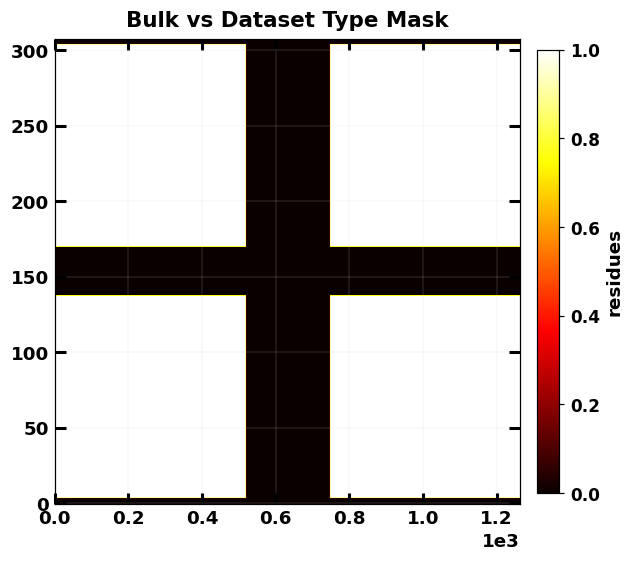

In [ ]:
ds.image_plot(
    ds.map4image(
        img=wfm.bulk,
        title='Bulk vs Dataset Type Mask',
        cbarlabel='residues',
        img_kwargs={
            'aspect': wfm.shape_detector[1] / wfm.shape_detector[0],
            'cmap': 'hot',
        },
    )
)

In [ ]:
# data from camera A
sdlA = ds.get_data(filepaths[ID_CAMERA_A][DATASET])
catalogueA = ds.get_catalogue(filepaths[ID_CAMERA_A]['sources'])
true_sky_camA, _ = ds.load_sky(save_path + f"sky_SIMUL_CAM1A_TEST_{ANALYSIS_ID}.fits")
res_sky_camA, _ = ds.load_sky(save_path + f"skyRES_IROS_CAM1A_TEST_{ANALYSIS_ID}.fits")

# Loading data...
# Loading completed!
# Loading data...
# Loading completed!


In [ ]:
# data from camera B
sdlB = ds.get_data(filepaths[ID_CAMERA_B][DATASET])
catalogueB = ds.get_catalogue(filepaths[ID_CAMERA_B]['sources'])
true_sky_camB, _ = ds.load_sky(save_path + f"sky_SIMUL_CAM1B_TEST_{ANALYSIS_ID}.fits")
res_sky_camB, _ = ds.load_sky(save_path + f"skyRES_IROS_CAM1B_TEST_{ANALYSIS_ID}.fits")

# Loading data...
# Loading completed!
# Loading data...
# Loading completed!


In [ ]:
log_camA, log_camB = ds.load_database(save_path + f"IROS_sources_database_TEST_{ANALYSIS_ID}.fits")

# Loading data...
# Loading completed!


**Analysis for LEM-X Camera A**

In [ ]:
assert ANALYSIS_CAM1A

In [ ]:
# sources data + angular coords residues plot
data_DF(
    log=log_camA,
    catalogue=catalogueA,
    sdl=sdlA,
    camera=wfm,
)

CAM1A                                              
            ID         SNR DthetaX [arcmin] DthetaY [arcmin]
0        scox1  718.749706         0.024011         0.022553
1        gx5-1   70.508719         0.086909         1.351442
2      gx349+2   49.091788         0.093143         1.464105
3       gx17+2   39.803828         0.626402         5.079425
4        gx9+1   38.683544         0.082975         0.755001
5      gx340+0   31.368753         0.120519         2.265733
6  groj1655-40   27.629850         0.107131         5.620446
7       gx13+1   23.767172         0.159259         5.412304
8    x1820-303   23.606826         0.288474         8.009776
9        gx3+1   20.187057         0.100095        13.312064

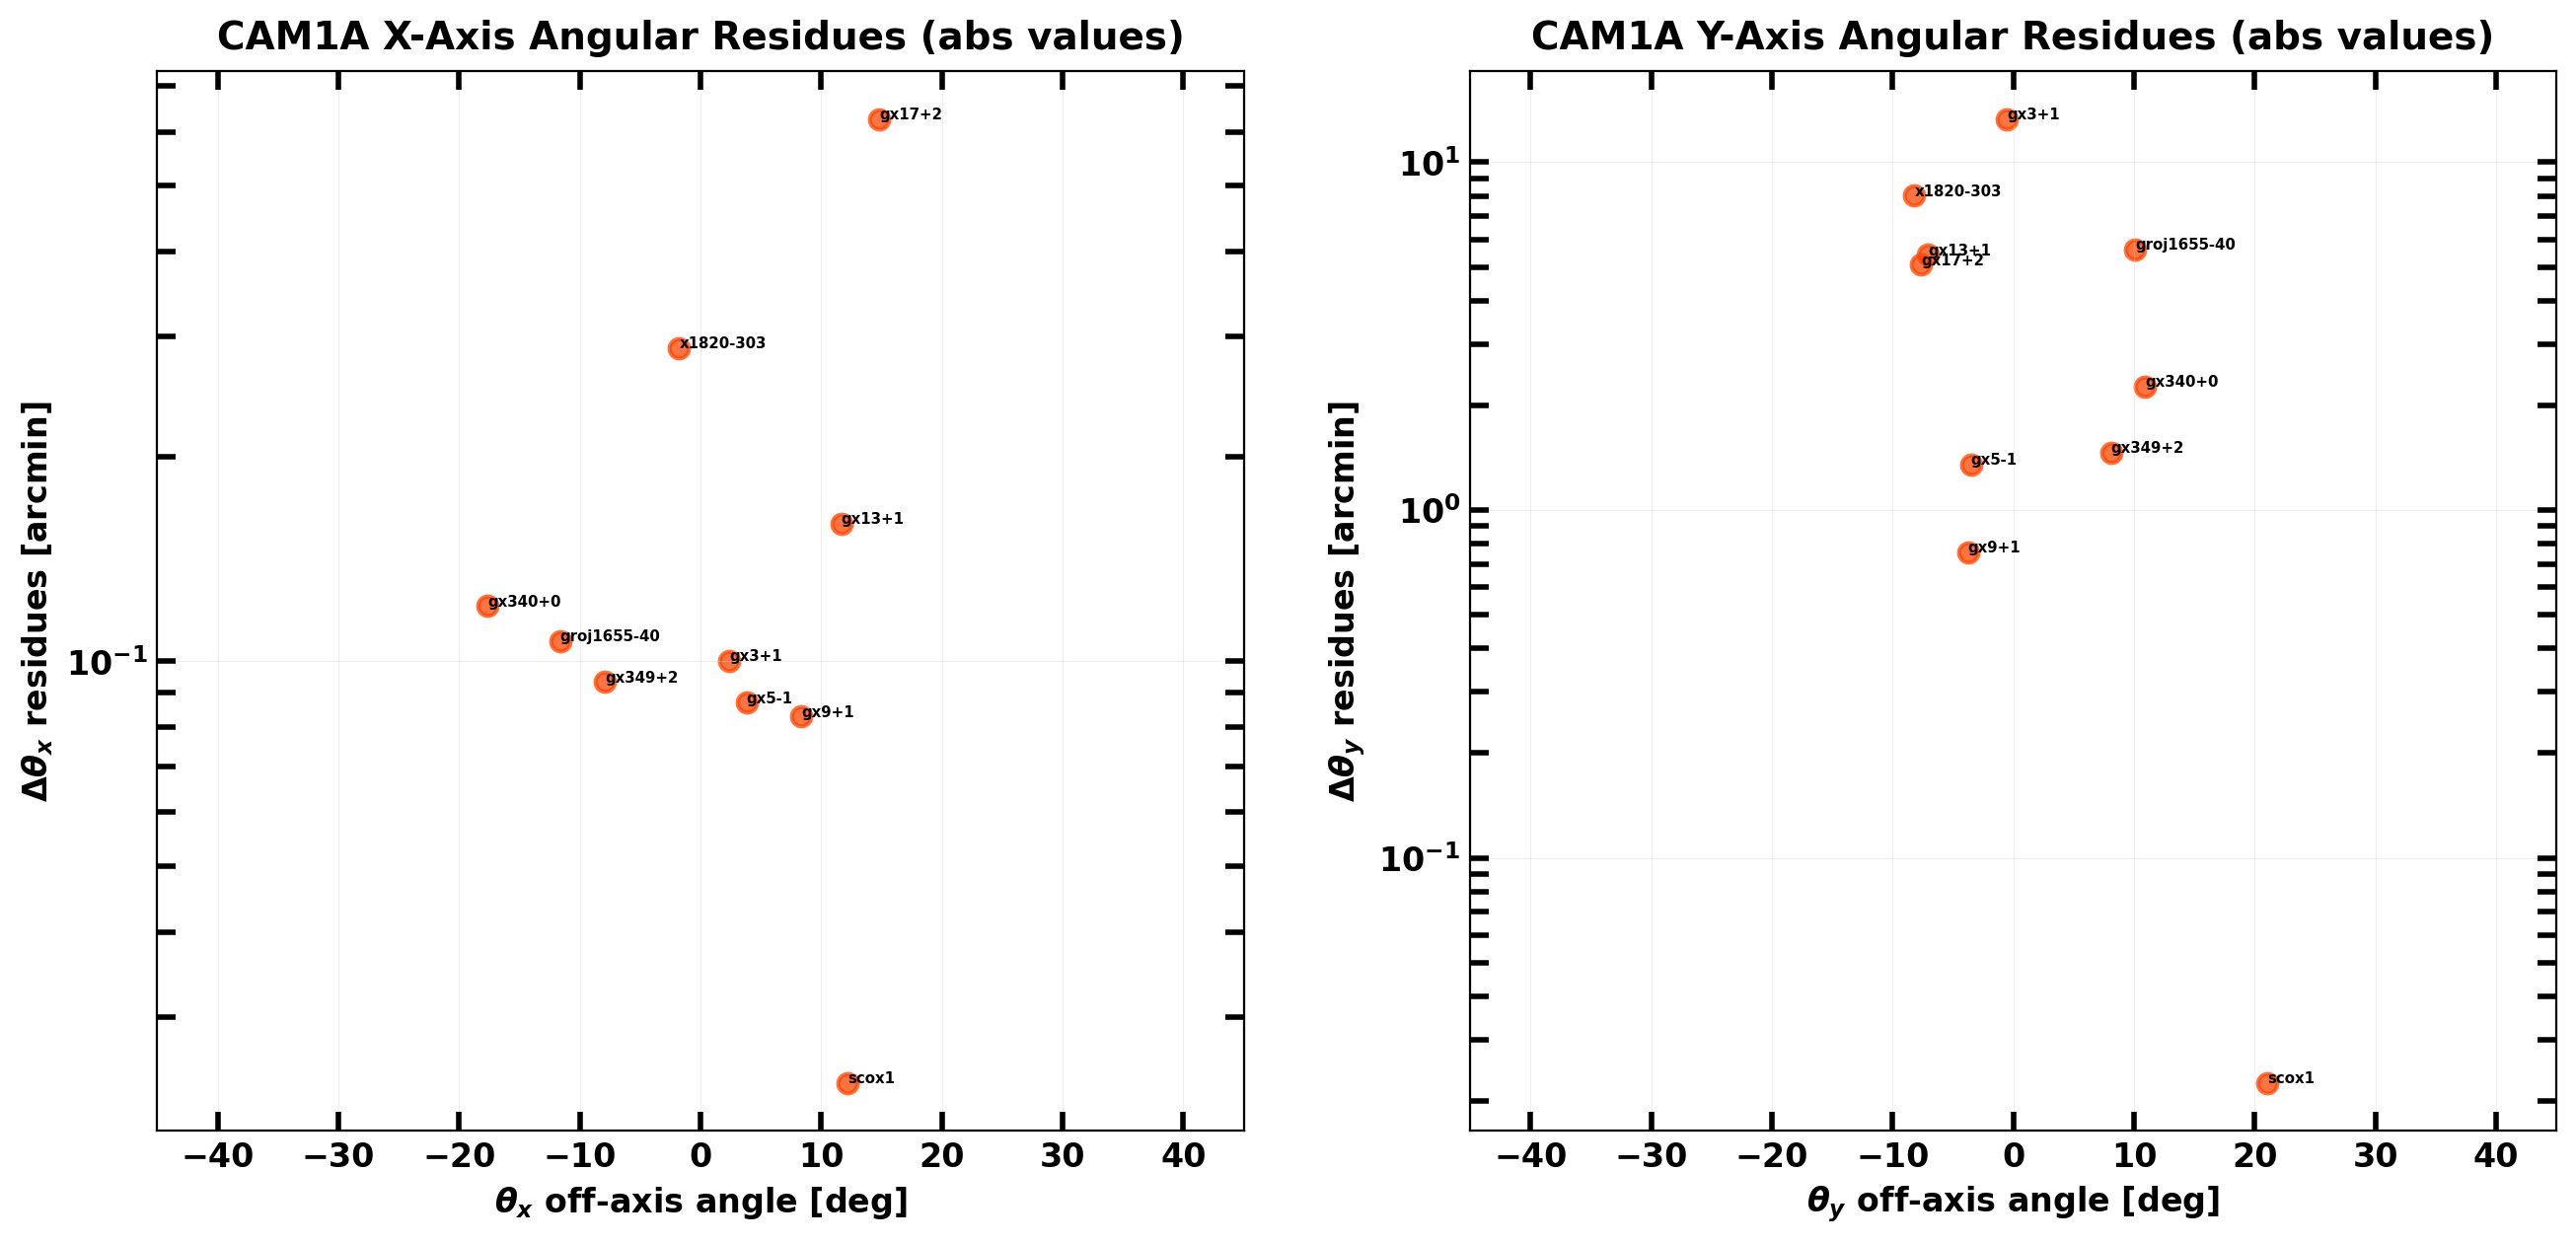

In [ ]:
angular_coords = extract_catalogue_angular_coords(log_camA, catalogueA, sdlA, wfm)
cat_theta_x, cat_theta_y = map(
    np.array, (angular_coords['THETAX'], angular_coords['THETAY']),
)

theta_res_x, theta_res_y = get_angularcoords_residues(
    log=log_camA,
    catalogue=catalogueA,
    sdl=sdlA,
    camera=wfm,
)

tags_x = tuple(
    Tag(name, res, theta) for name, res, theta in zip(
        log_camA.log['ID'], theta_res_x, cat_theta_x,
    )
)
tags_y = tuple(
    Tag(name, res, theta) for name, res, theta in zip(
        log_camA.log['ID'], theta_res_y, cat_theta_y,
    )
)
dmapx = ds.map4plot(
    arrs=theta_res_x,
    title=f'{log_camA.name} X-Axis Angular Residues (abs values)',
    xlabel='$\\theta_{{x}}$ off-axis angle [deg]',
    ylabel='$\\Delta\\theta_{{x}}$ residues [arcmin]',
    x=cat_theta_x,
    style='scatter',
    color='OrangeRed',
    xlim=(-45, 45),
    yscale='log',
    tags=tags_x,
)
dmapy = ds.map4plot(
    arrs=theta_res_y,
    title=f'{log_camA.name} Y-Axis Angular Residues (abs values)',
    xlabel='$\\theta_{{y}}$ off-axis angle [deg]',
    ylabel='$\\Delta\\theta_{{y}}$ residues [arcmin]',
    x=cat_theta_y,
    style='scatter',
    color='OrangeRed',
    xlim=(-45, 45),
    yscale='log',
    tags=tags_y,
)

ds.plot(
    (dmapx, dmapy),
    ncols=2,
    save_to=(
        savefig_to(SAVE_TO, f'angularRes_{ID_CAMERA_A.upper()}')
        if SAVE_THINGS else None
    ),
)

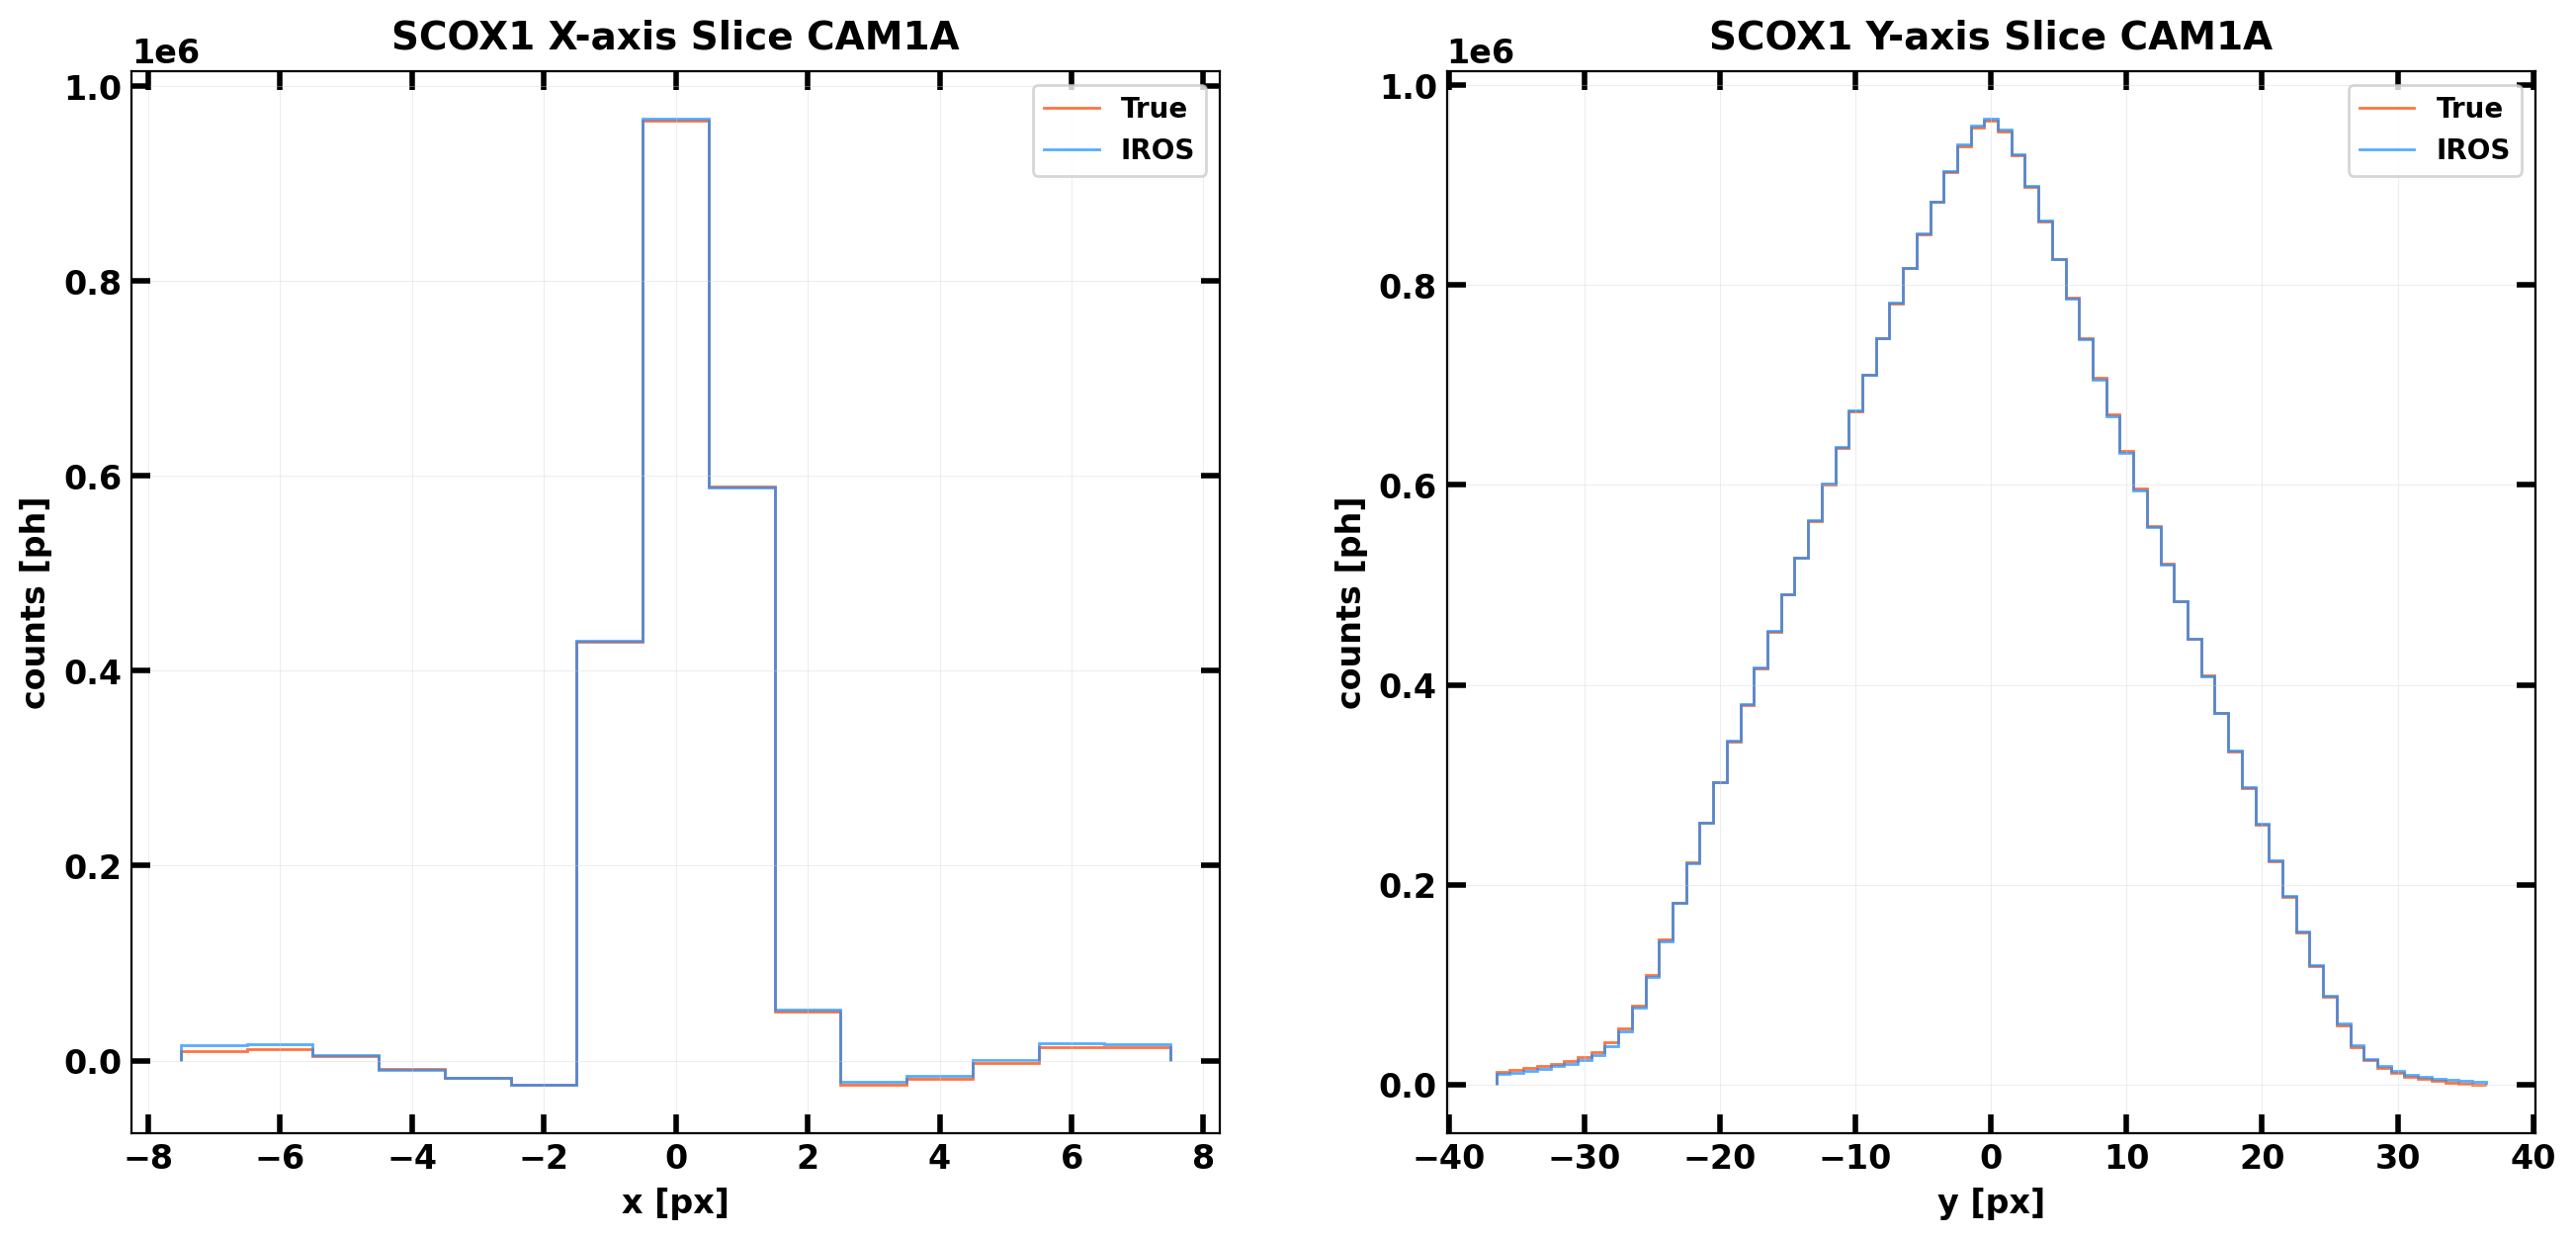

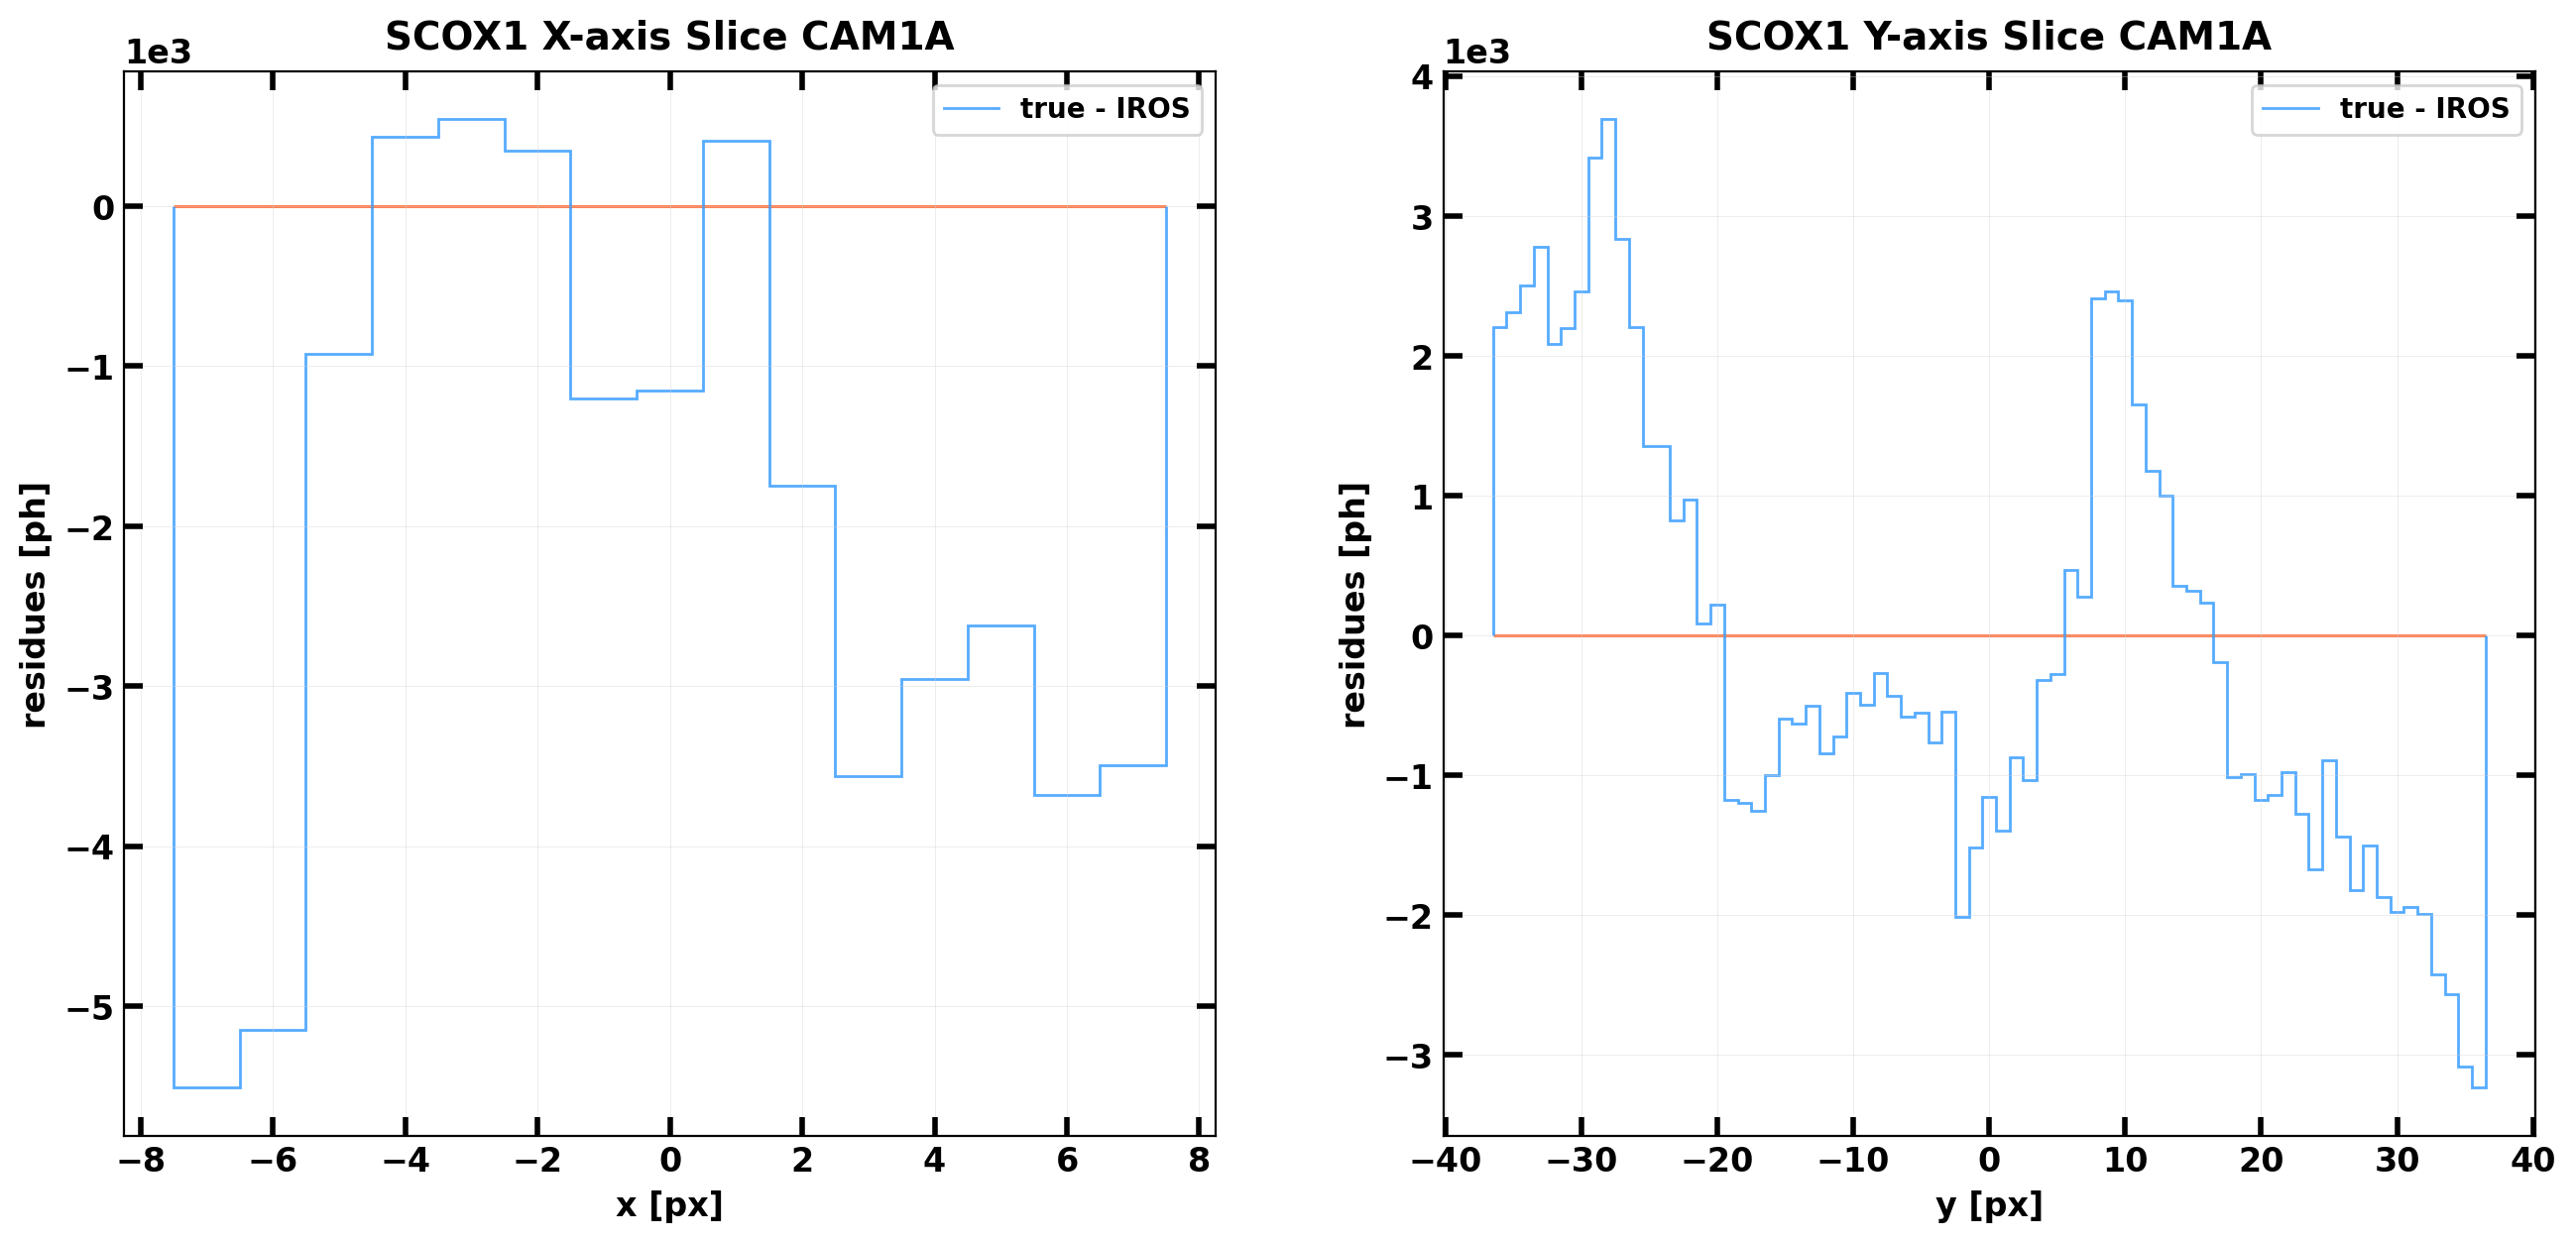

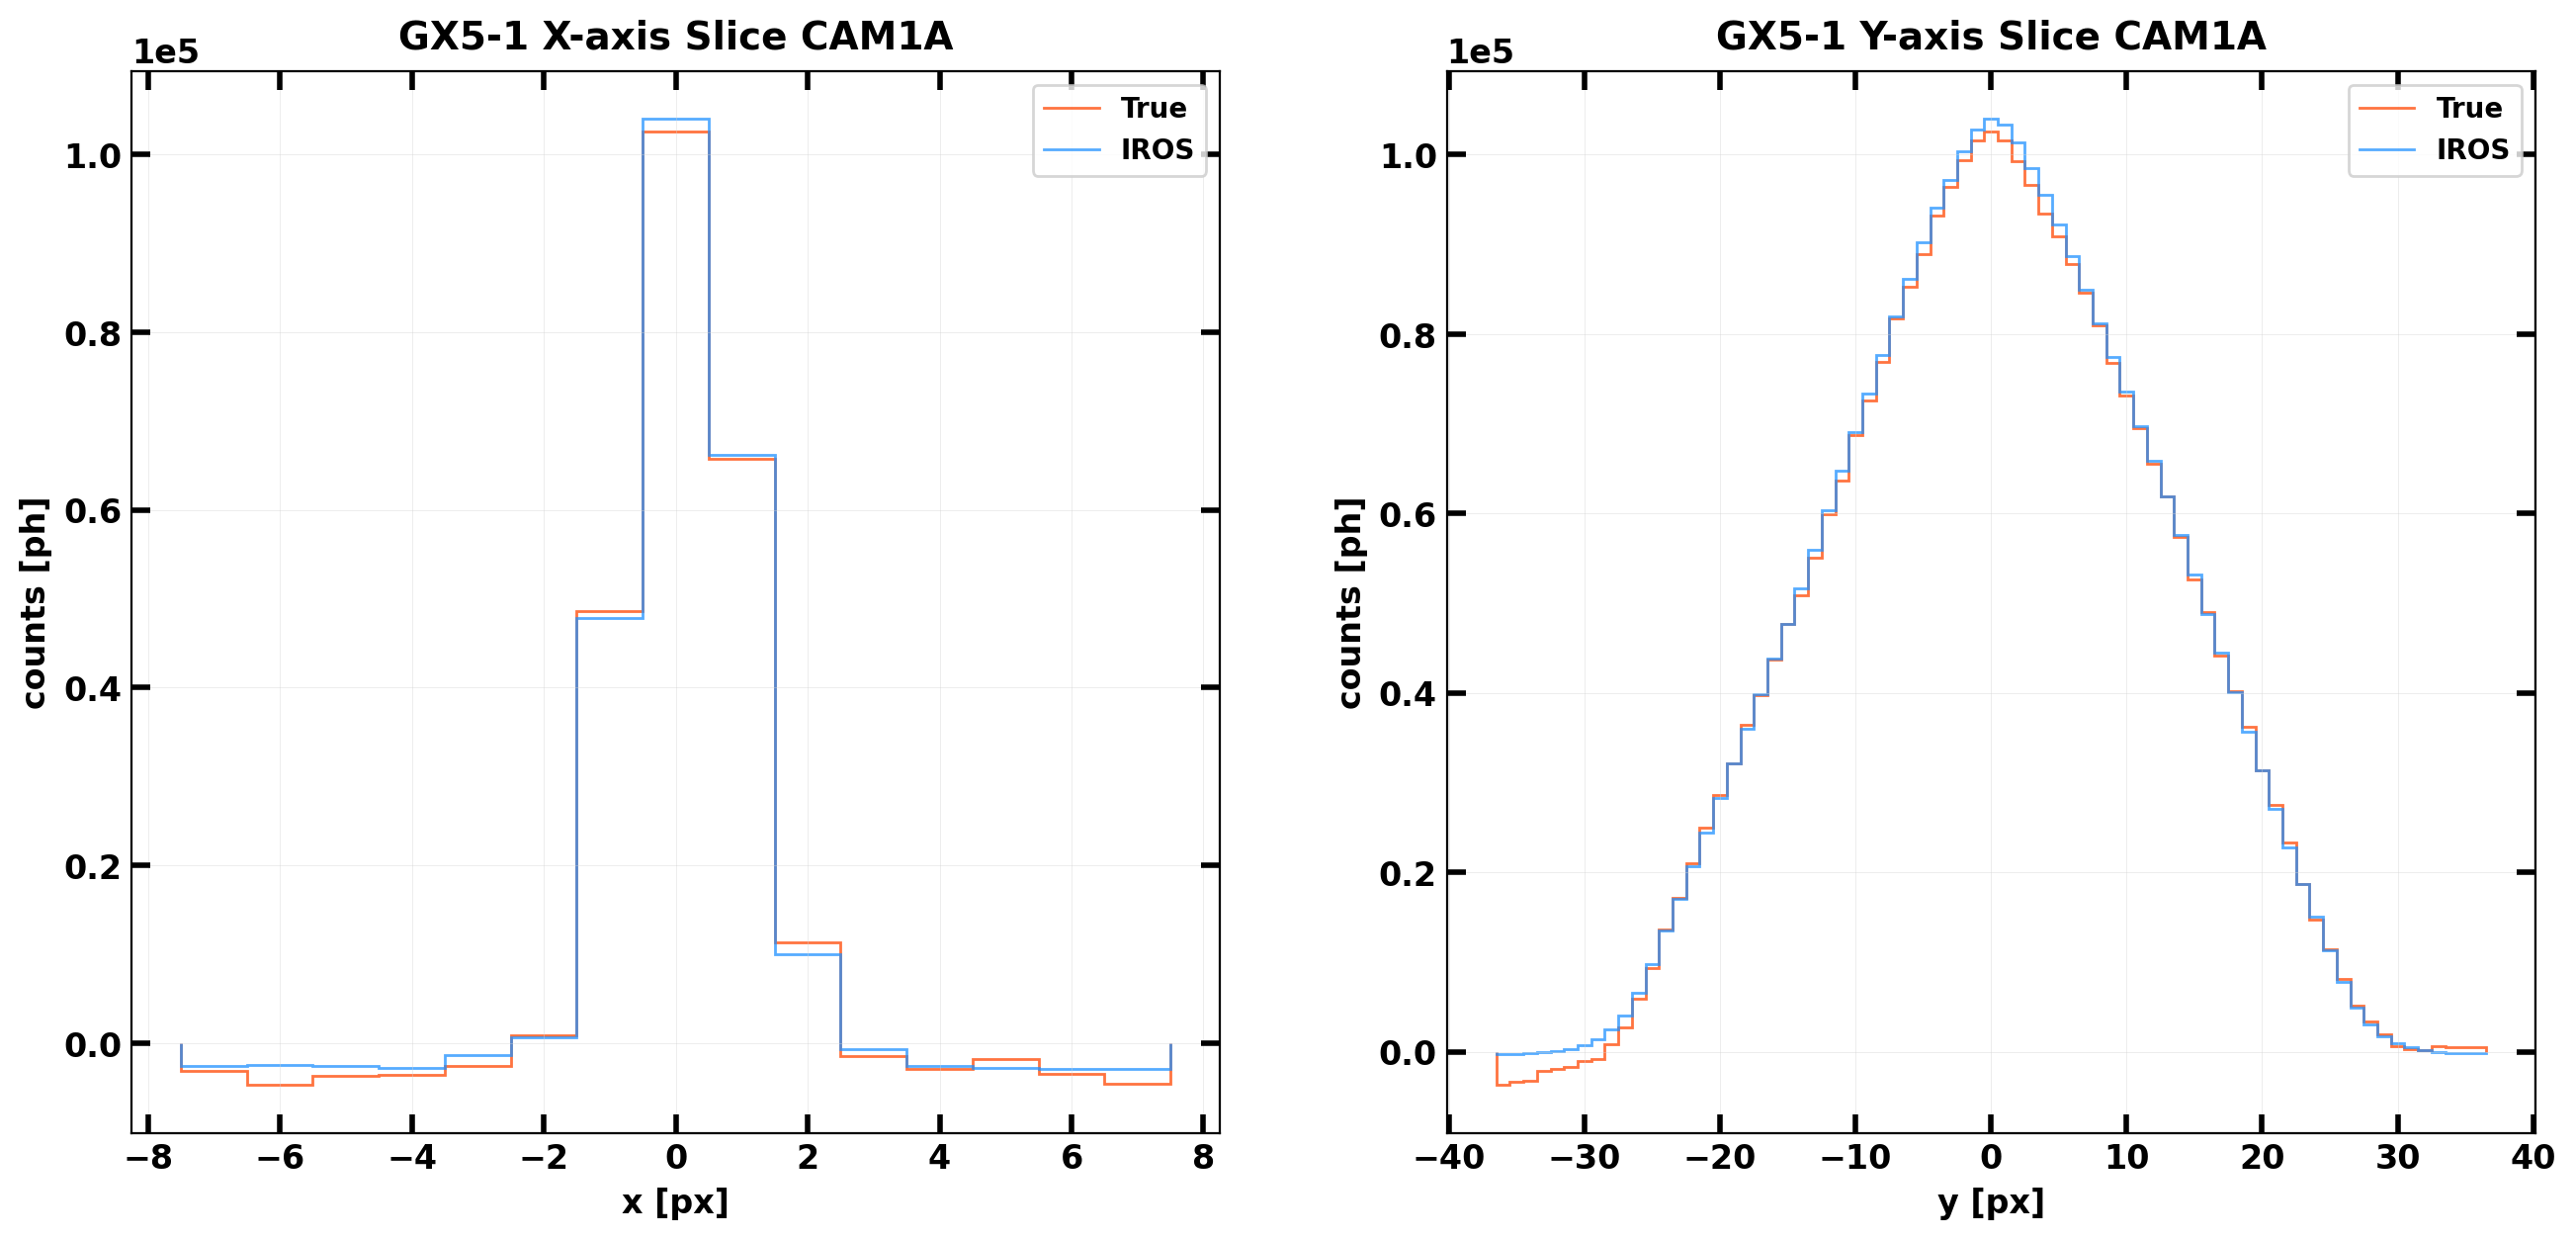

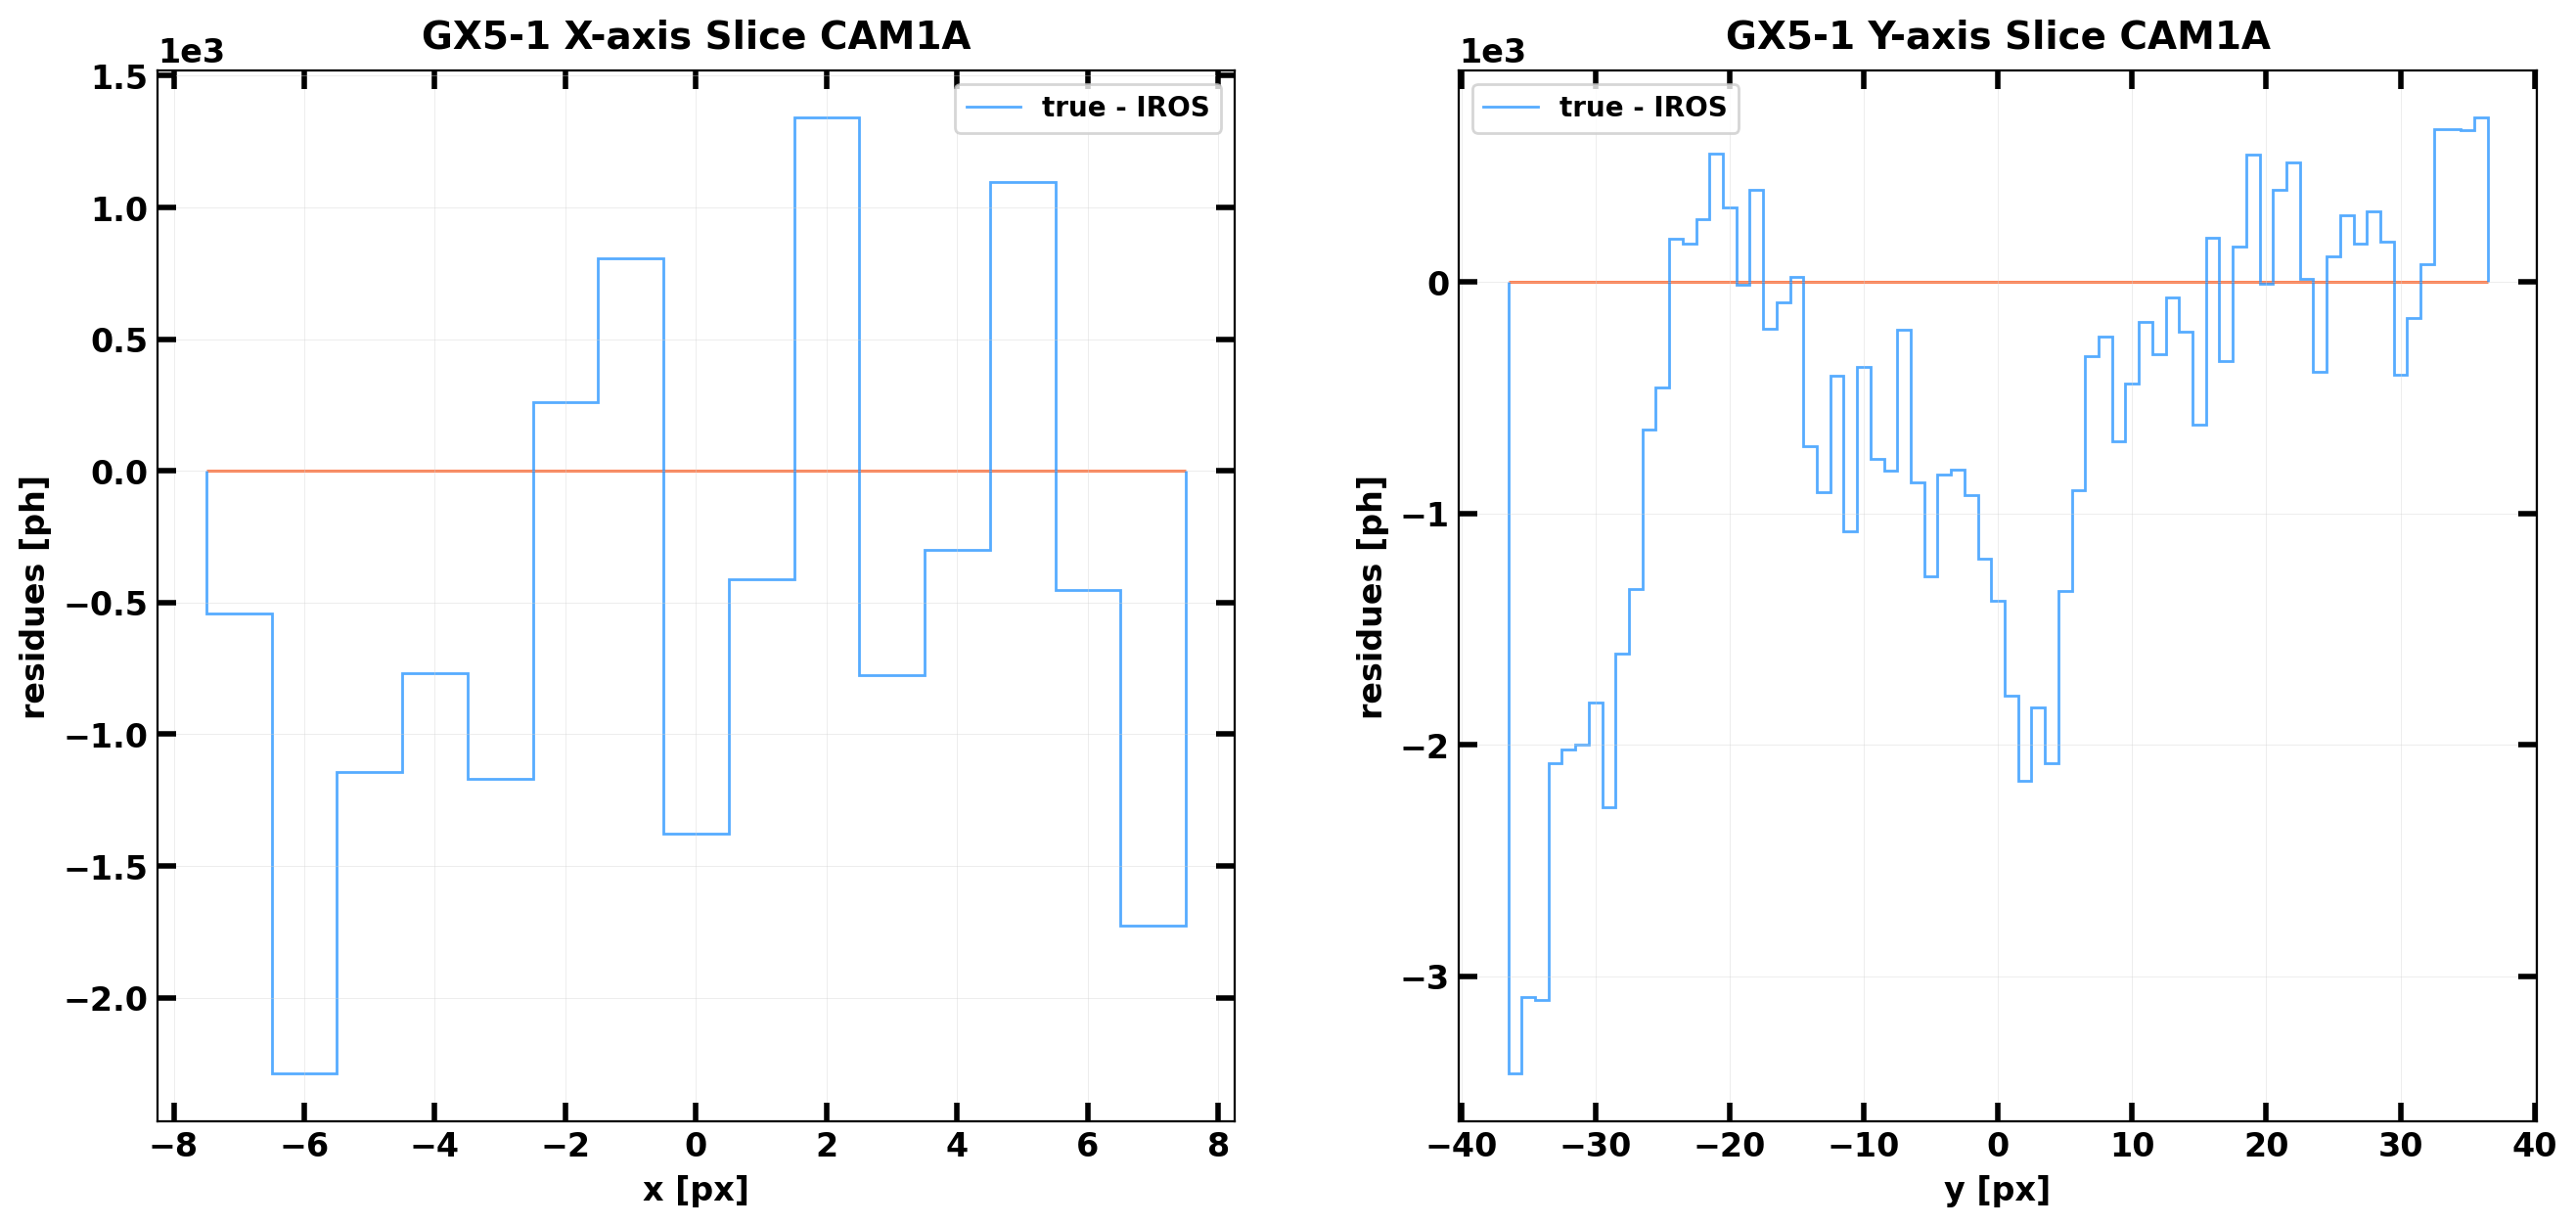

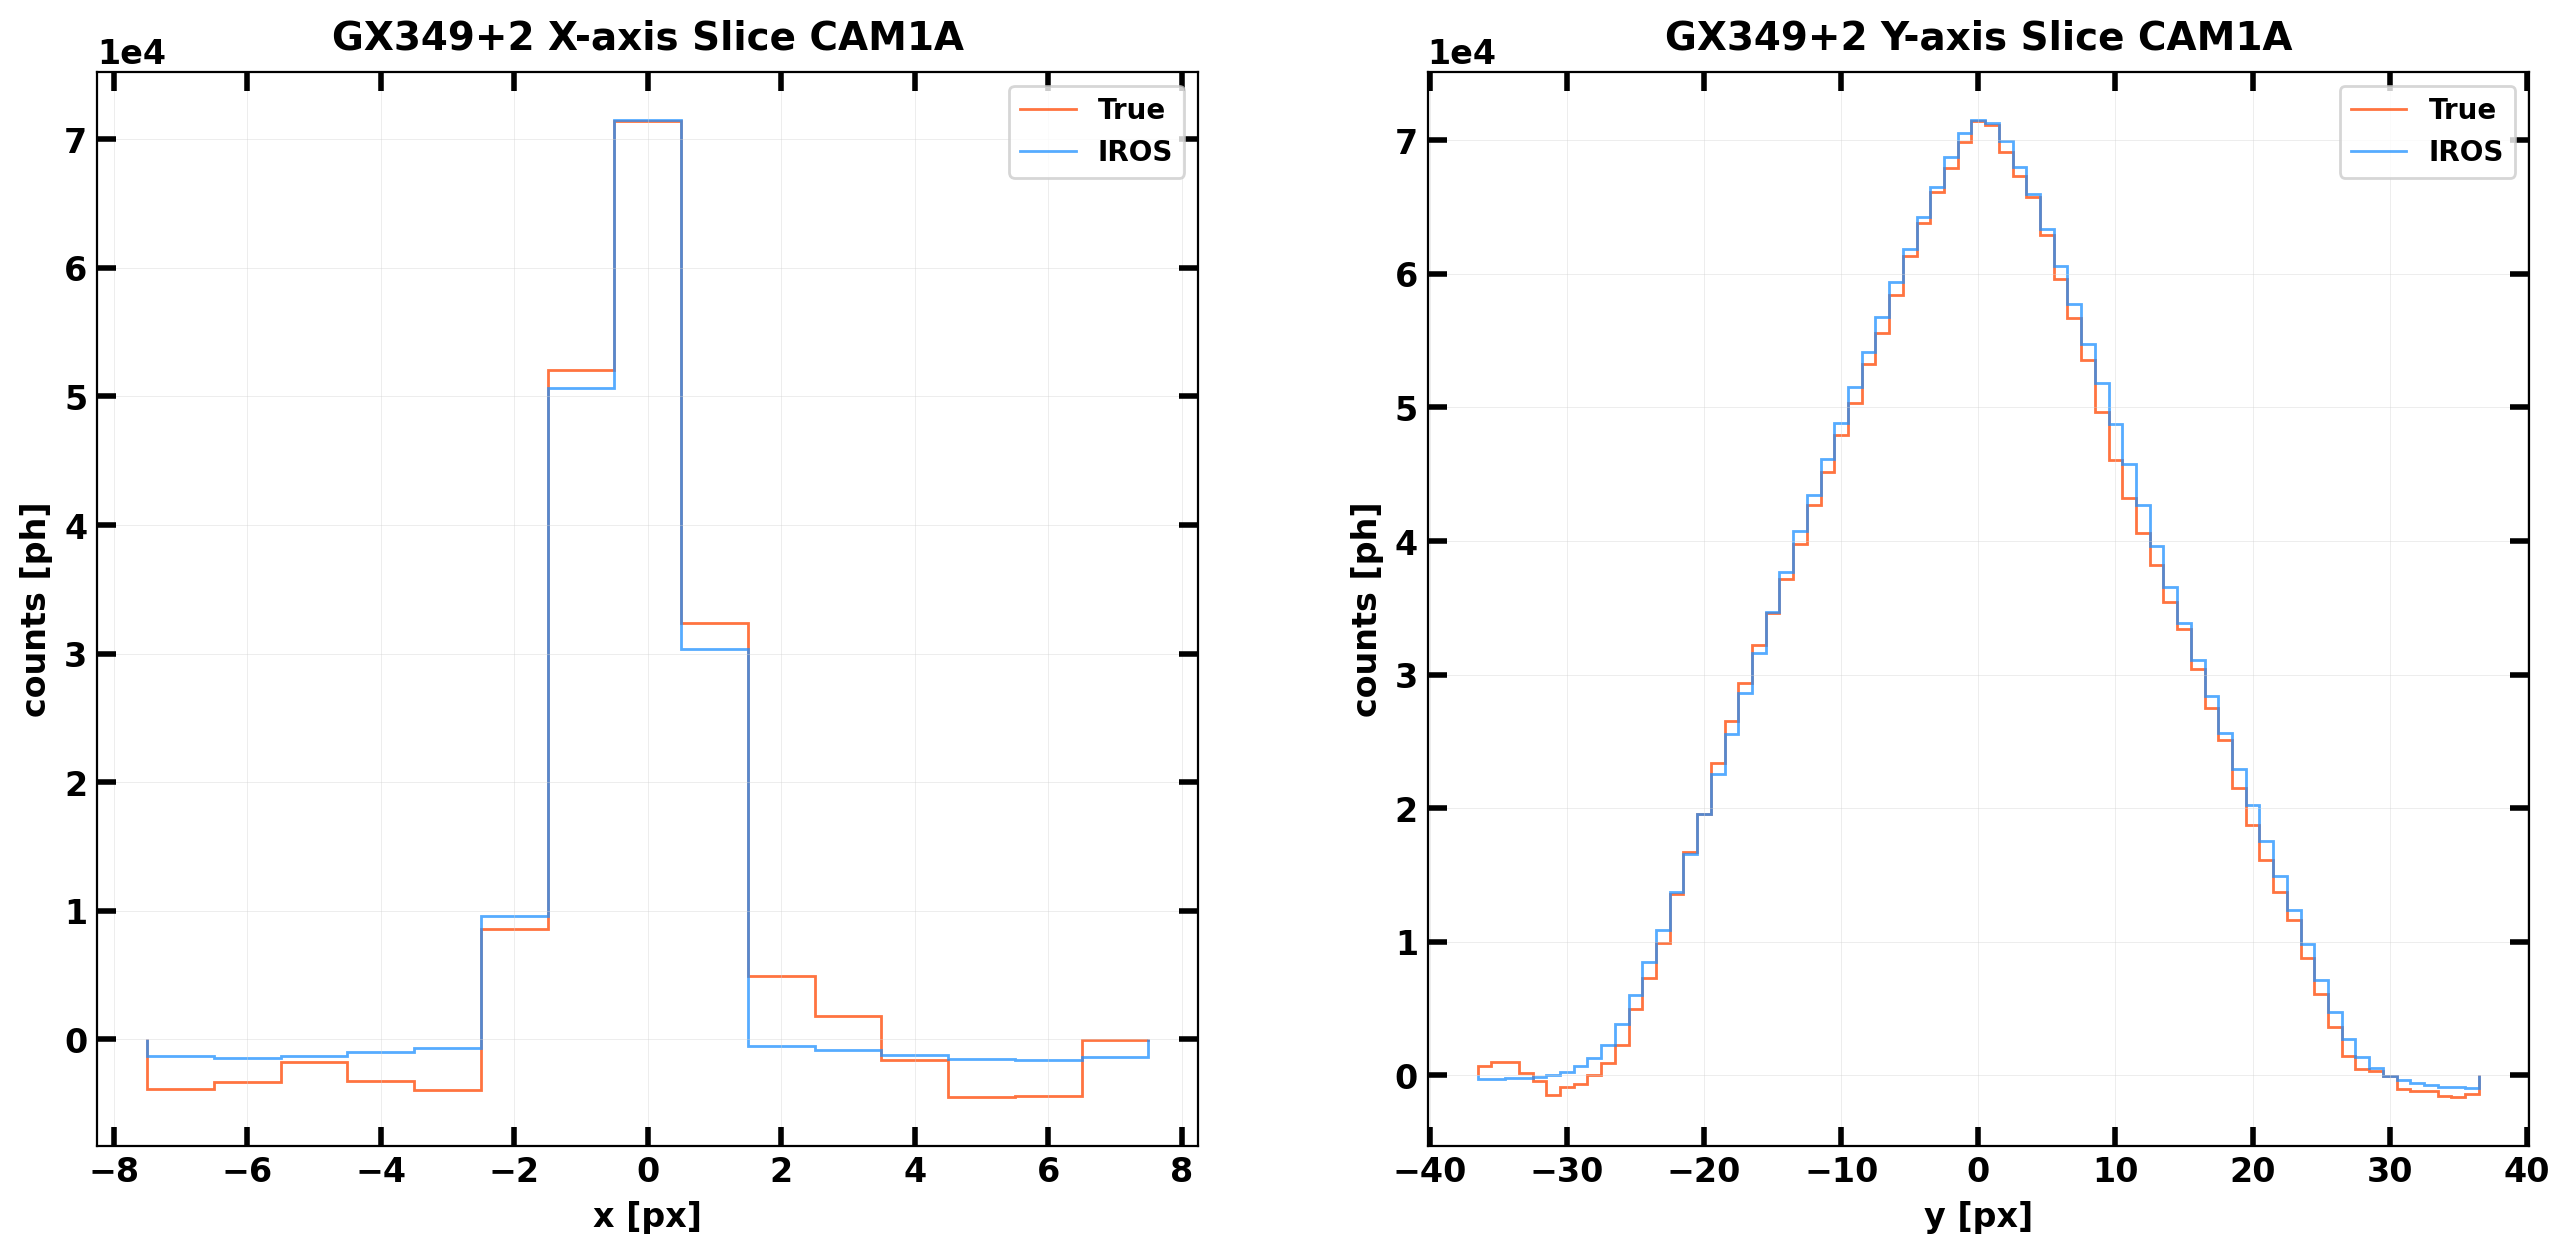

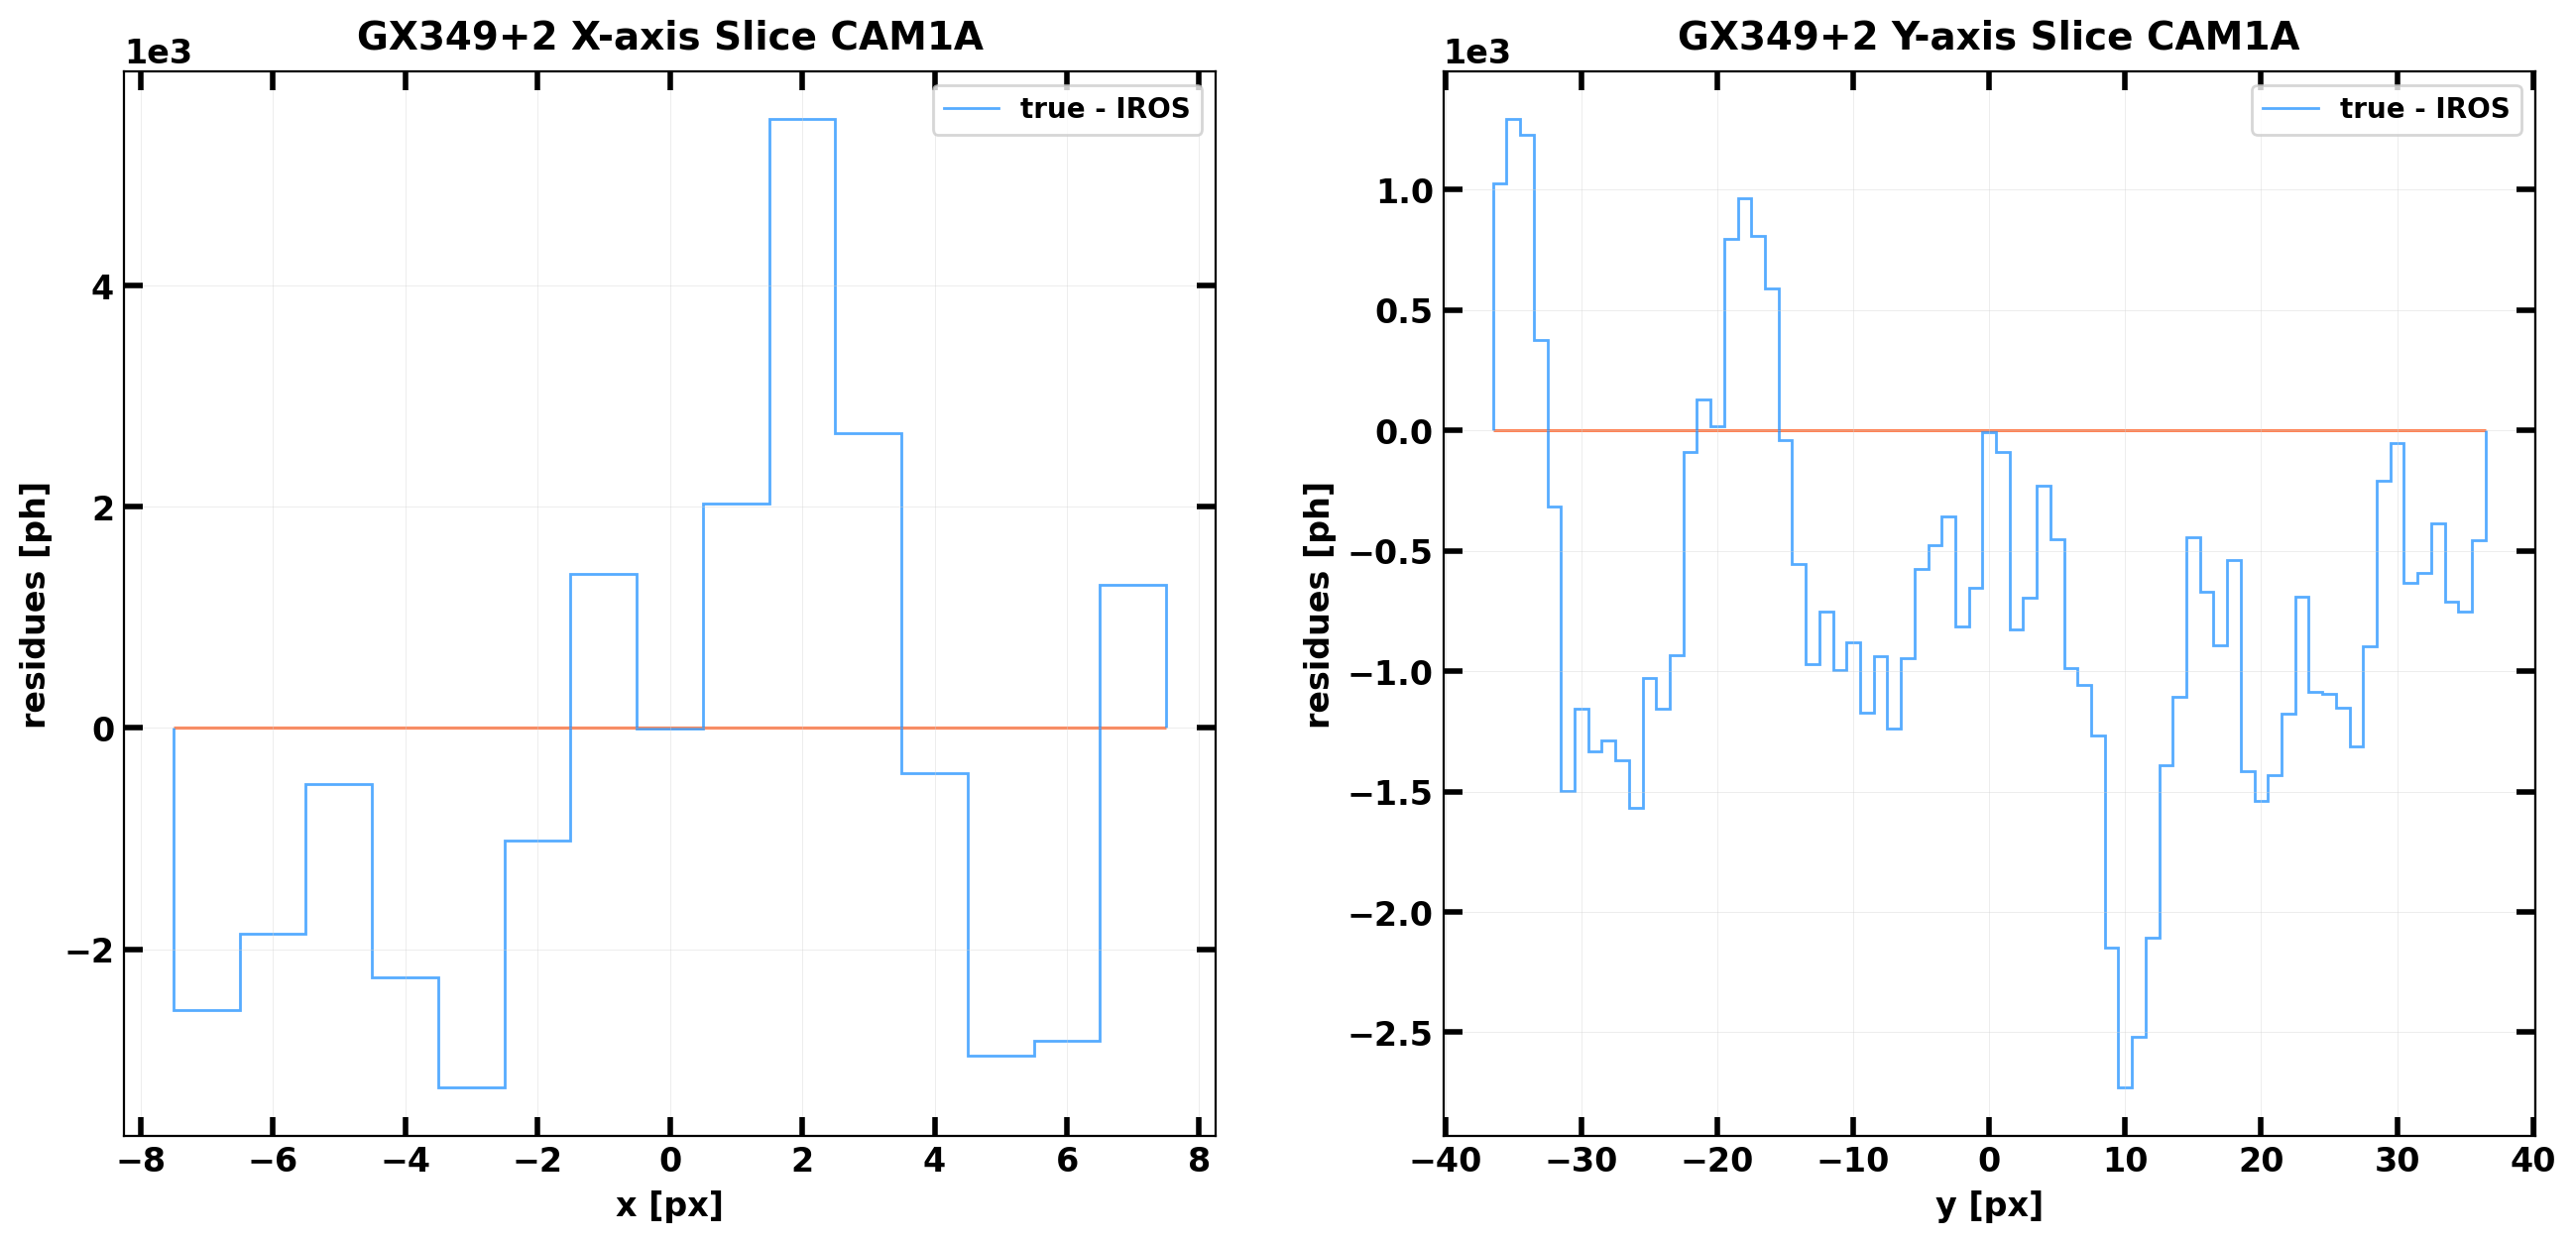

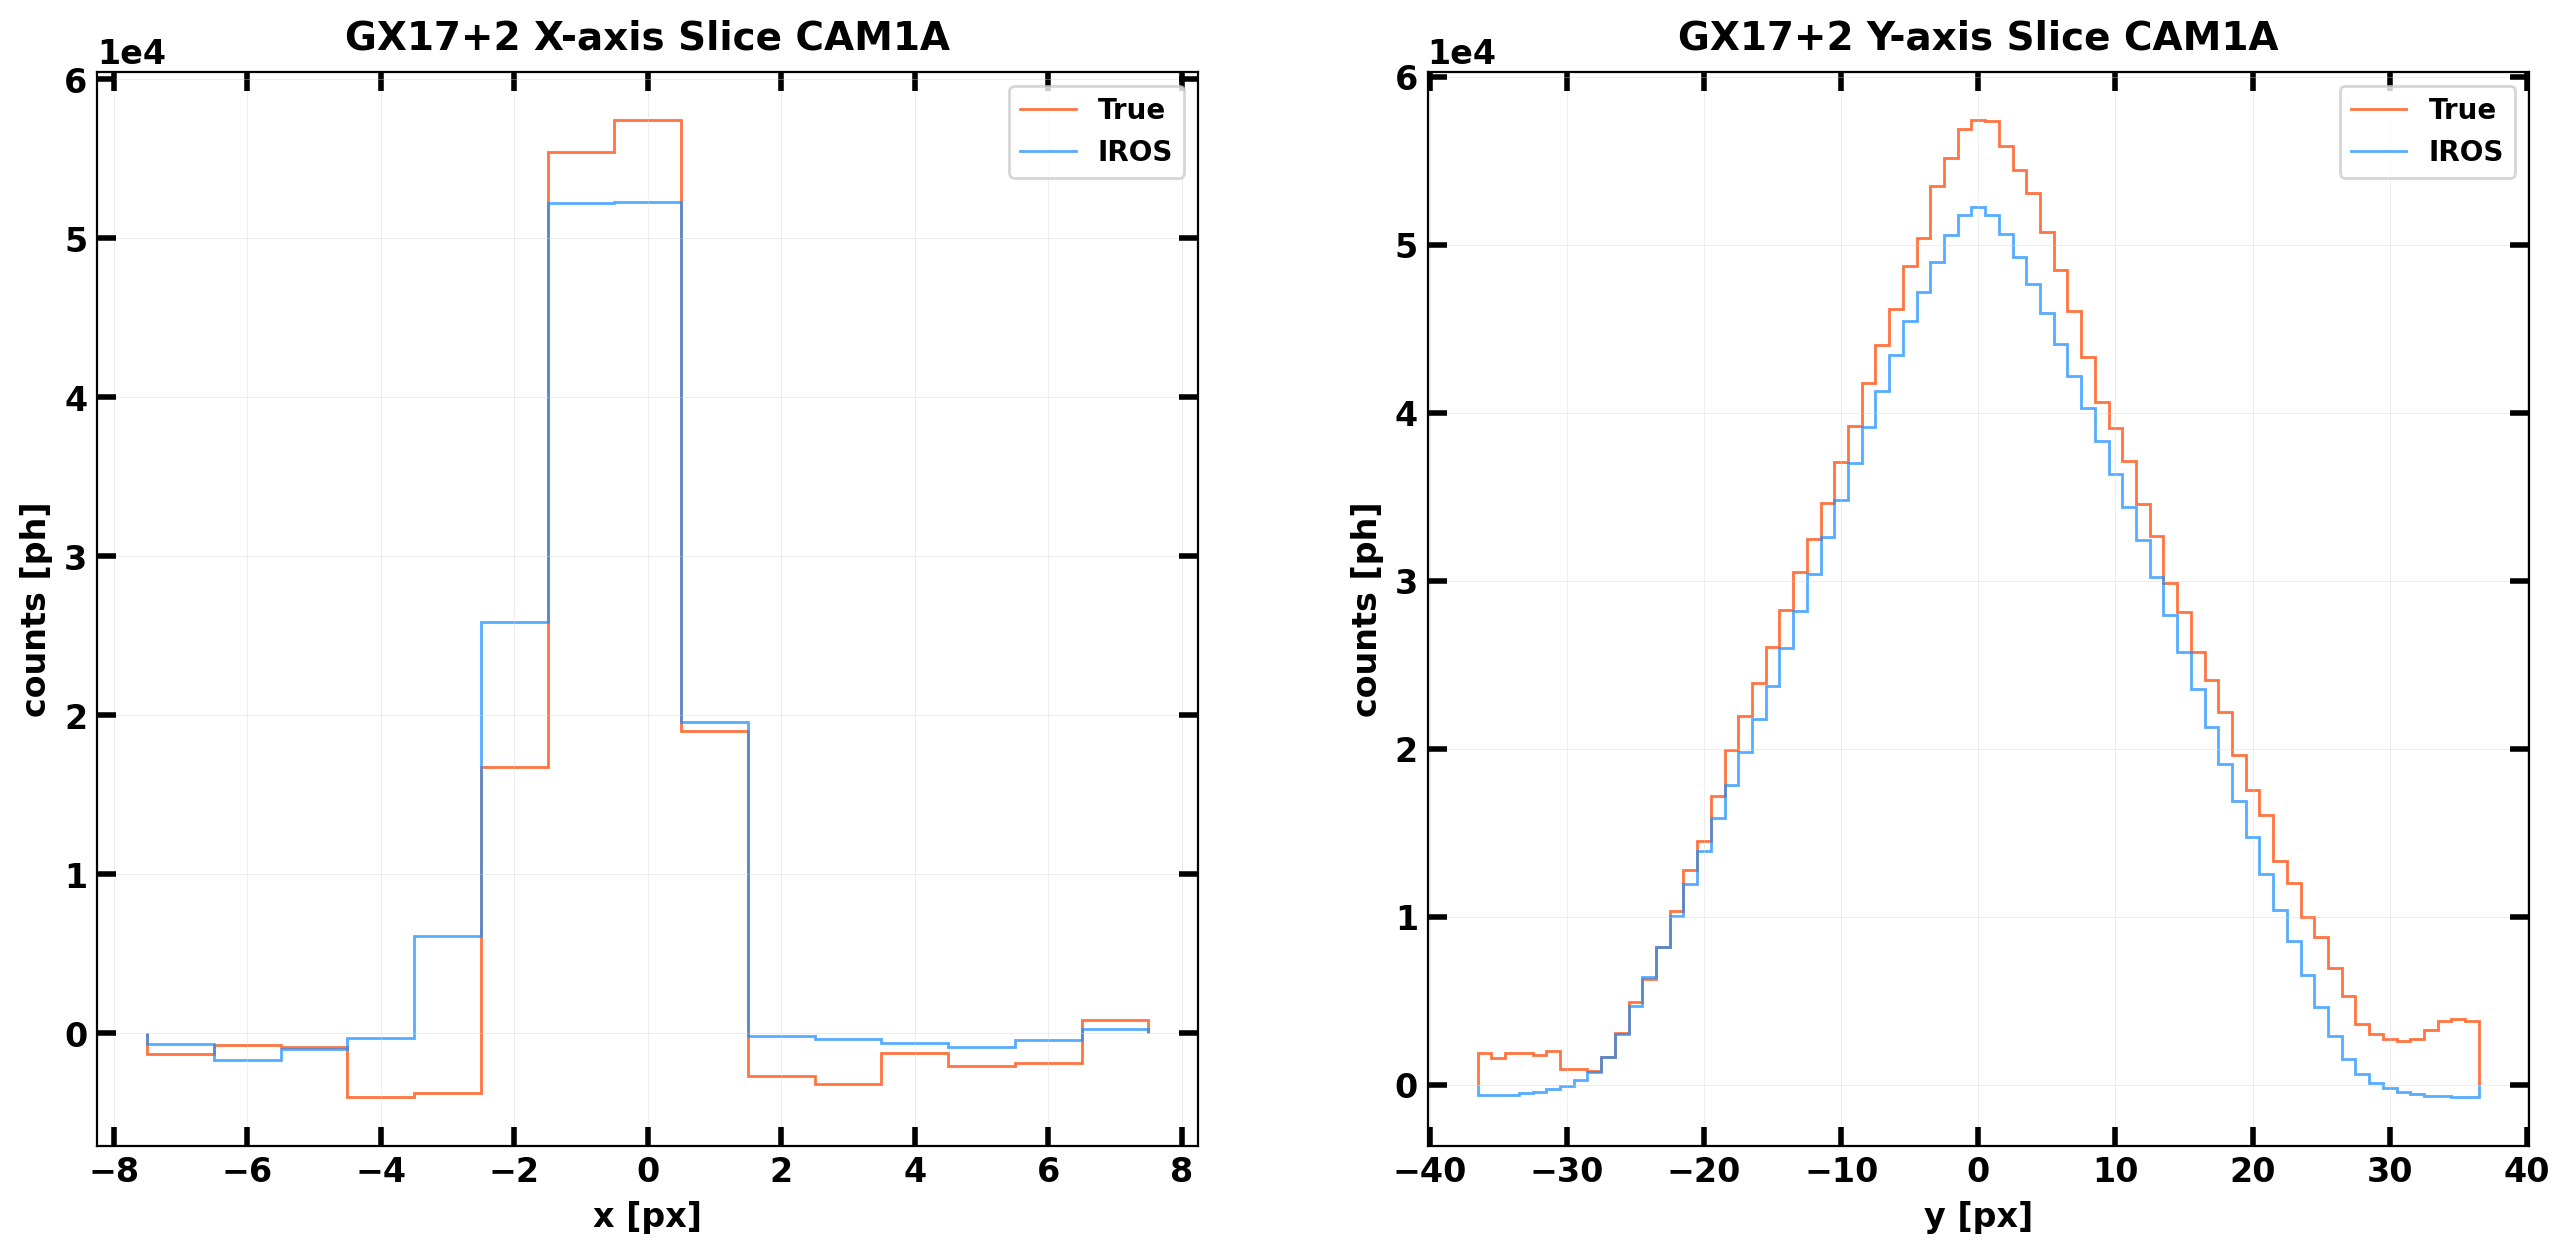

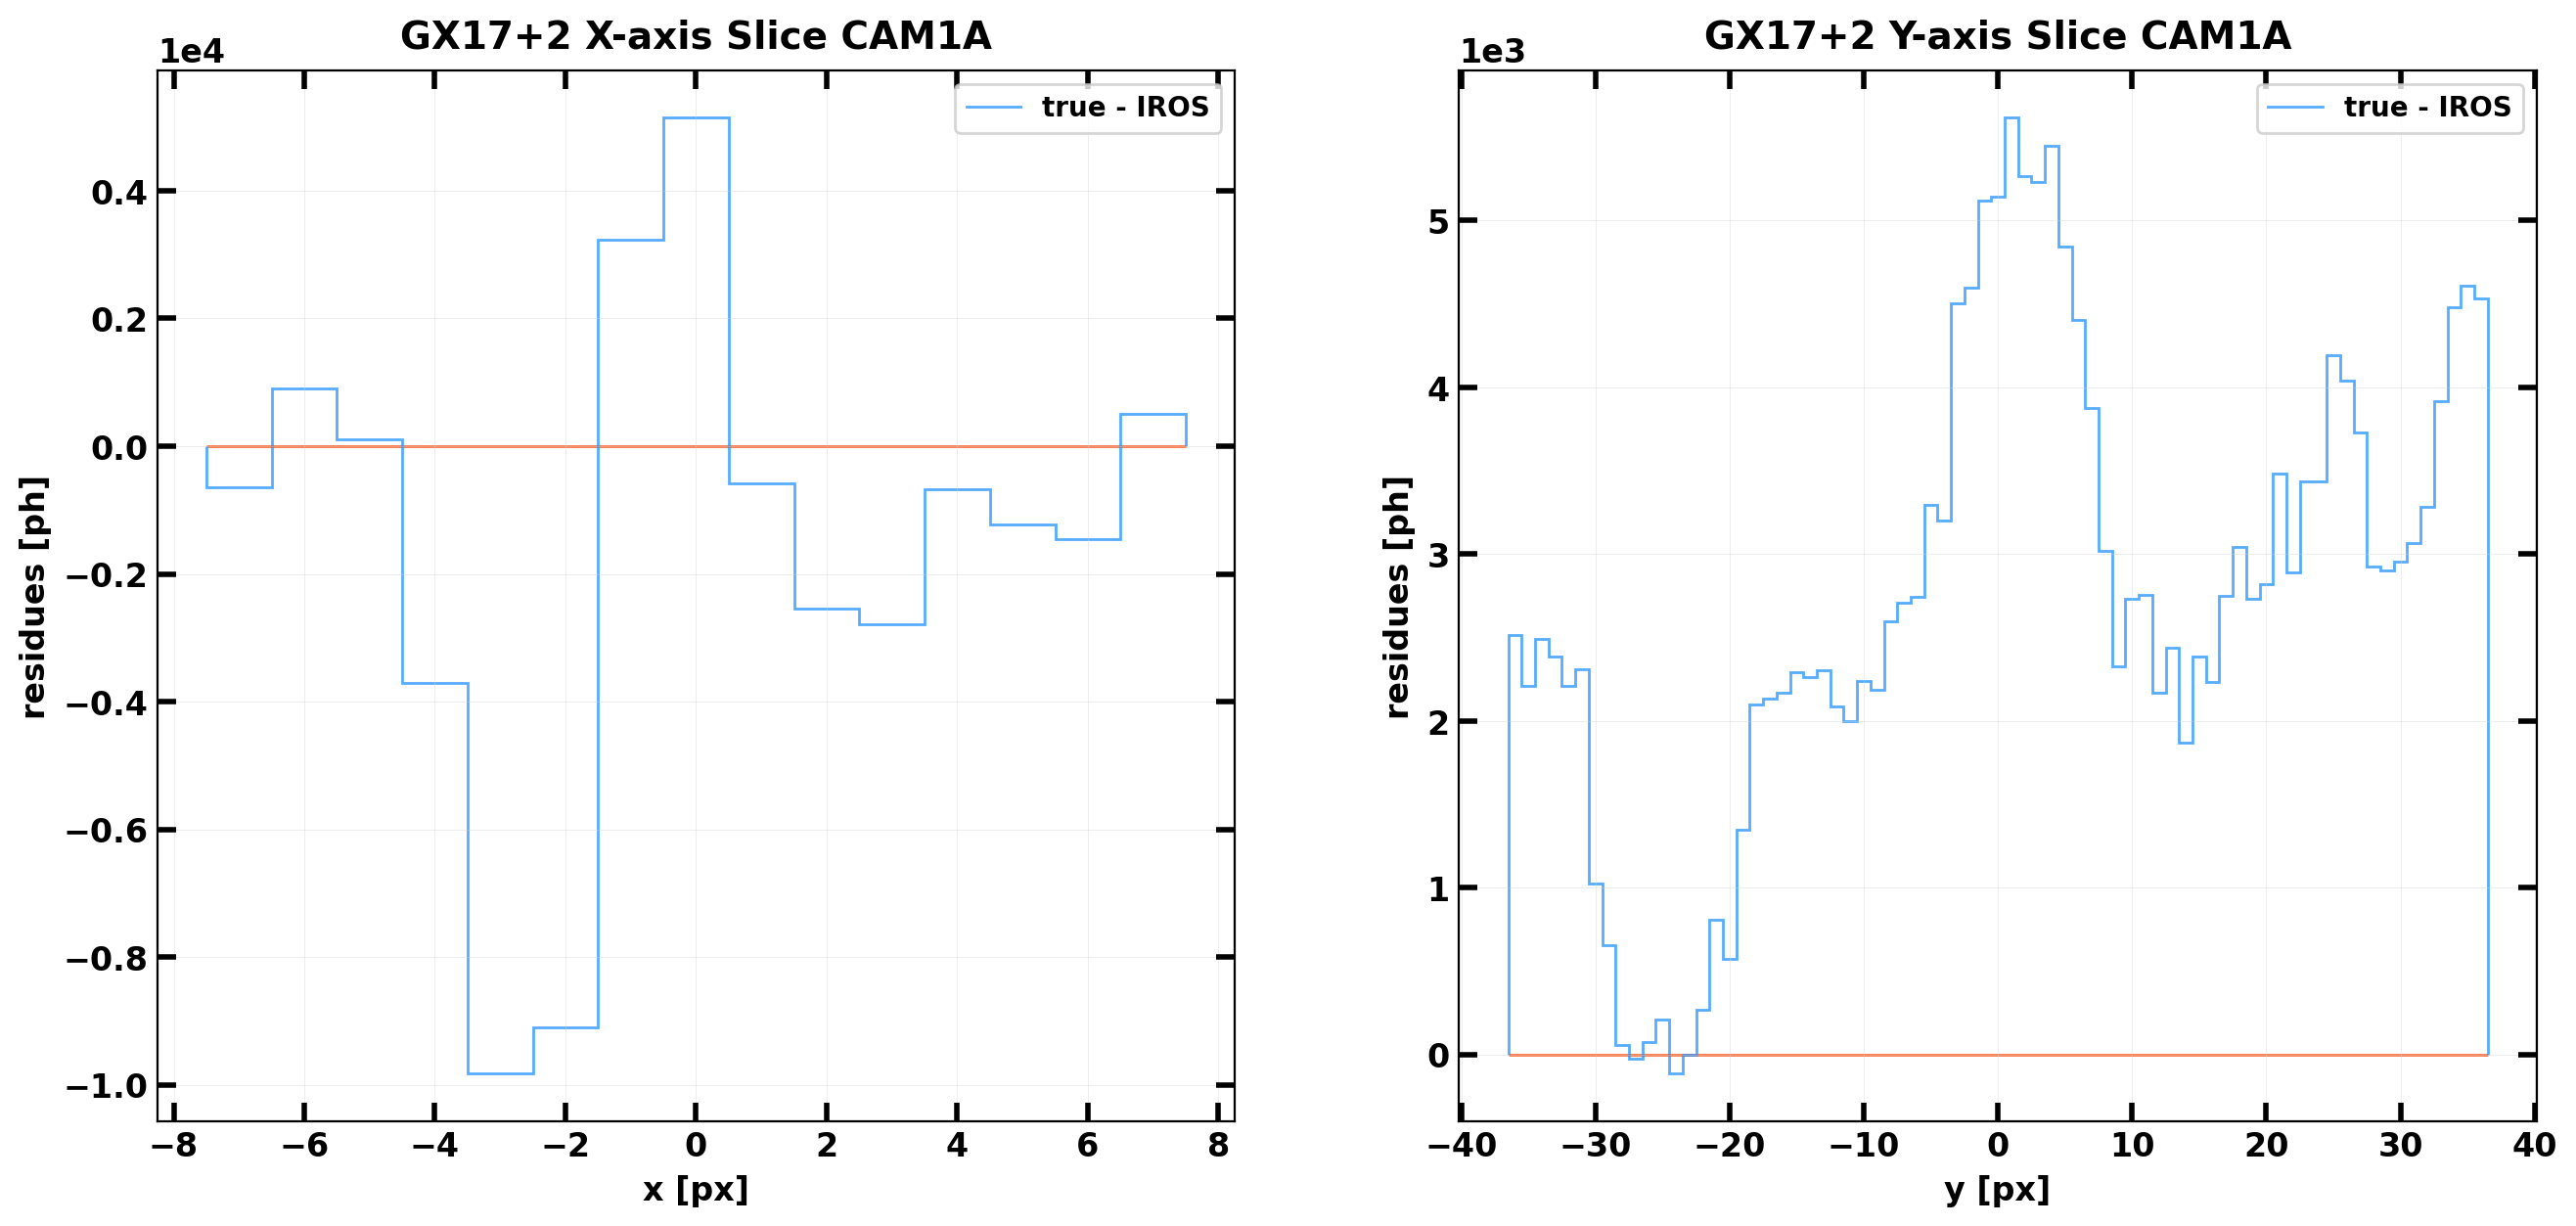

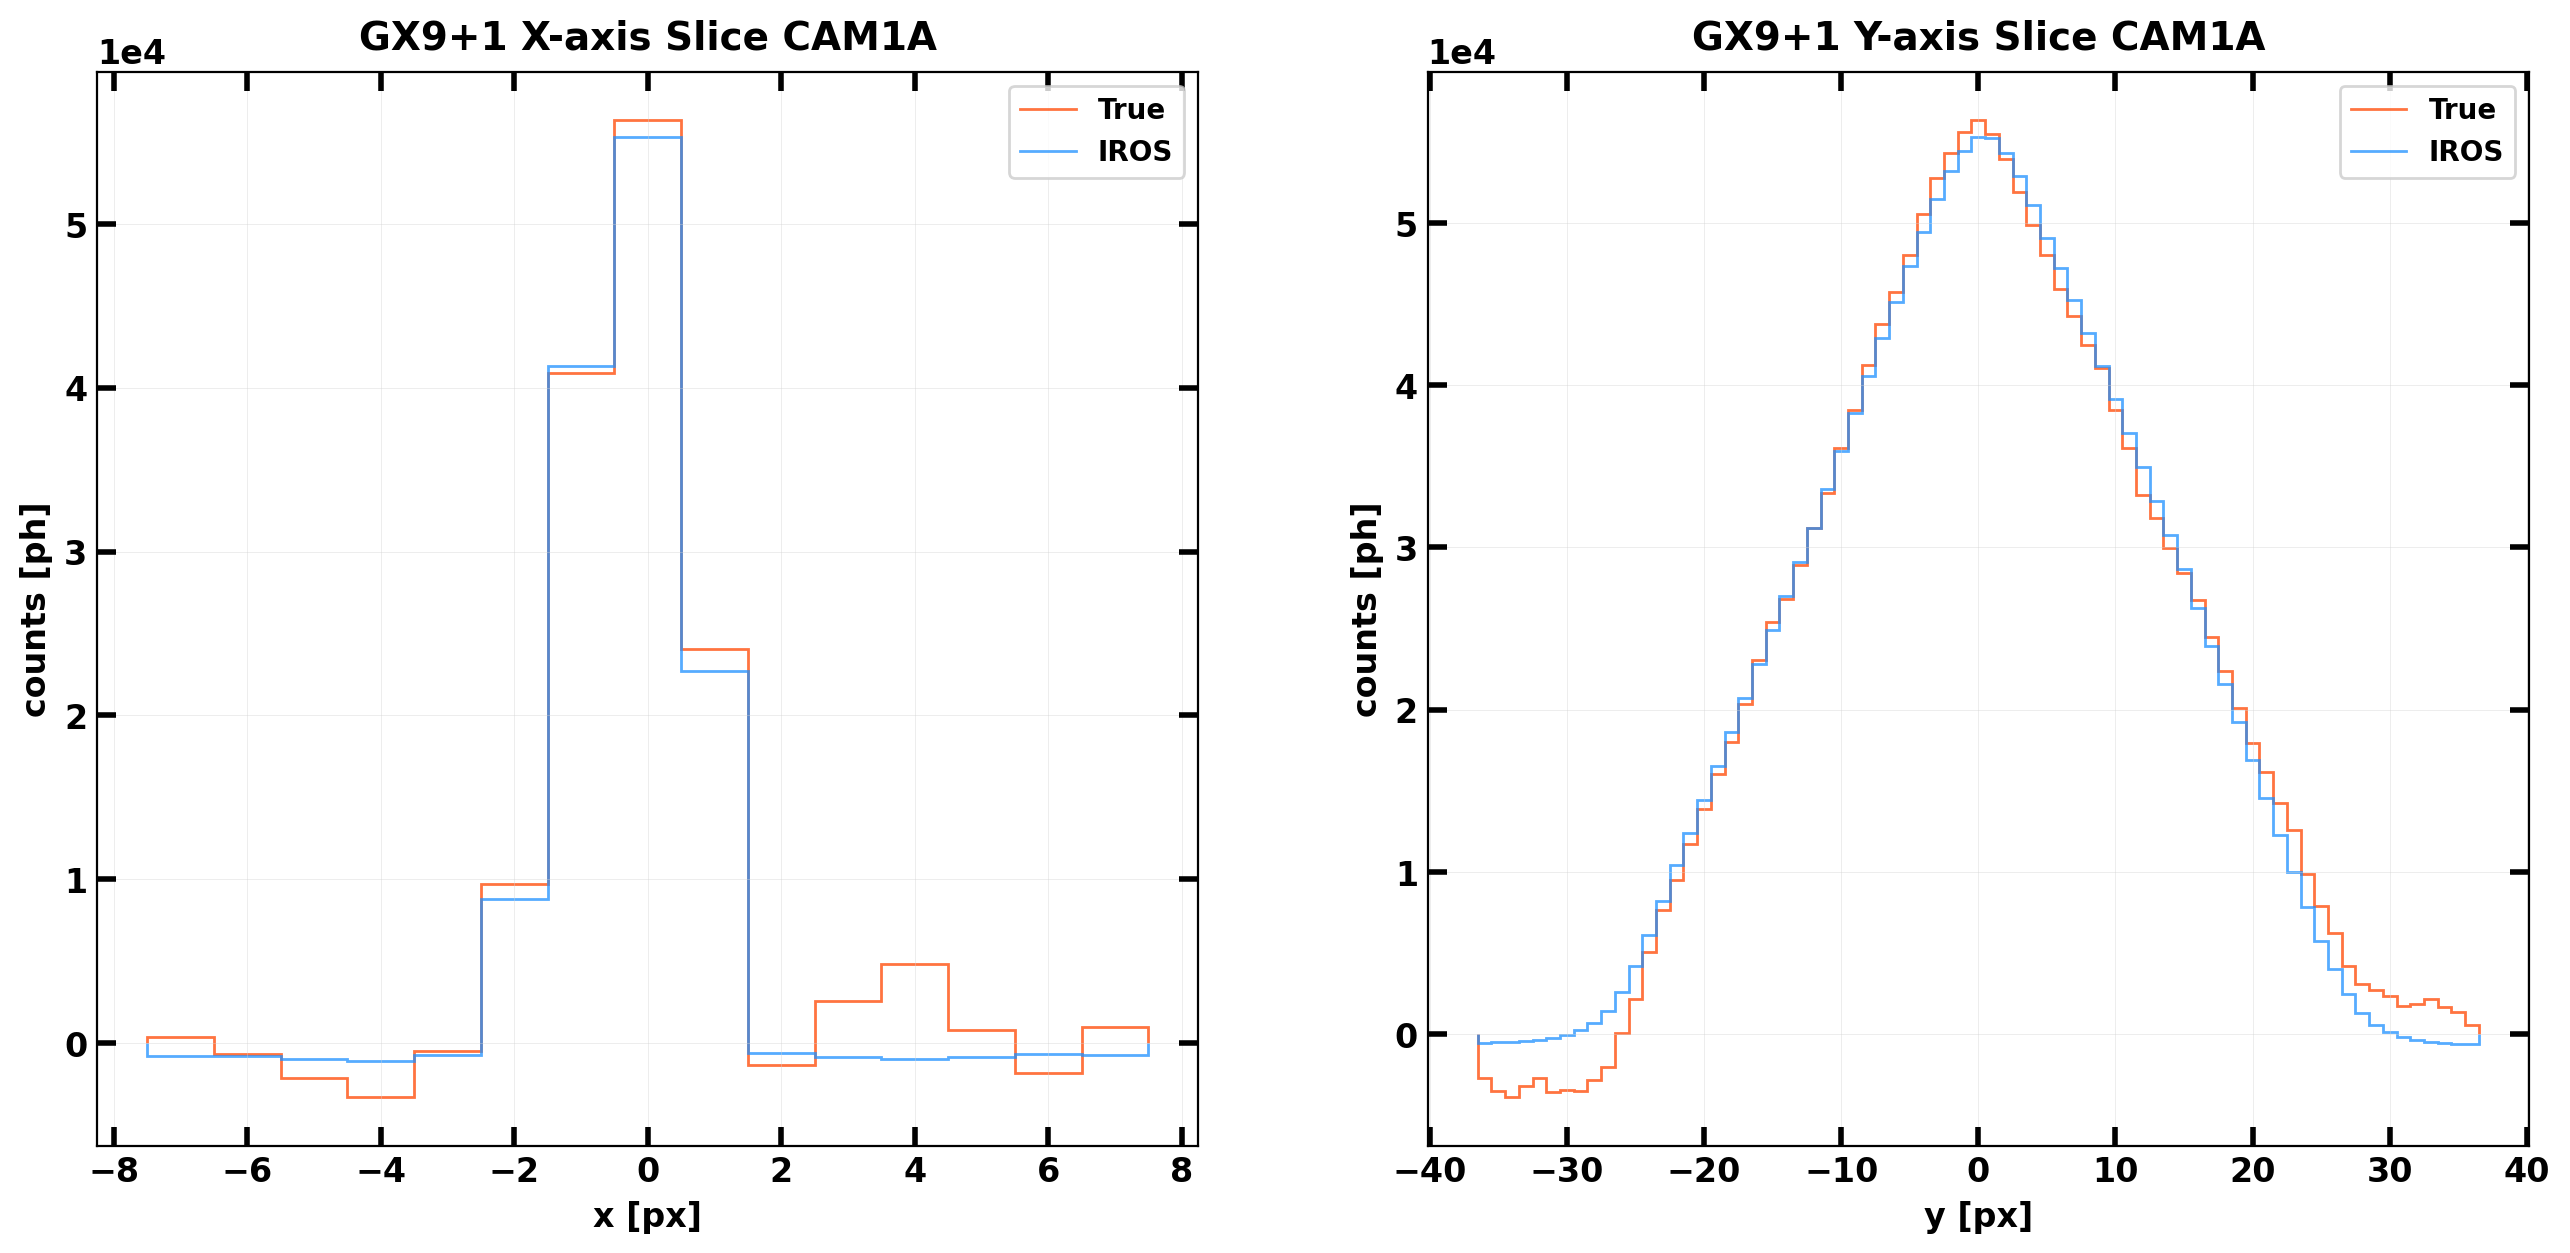

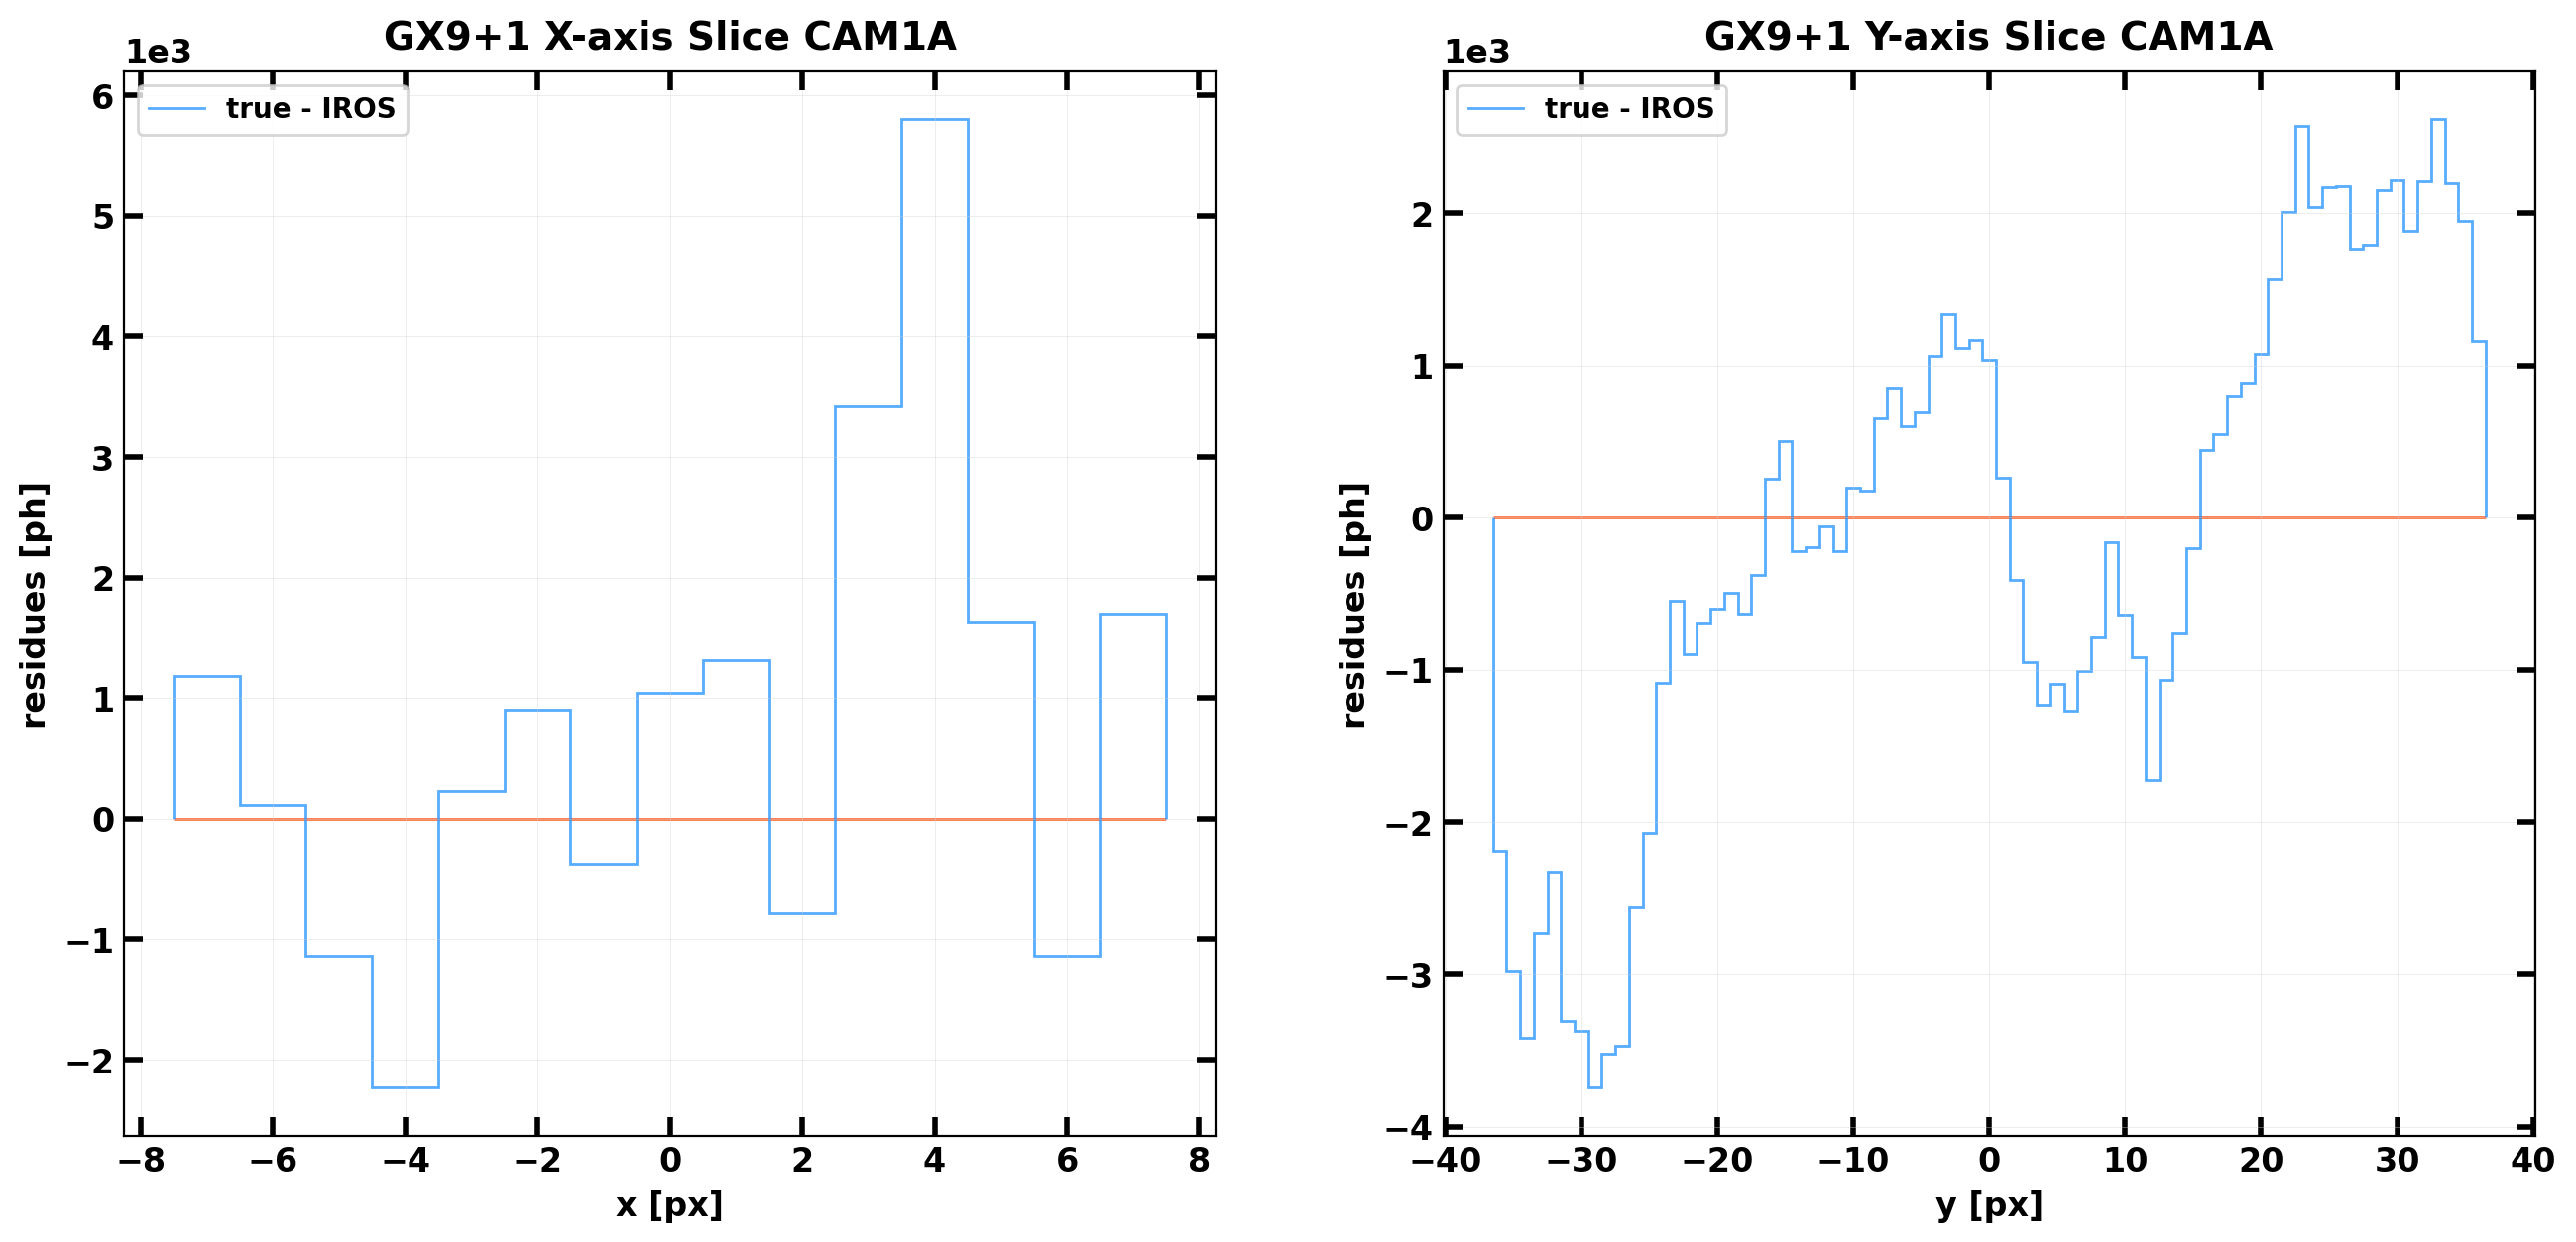

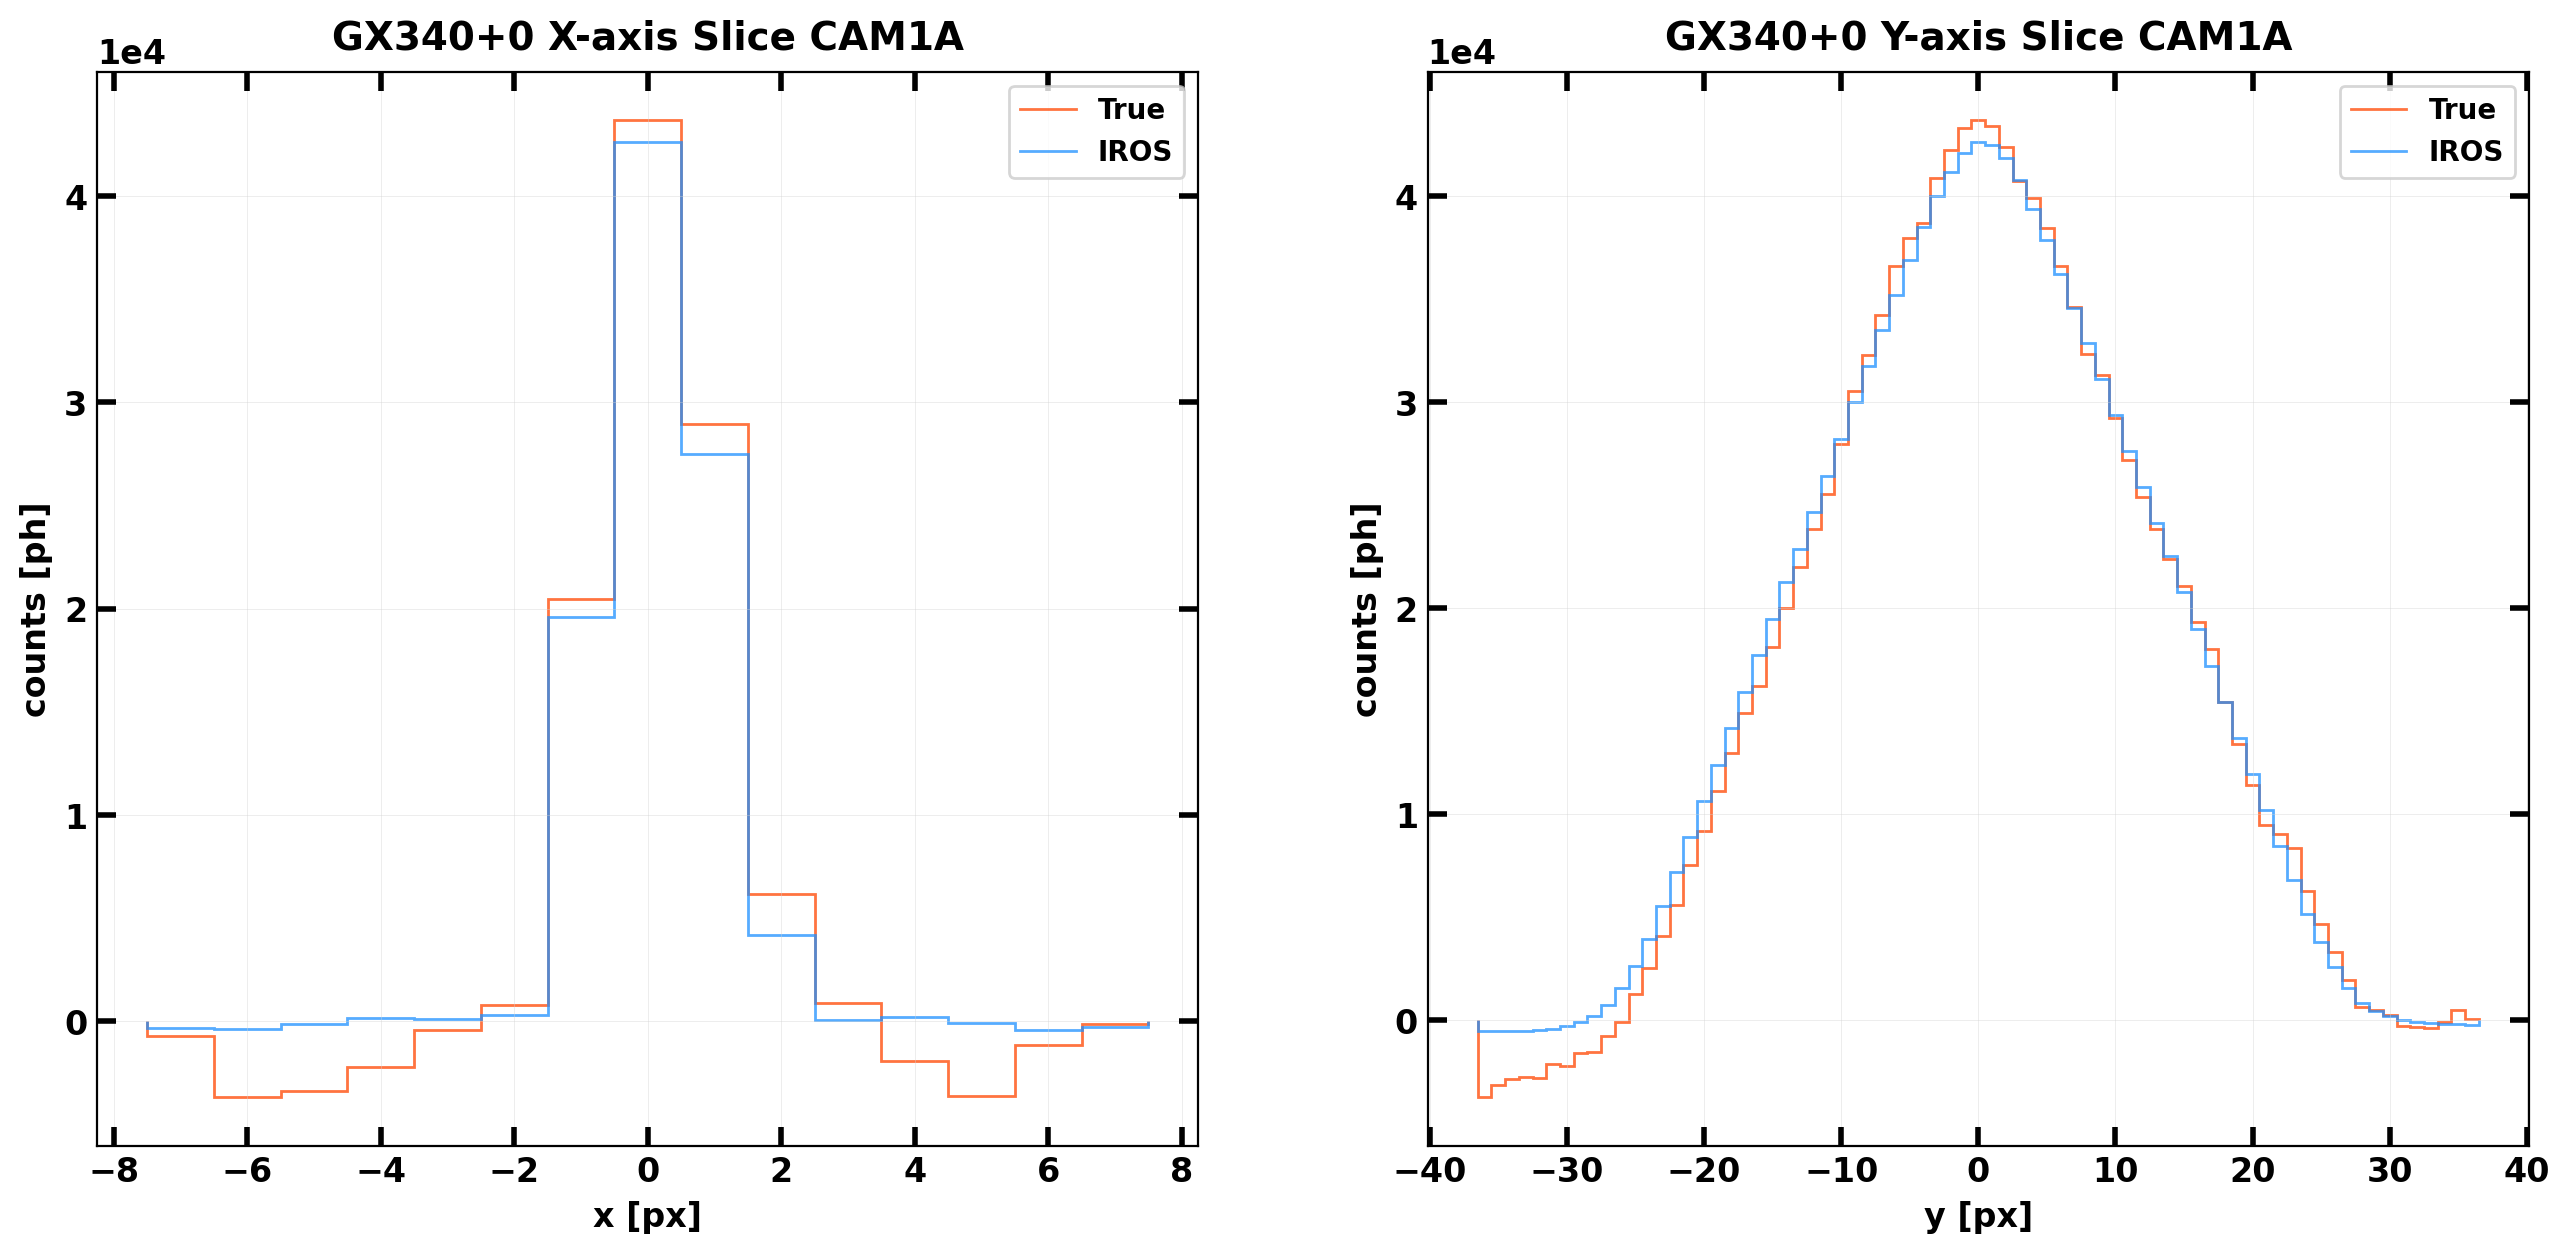

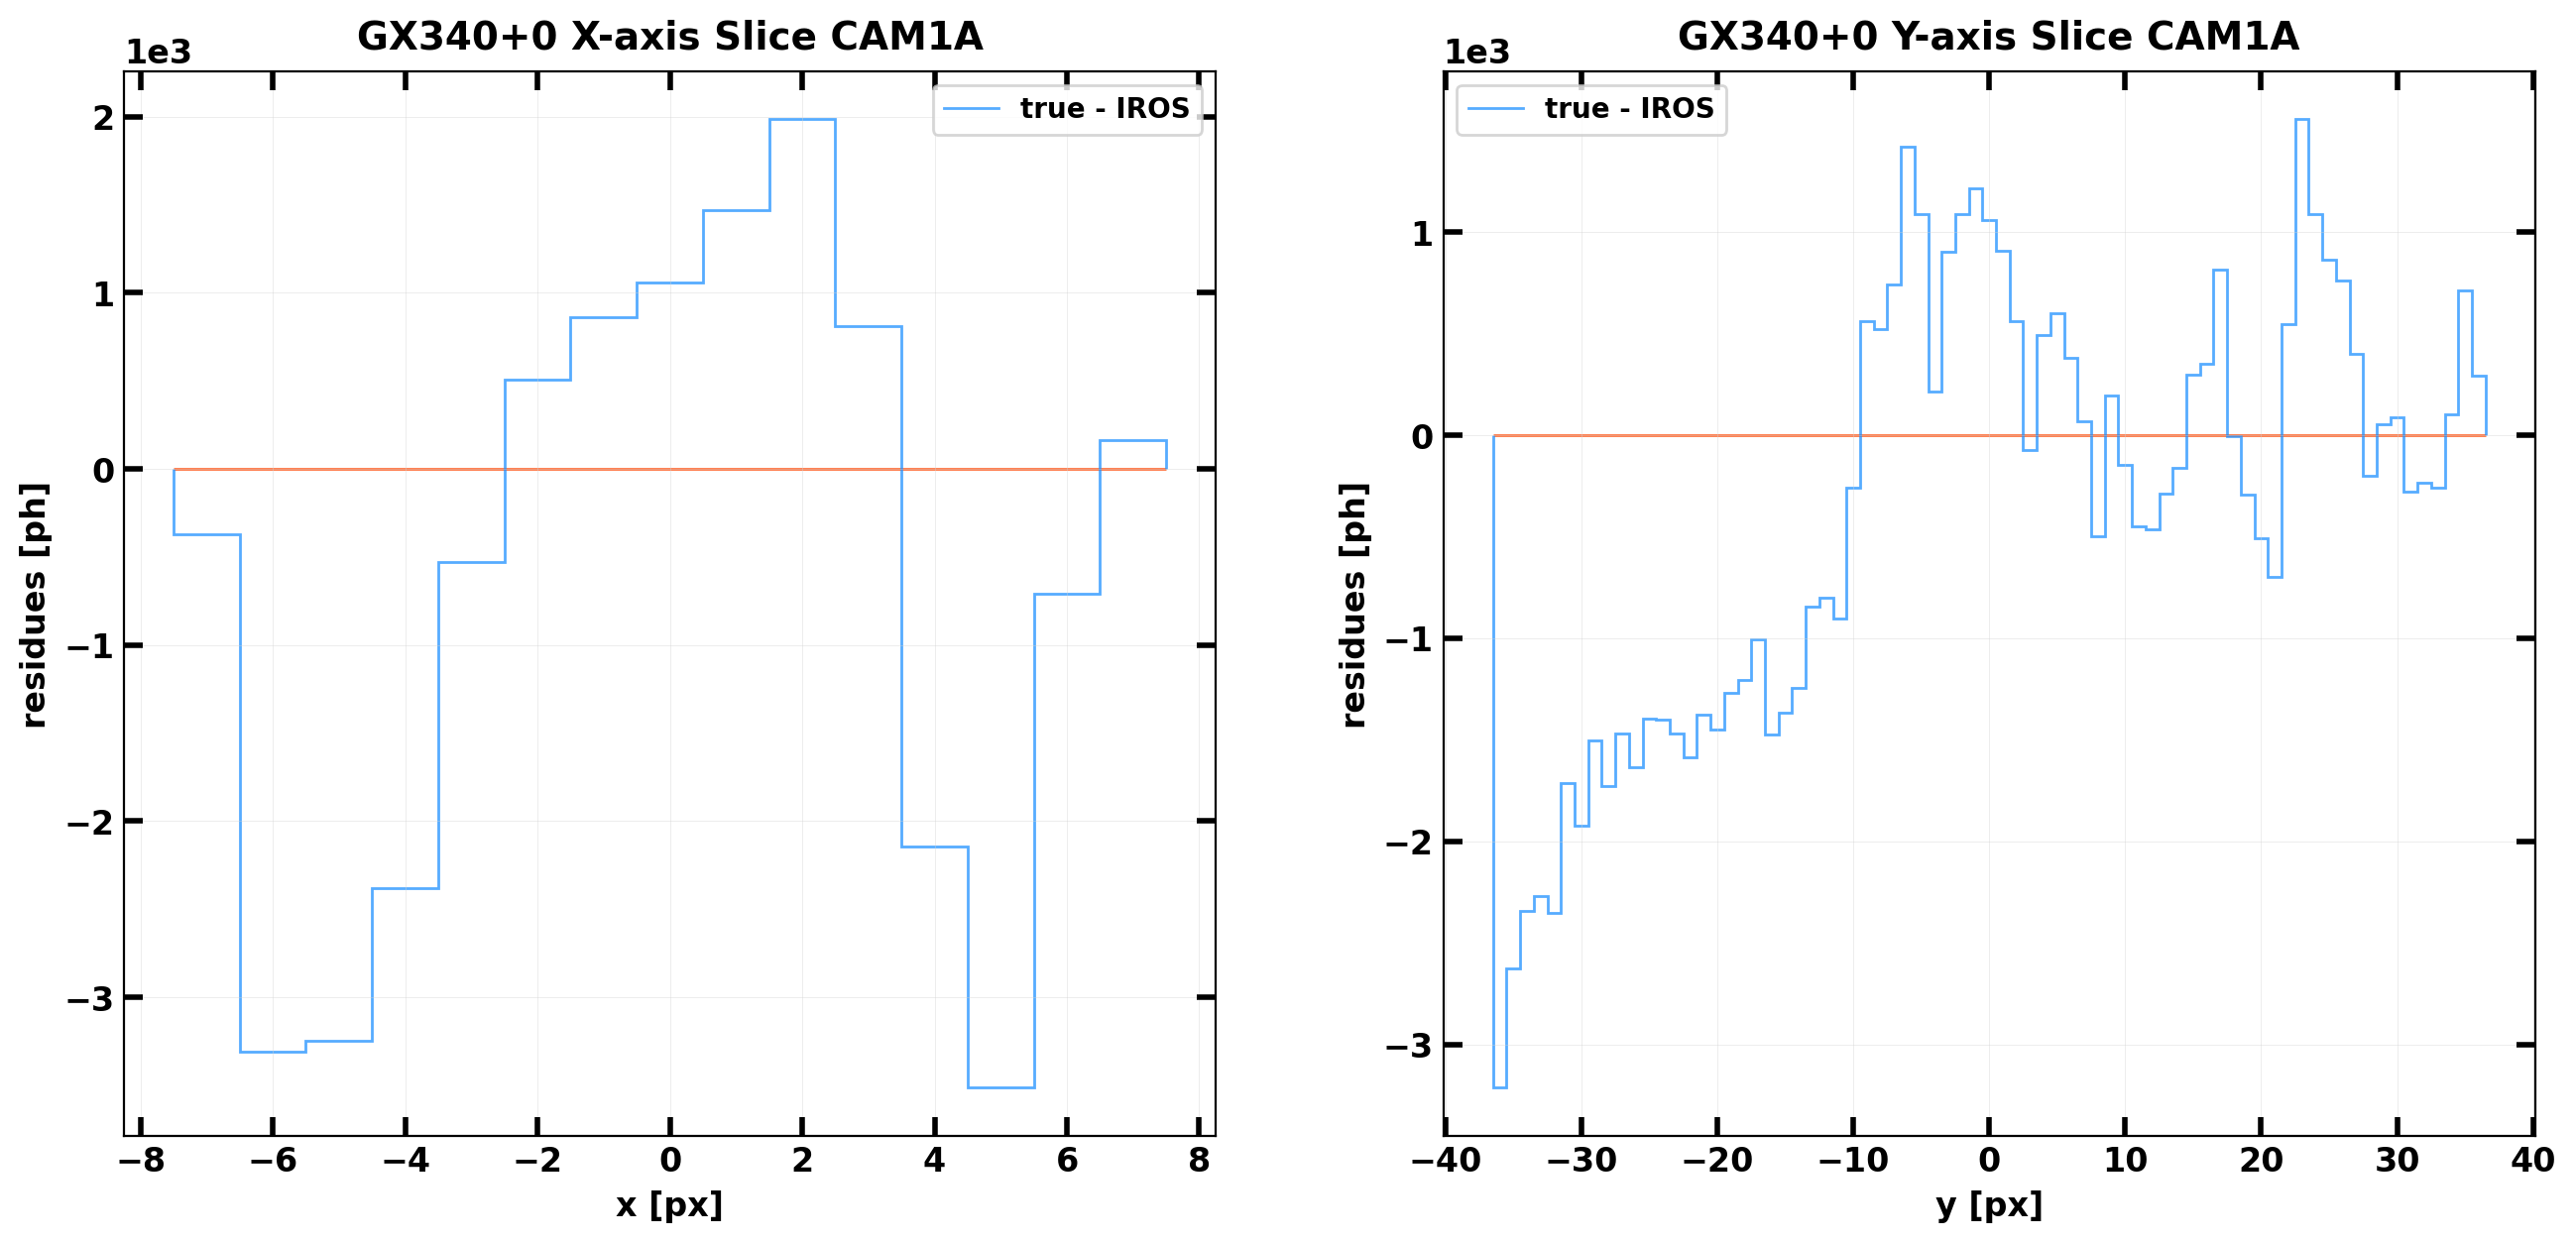

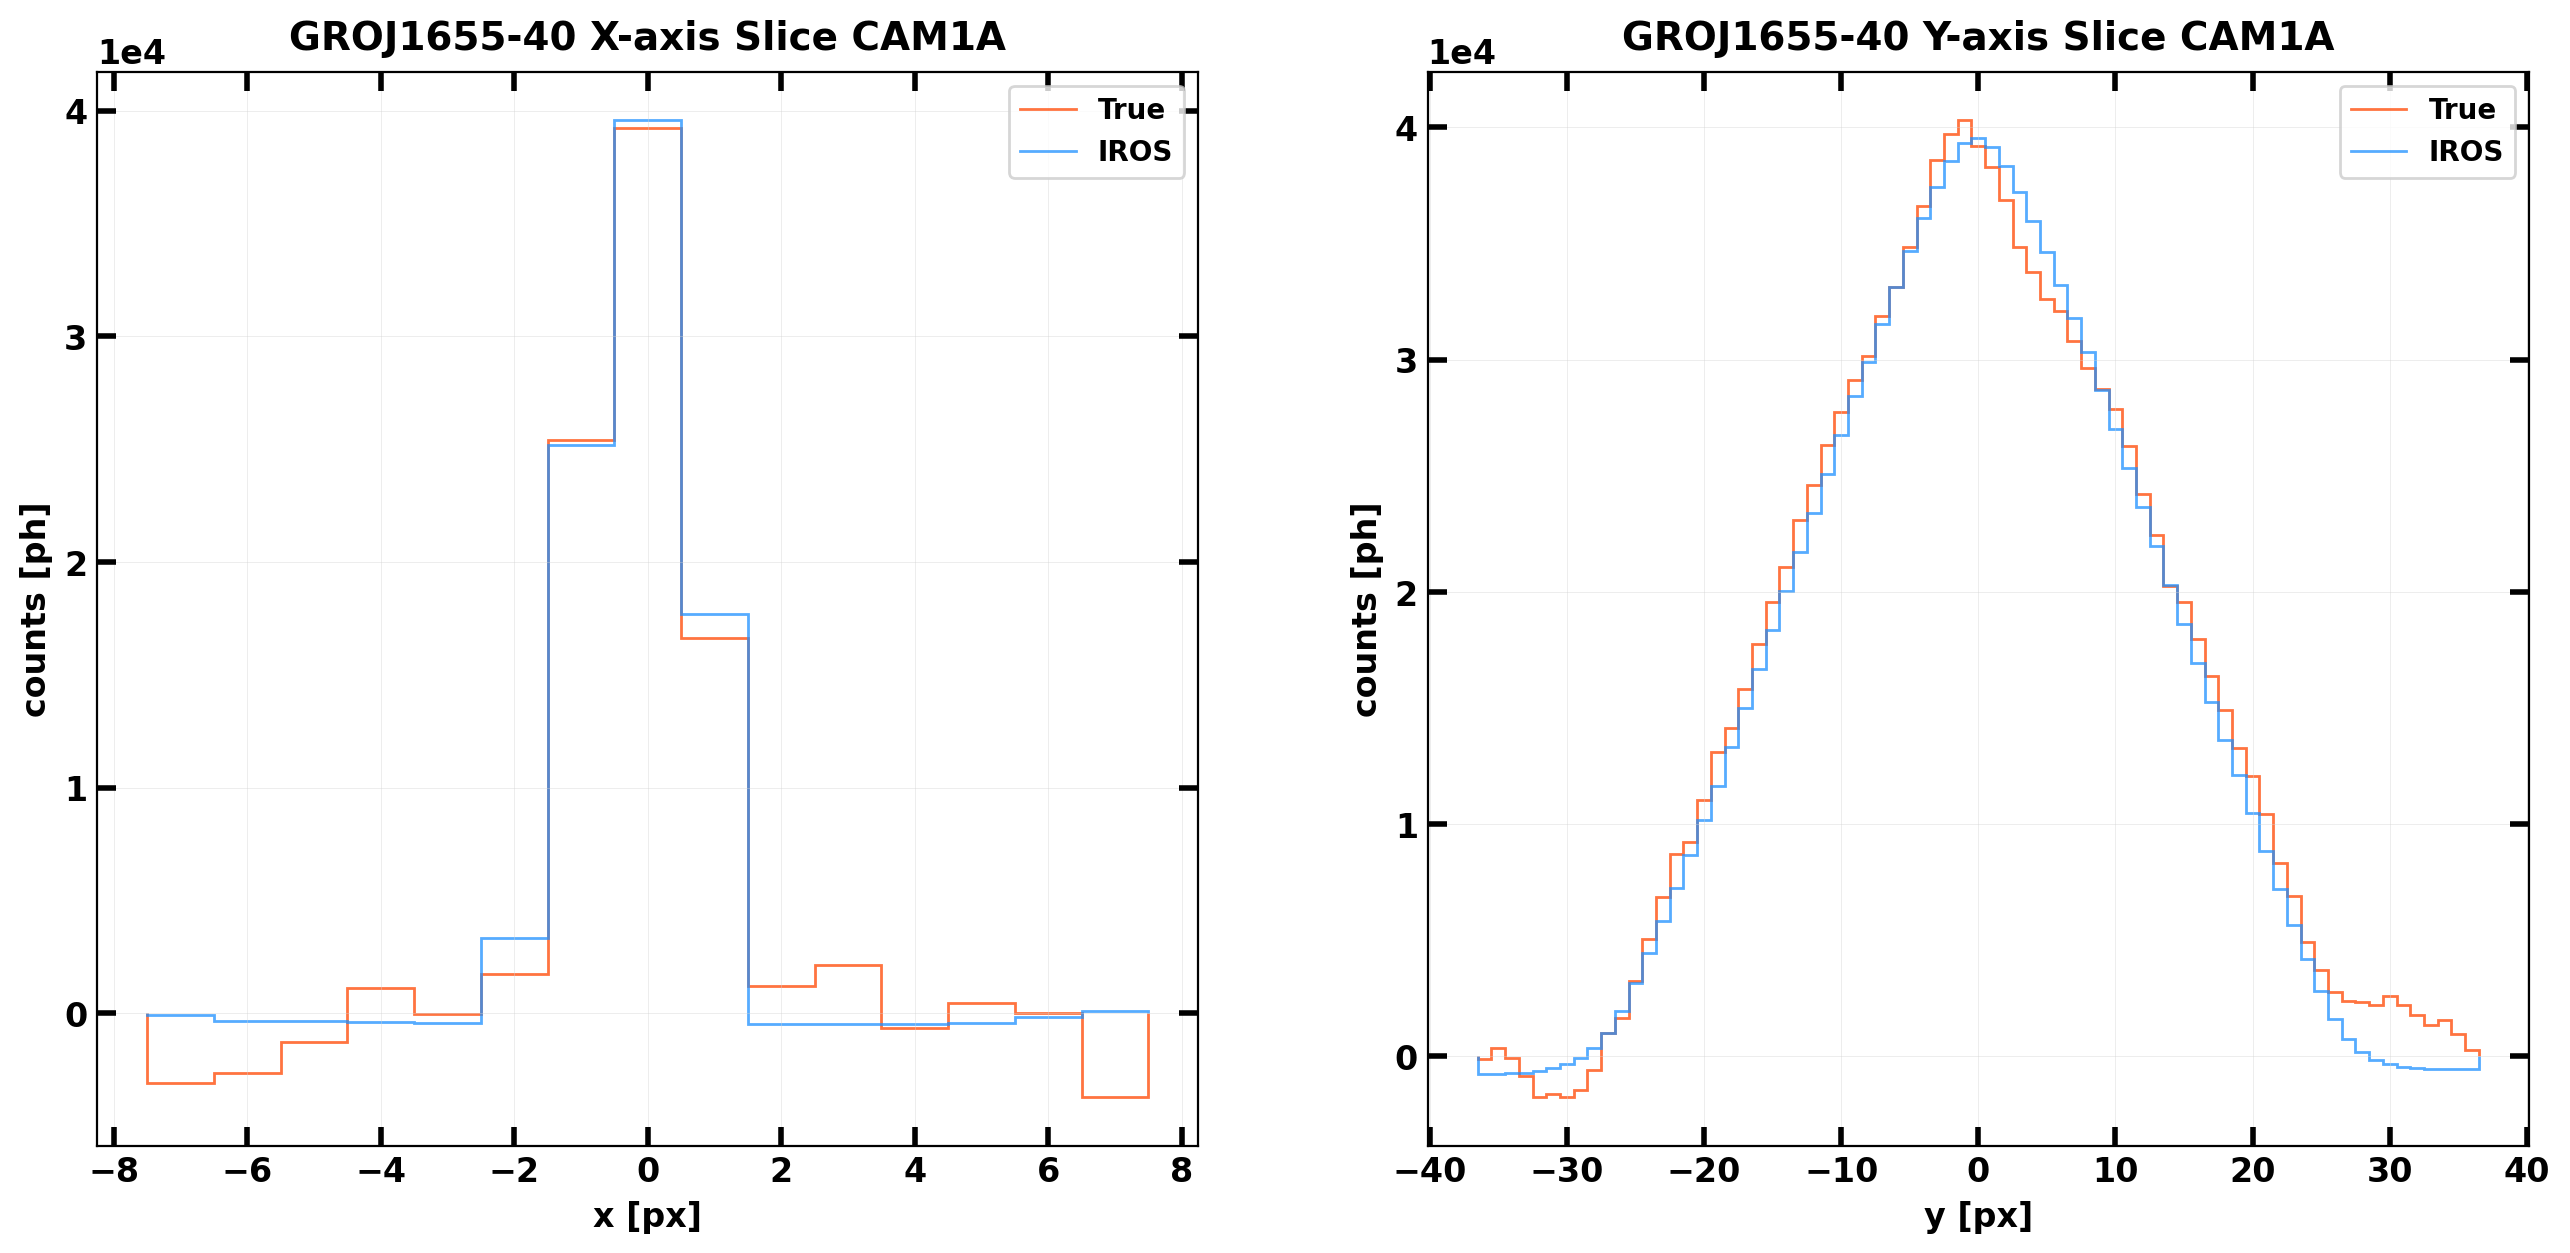

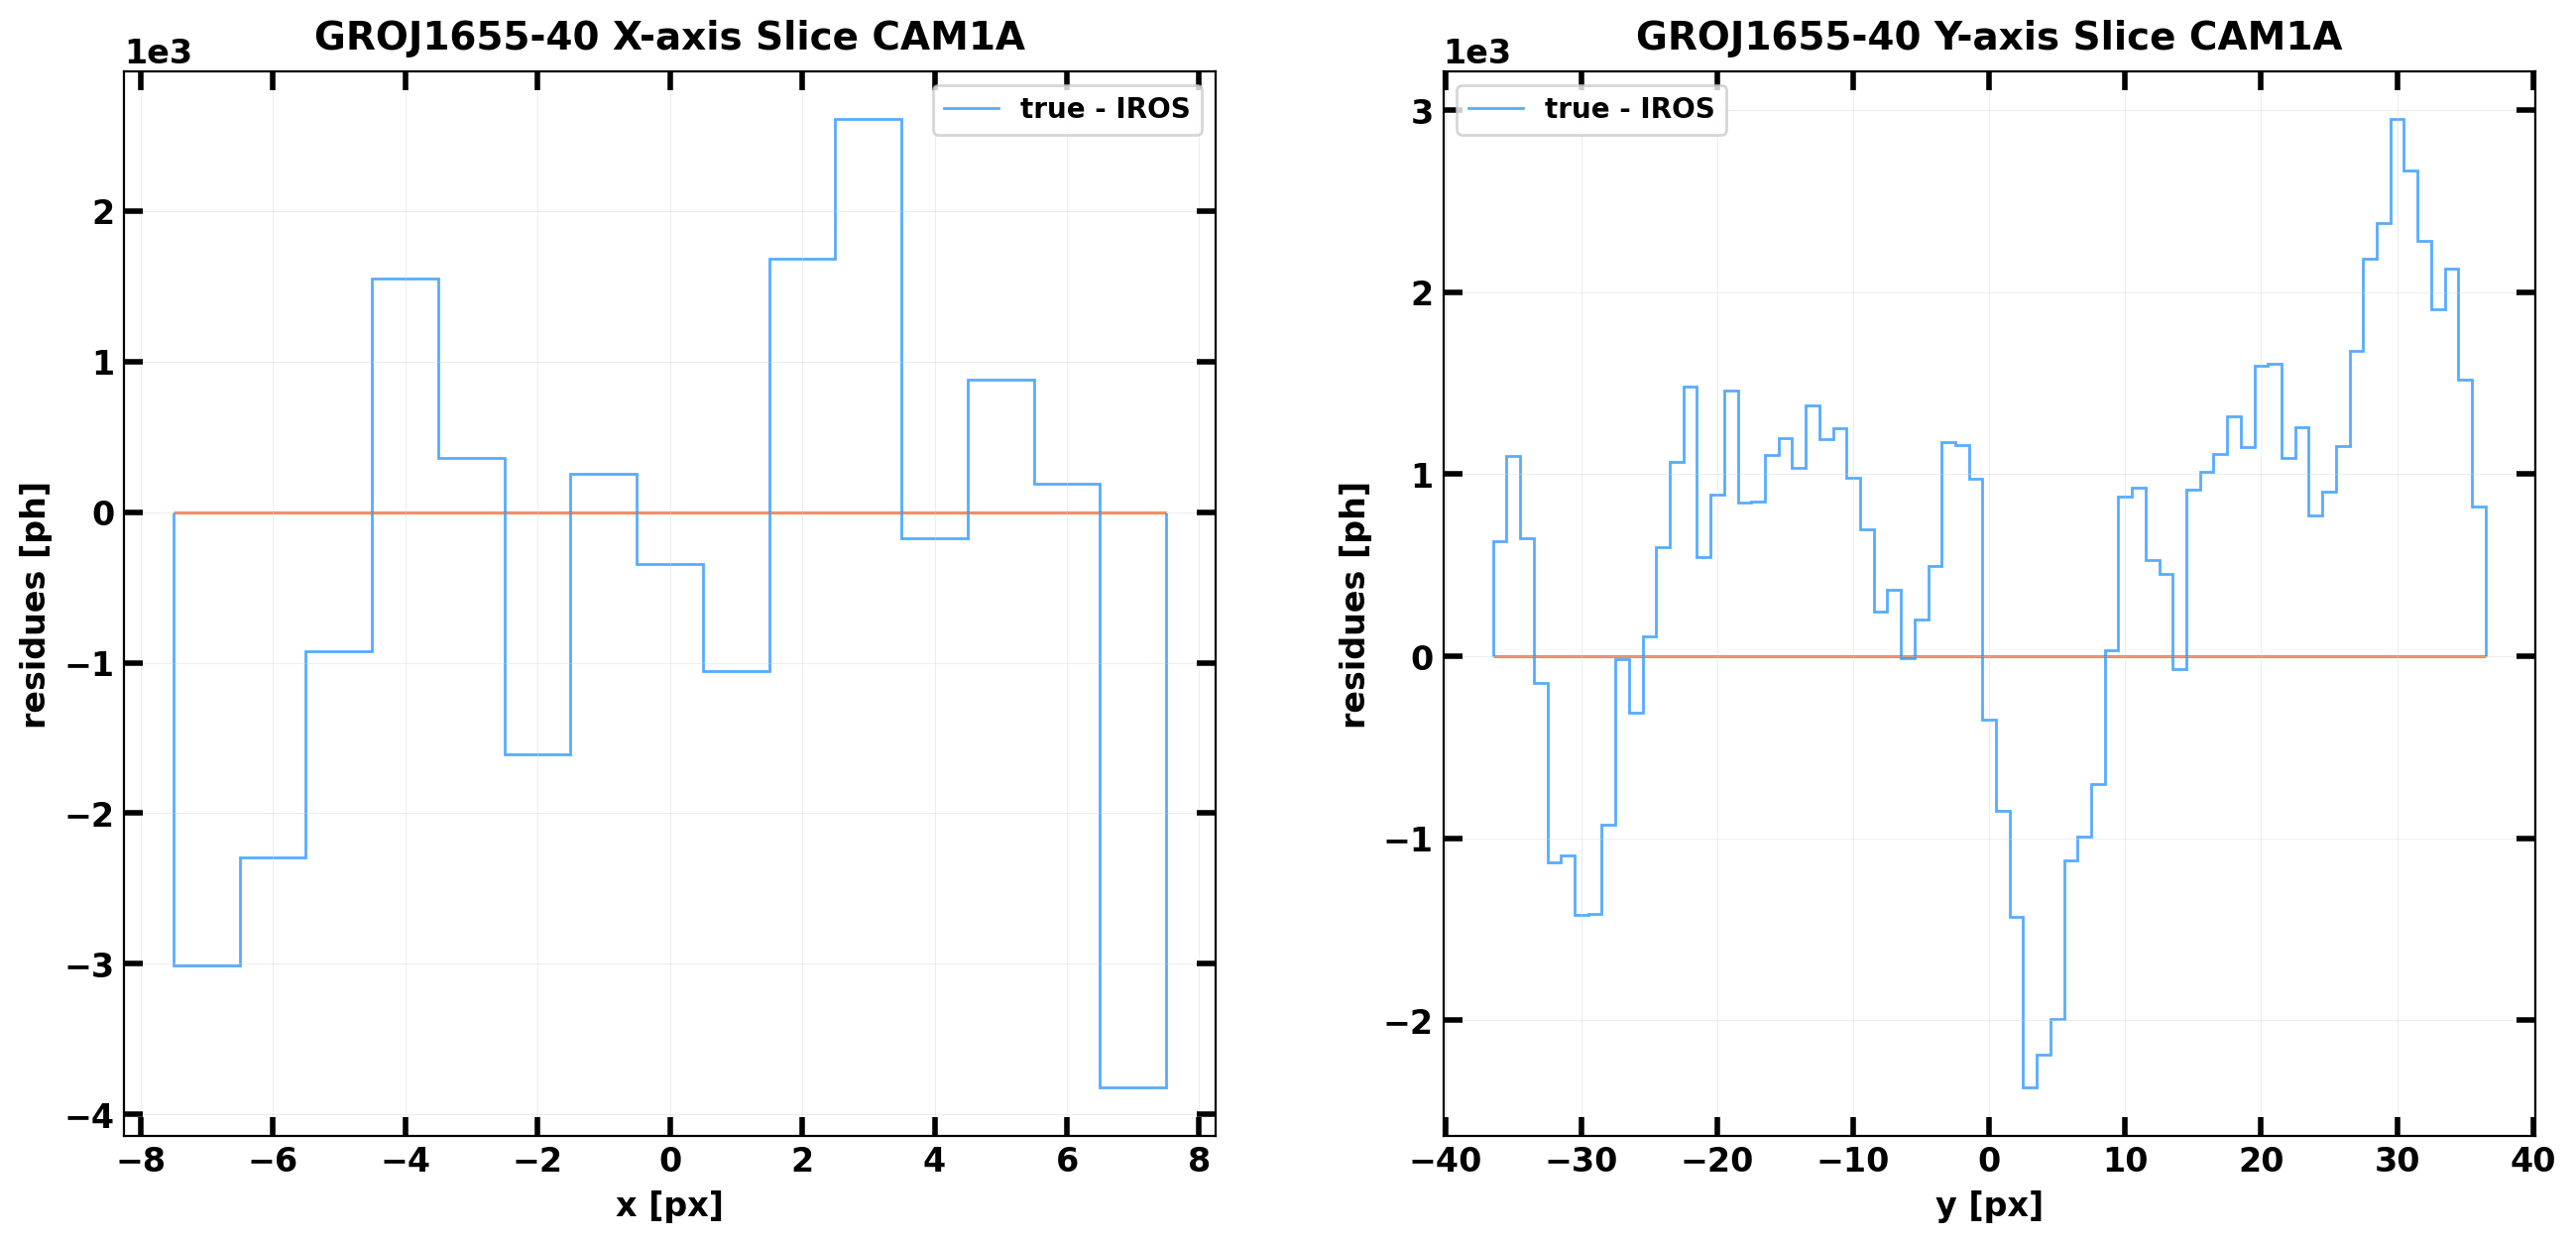

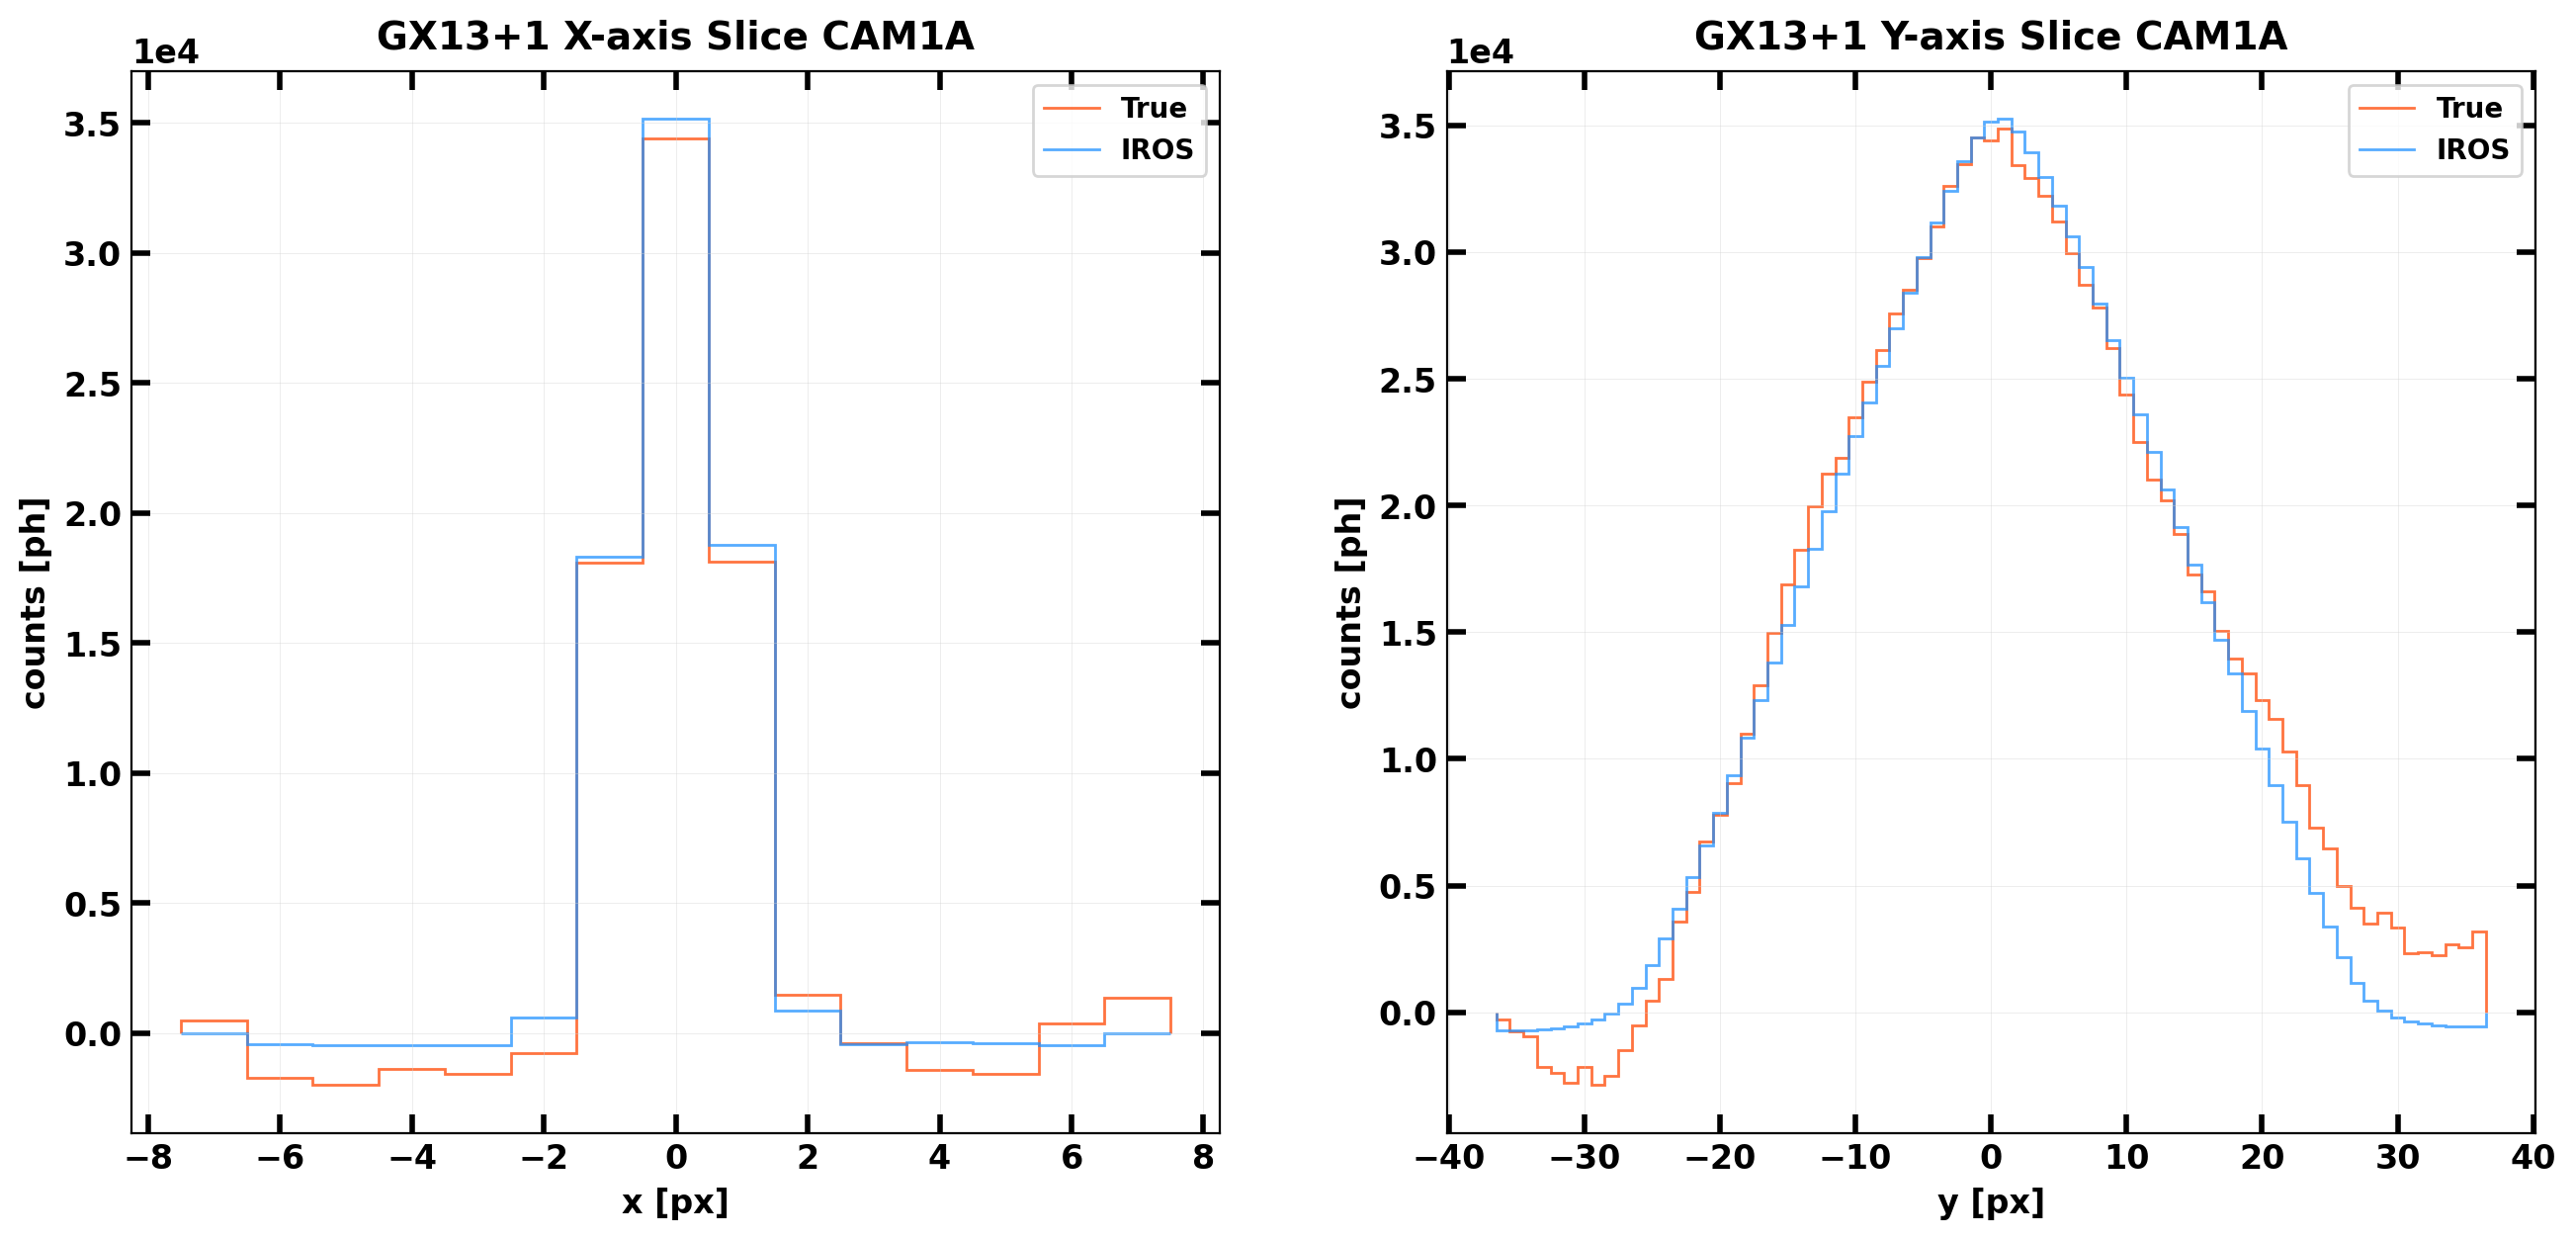

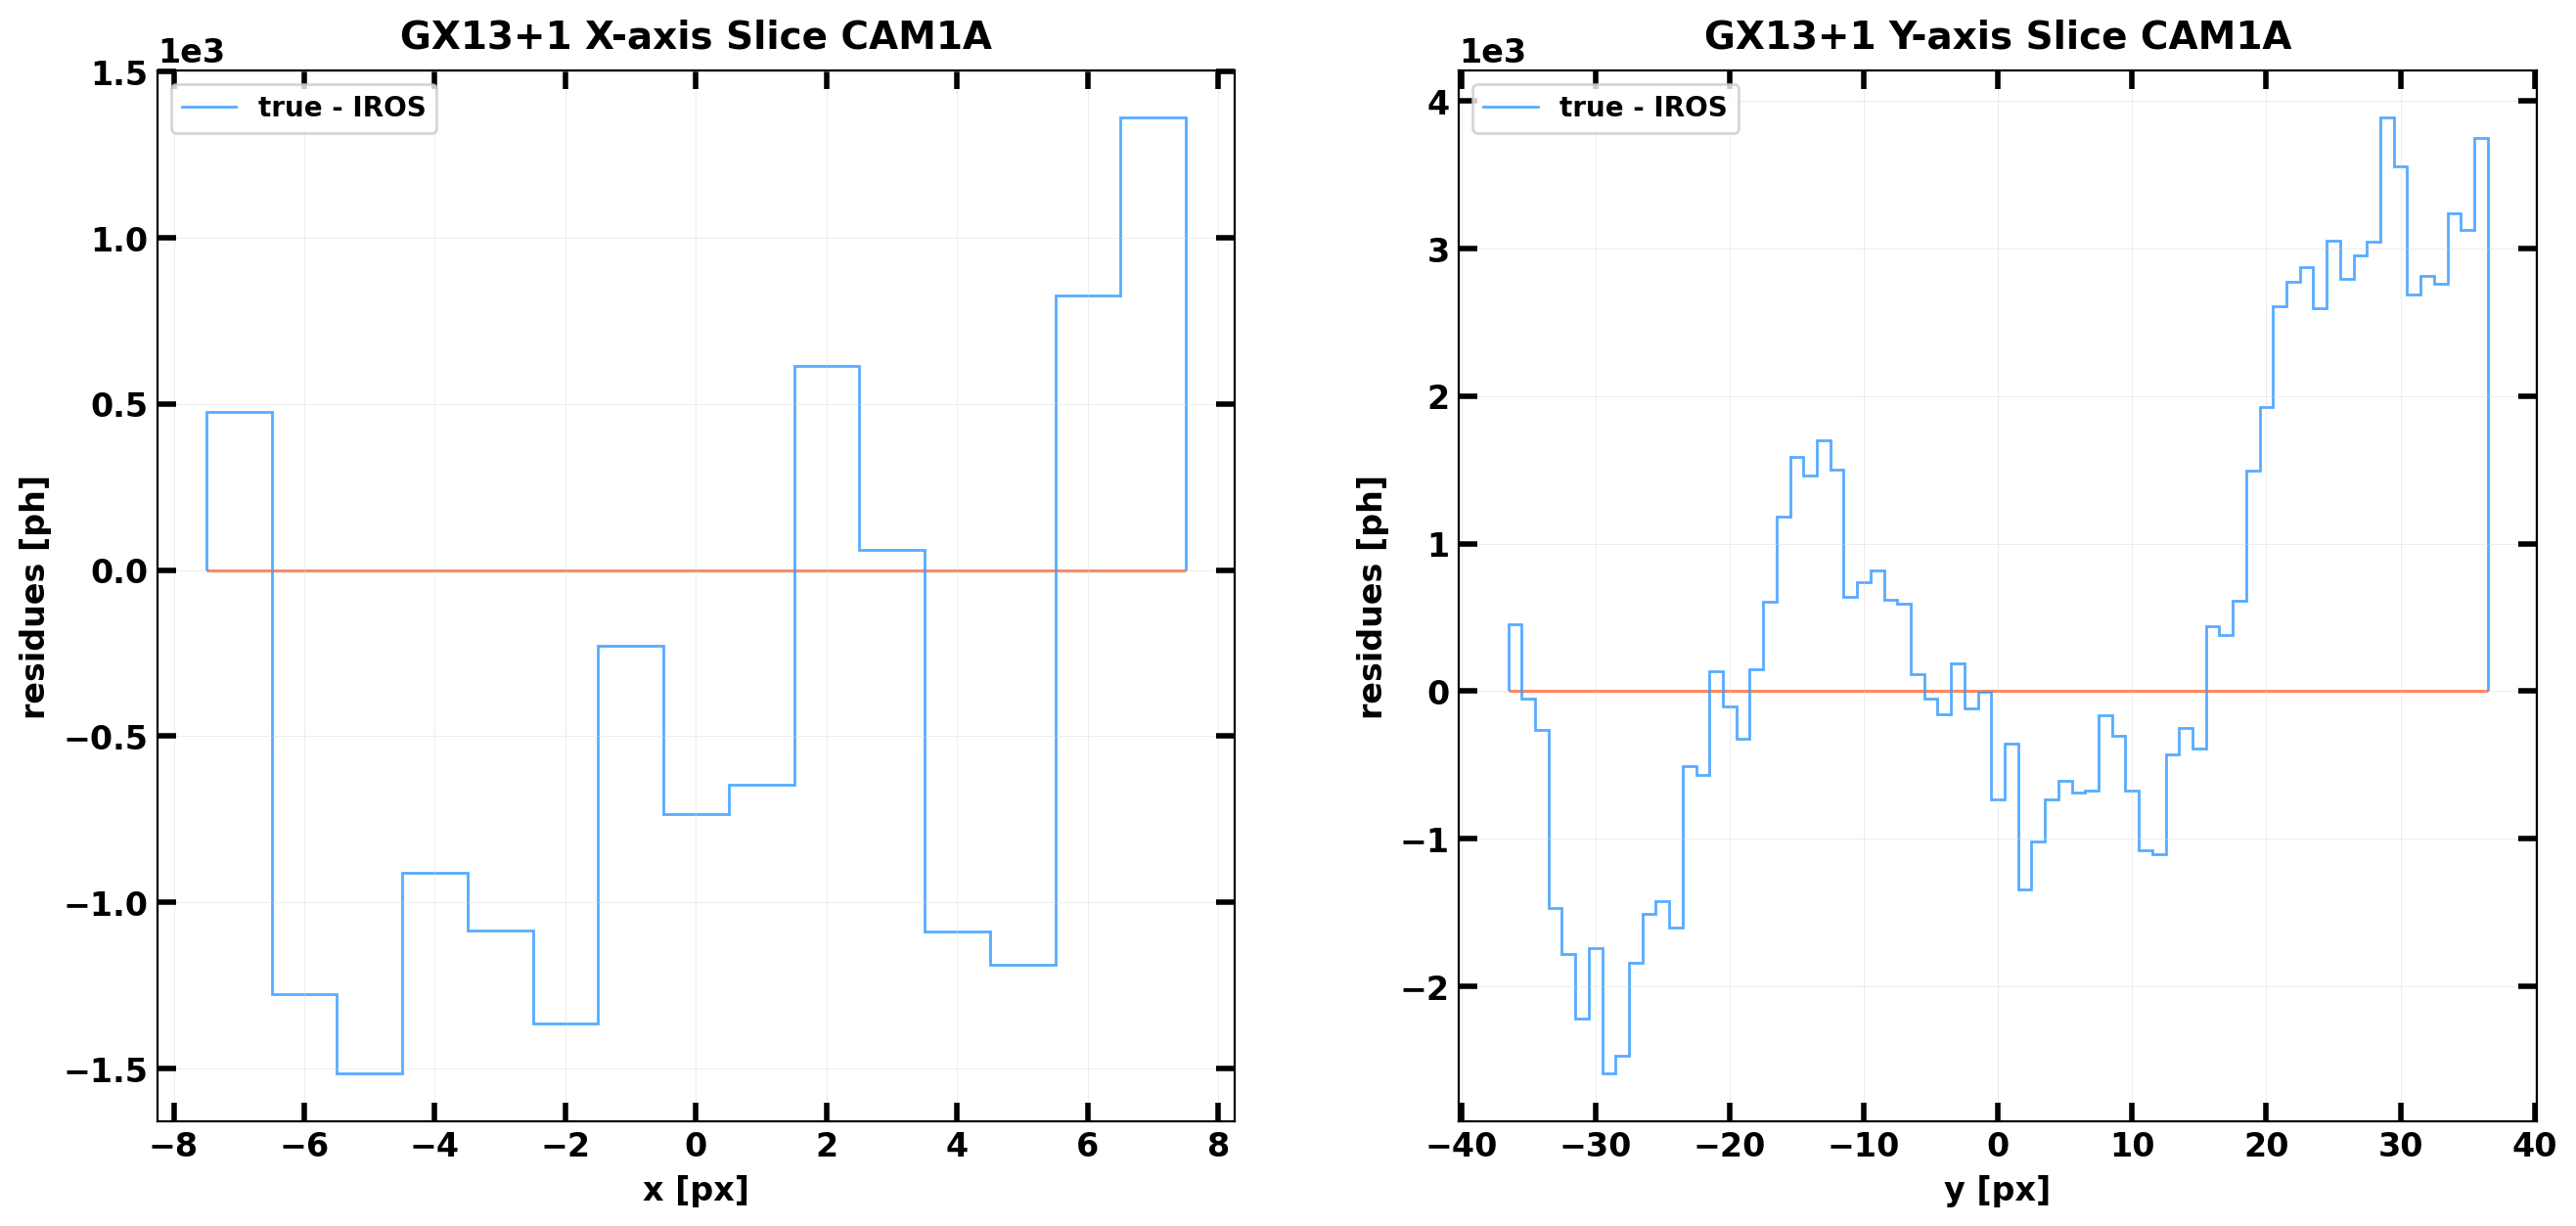

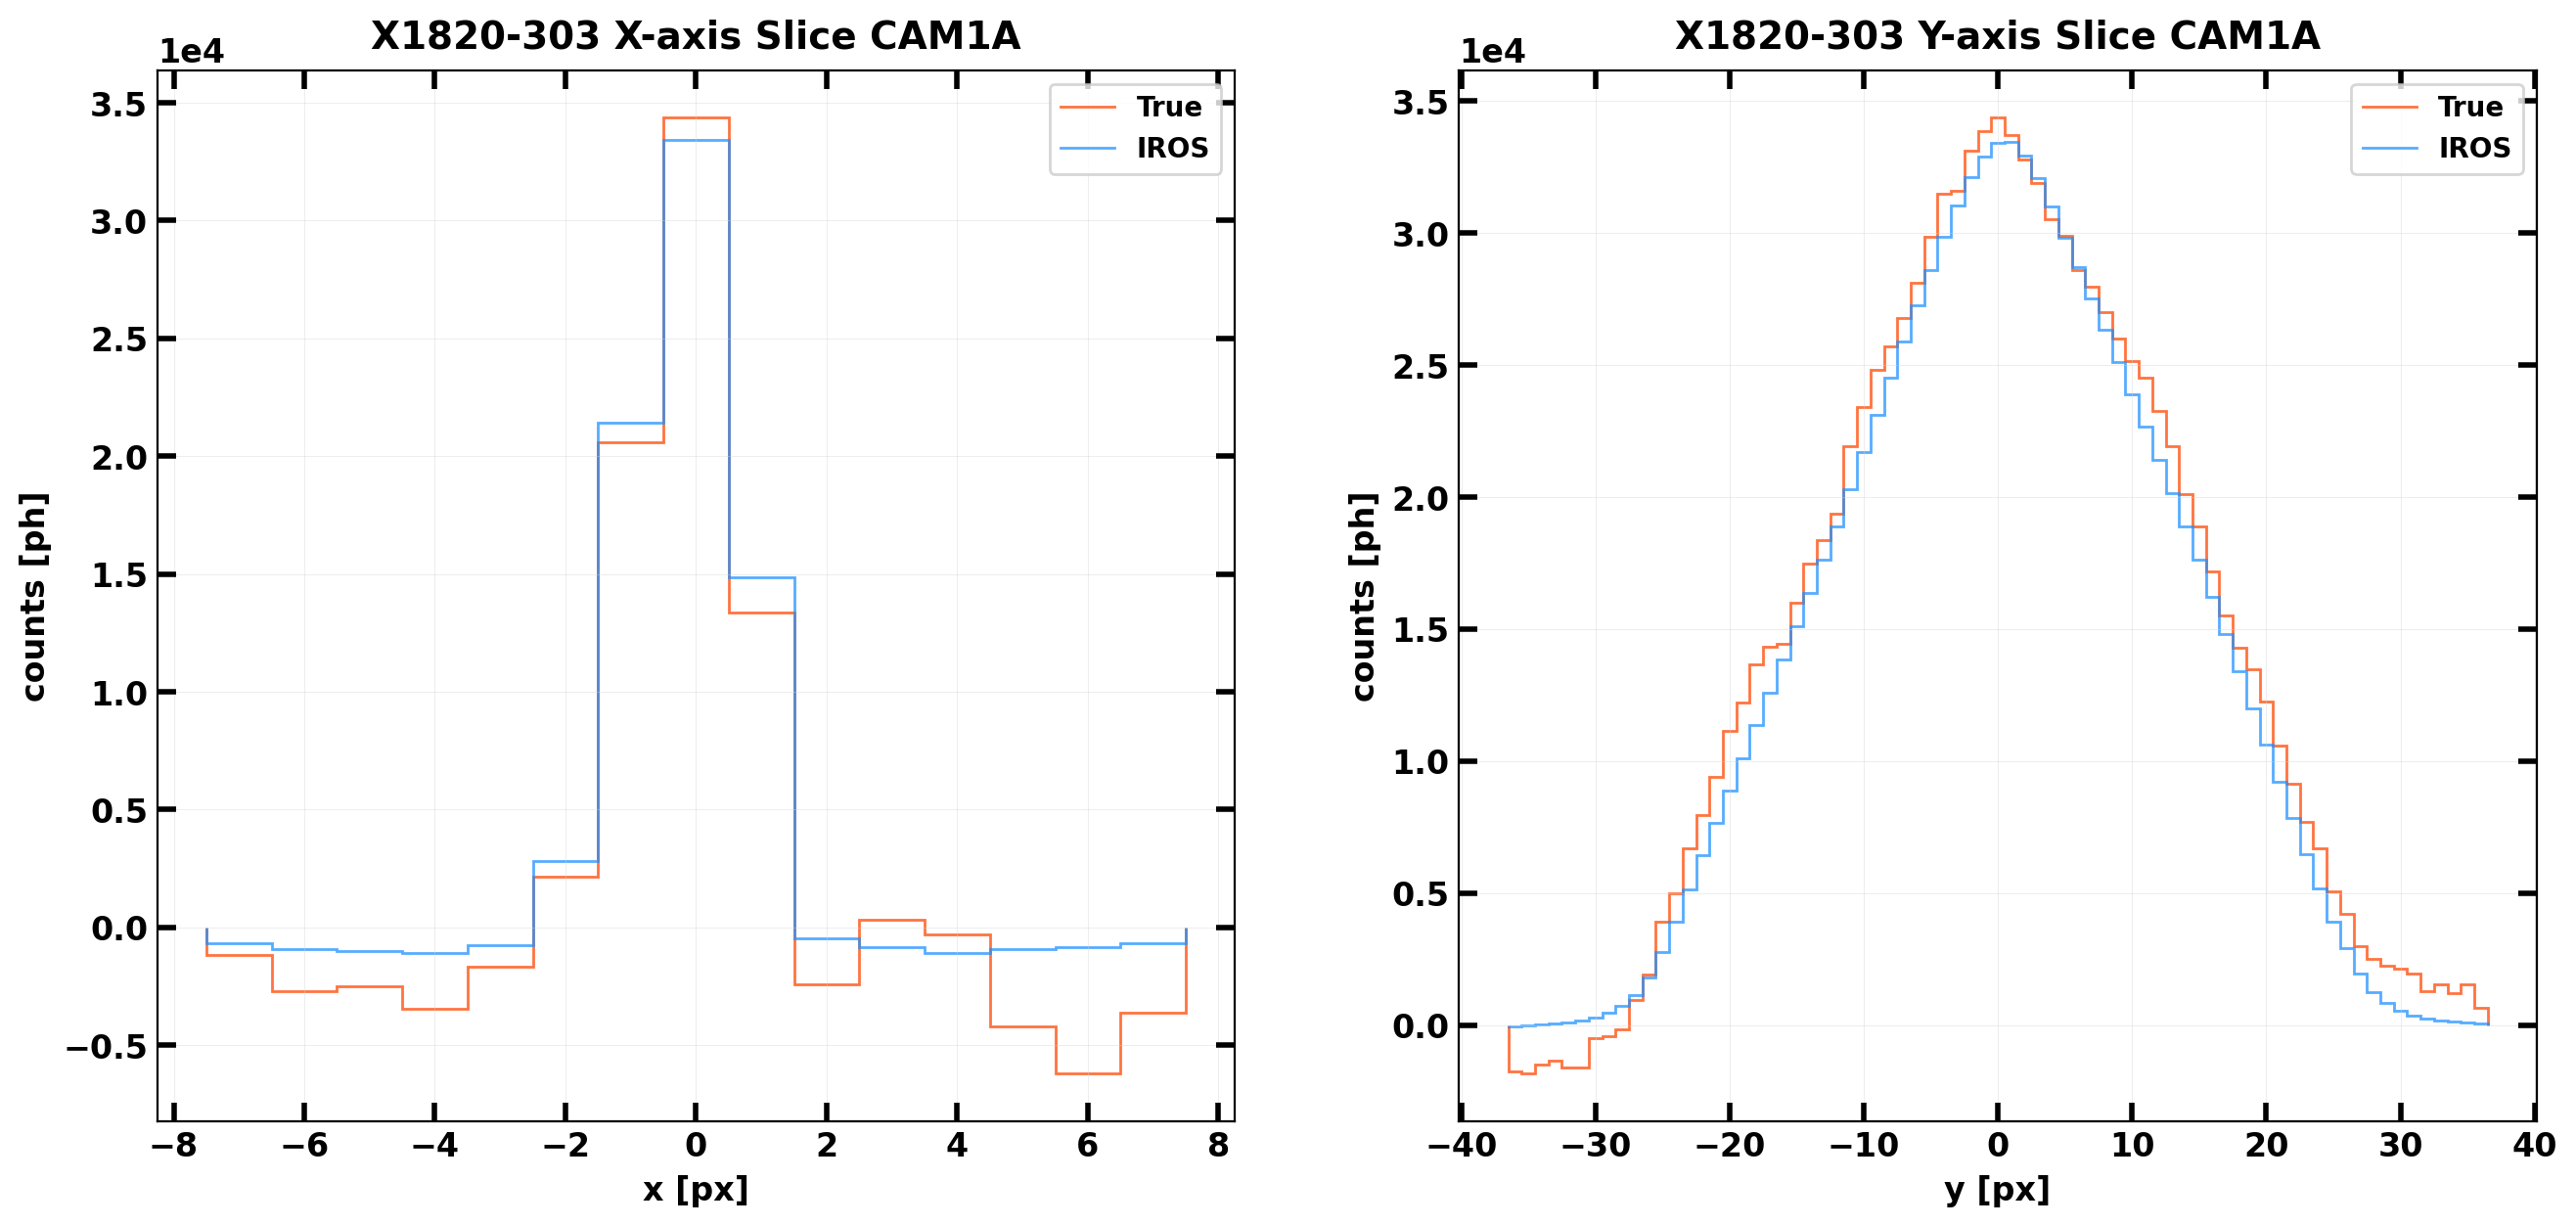

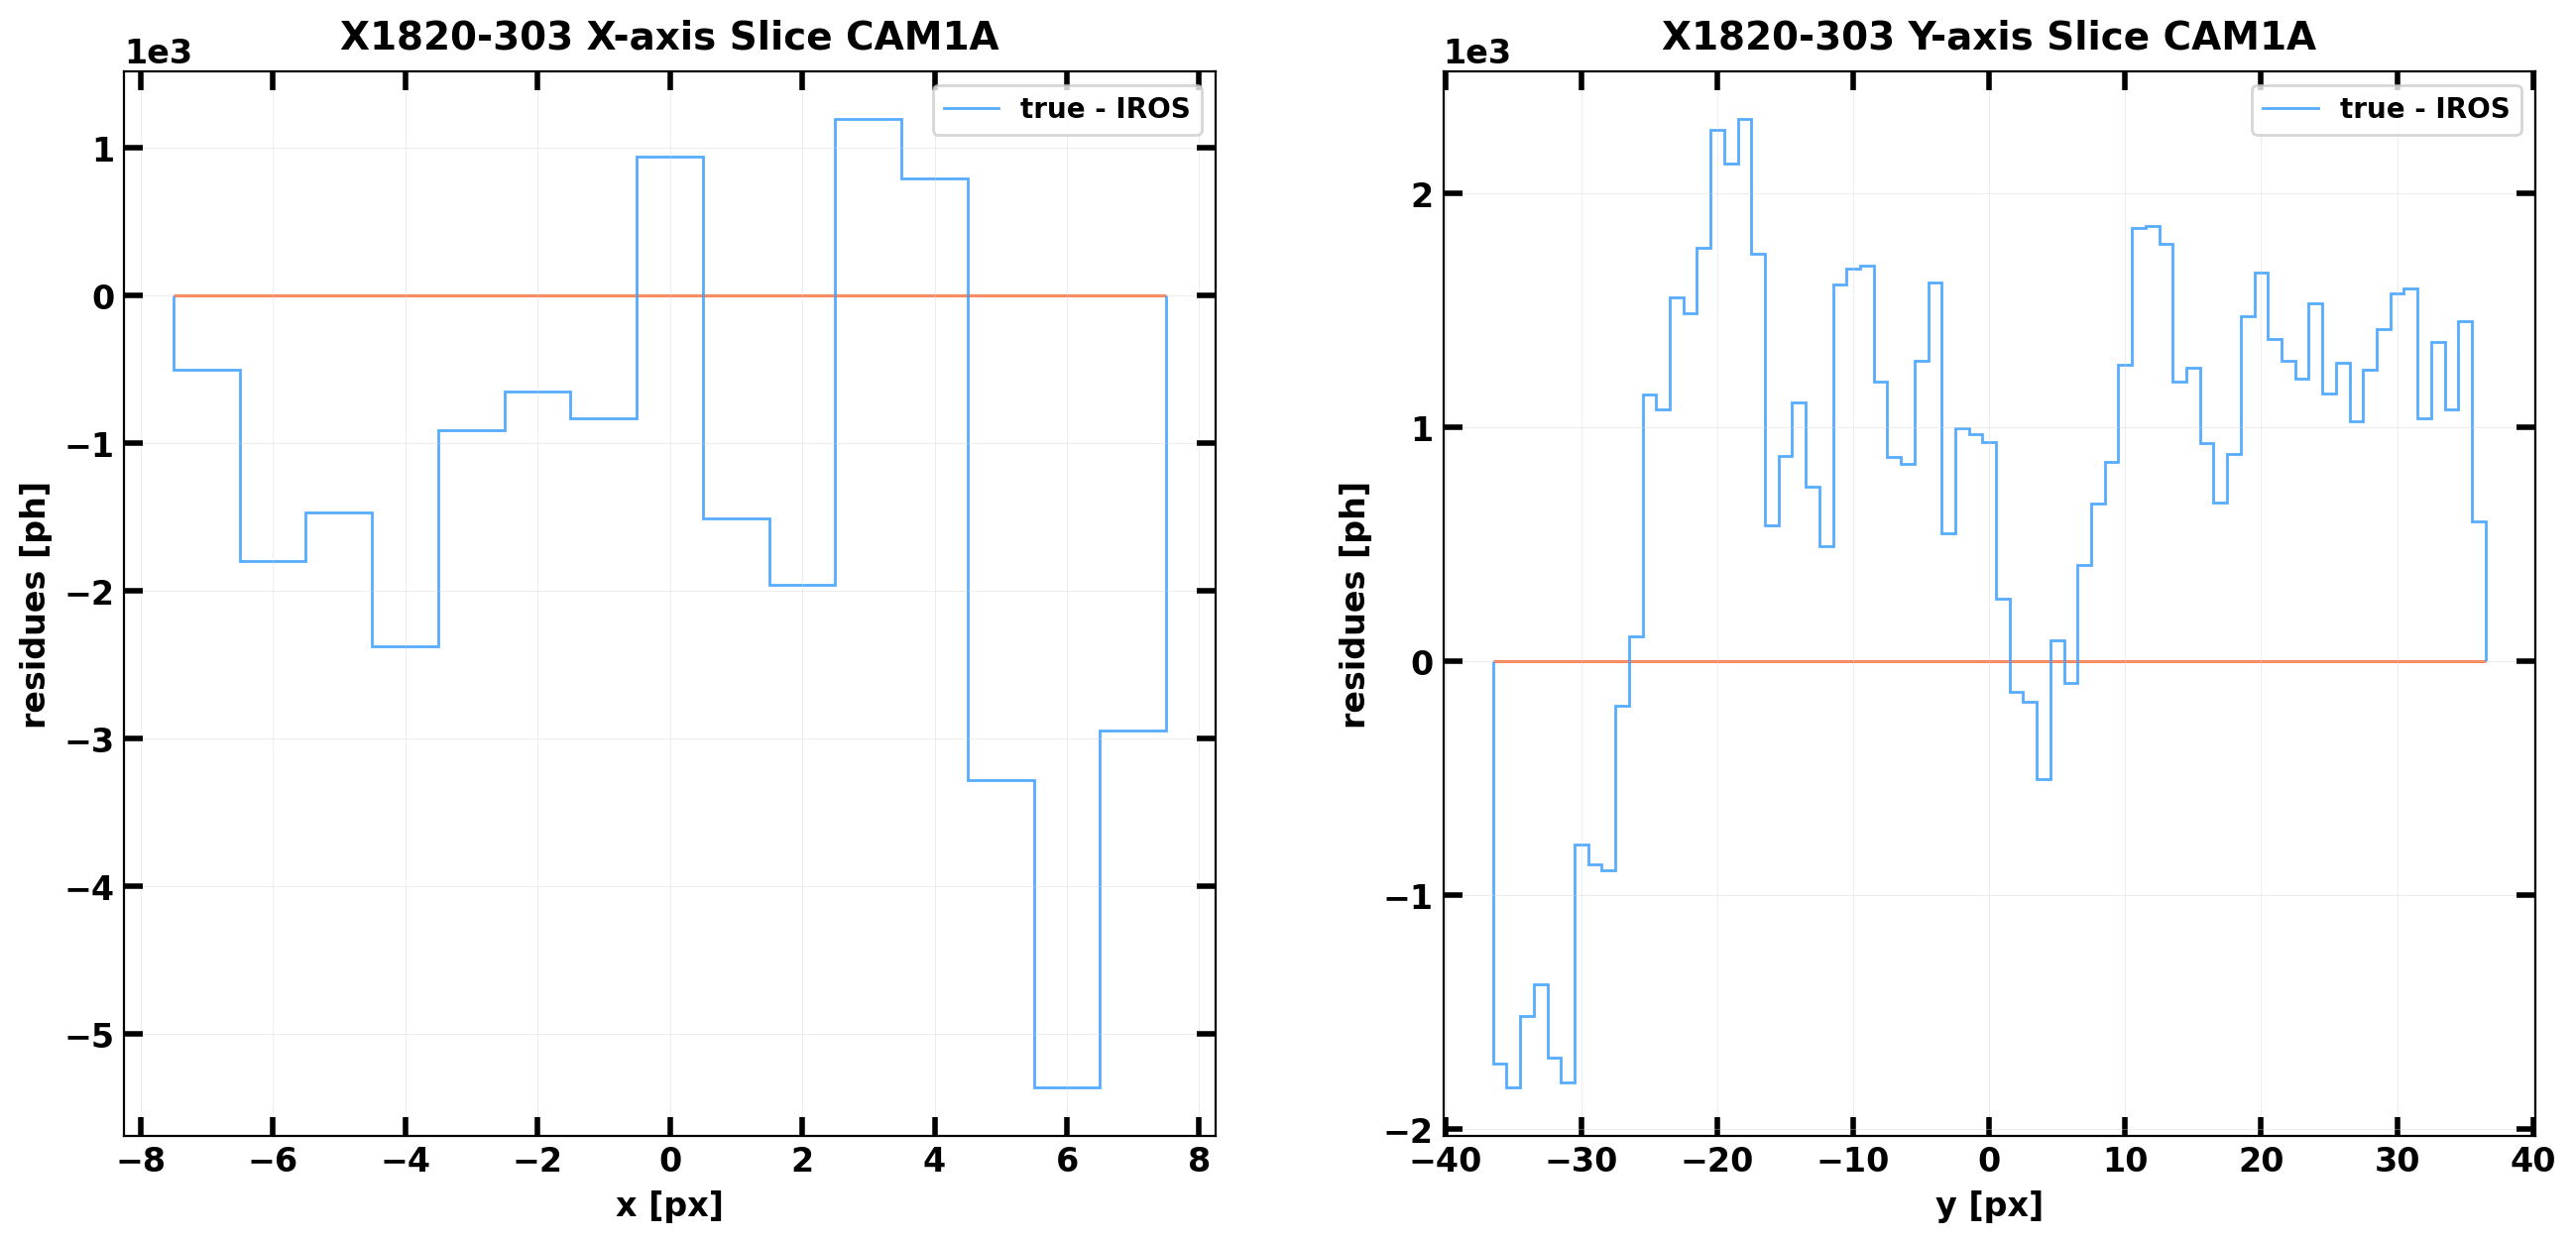

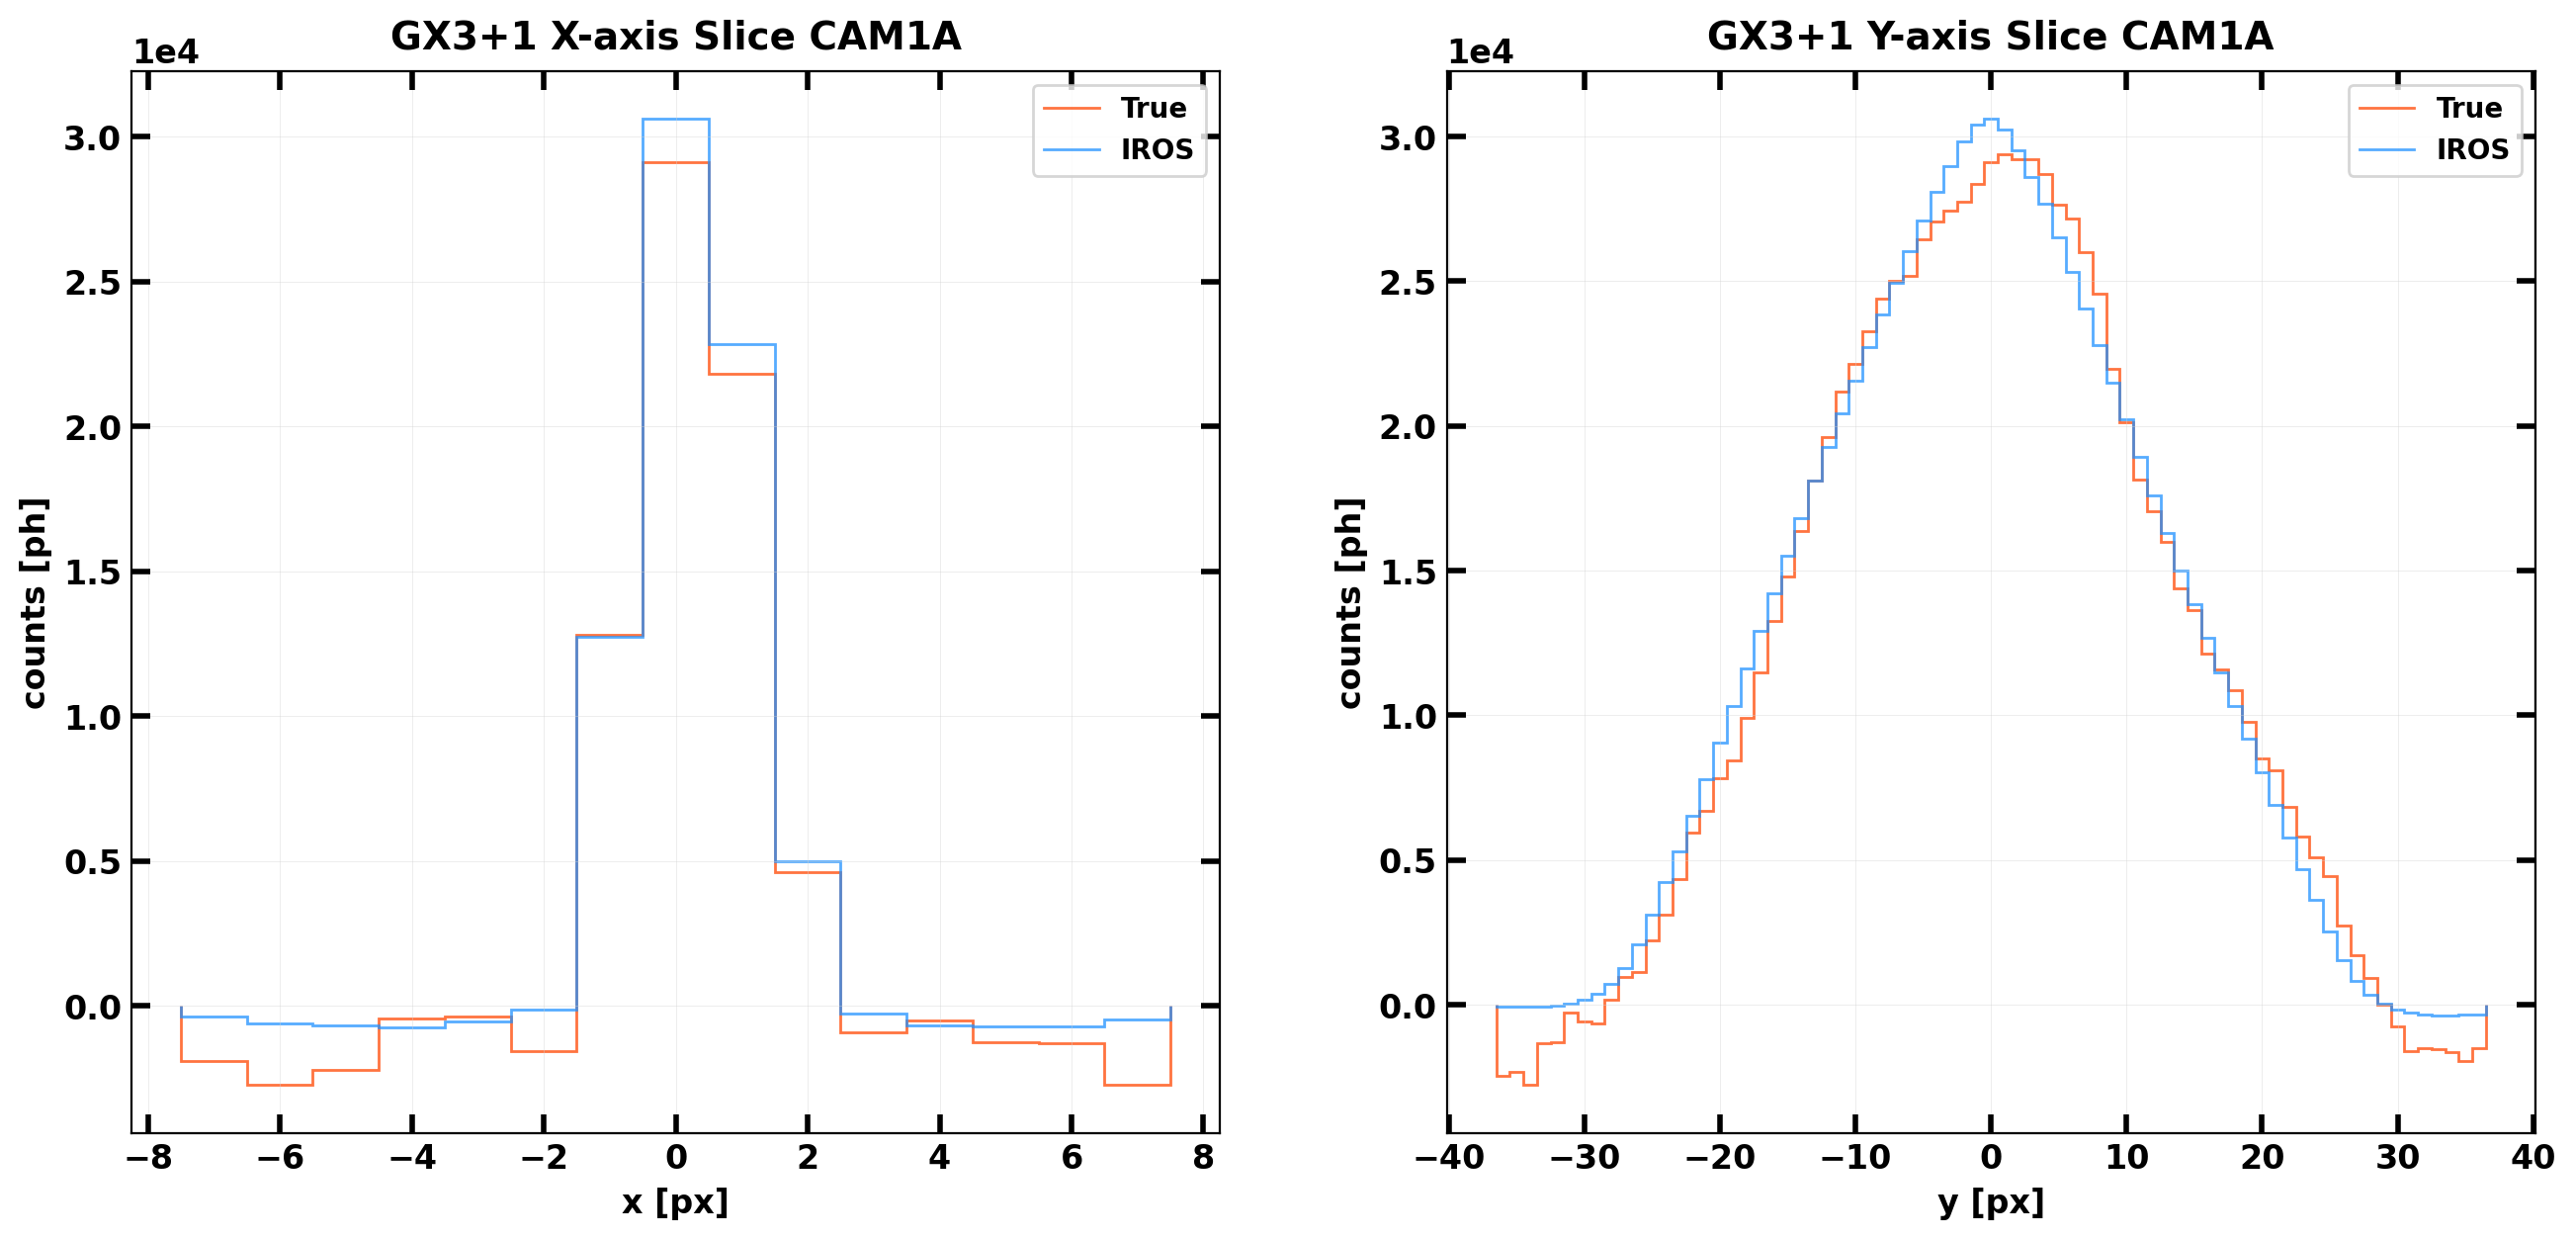

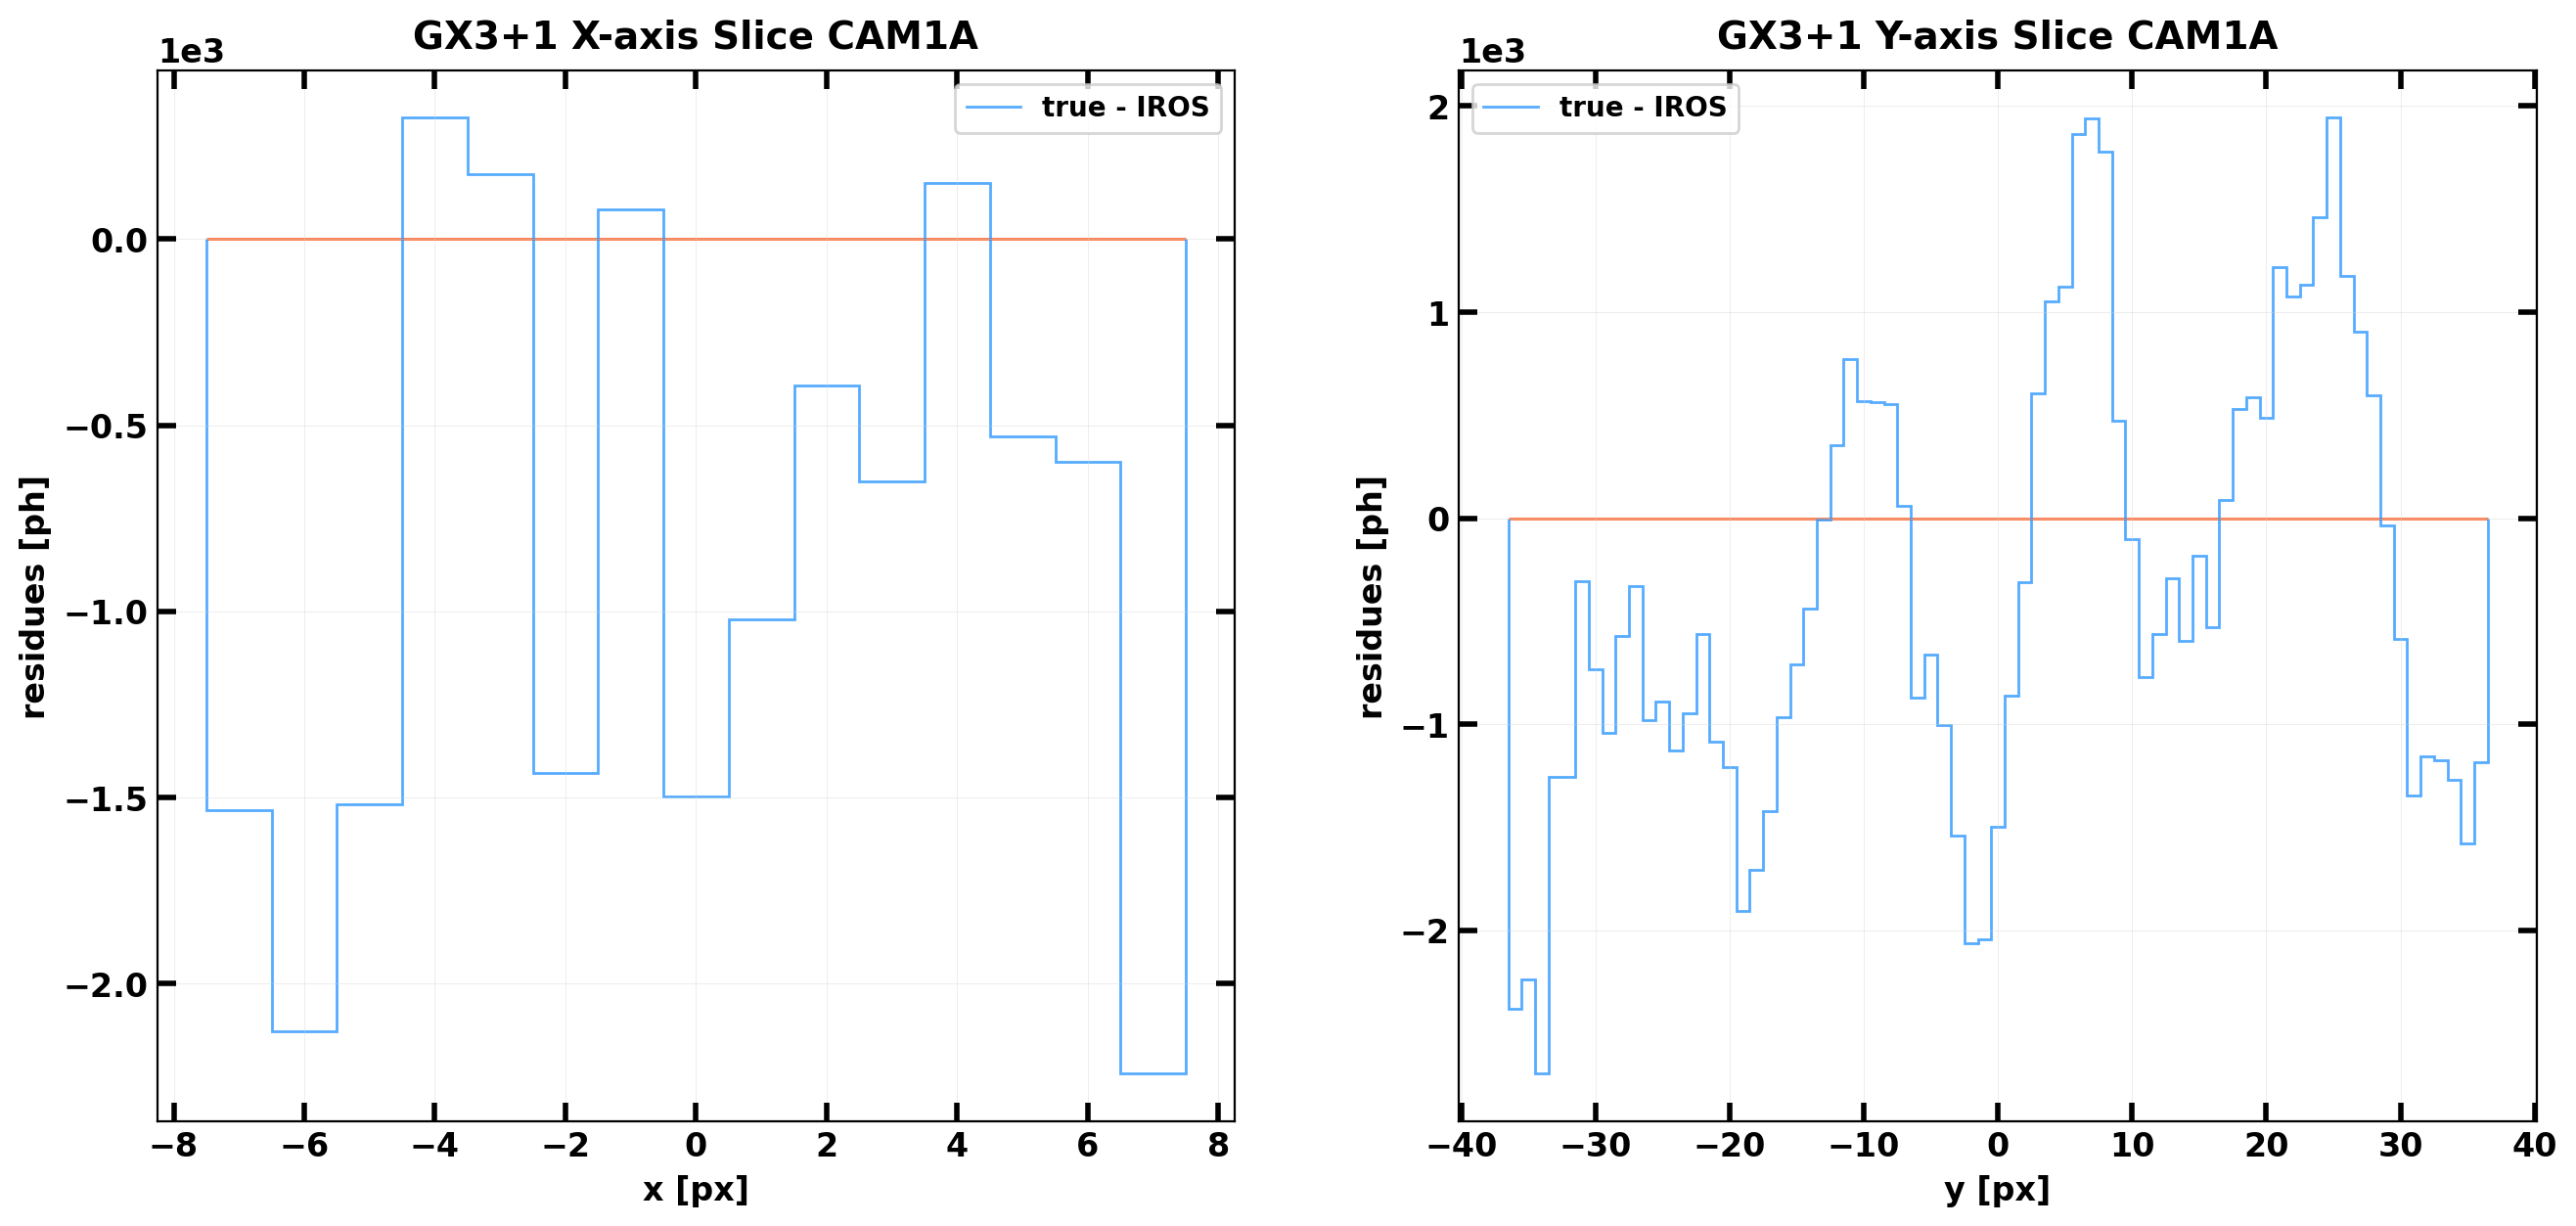

In [ ]:
# sources profiles during IROS + residues heatmaps
cropy, cropx = (
    int(wfm.specs["slit_deltay"] * UPS_Y / wfm.specs["mask_deltay"] + 5),
    int(wfm.specs["slit_deltax"] * UPS_X / wfm.specs["mask_deltax"] + 5),
)
reconstruction_plot(
    true_sky=true_sky_camA,
    log=log_camA,
    crp=(cropy, cropx),
    camera=wfm,
    vignetting=VIGNETTING,
    psfy=PSFY,
    save_to=SAVE_TO if SAVE_THINGS else None,
)

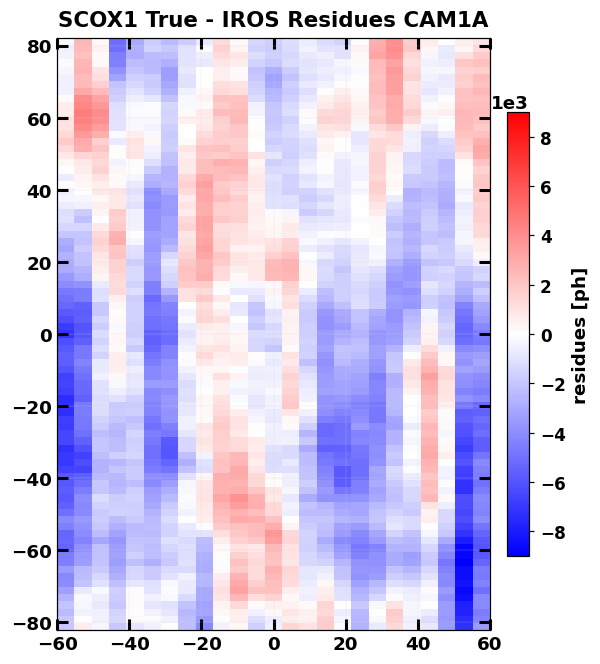

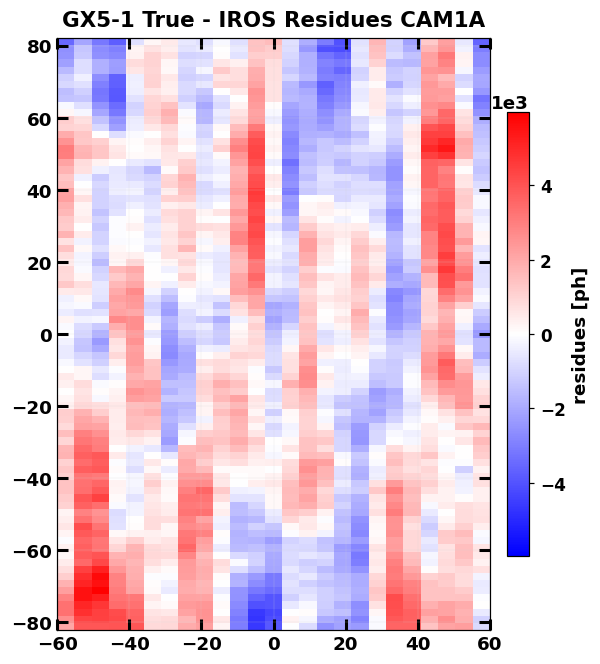

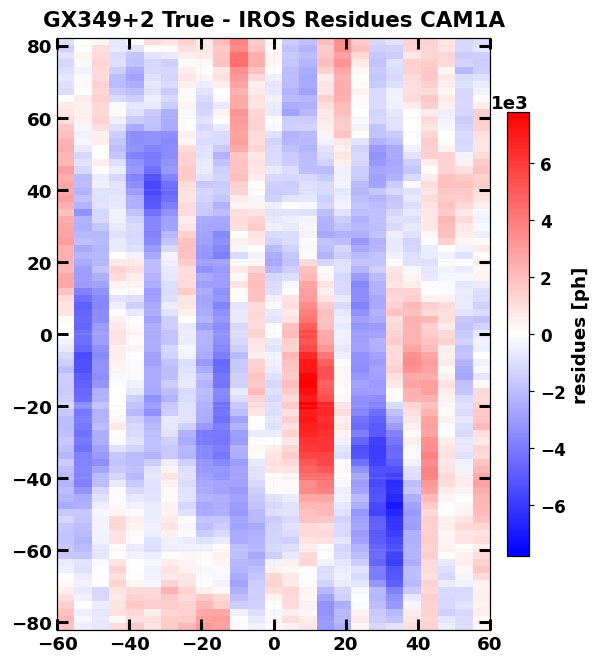

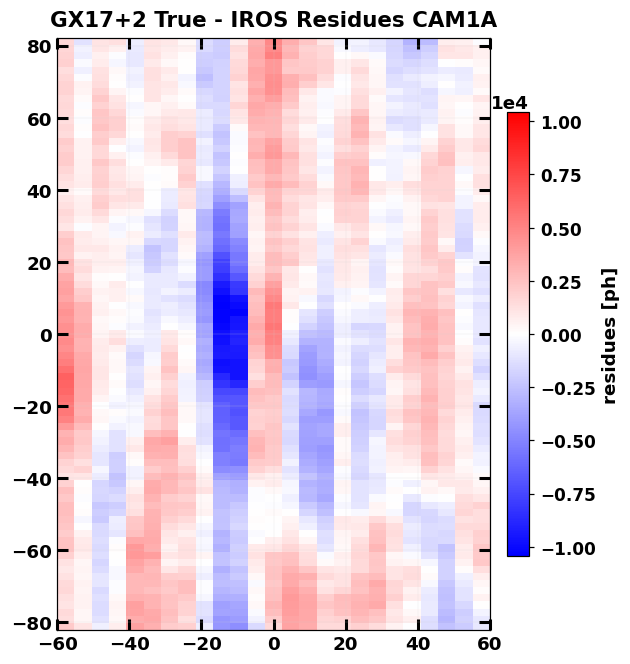

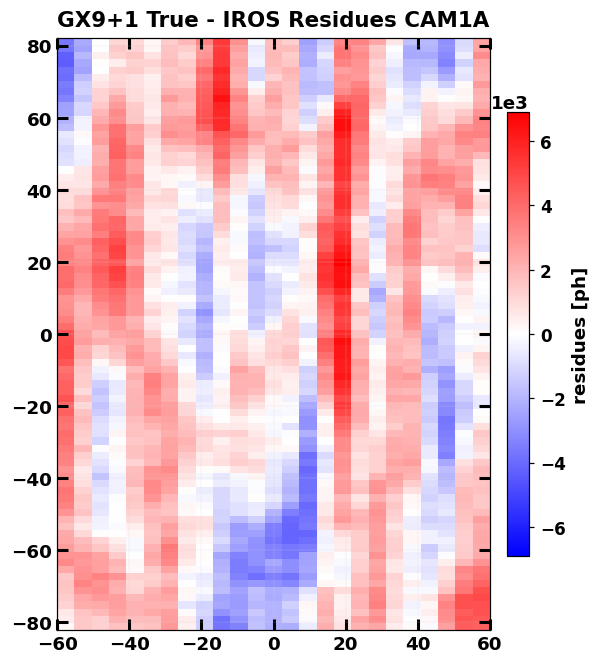

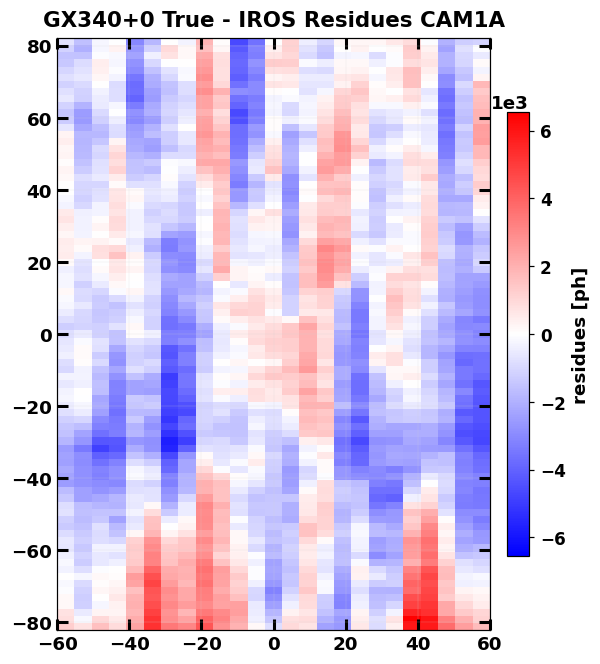

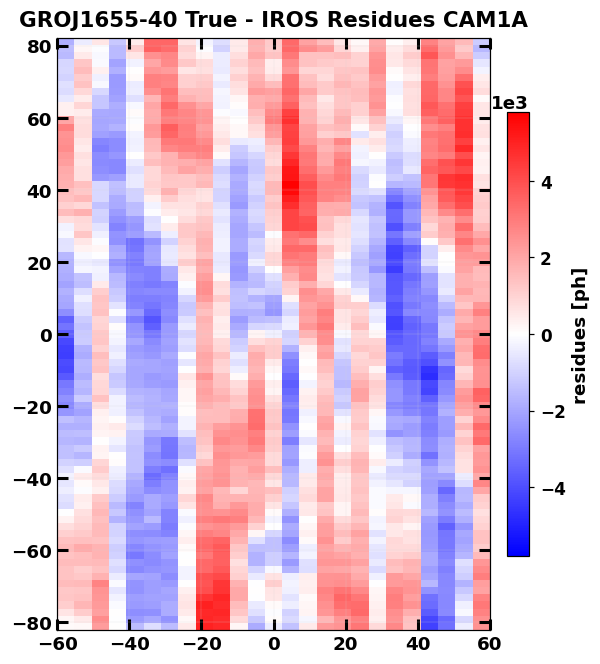

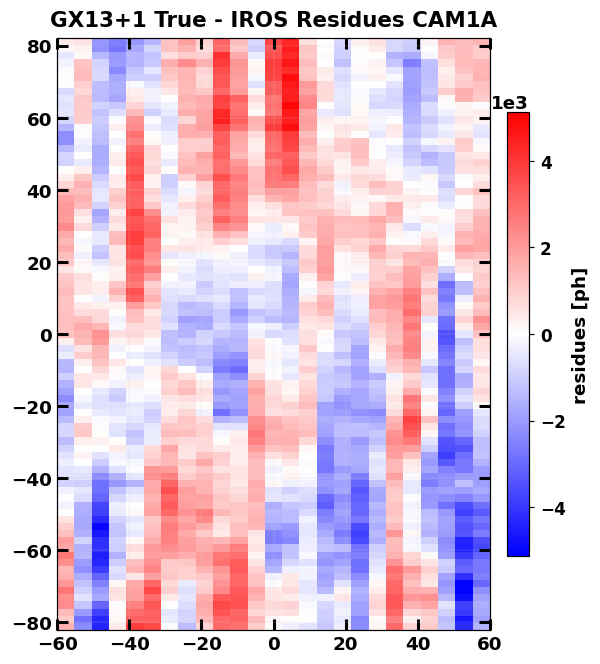

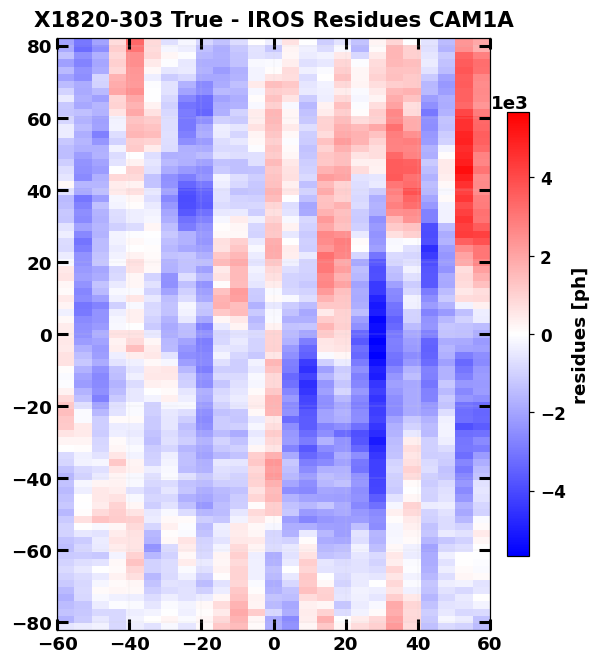

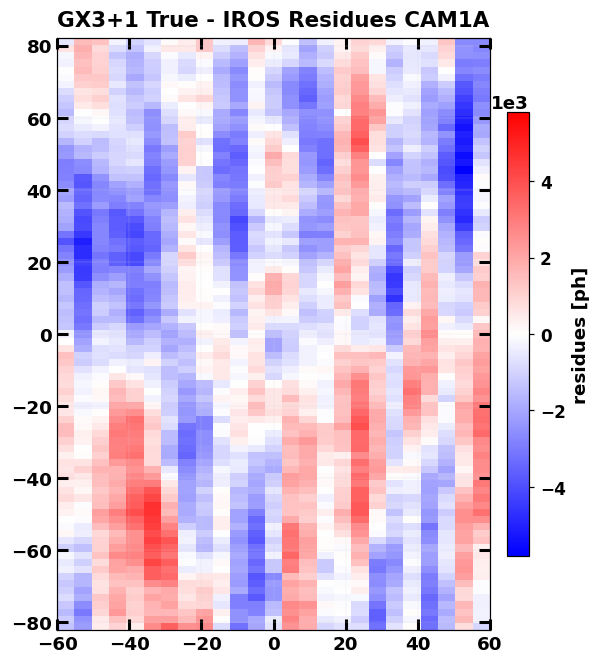

In [ ]:
reconstruction_heatmaps(
    true_sky=true_sky_camA,
    log=log_camA,
    camera=wfm,
    vignetting=VIGNETTING,
    psfy=PSFY,
    save_to=SAVE_TO if SAVE_THINGS else None,
)

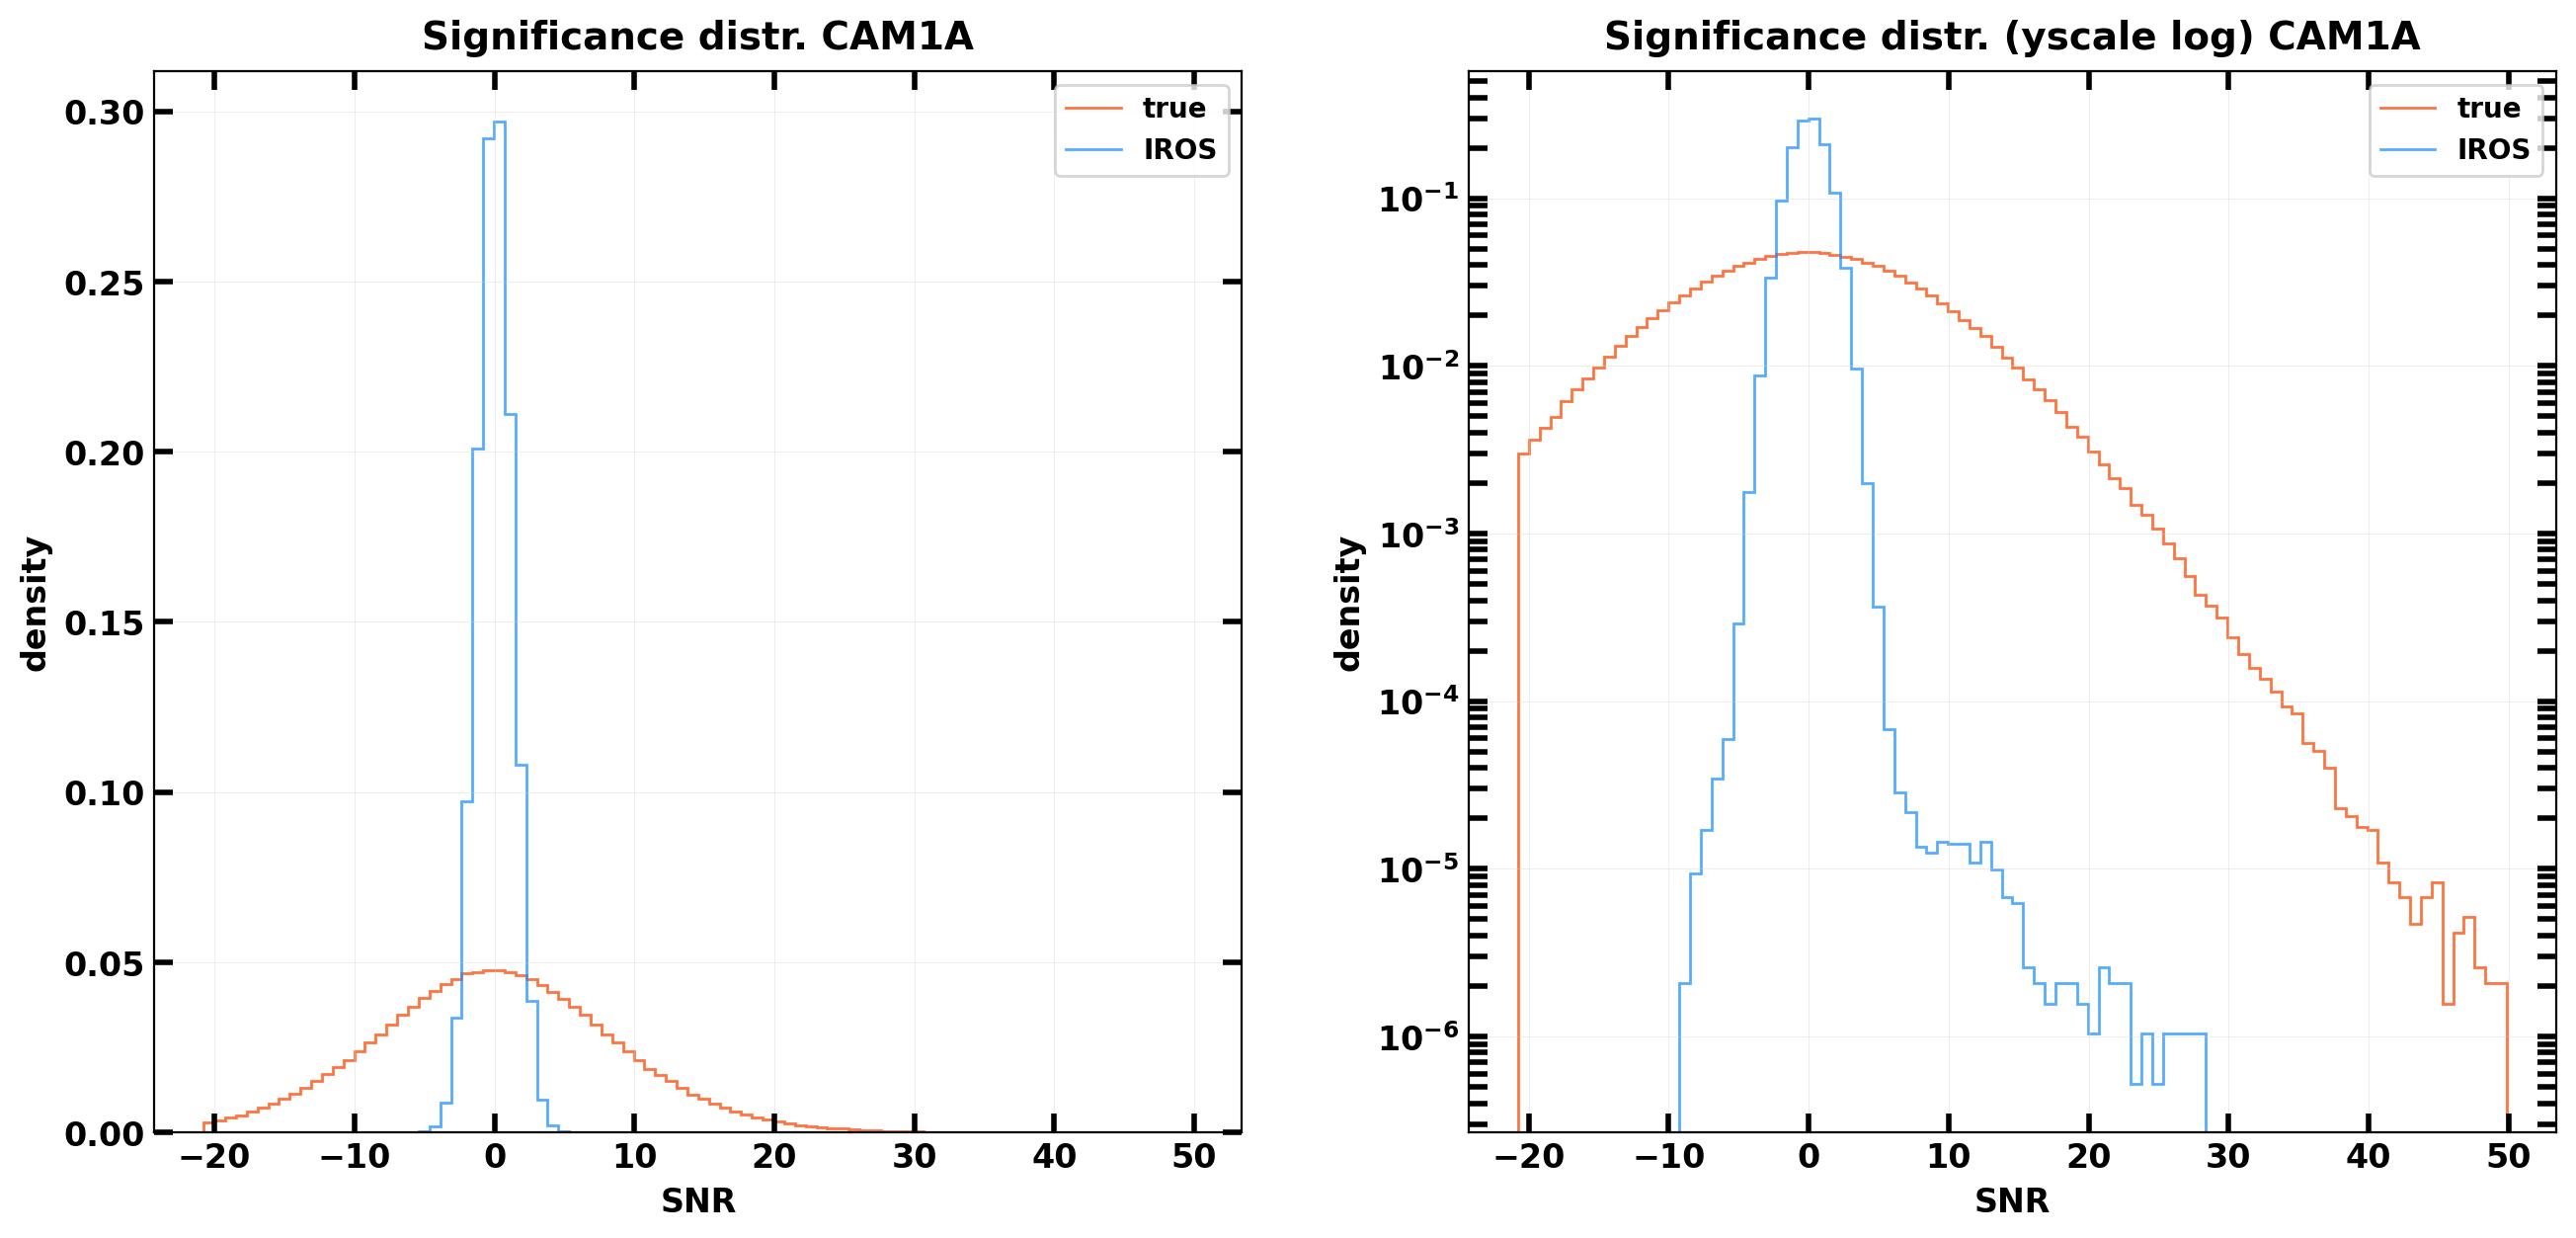

In [ ]:
# sky significance distr. for true sky and at the last IROS iteration
detector_camA = count(wfm, sdlA.DLdata)[0]
varmap = variance(wfm, detector_camA)

ycut, xcut = UPS_Y * 30, UPS_X * 20
true_skysnr_camA = ds.unframe(snratio(true_sky_camA, varmap), ycut, xcut)
res_skysnr_camA = ds.unframe(snratio(res_sky_camA, varmap), ycut, xcut)

num_bins = 1000
density = True
hist_true_skysnr, bins = np.histogram(true_skysnr_camA, bins=num_bins, density=density)
hist_res_skysnr, _ = np.histogram(res_skysnr_camA, bins=bins, density=density)


x0, xN = -20, 50
bins_slice, hist_slice = config_snrlim(bins, x0, xN)

dmap1_snr = ds.map4plot(
    arrs=(hist_true_skysnr[hist_slice], hist_res_skysnr[hist_slice]),
    title=f'Significance distr. {ID_CAMERA_A.upper()}',
    xlabel='SNR',
    ylabel='density',
    labels=('true', 'IROS'),
    x=bins[bins_slice],
    style='stairs',
    color=('OrangeRed', 'Dodgerblue'),
)
dmap2_snr = ds.map4plot(
    arrs=(hist_true_skysnr[hist_slice], hist_res_skysnr[hist_slice]),
    title=f'Significance distr. (yscale log) {ID_CAMERA_A.upper()}',
    xlabel='SNR',
    ylabel='density',
    labels=('true', 'IROS'),
    x=bins[bins_slice],
    style='stairs',
    color=('OrangeRed', 'Dodgerblue'),
    yscale='log',
)
ds.plot(
    dmaps=(dmap1_snr, dmap2_snr),
    ncols=2,
    save_to=(
        savefig_to(SAVE_TO, f'snr_distr_{ID_CAMERA_A.upper()}')
        if SAVE_THINGS else None
    ),
)

**Analysis for LEM-X Camera B**

In [ ]:
assert ANALYSIS_CAM1B

In [ ]:
# sources data + angular coords residues plot
data_DF(
    log=log_camB,
    catalogue=catalogueB,
    sdl=sdlB,
    camera=wfm,
)

CAM1B                                              
            ID         SNR DthetaX [arcmin] DthetaY [arcmin]
0        scox1  684.916254         0.002209         0.451365
1        gx5-1   78.221782         0.046362         0.948193
2        gx9+1   43.807250         0.108160         0.559593
3      gx349+2   40.805866         0.825864         0.857522
4       gx17+2   39.280047         0.922349        22.494810
5      gx340+0   30.304420         0.390893         3.819535
6       gx13+1   25.520075         0.030200         0.329308
7  groj1655-40   22.703965         0.074673         0.996763
8    x1820-303   22.425229         0.305328         2.201607
9        gx3+1   21.168068         0.197727         1.977064

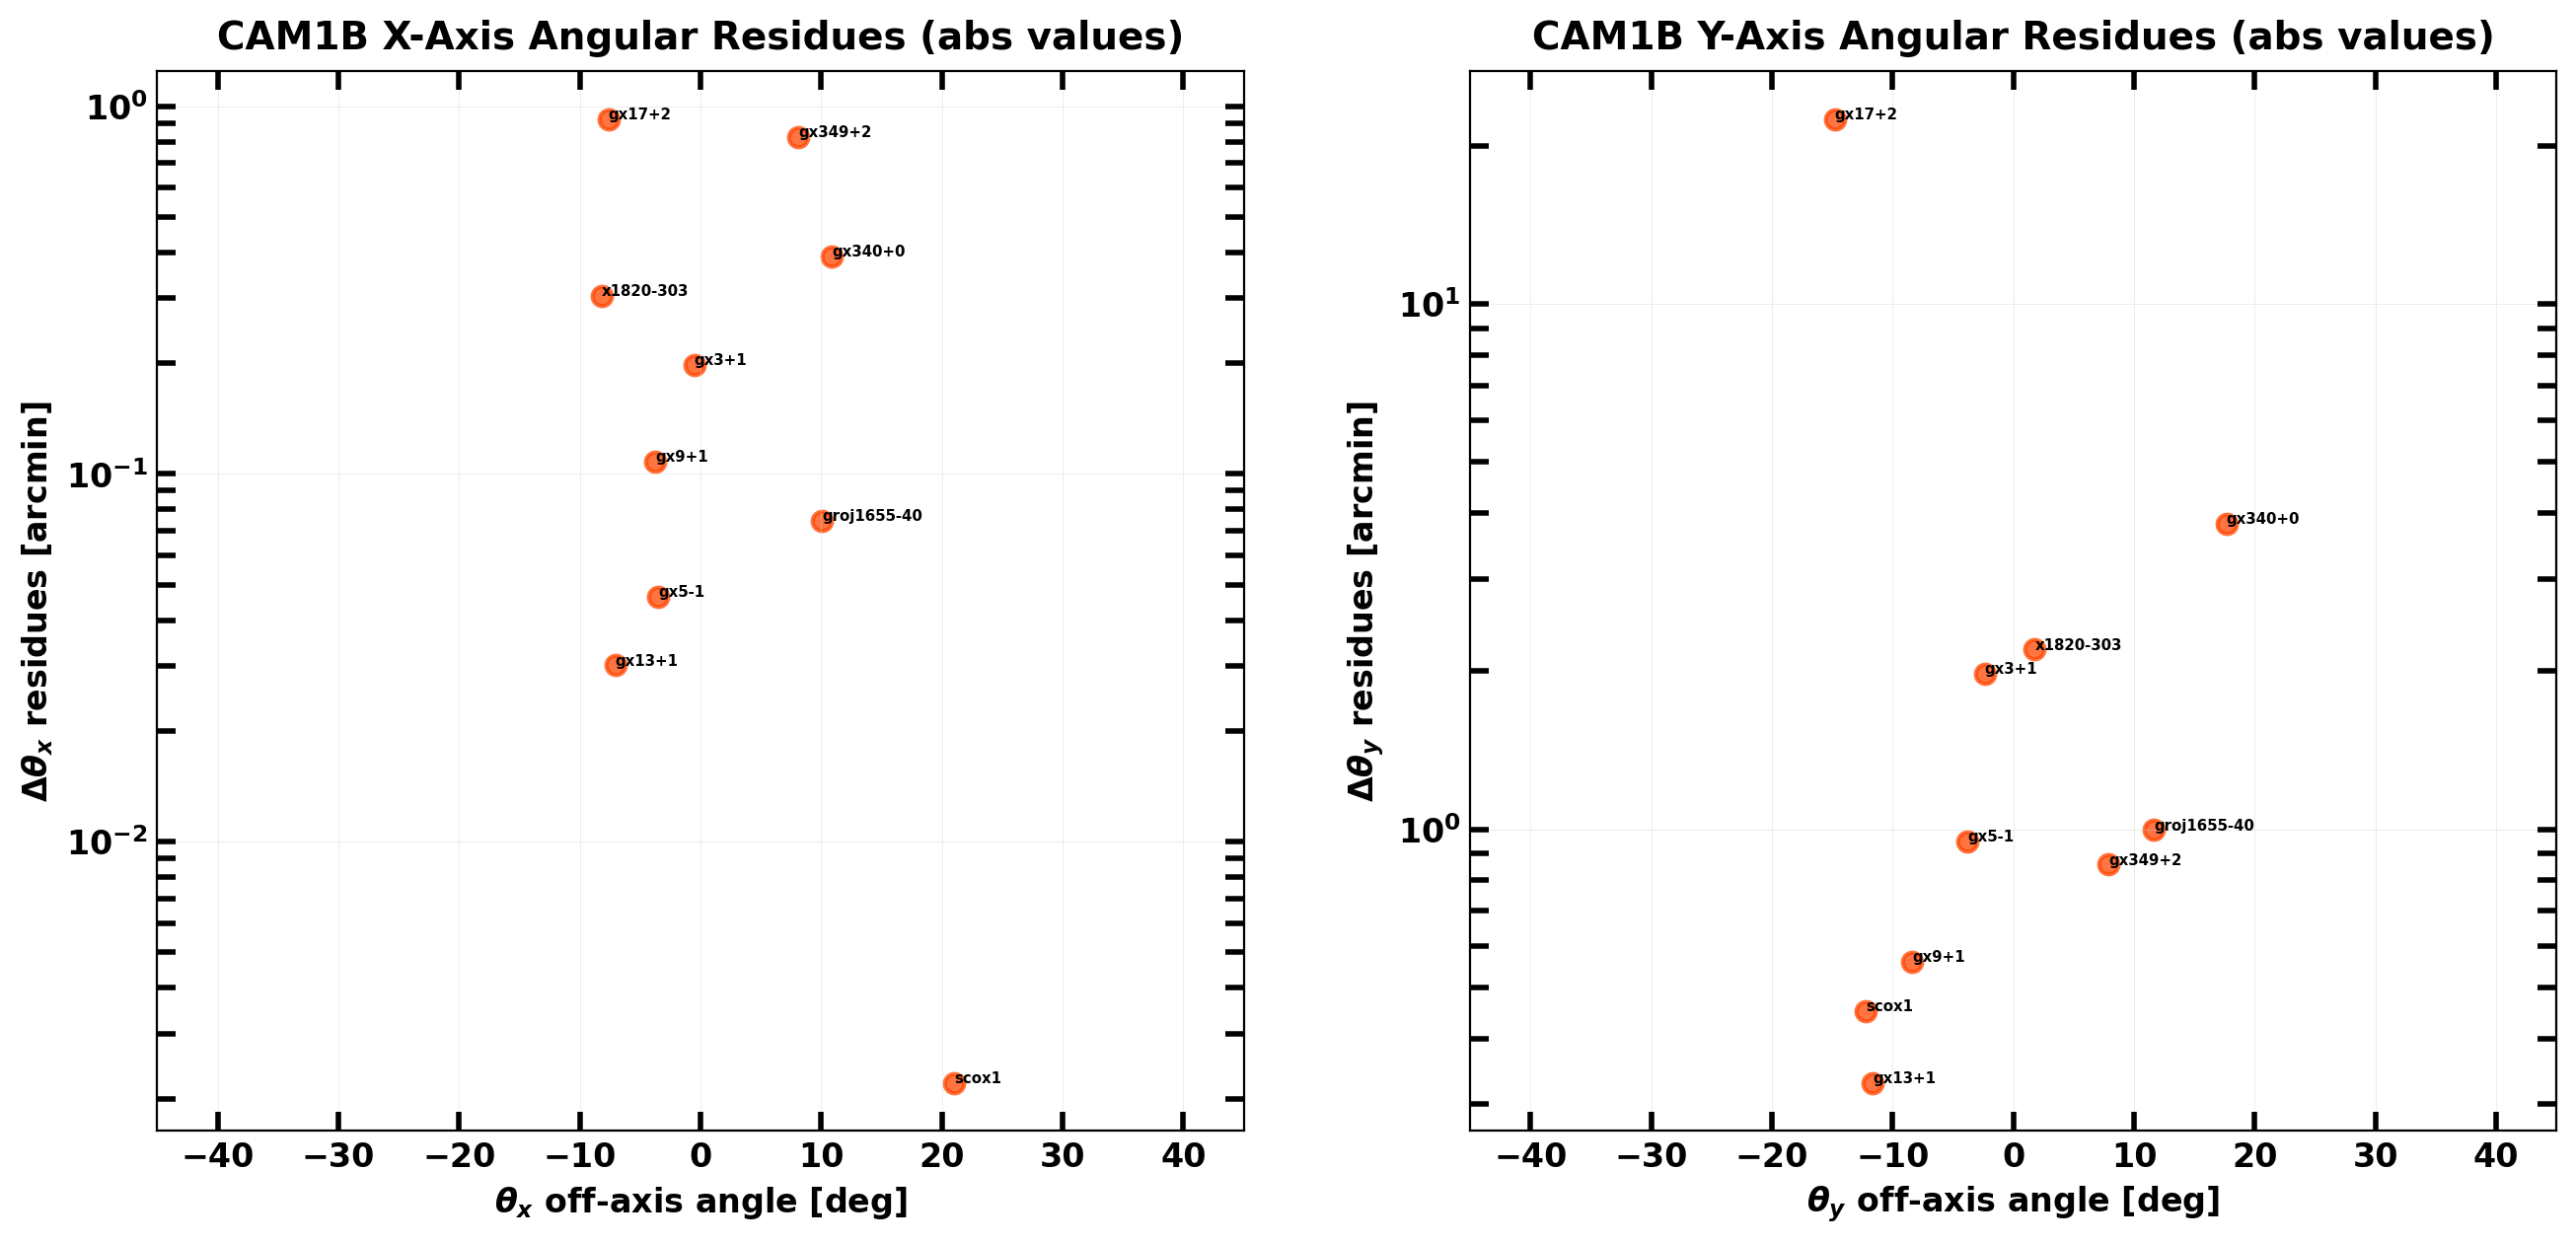

In [ ]:
angular_coords = extract_catalogue_angular_coords(log_camB, catalogueB, sdlB, wfm)
cat_theta_x, cat_theta_y = map(
    np.array, (angular_coords['THETAX'], angular_coords['THETAY']),
)

theta_res_x, theta_res_y = get_angularcoords_residues(
    log=log_camB,
    catalogue=catalogueB,
    sdl=sdlB,
    camera=wfm,
)

tags_x = tuple(
    Tag(name, res, theta) for name, res, theta in zip(
        log_camB.log['ID'], theta_res_x, cat_theta_x,
    )
)
tags_y = tuple(
    Tag(name, res, theta) for name, res, theta in zip(
        log_camB.log['ID'], theta_res_y, cat_theta_y,
    )
)
dmapx = ds.map4plot(
    arrs=theta_res_x,
    title=f'{log_camB.name} X-Axis Angular Residues (abs values)',
    xlabel='$\\theta_{{x}}$ off-axis angle [deg]',
    ylabel='$\\Delta\\theta_{{x}}$ residues [arcmin]',
    x=cat_theta_x,
    style='scatter',
    color='OrangeRed',
    xlim=(-45, 45),
    yscale='log',
    tags=tags_x,
)
dmapy = ds.map4plot(
    arrs=theta_res_y,
    title=f'{log_camB.name} Y-Axis Angular Residues (abs values)',
    xlabel='$\\theta_{{y}}$ off-axis angle [deg]',
    ylabel='$\\Delta\\theta_{{y}}$ residues [arcmin]',
    x=cat_theta_y,
    style='scatter',
    color='OrangeRed',
    xlim=(-45, 45),
    yscale='log',
    tags=tags_y,
)

ds.plot(
    (dmapx, dmapy),
    ncols=2,
    save_to=(
        savefig_to(SAVE_TO, f'angularRes_{ID_CAMERA_B.upper()}')
        if SAVE_THINGS else None
    ),
)

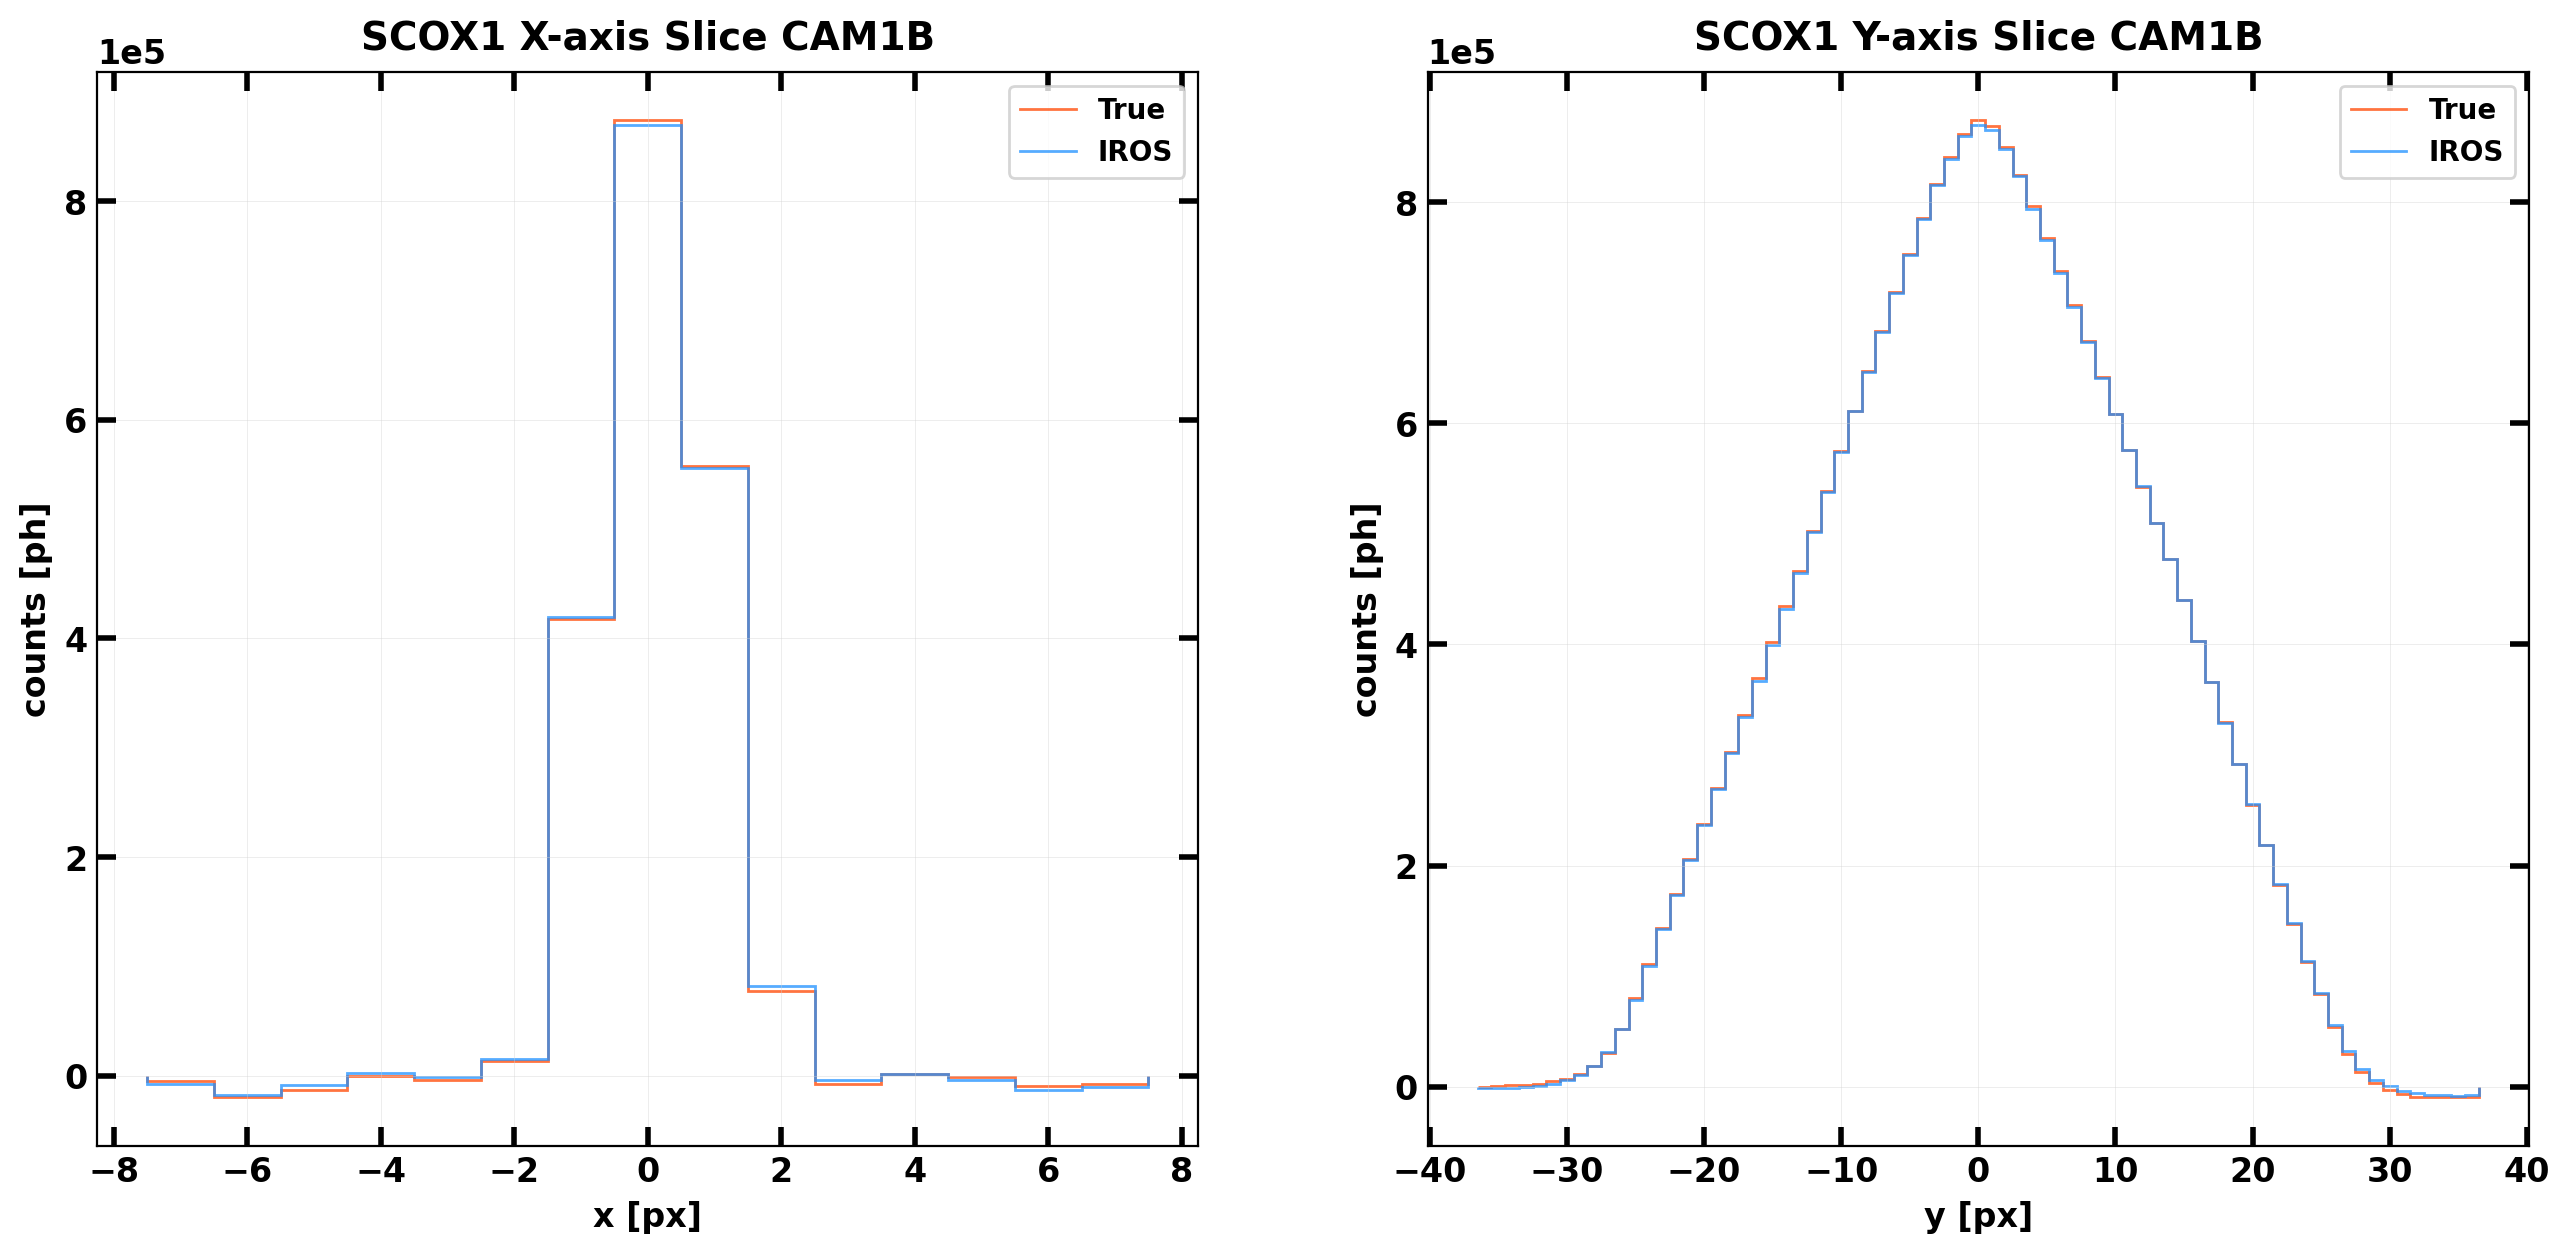

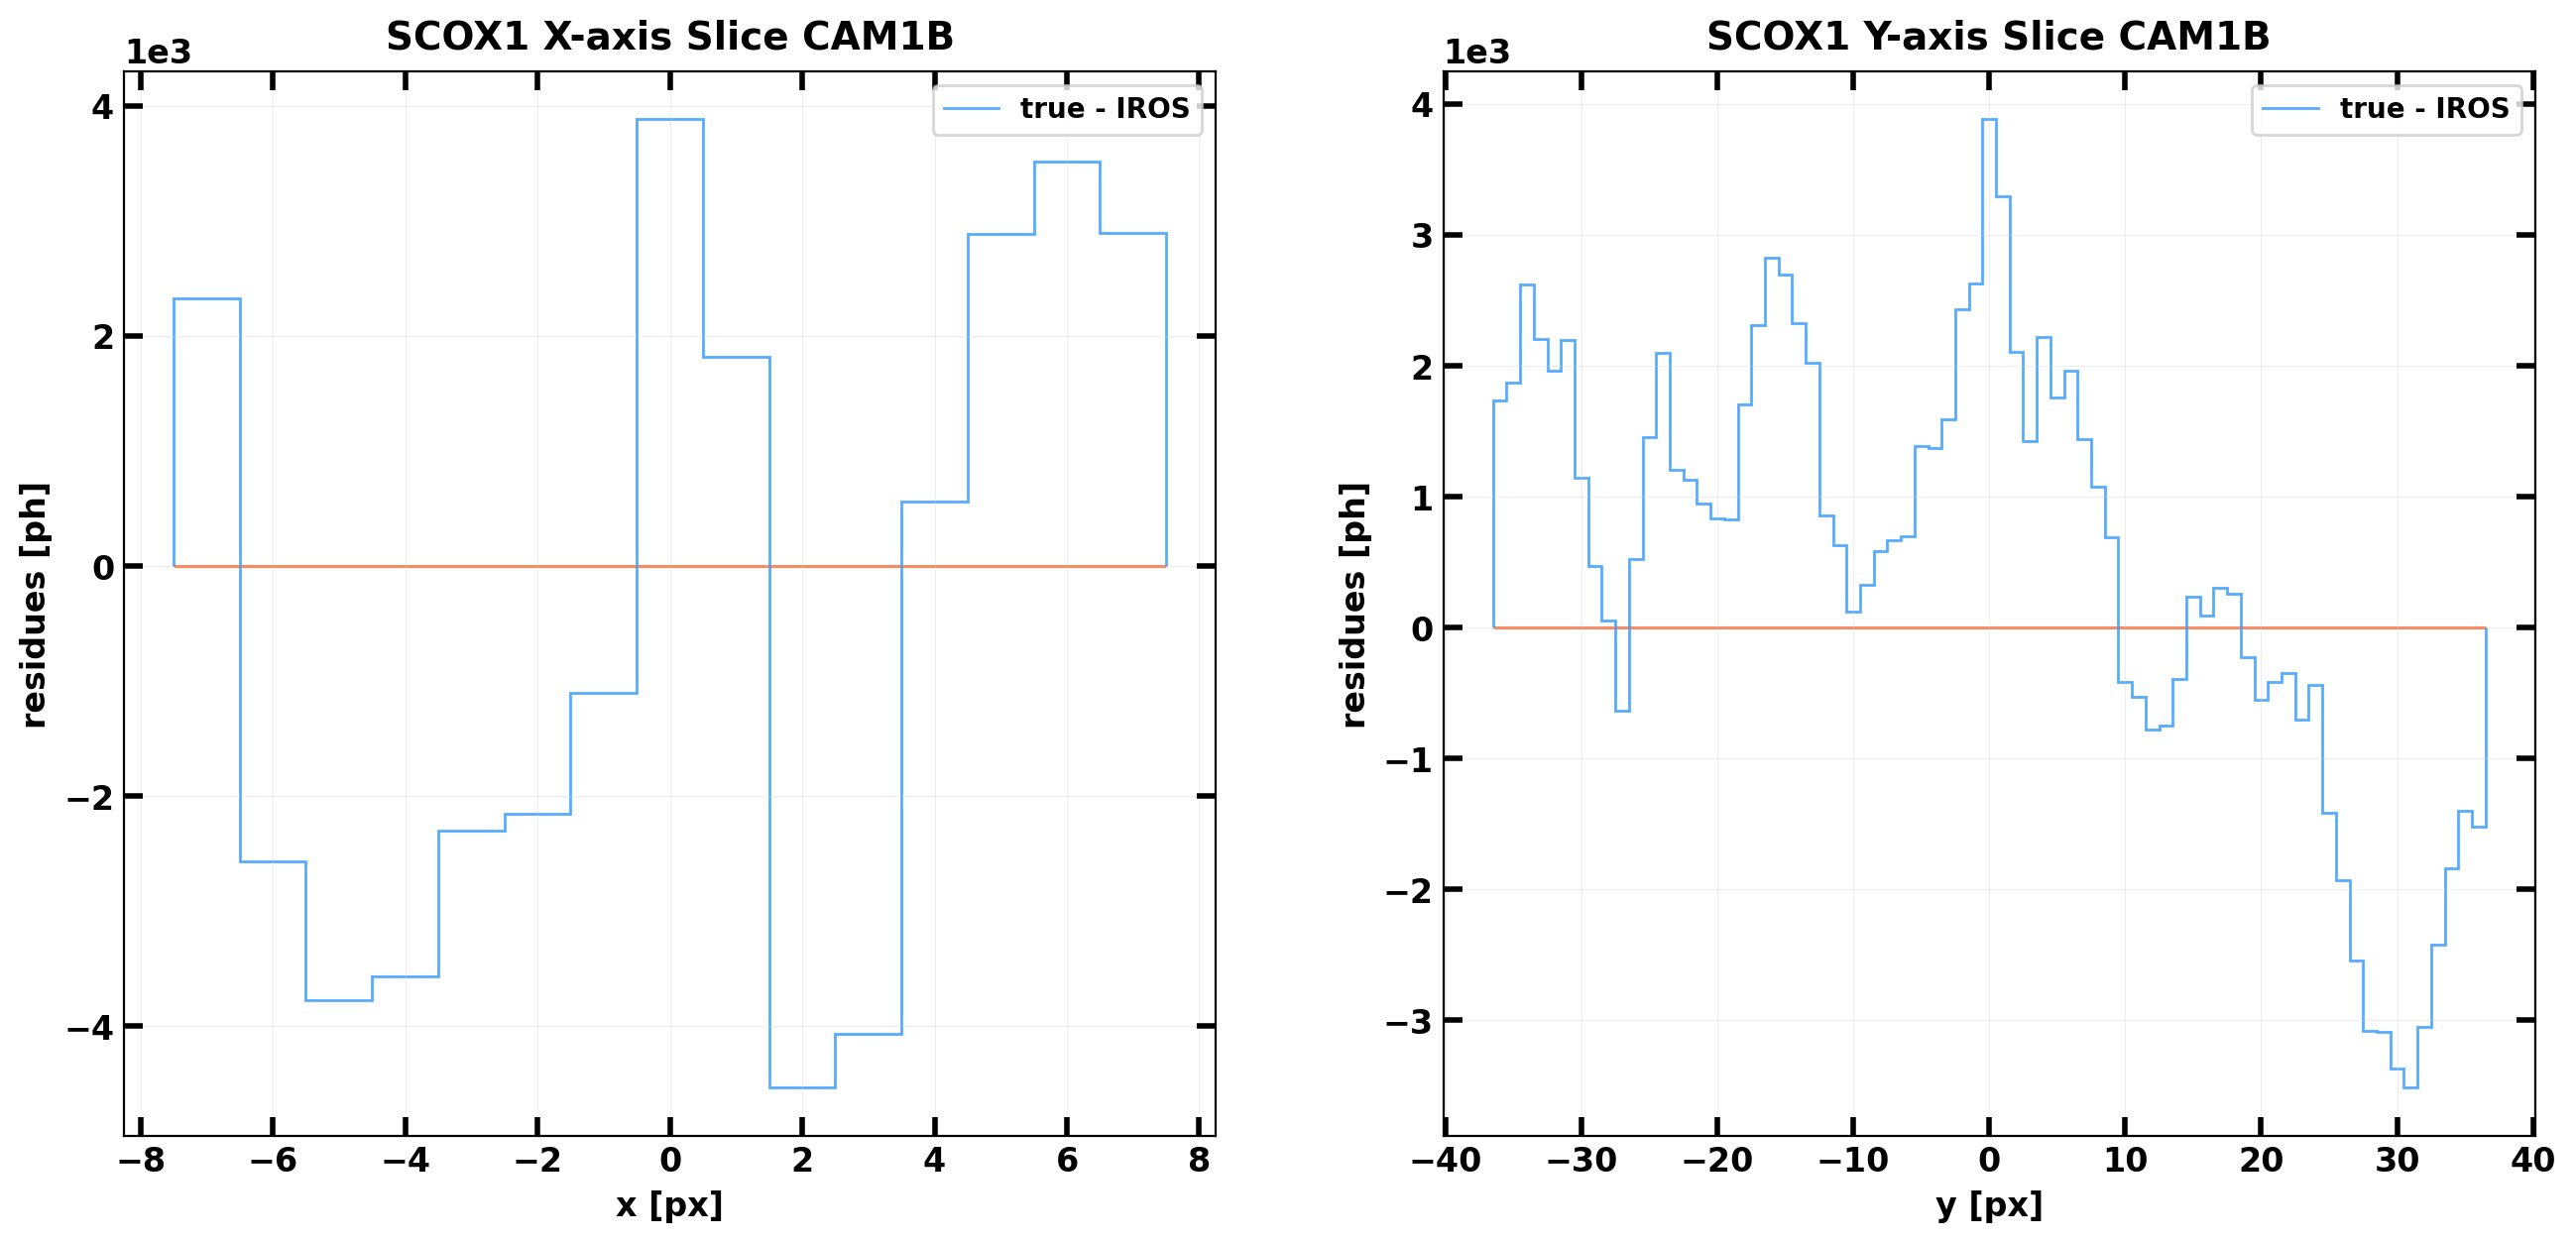

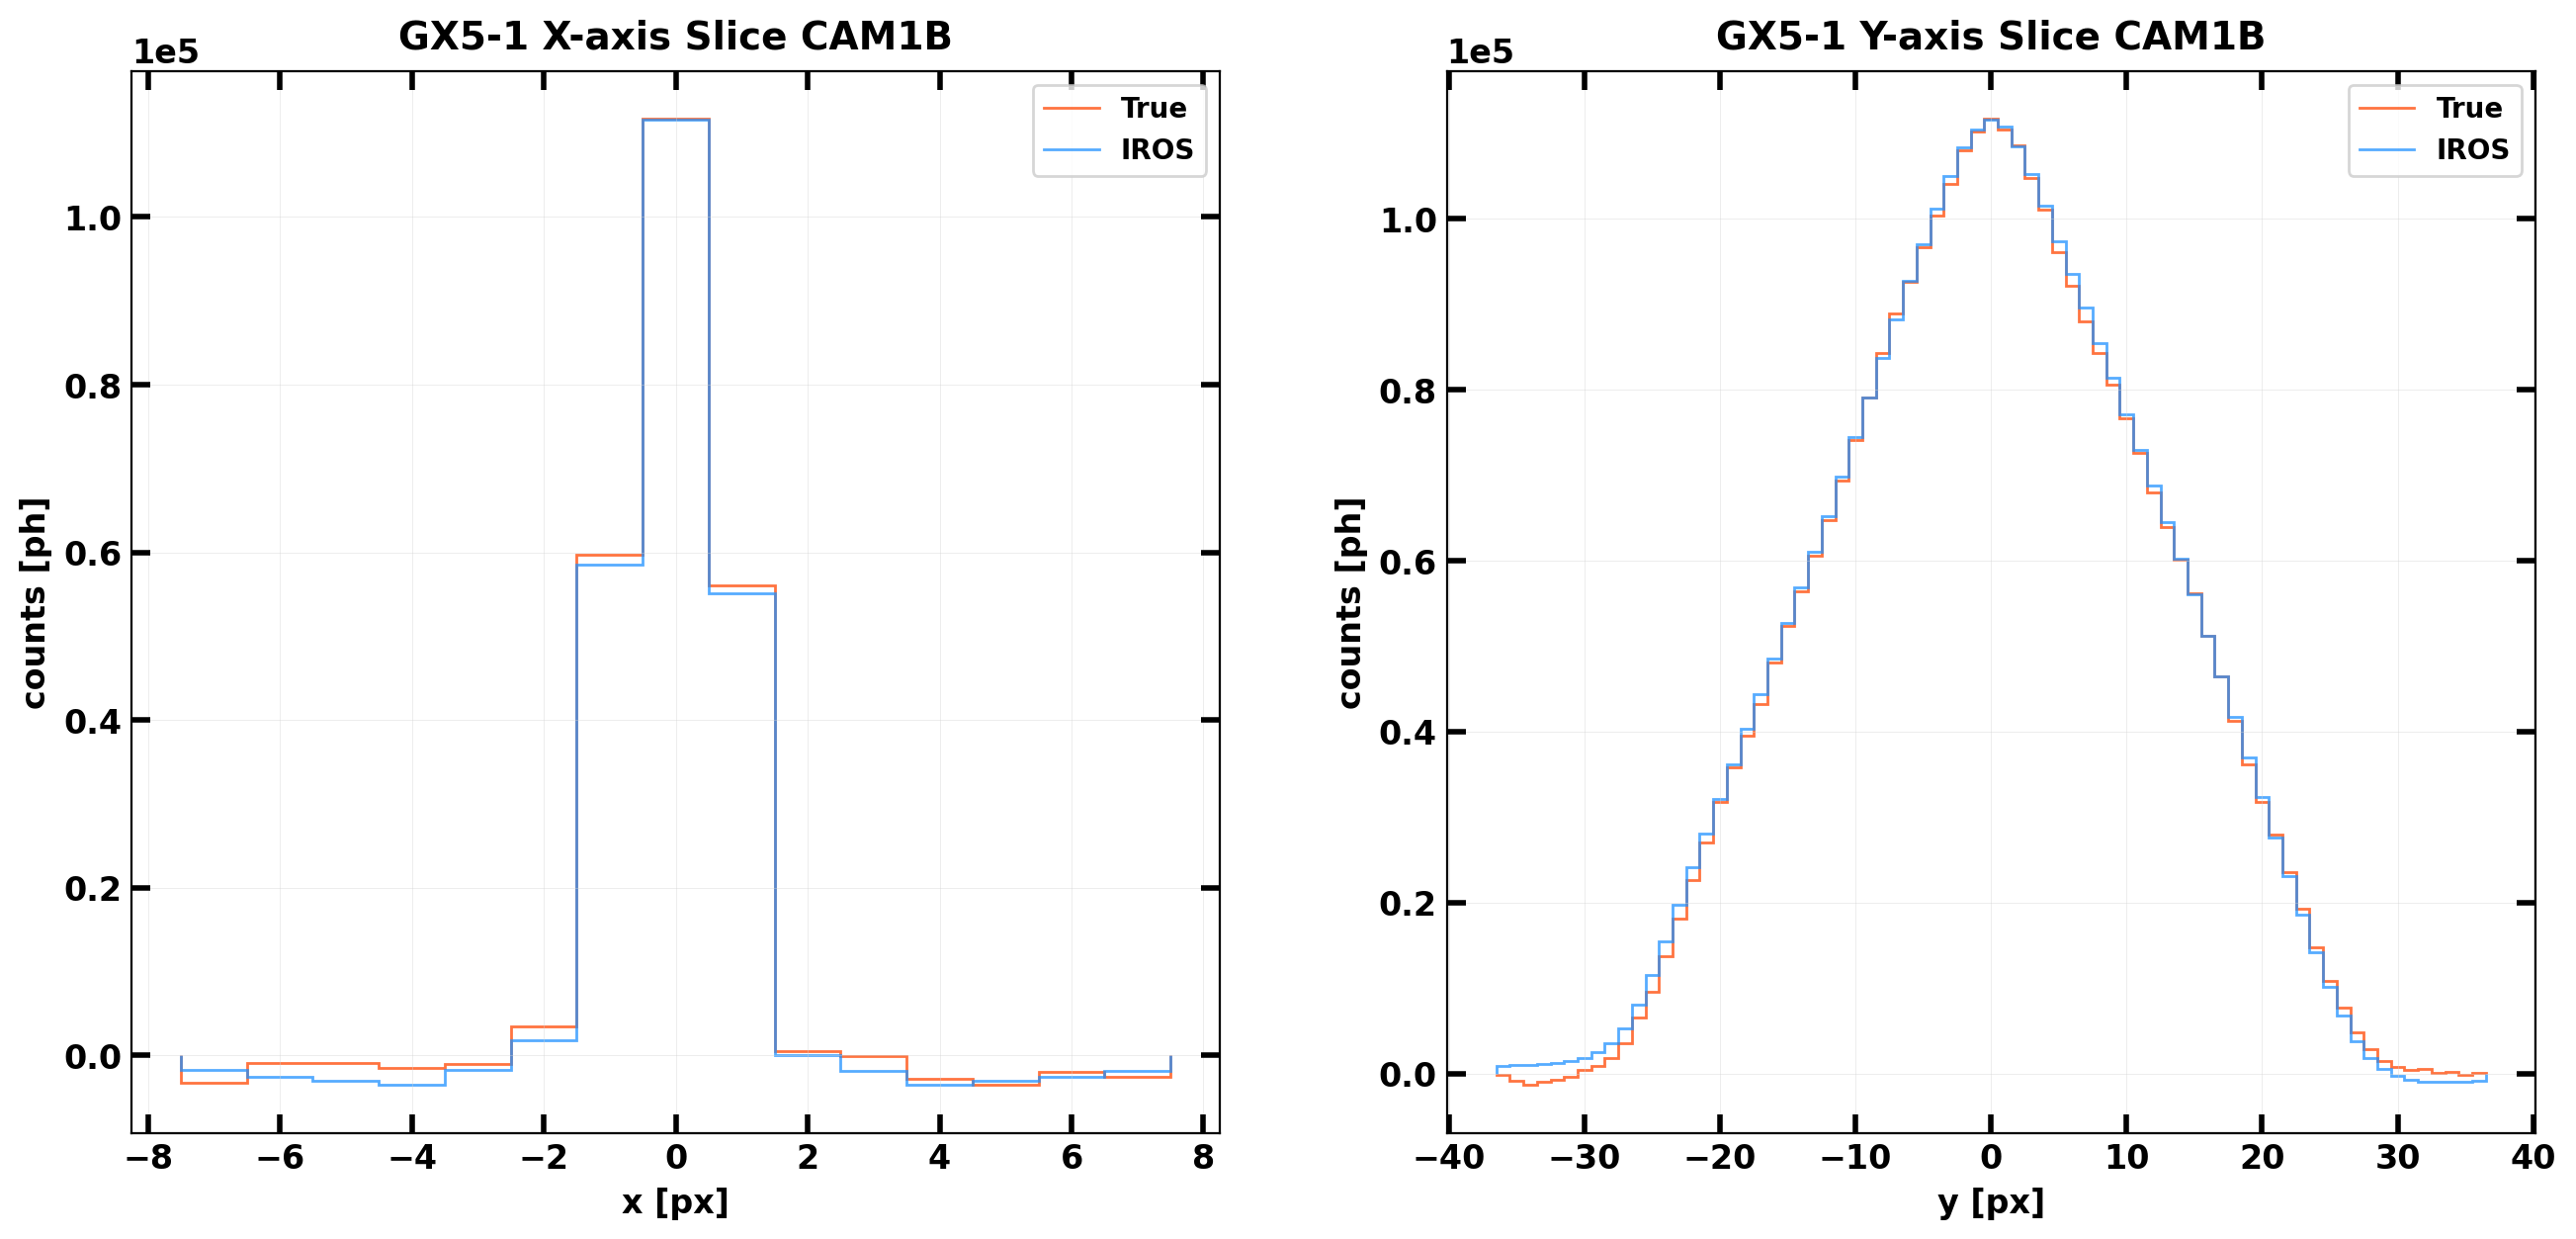

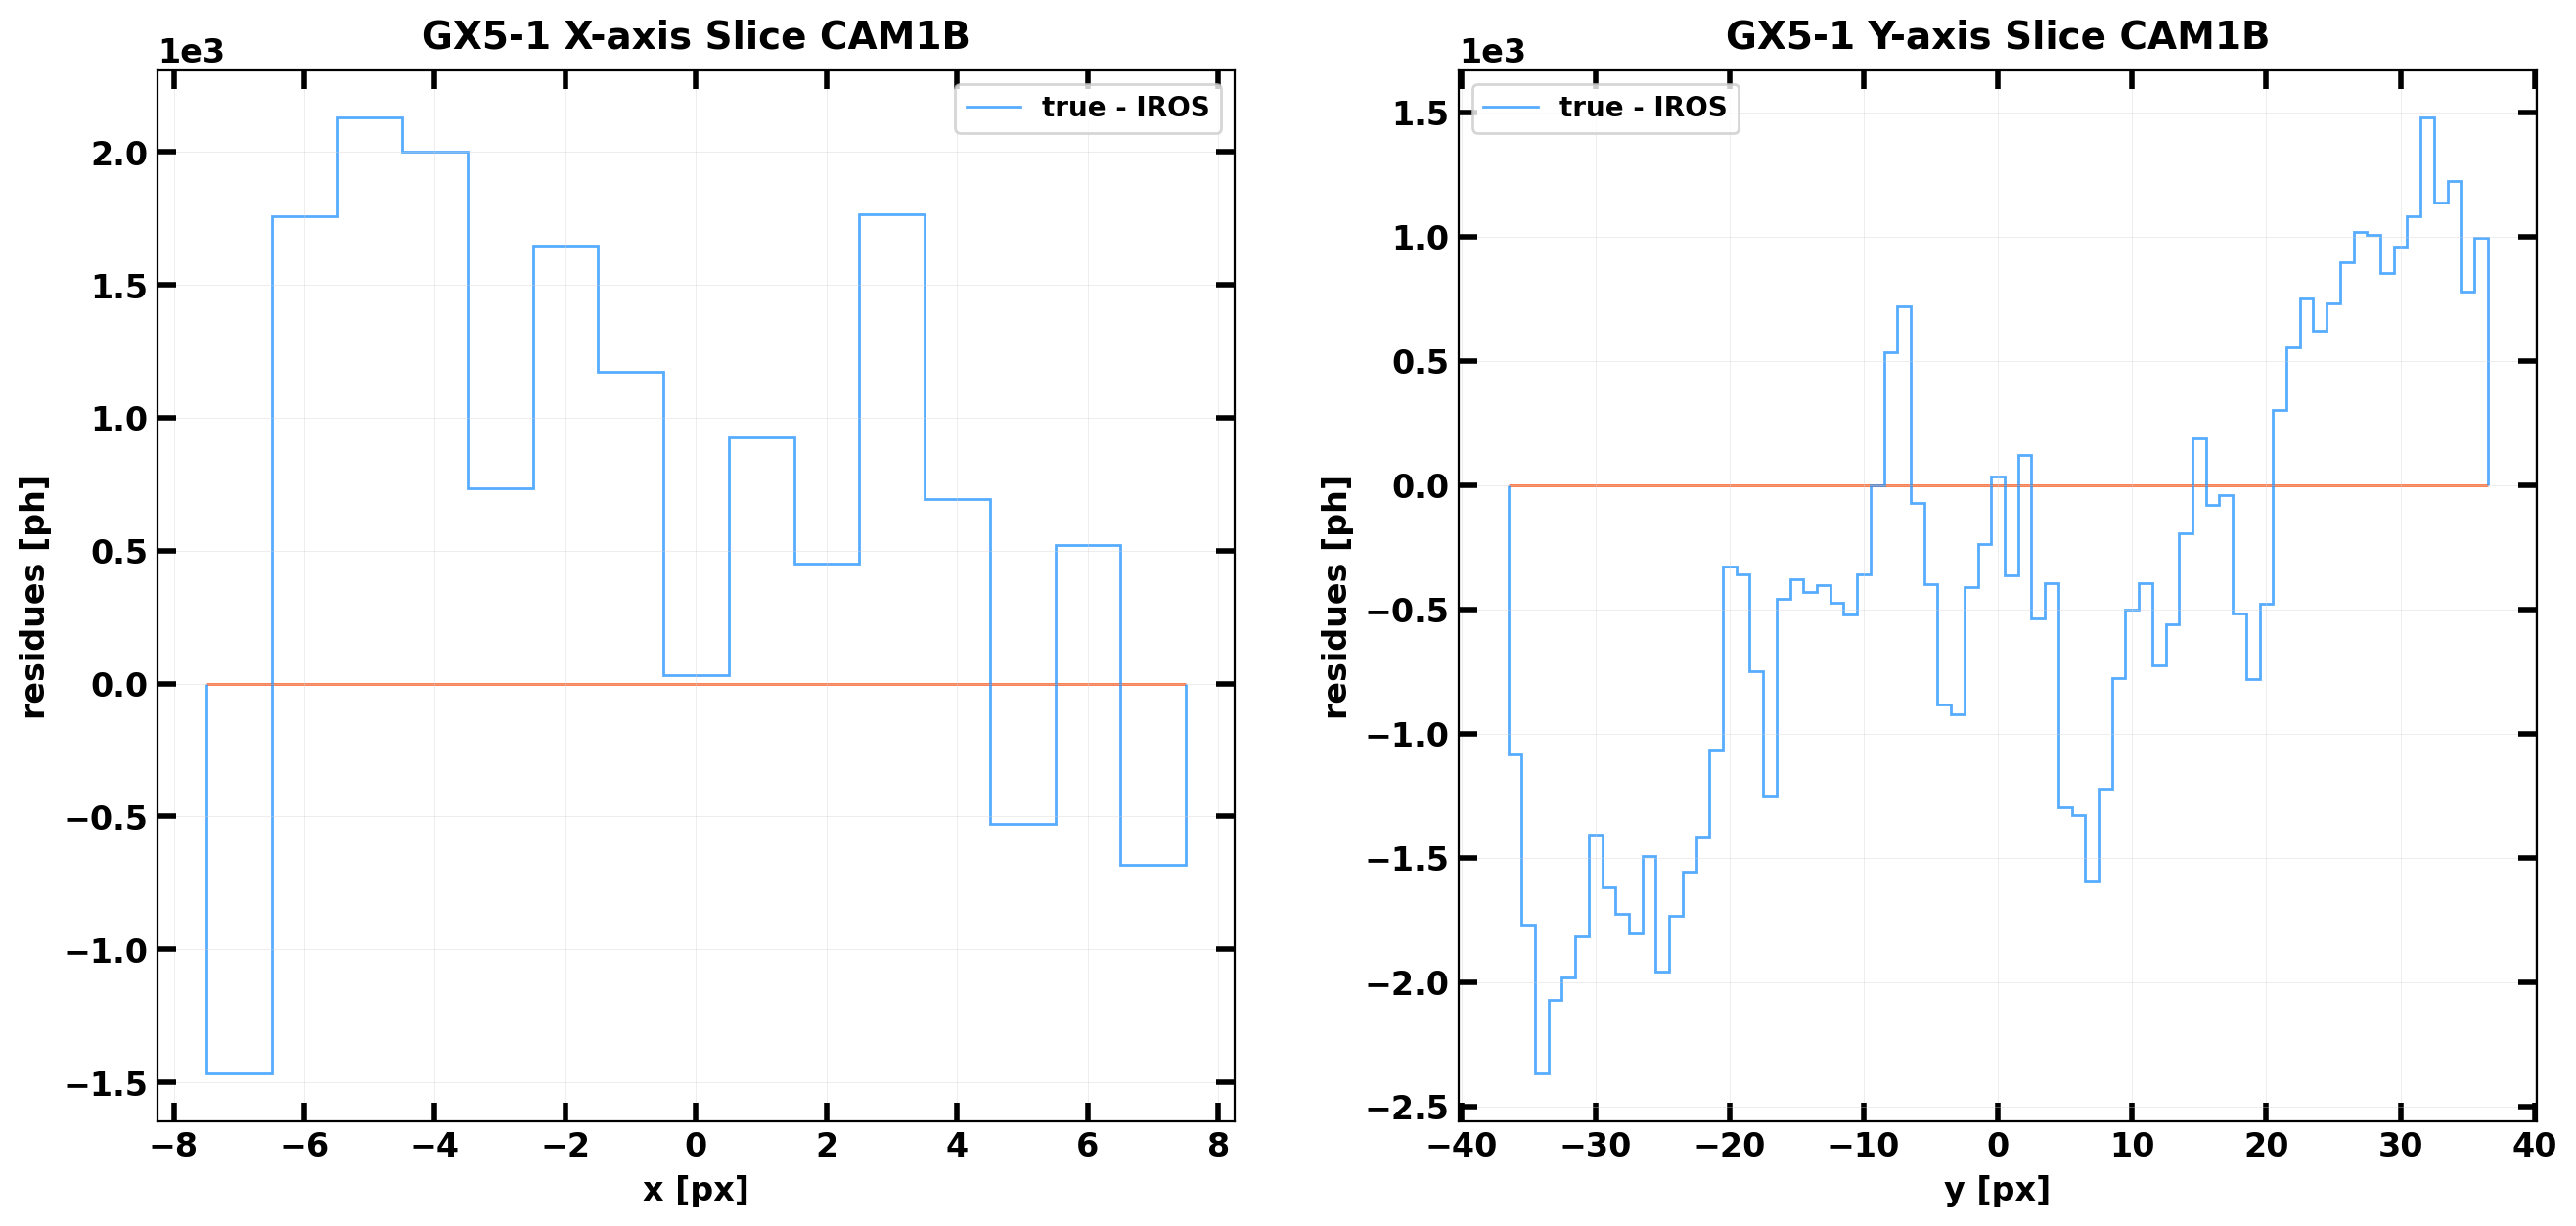

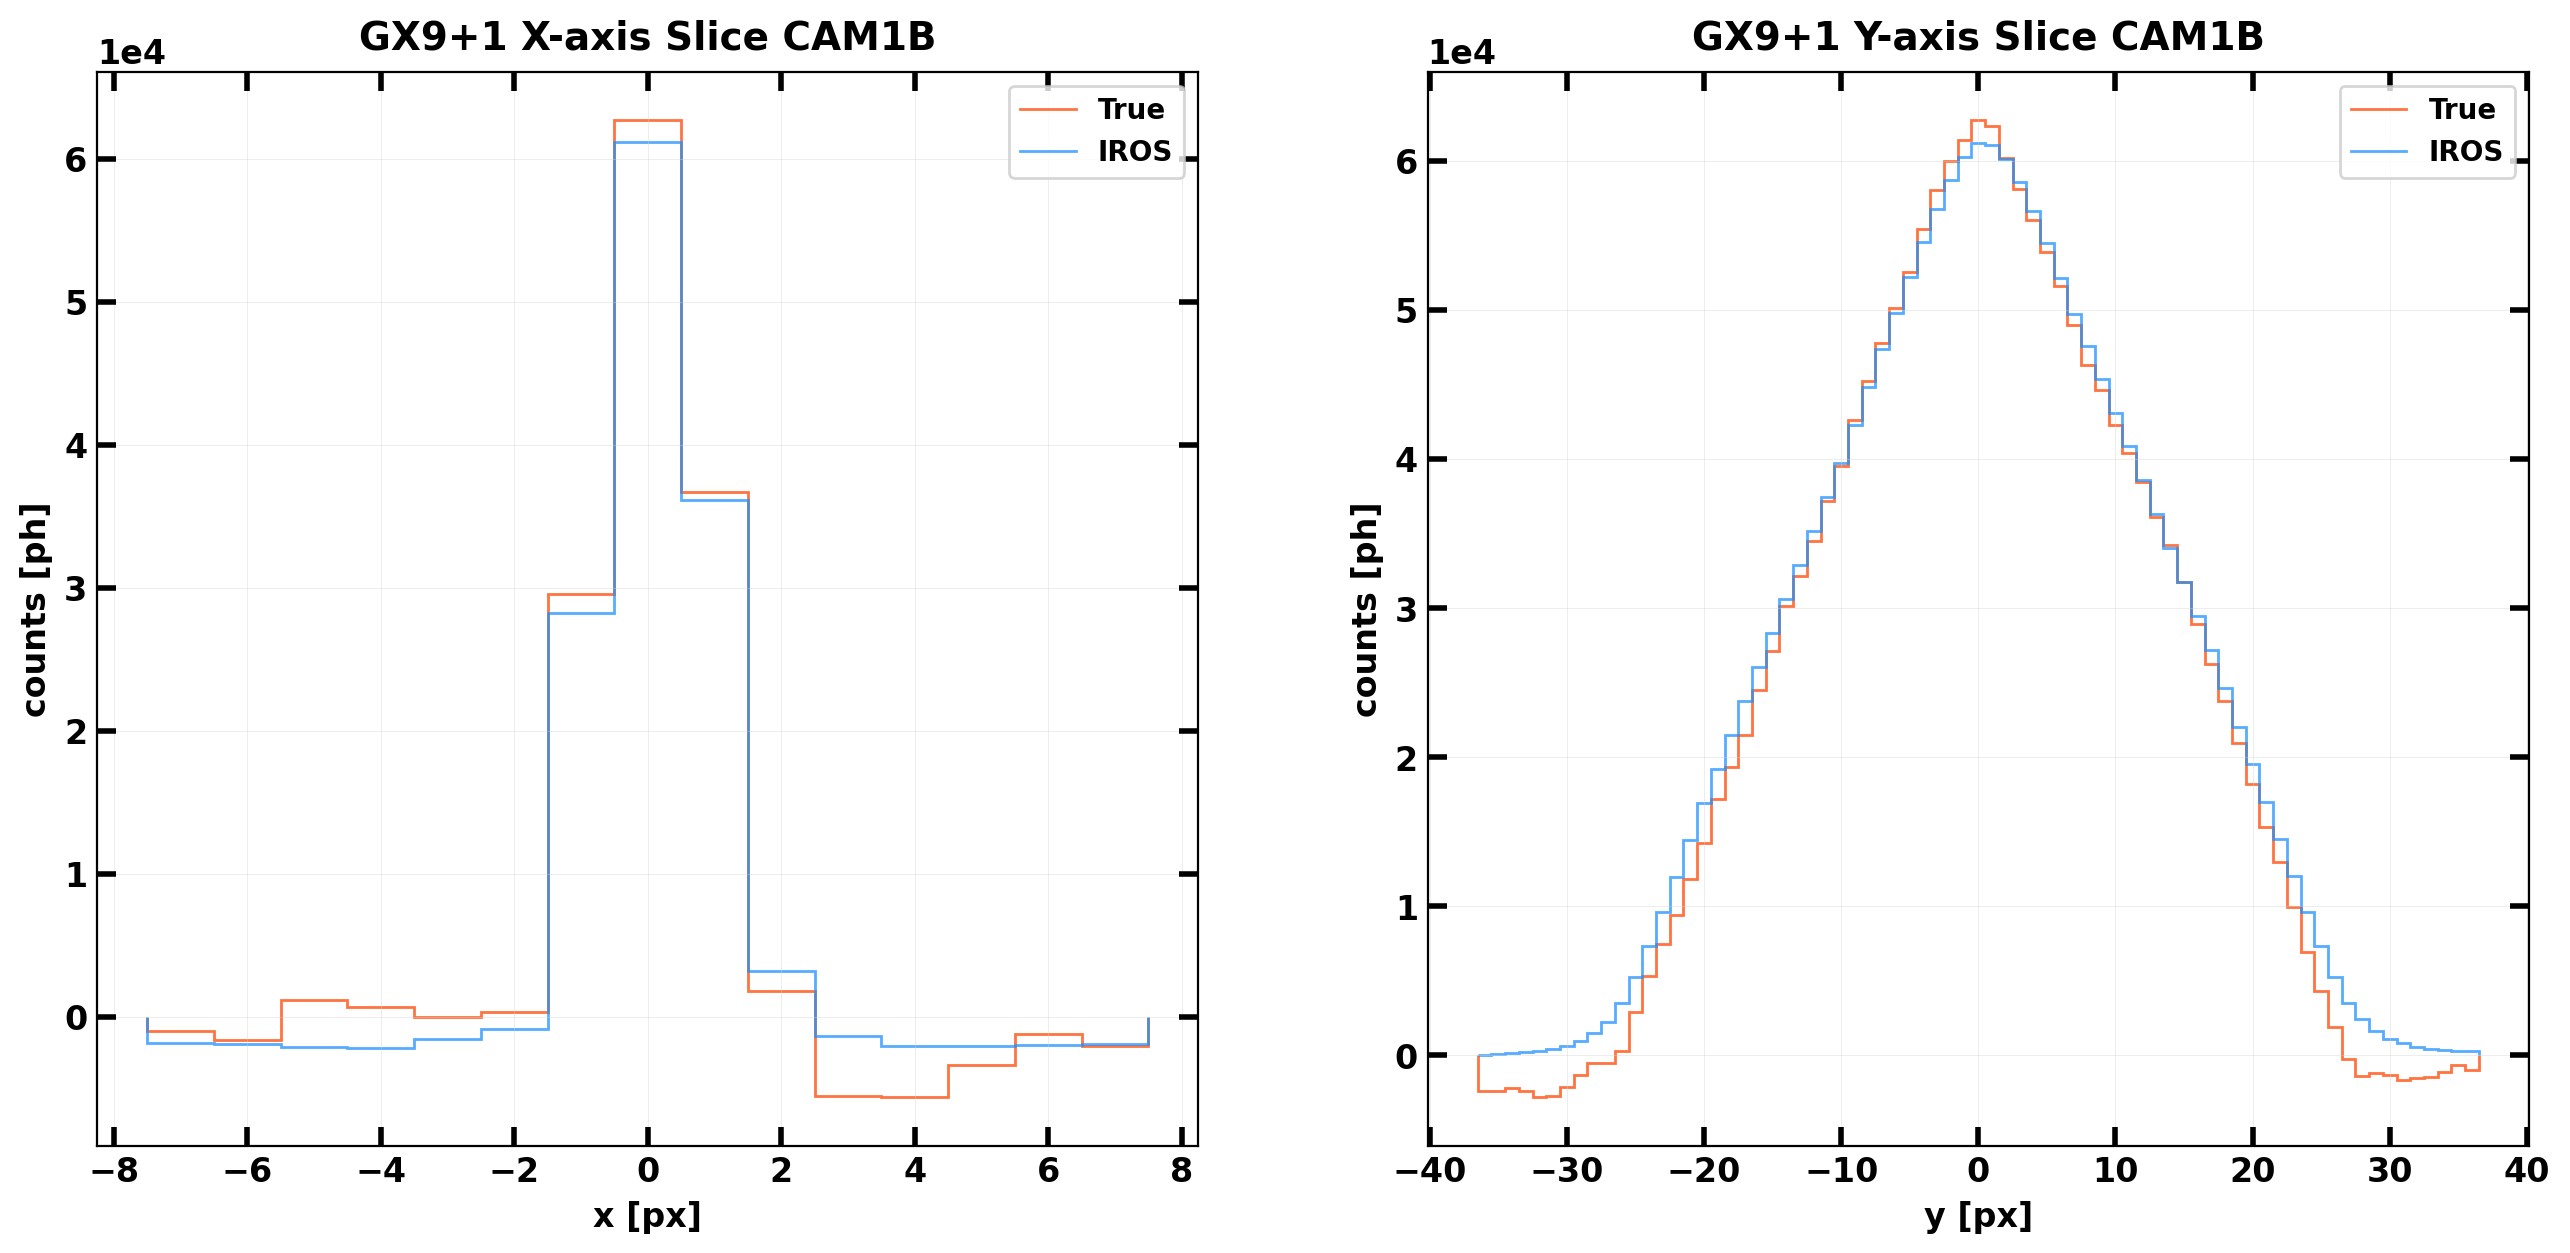

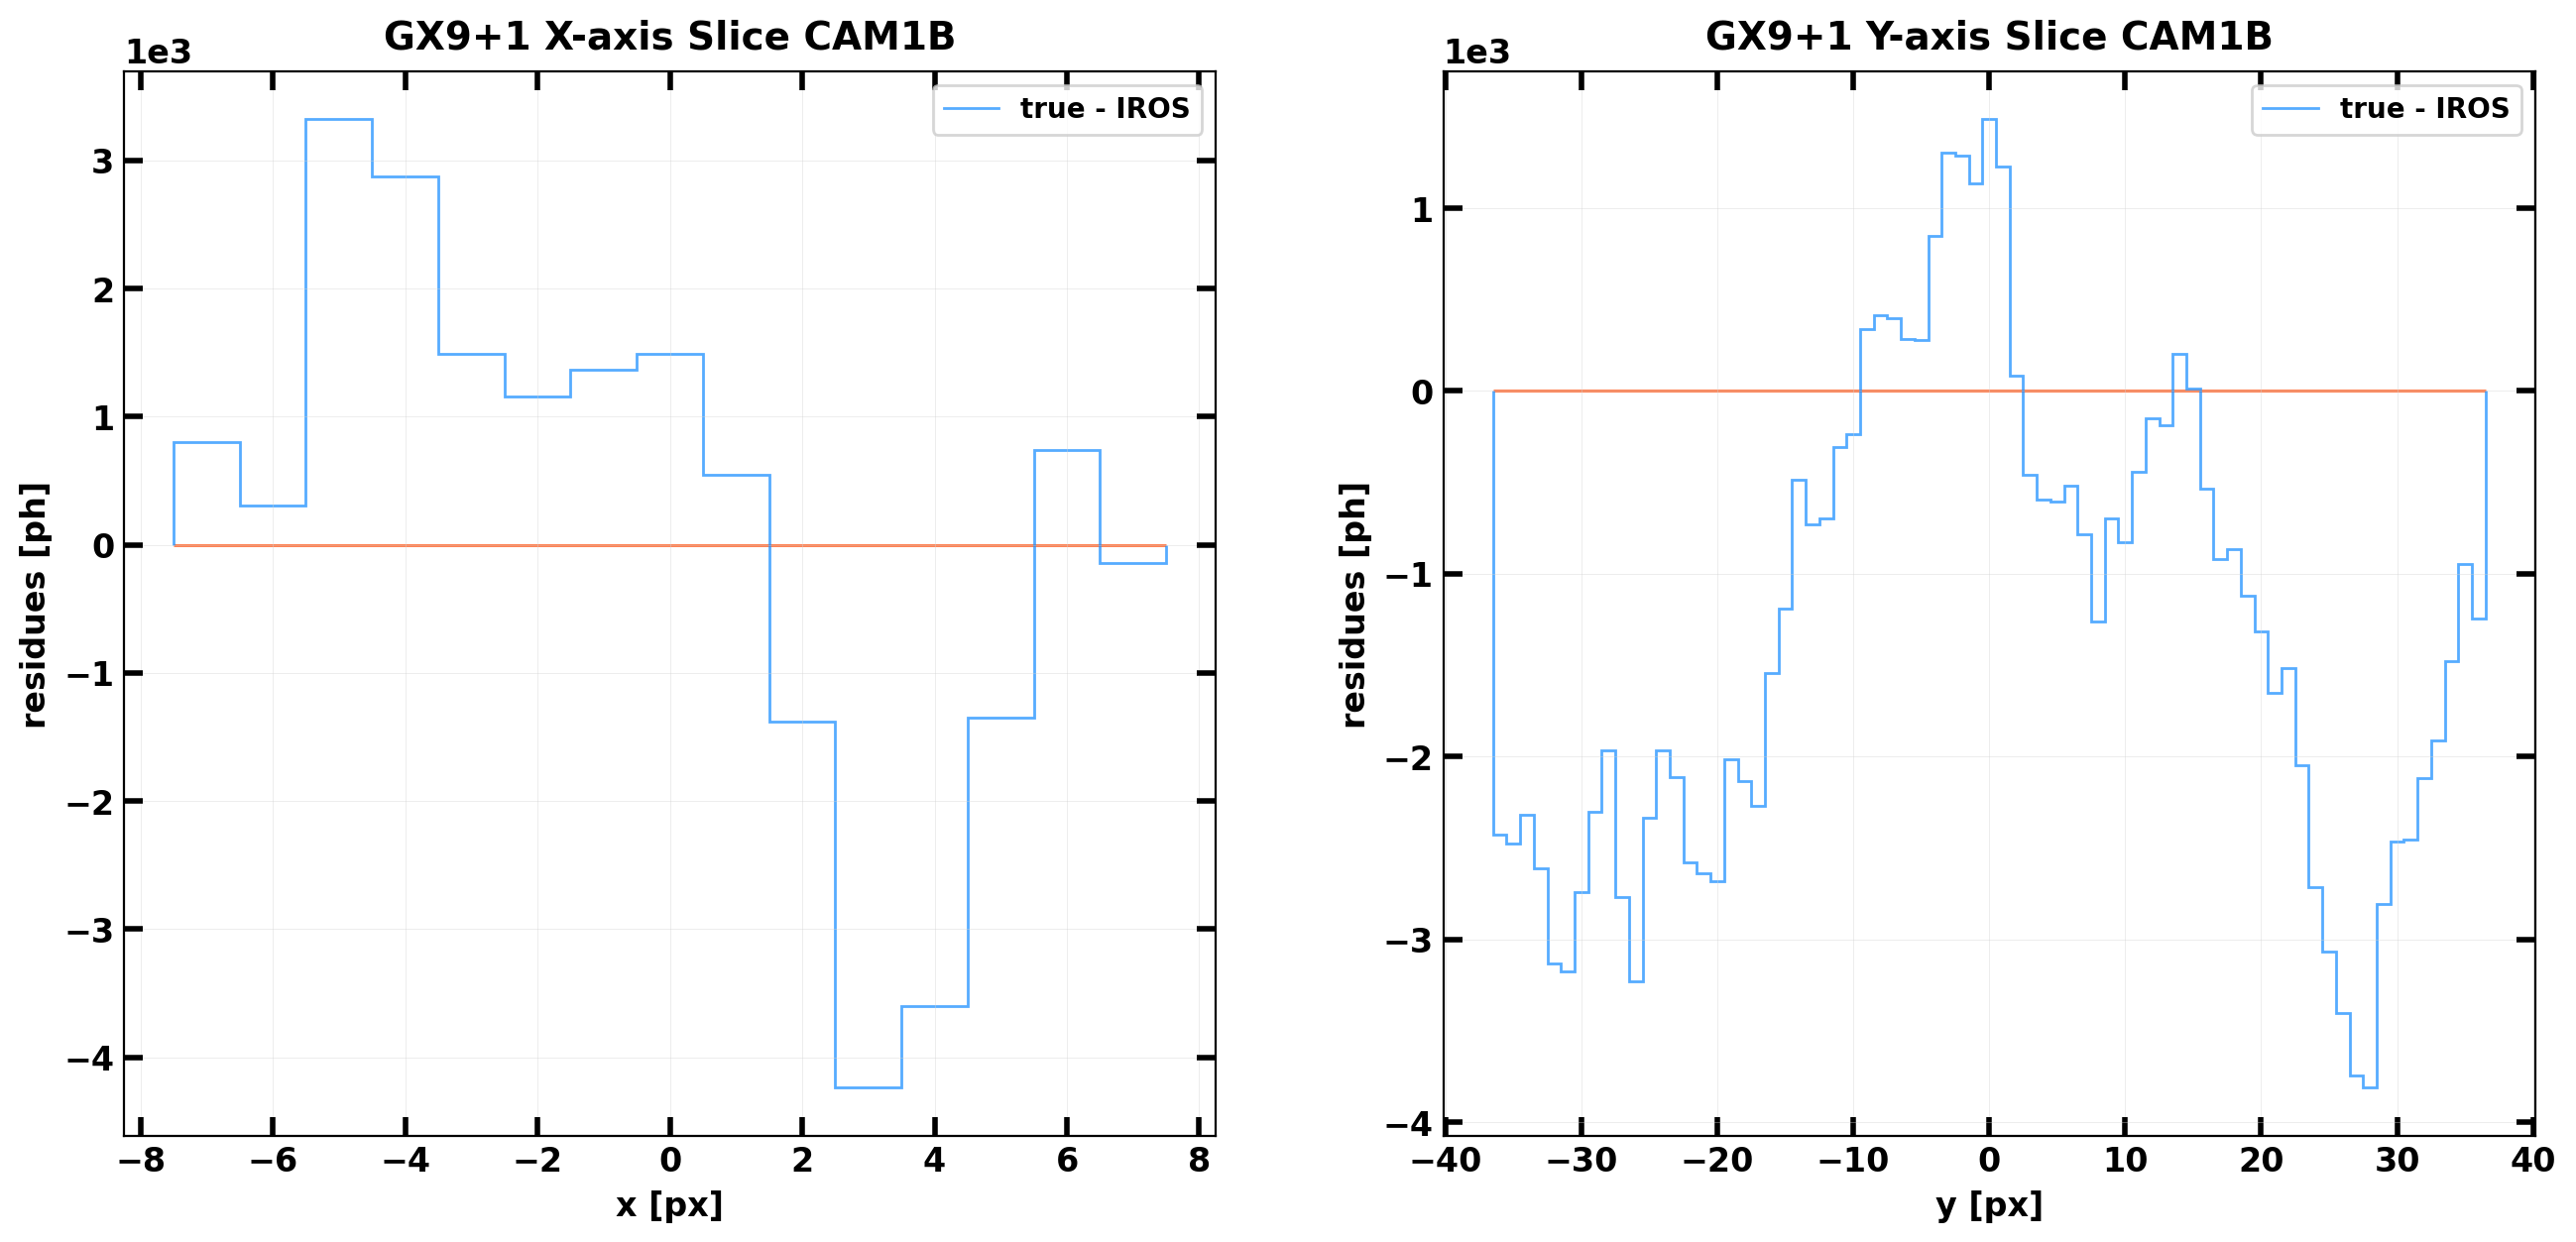

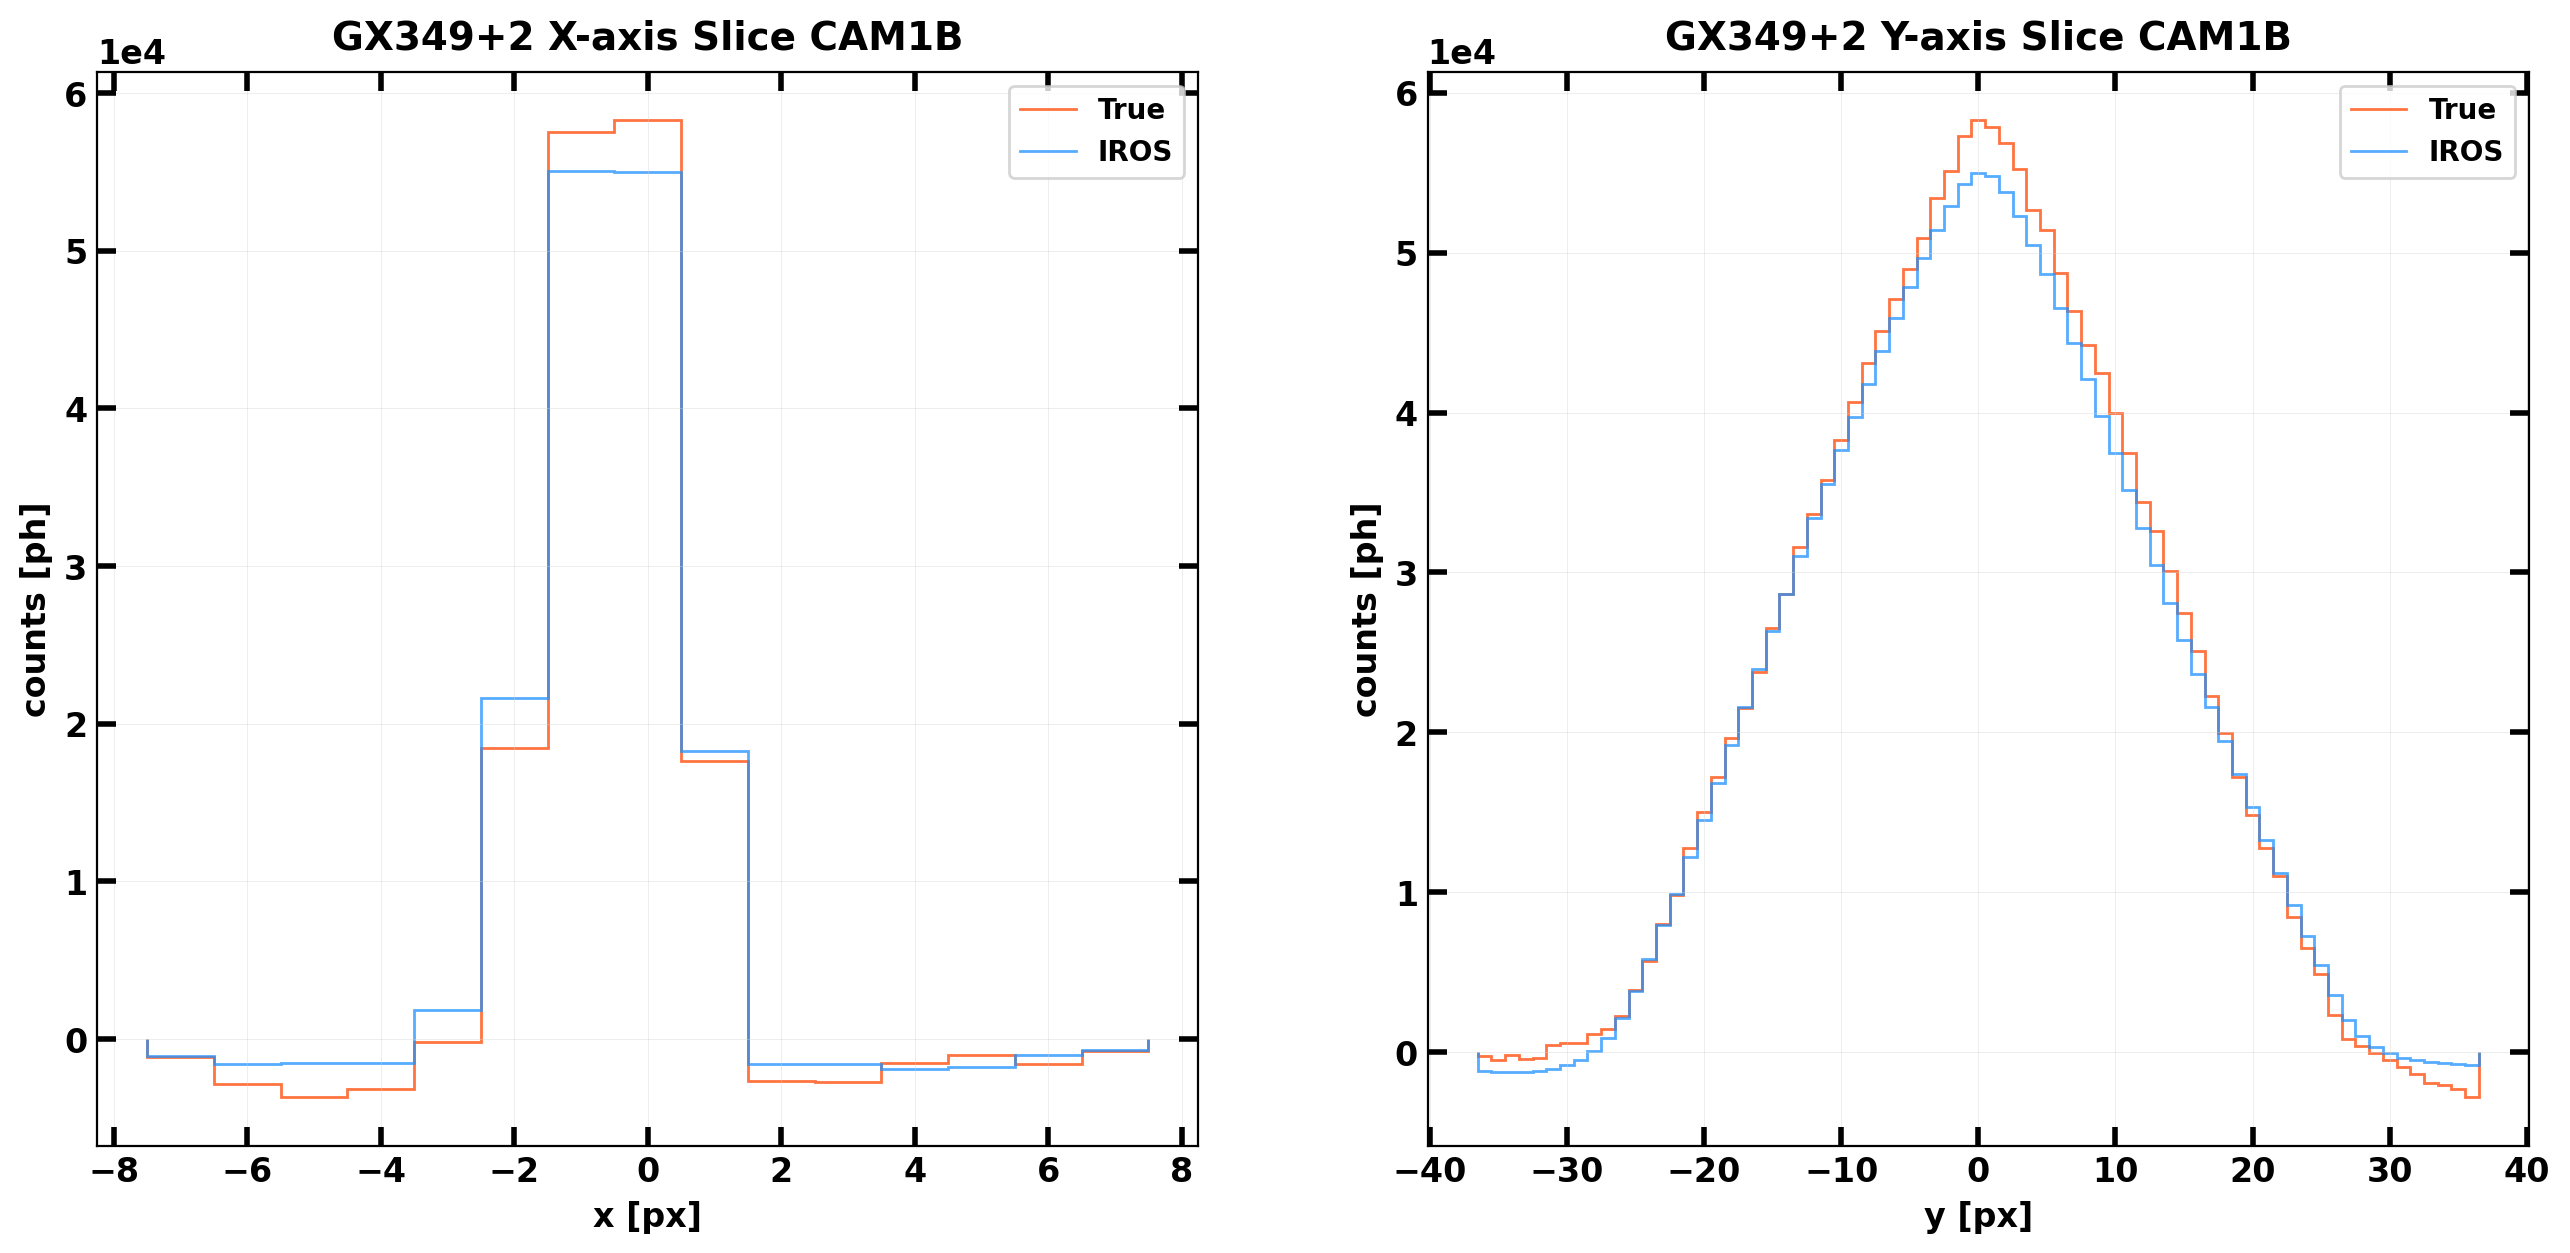

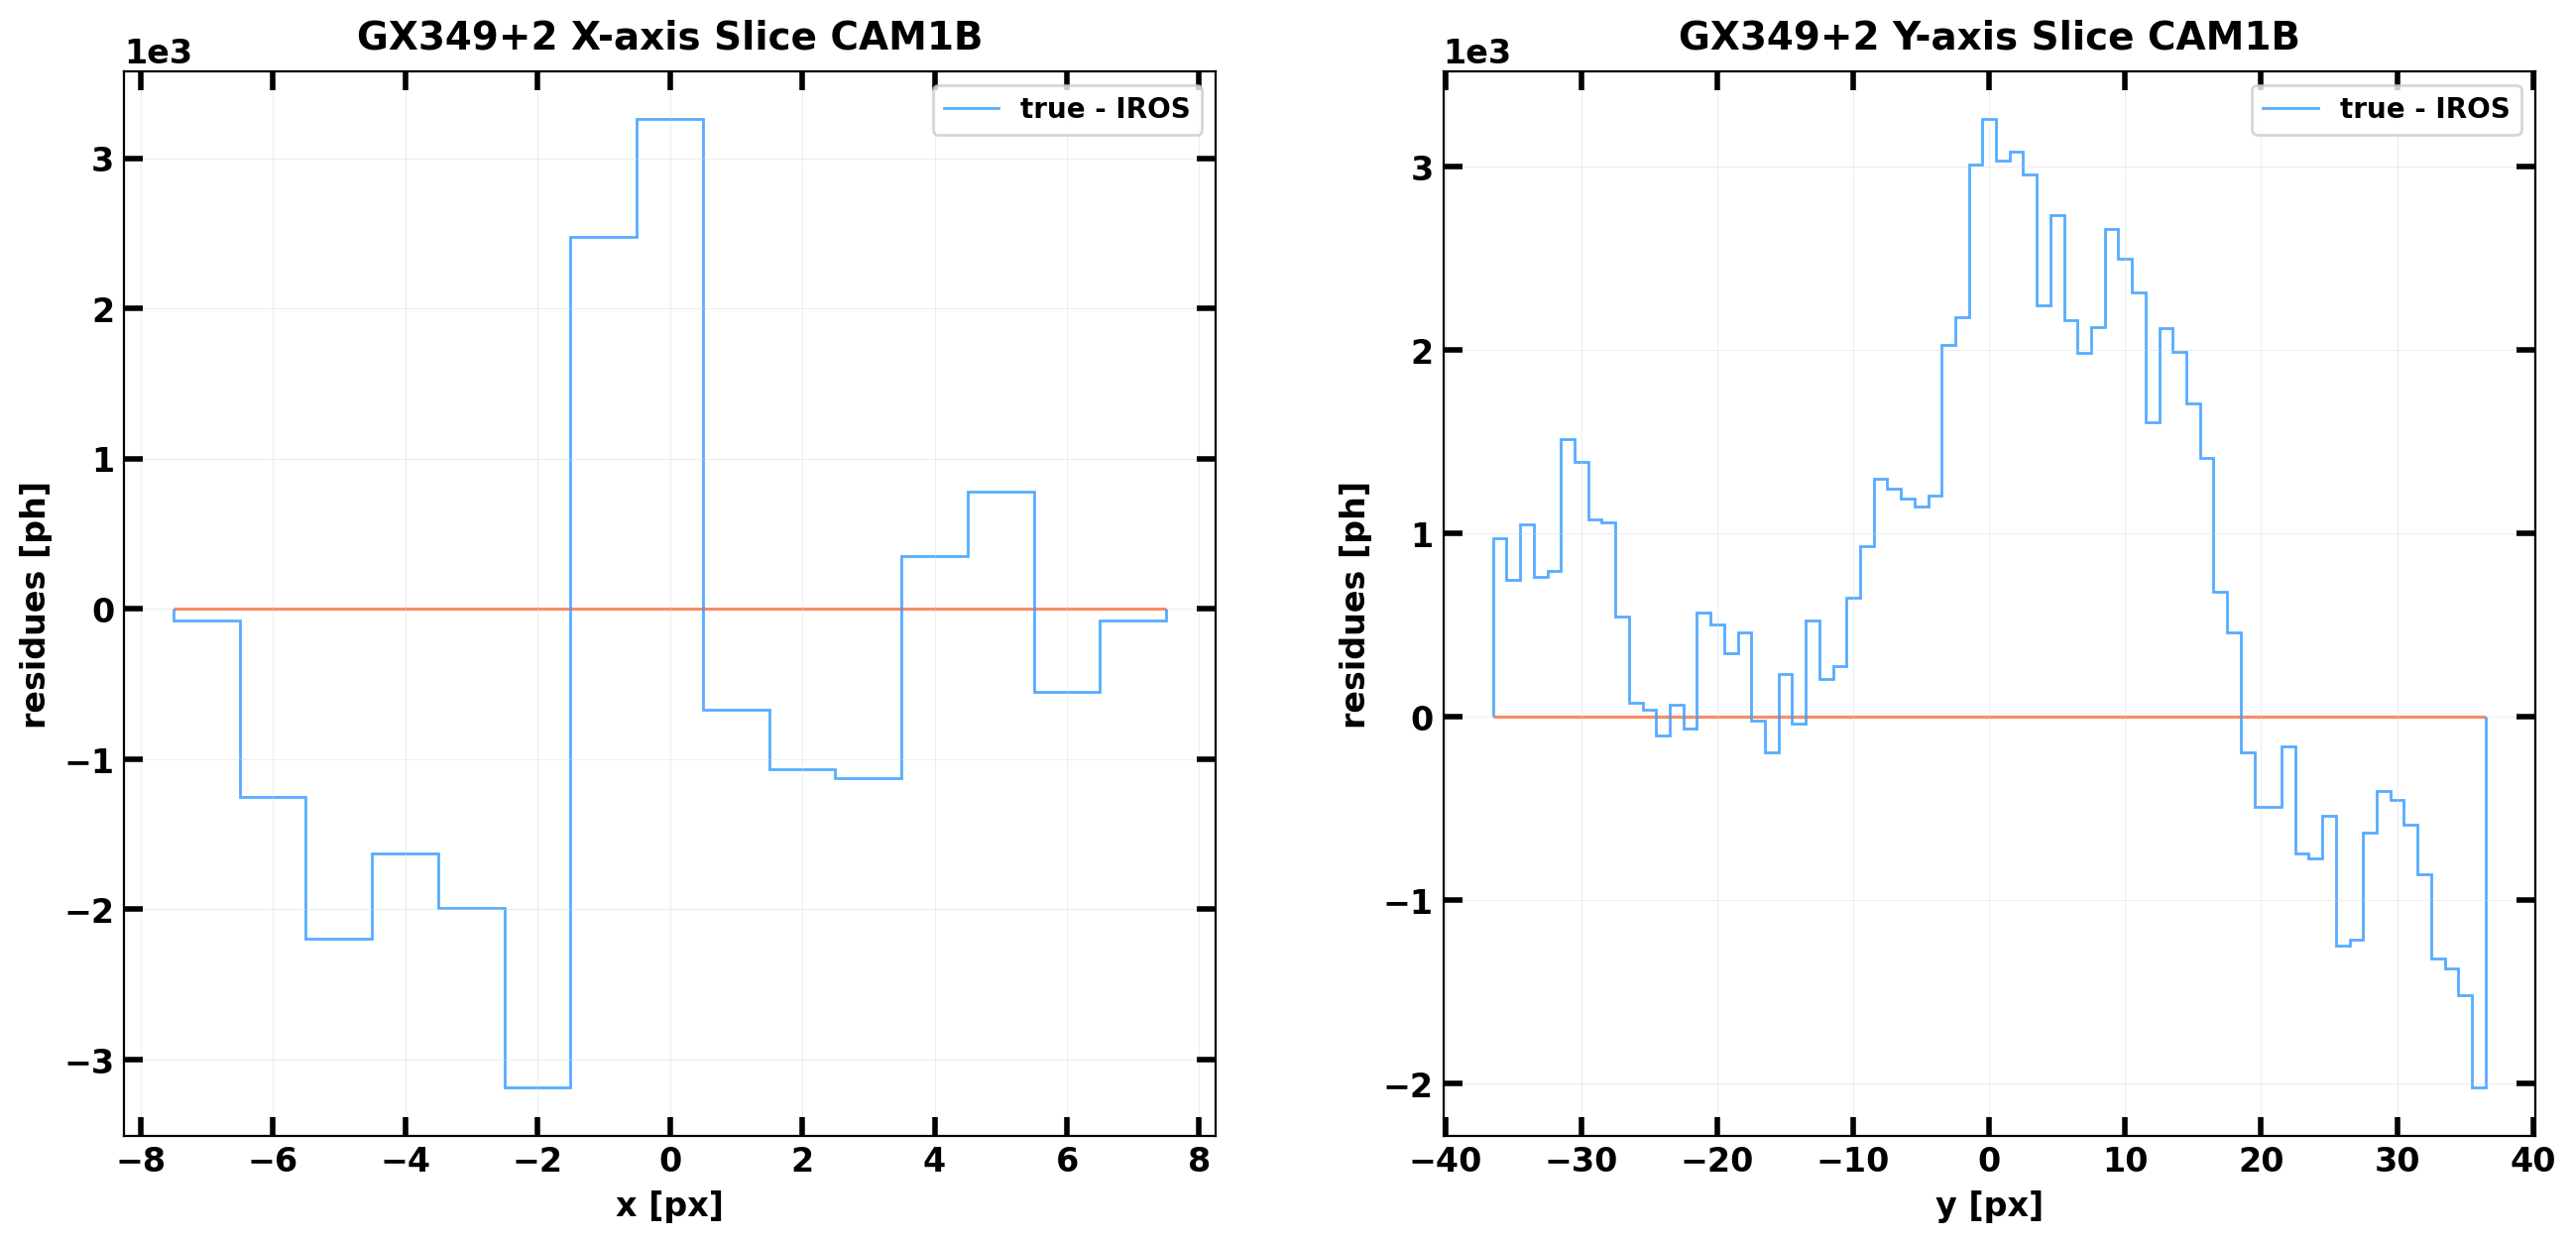

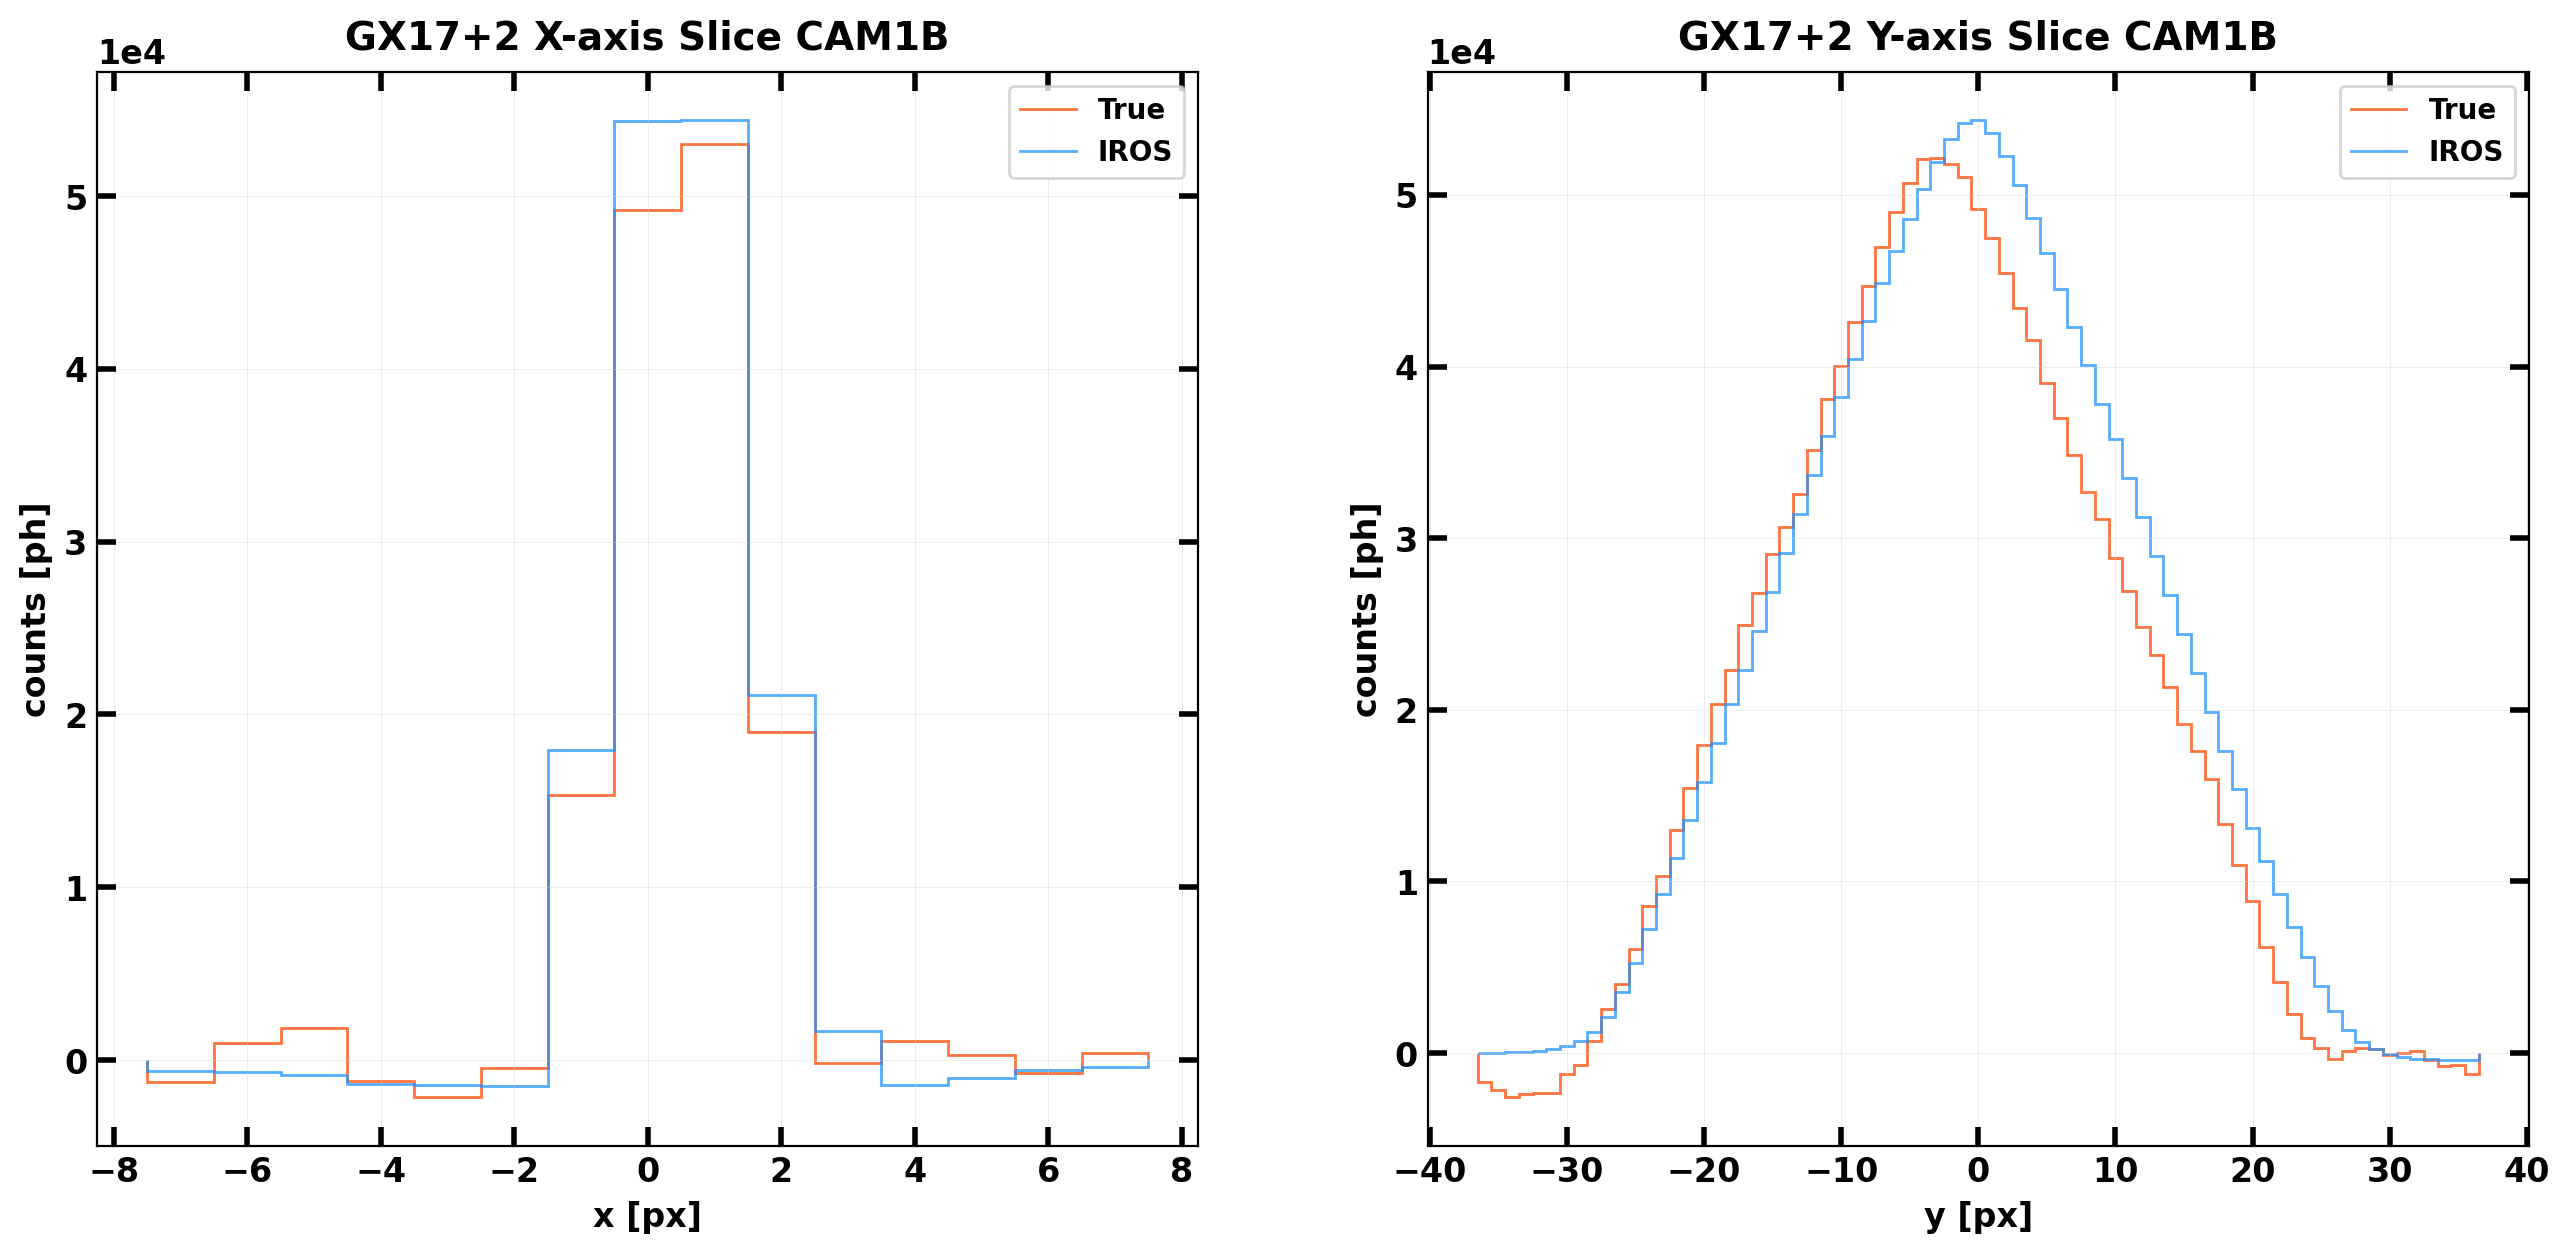

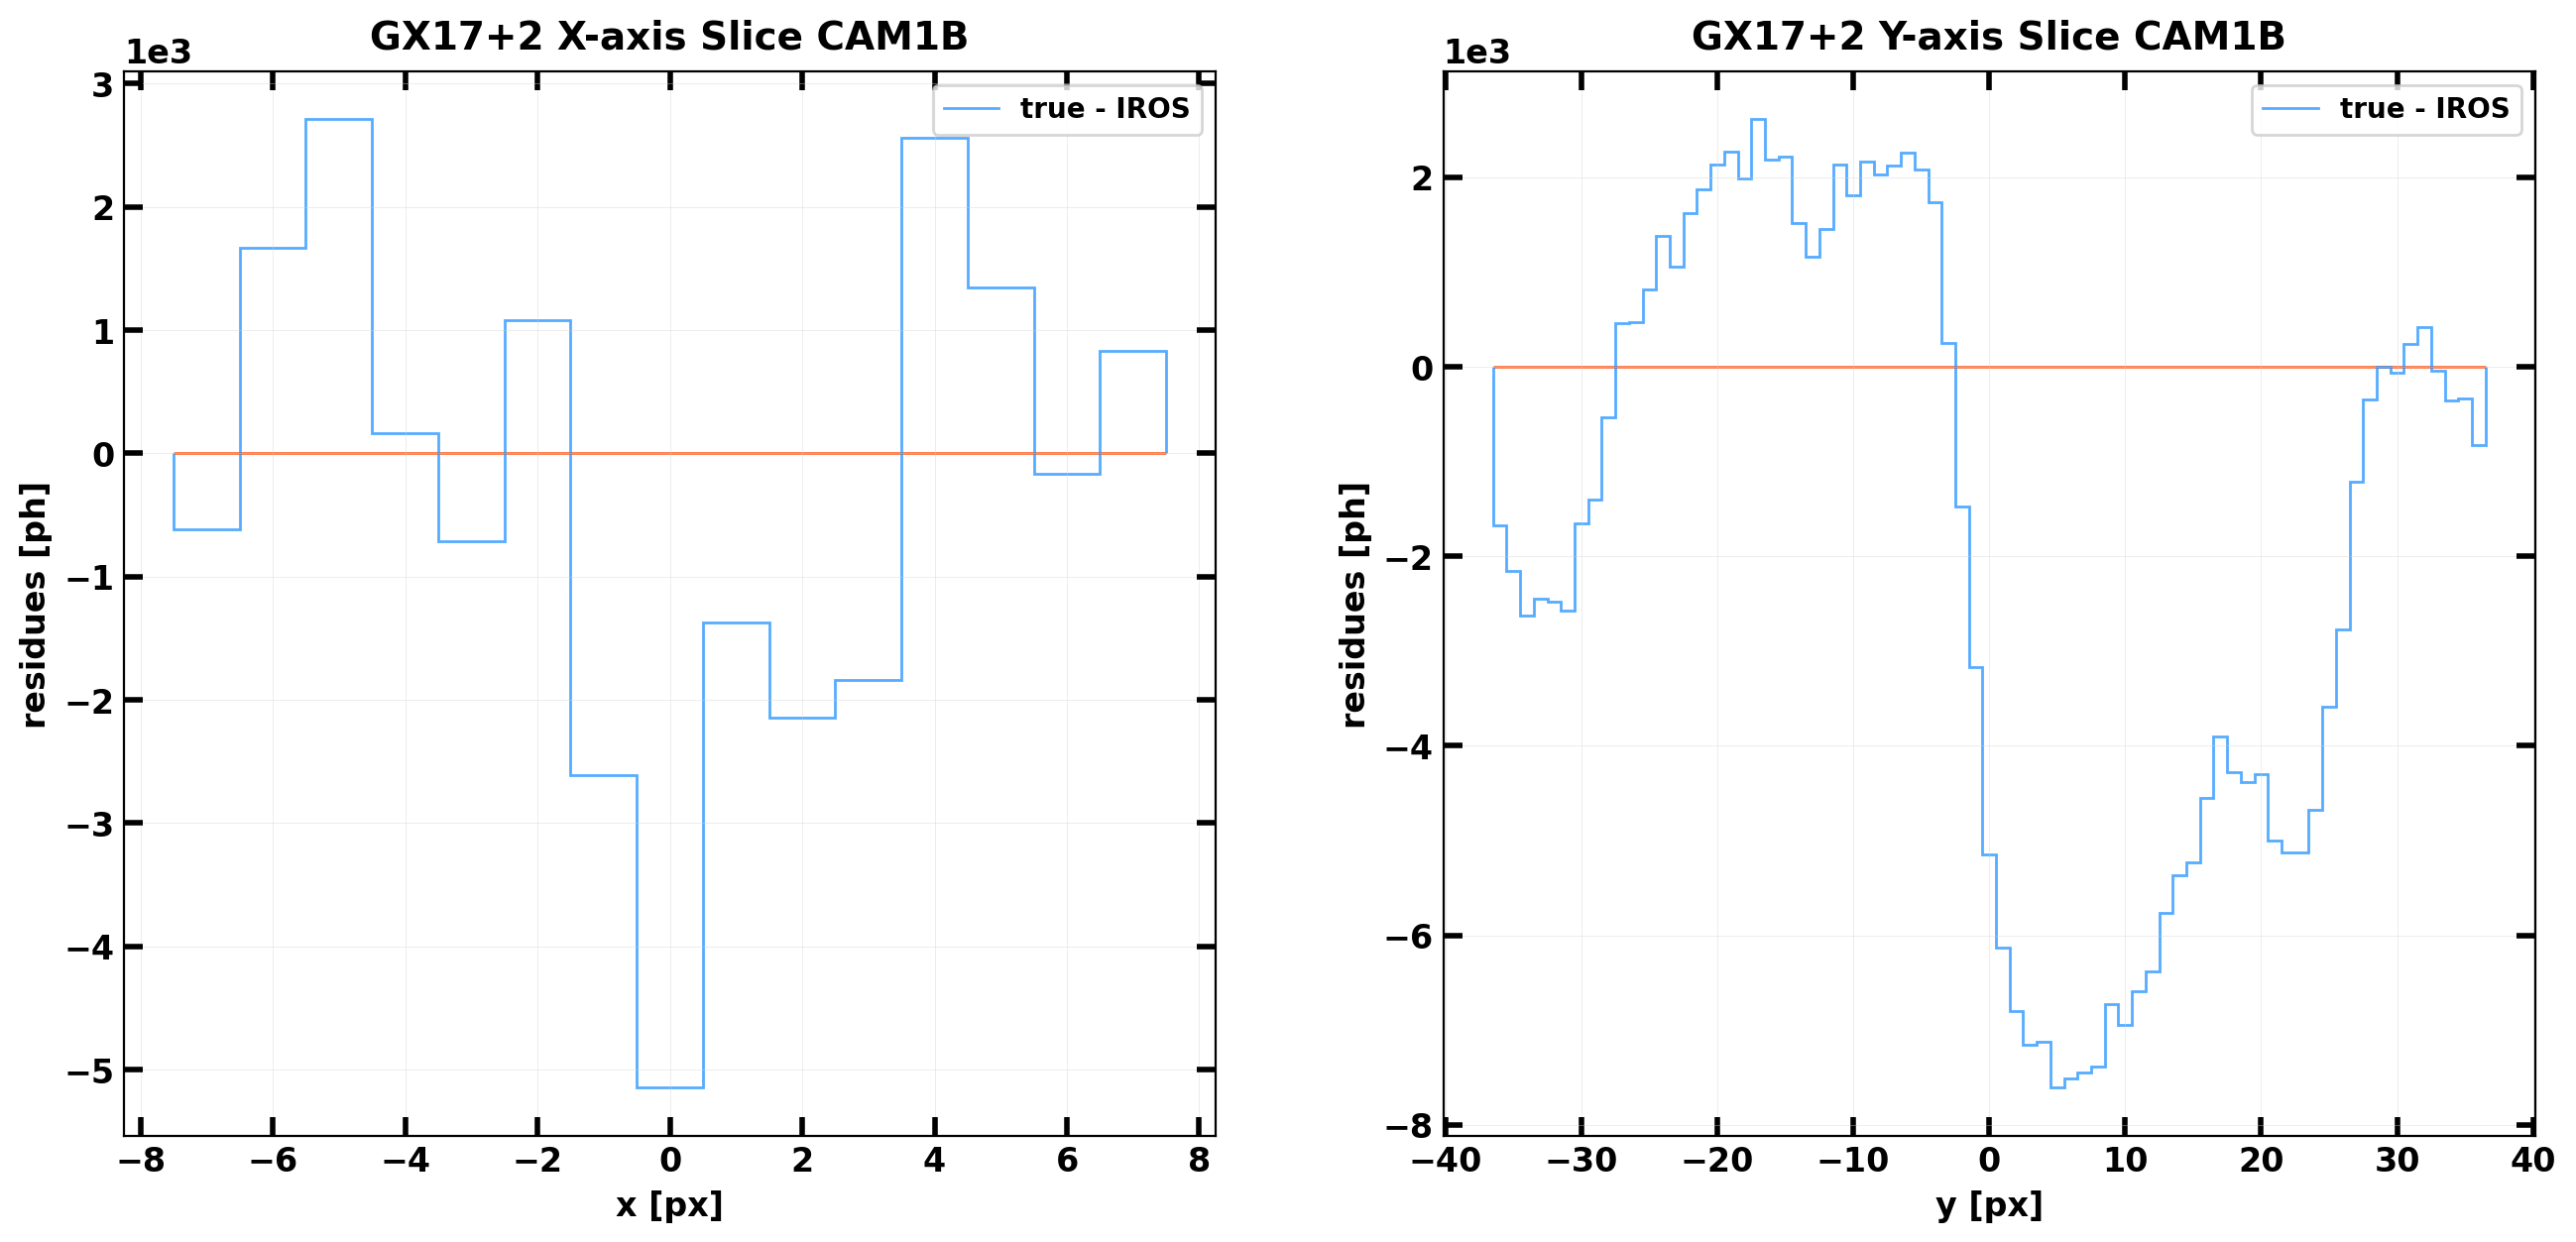

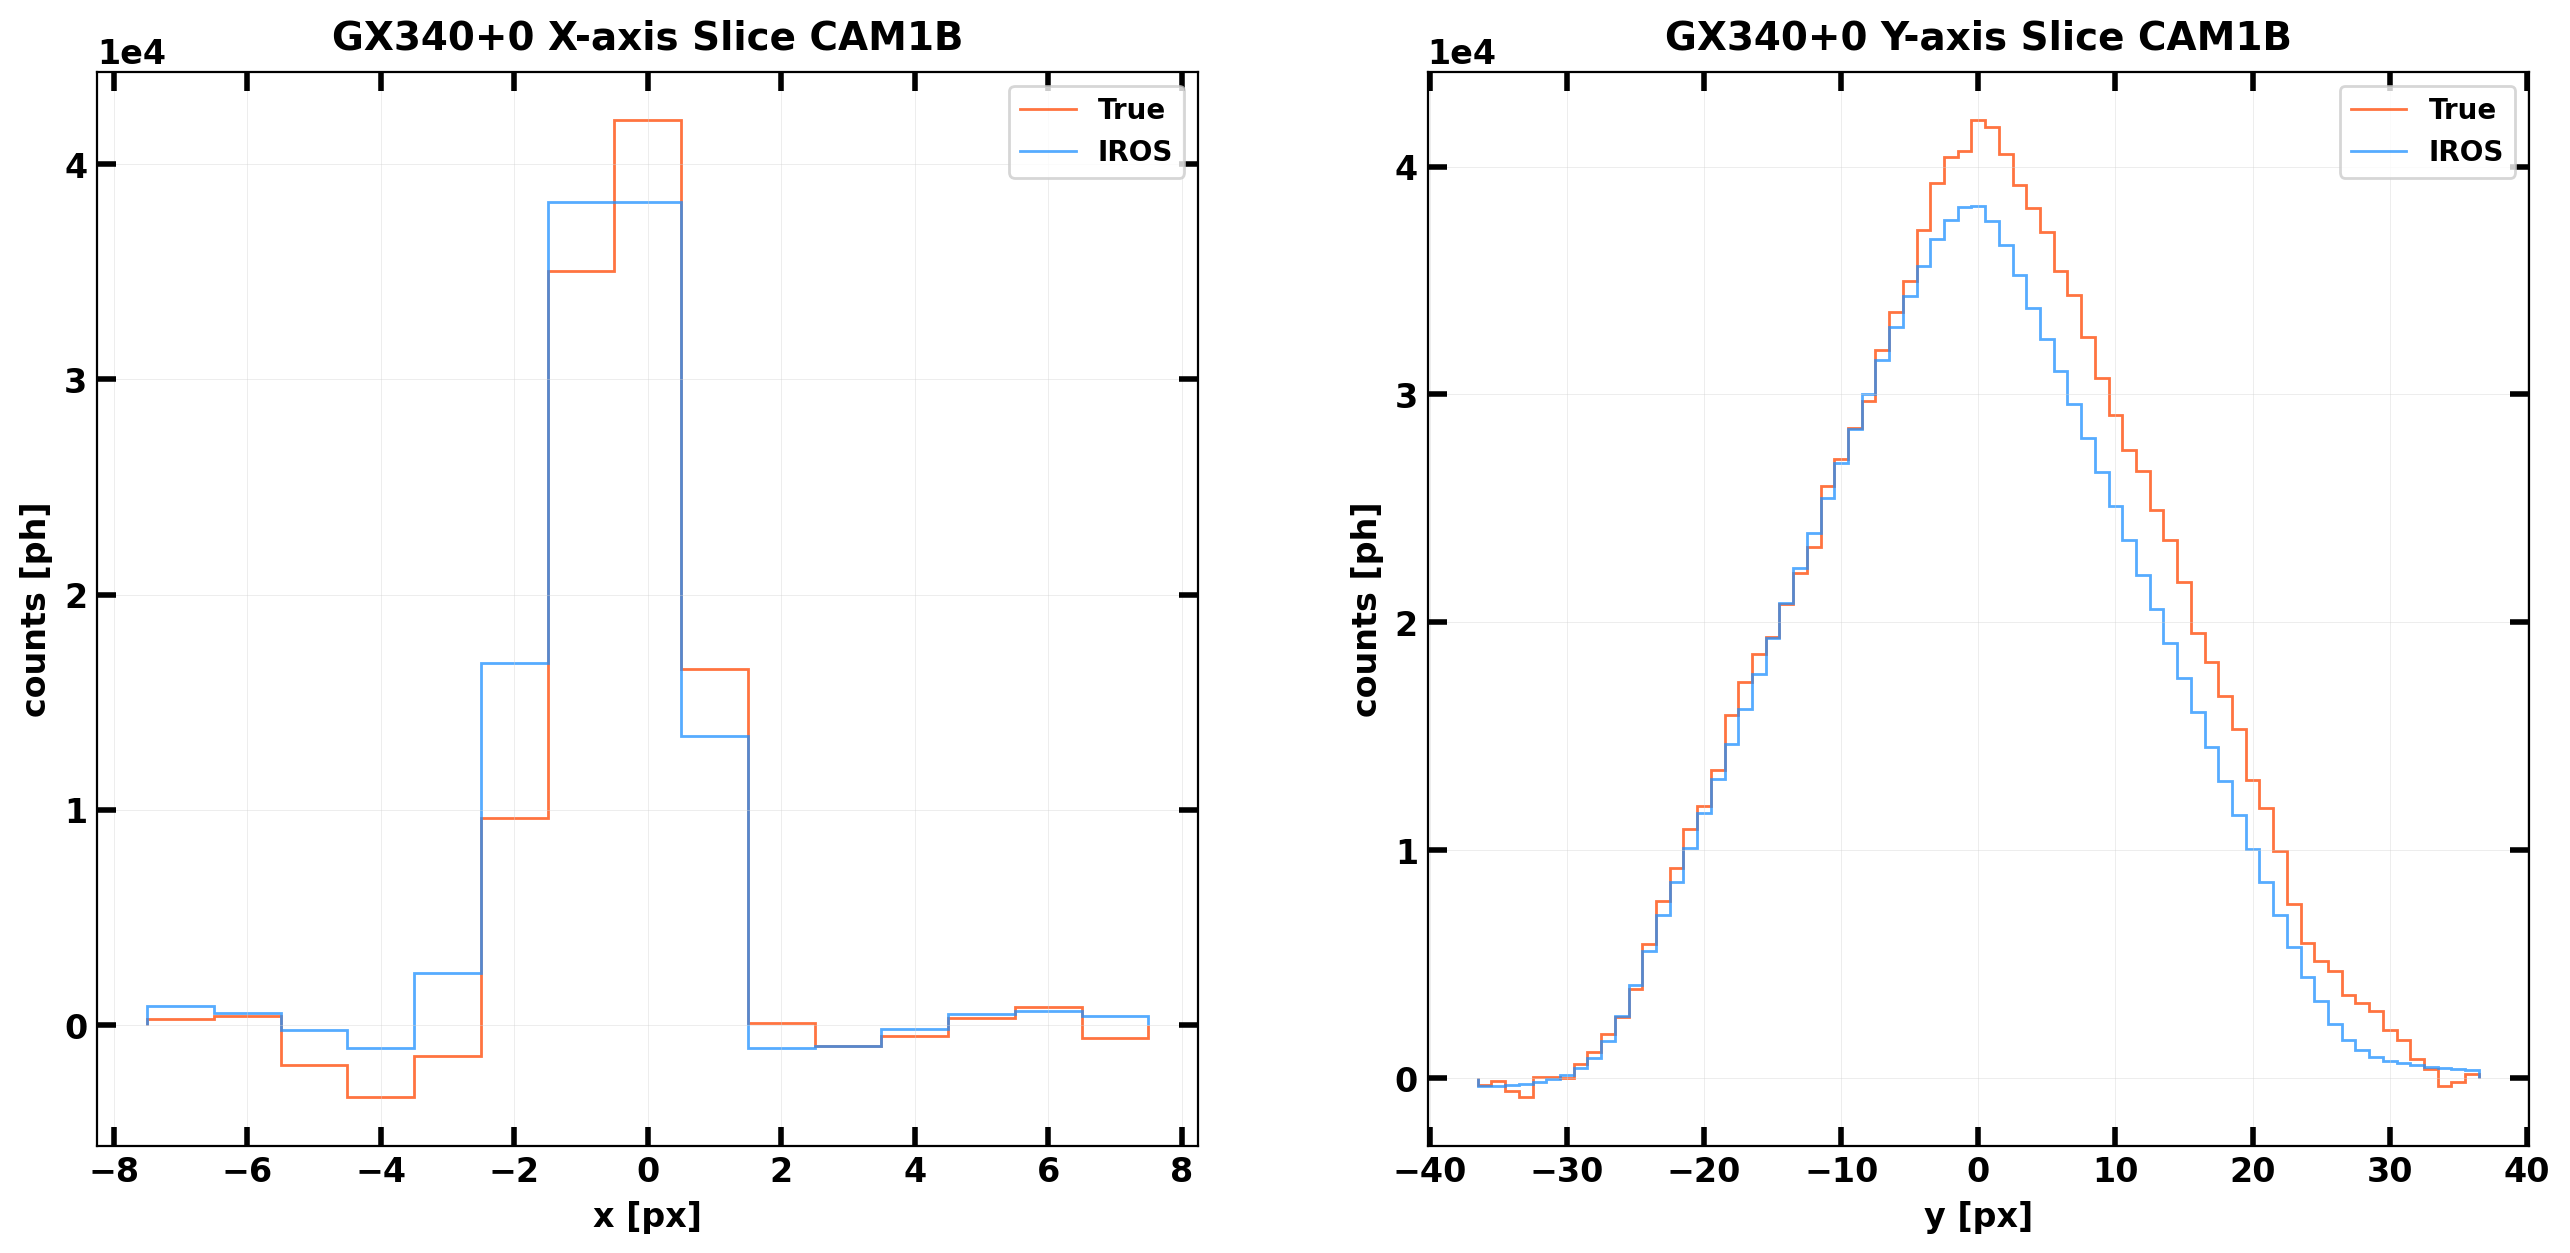

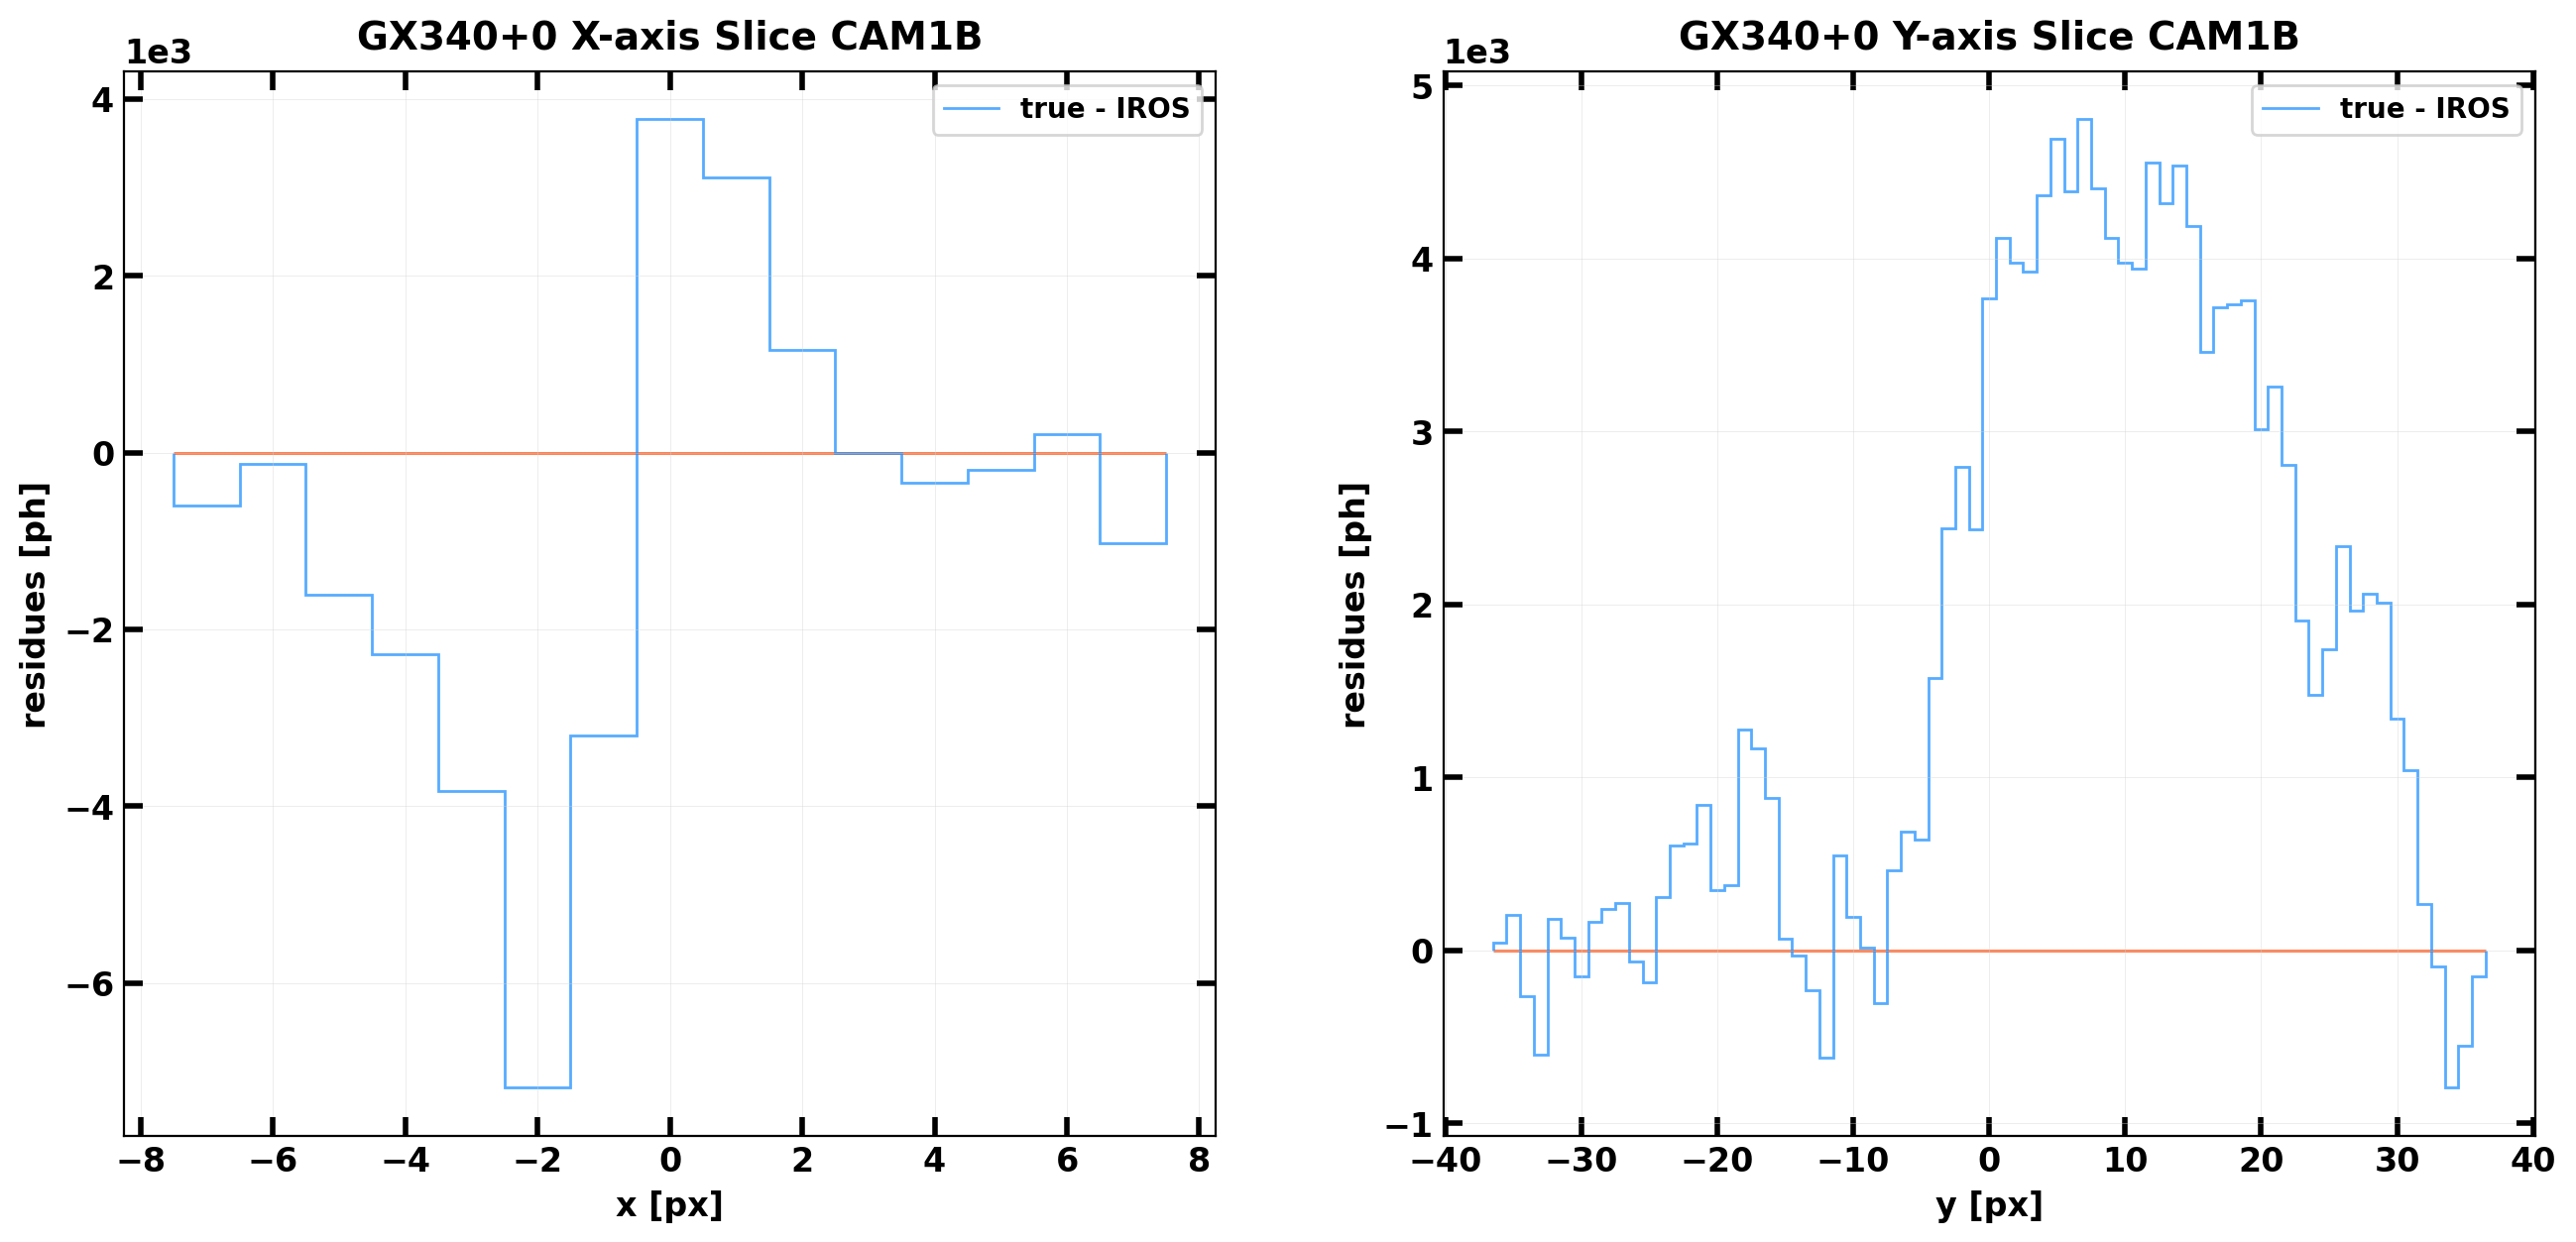

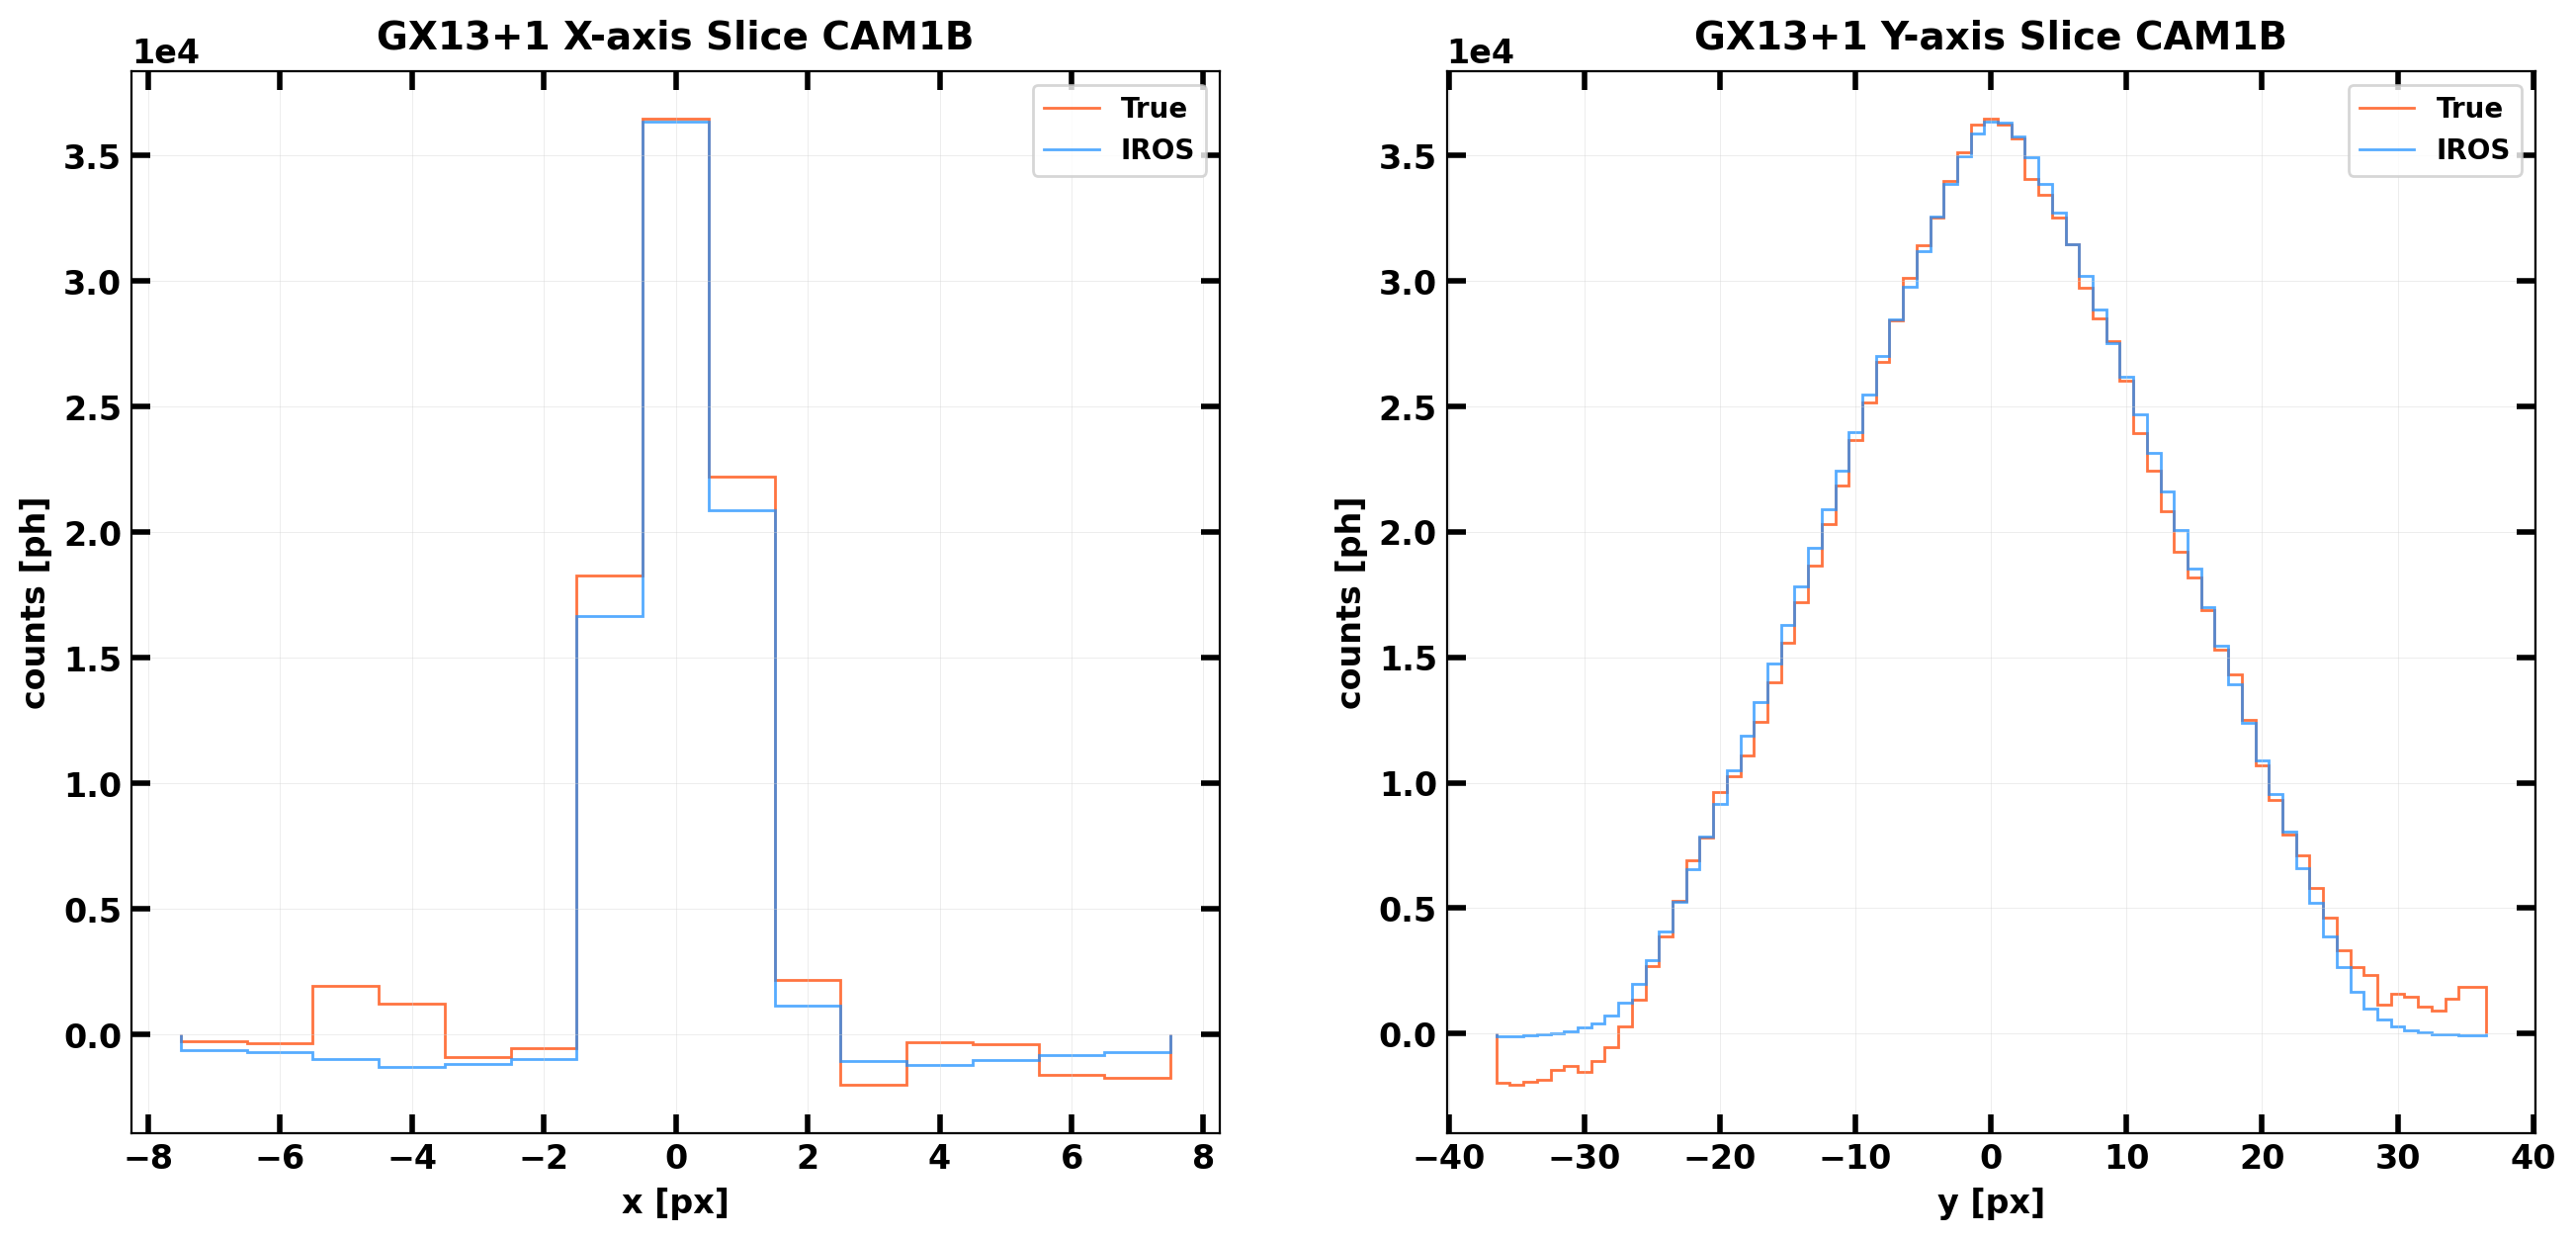

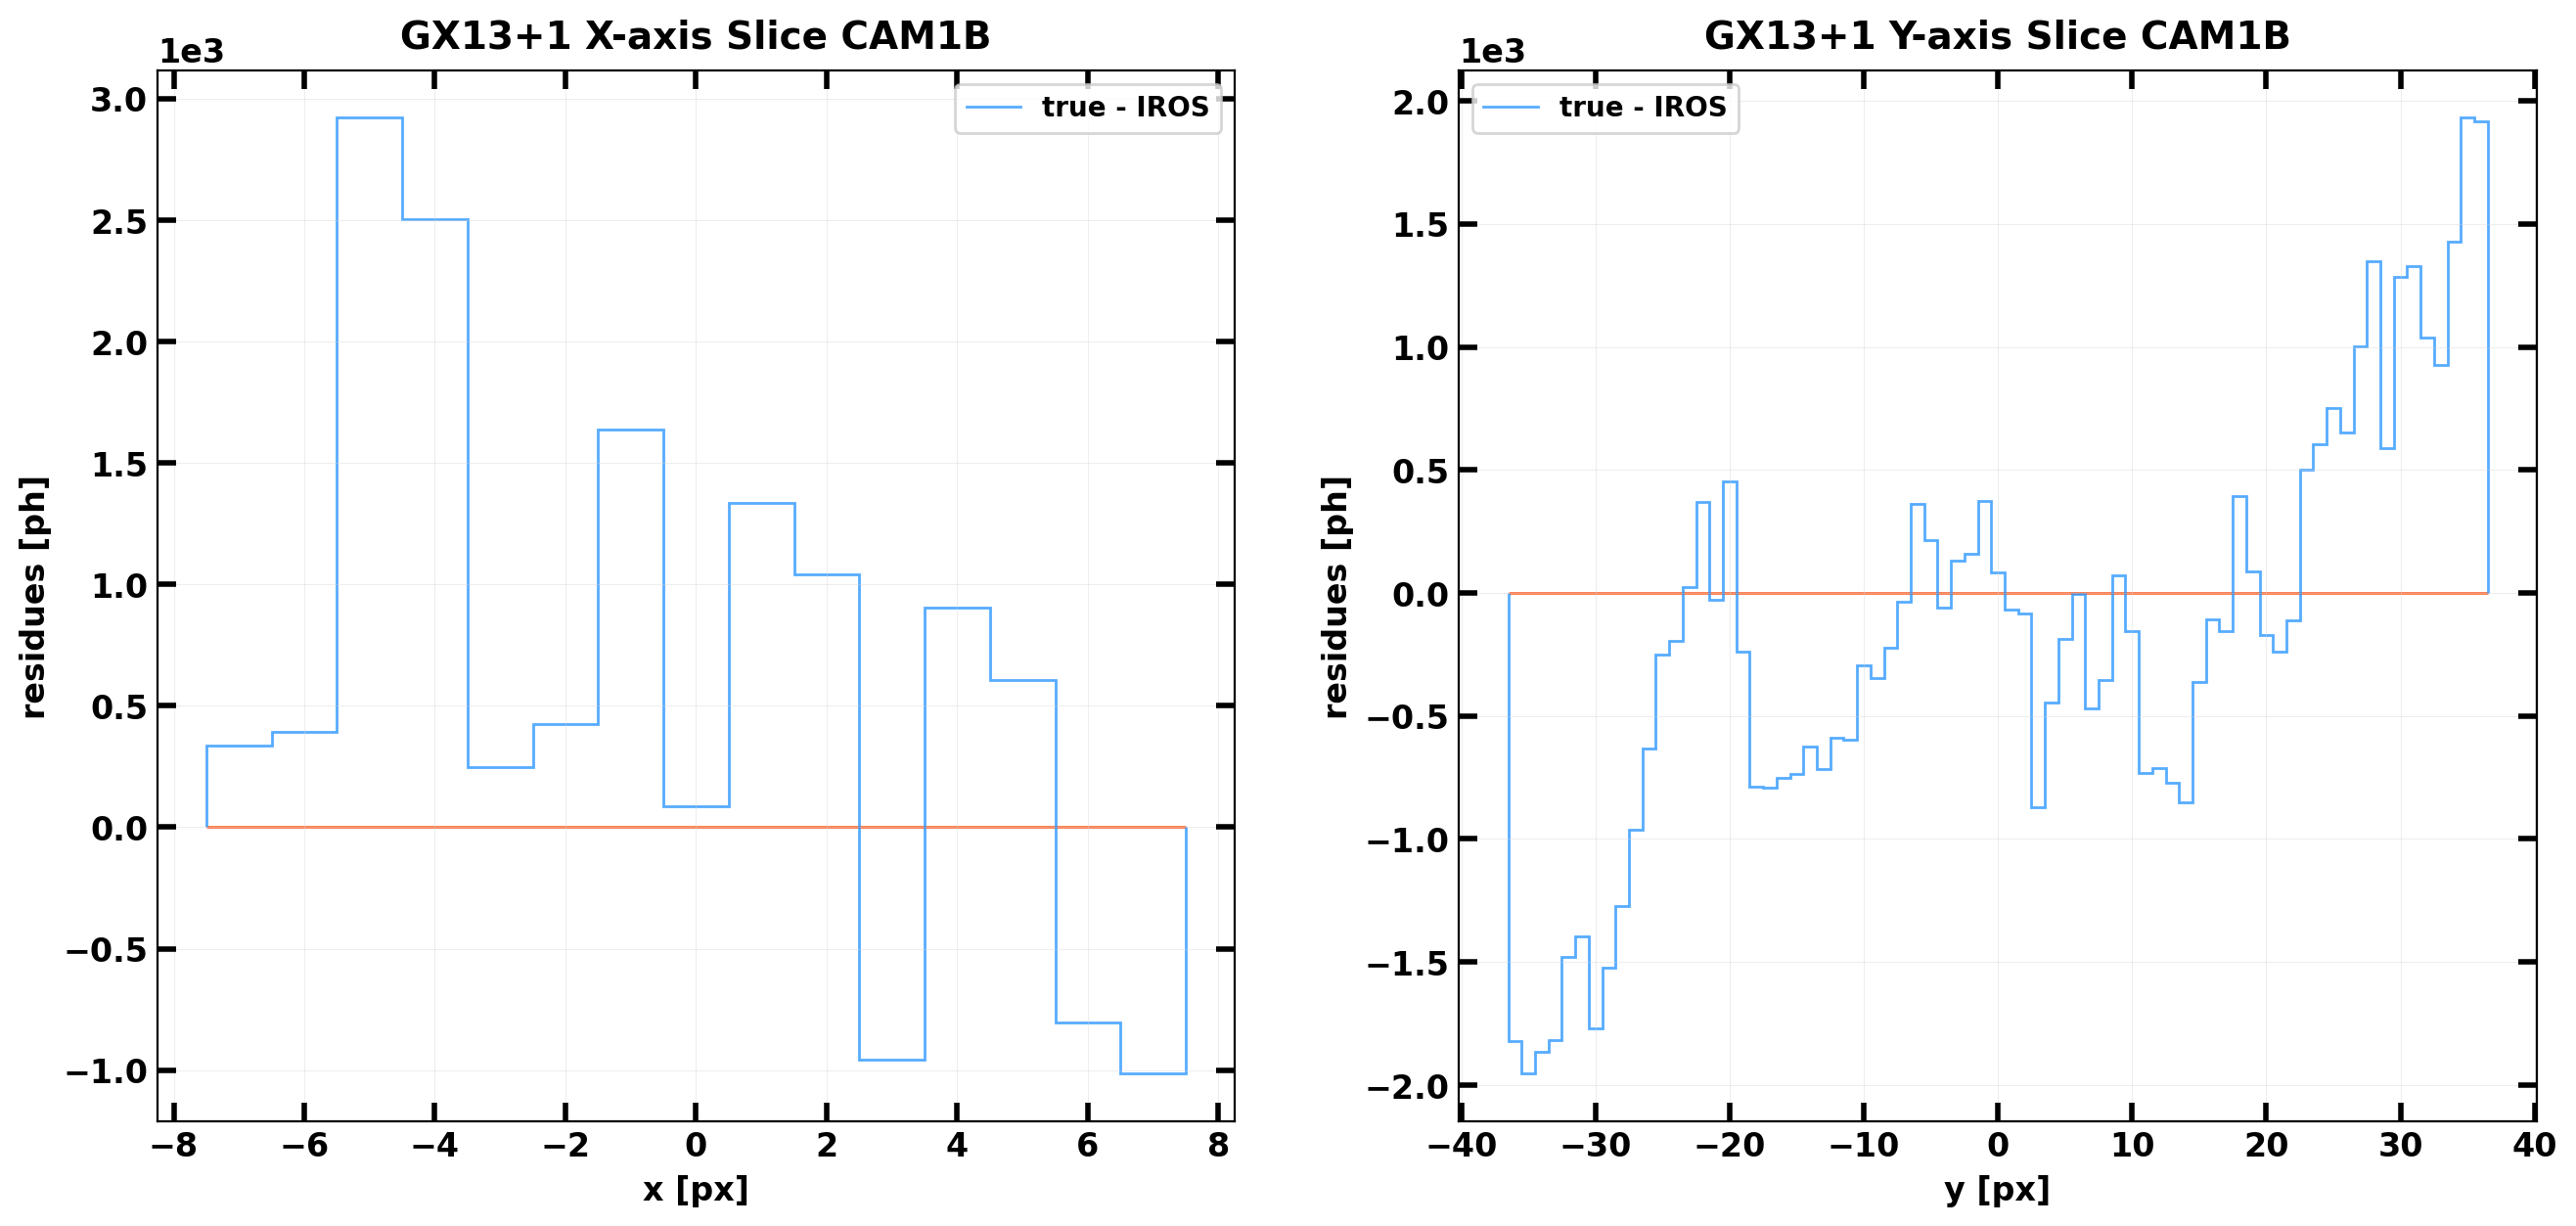

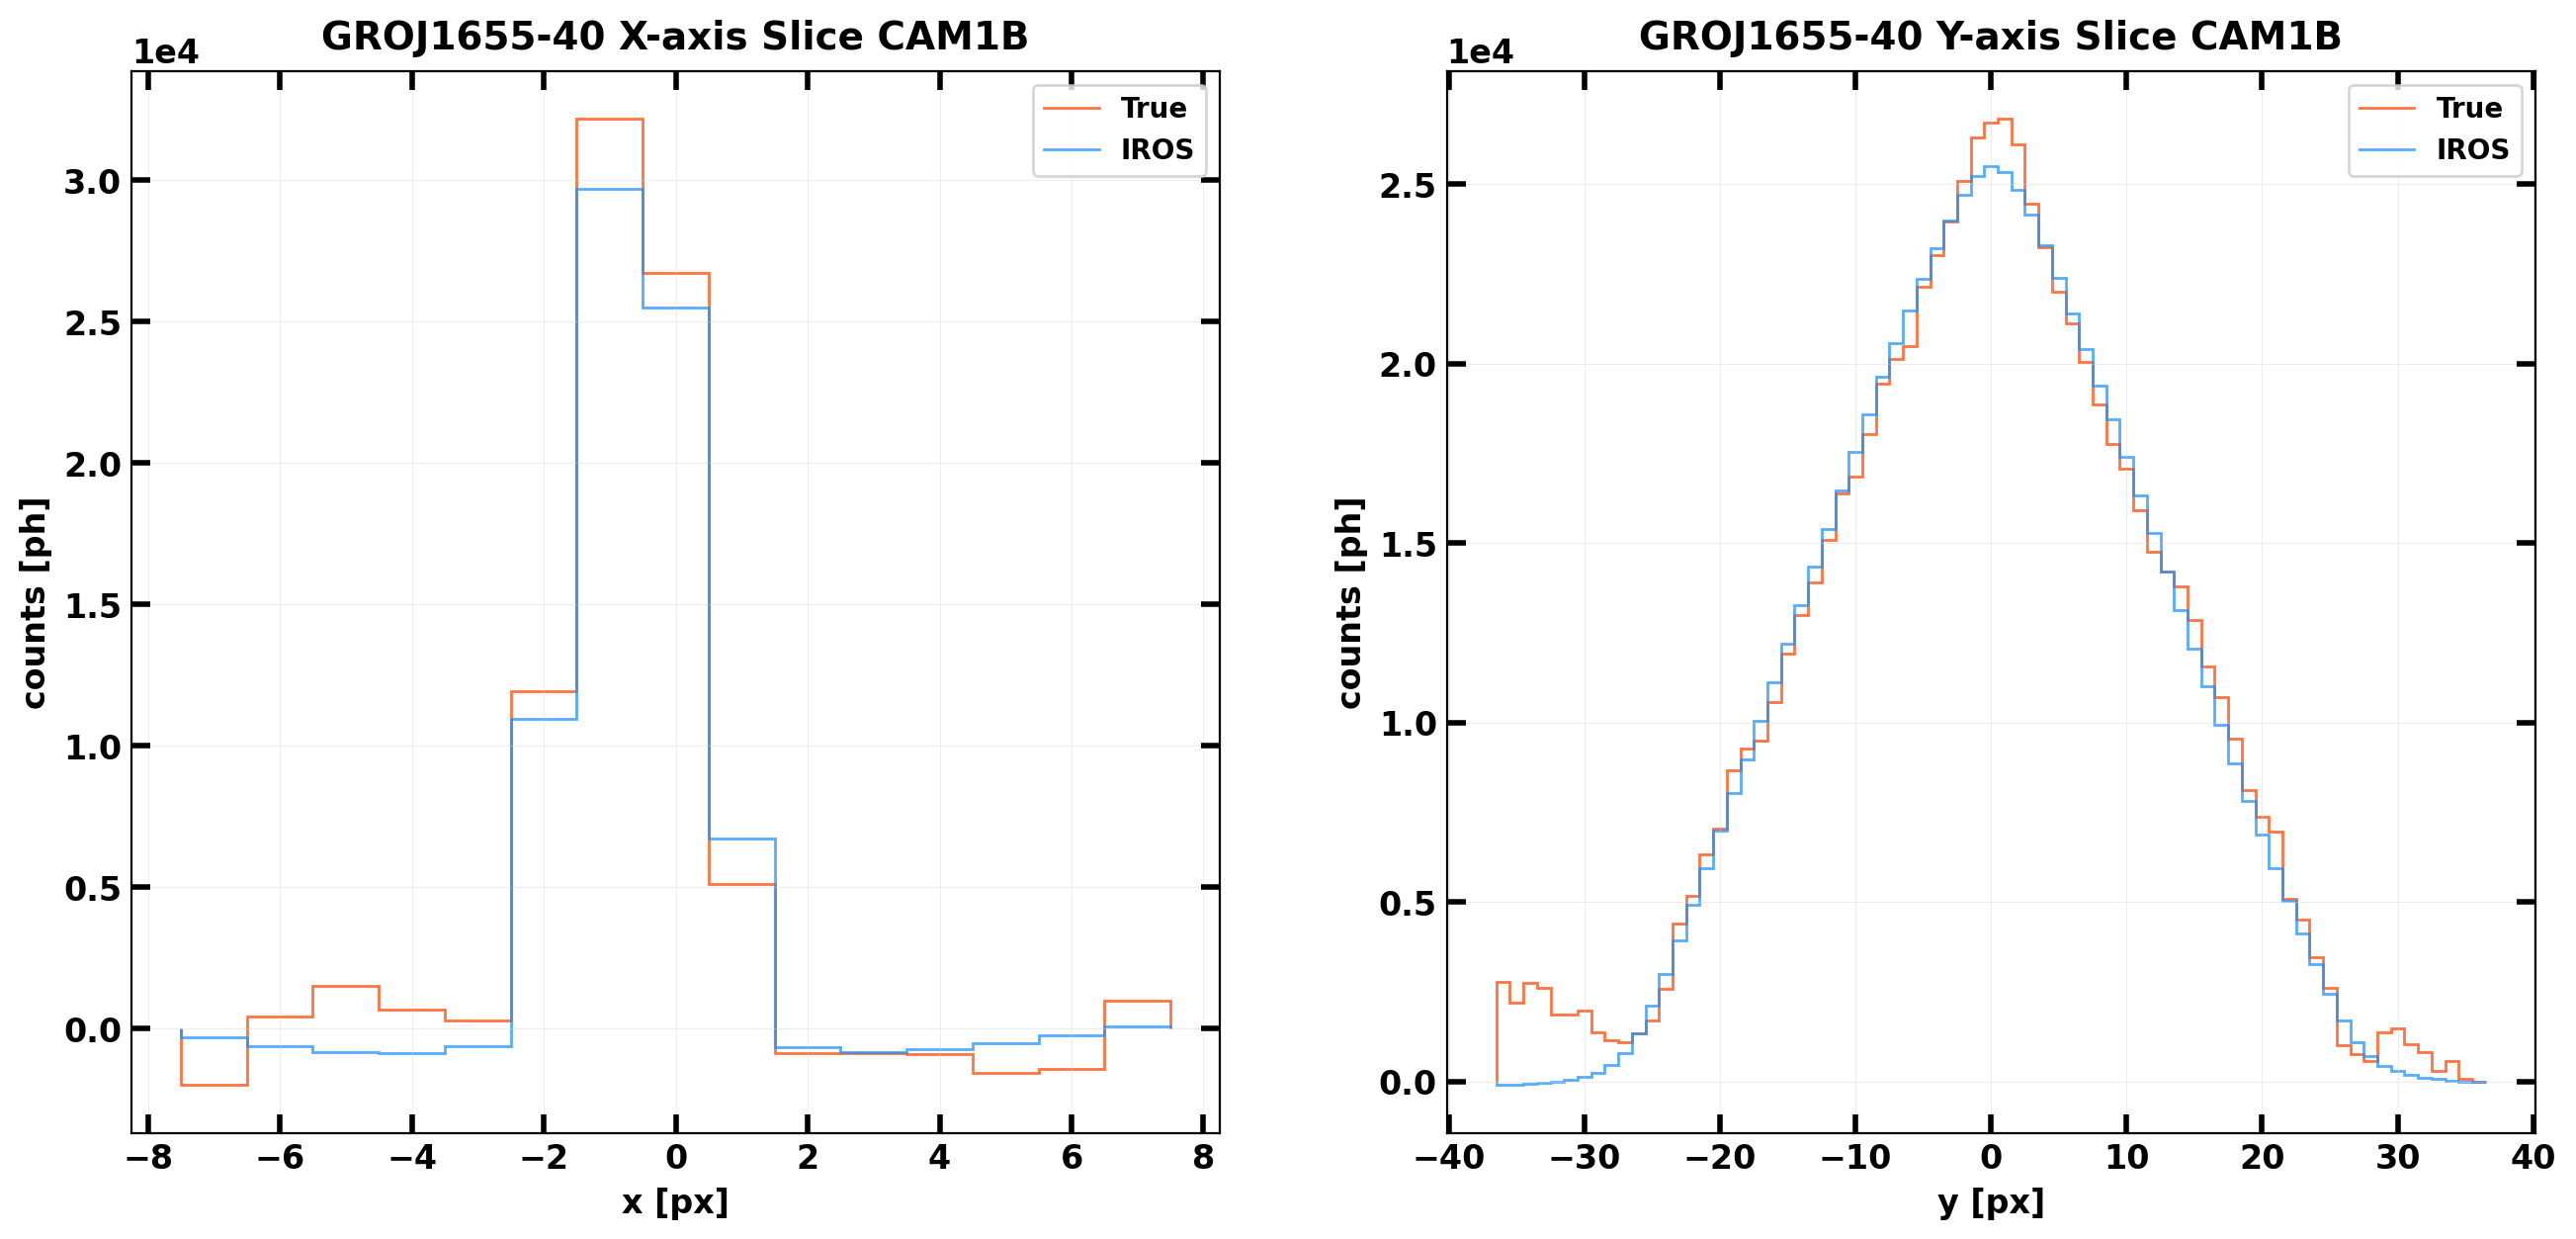

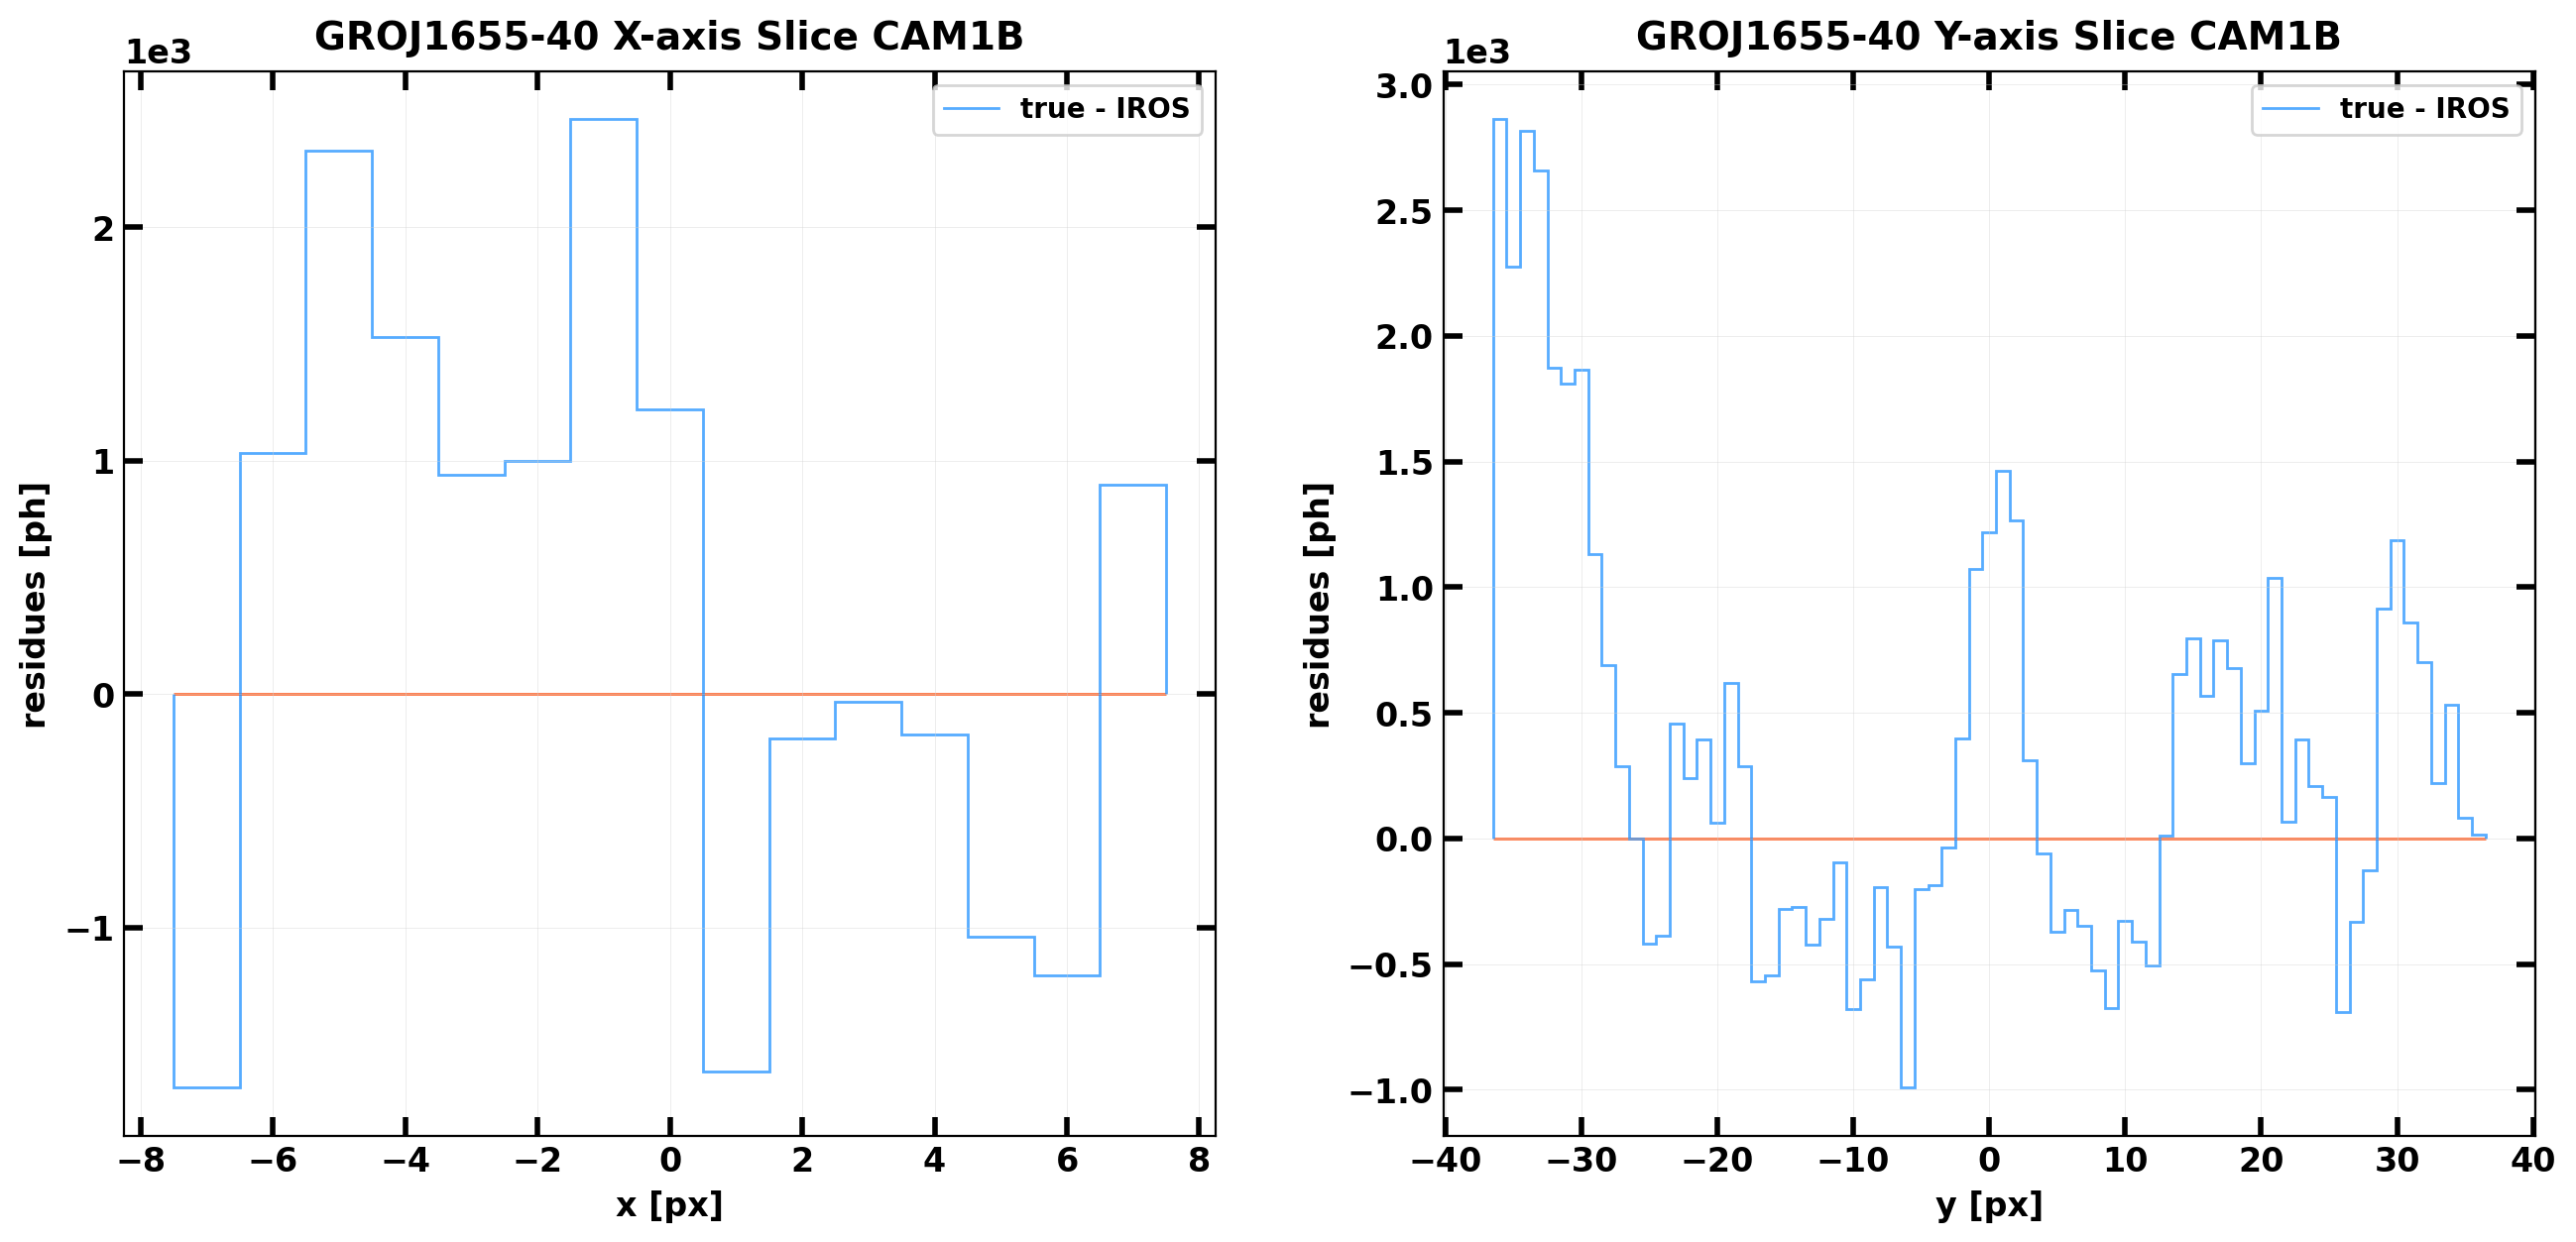

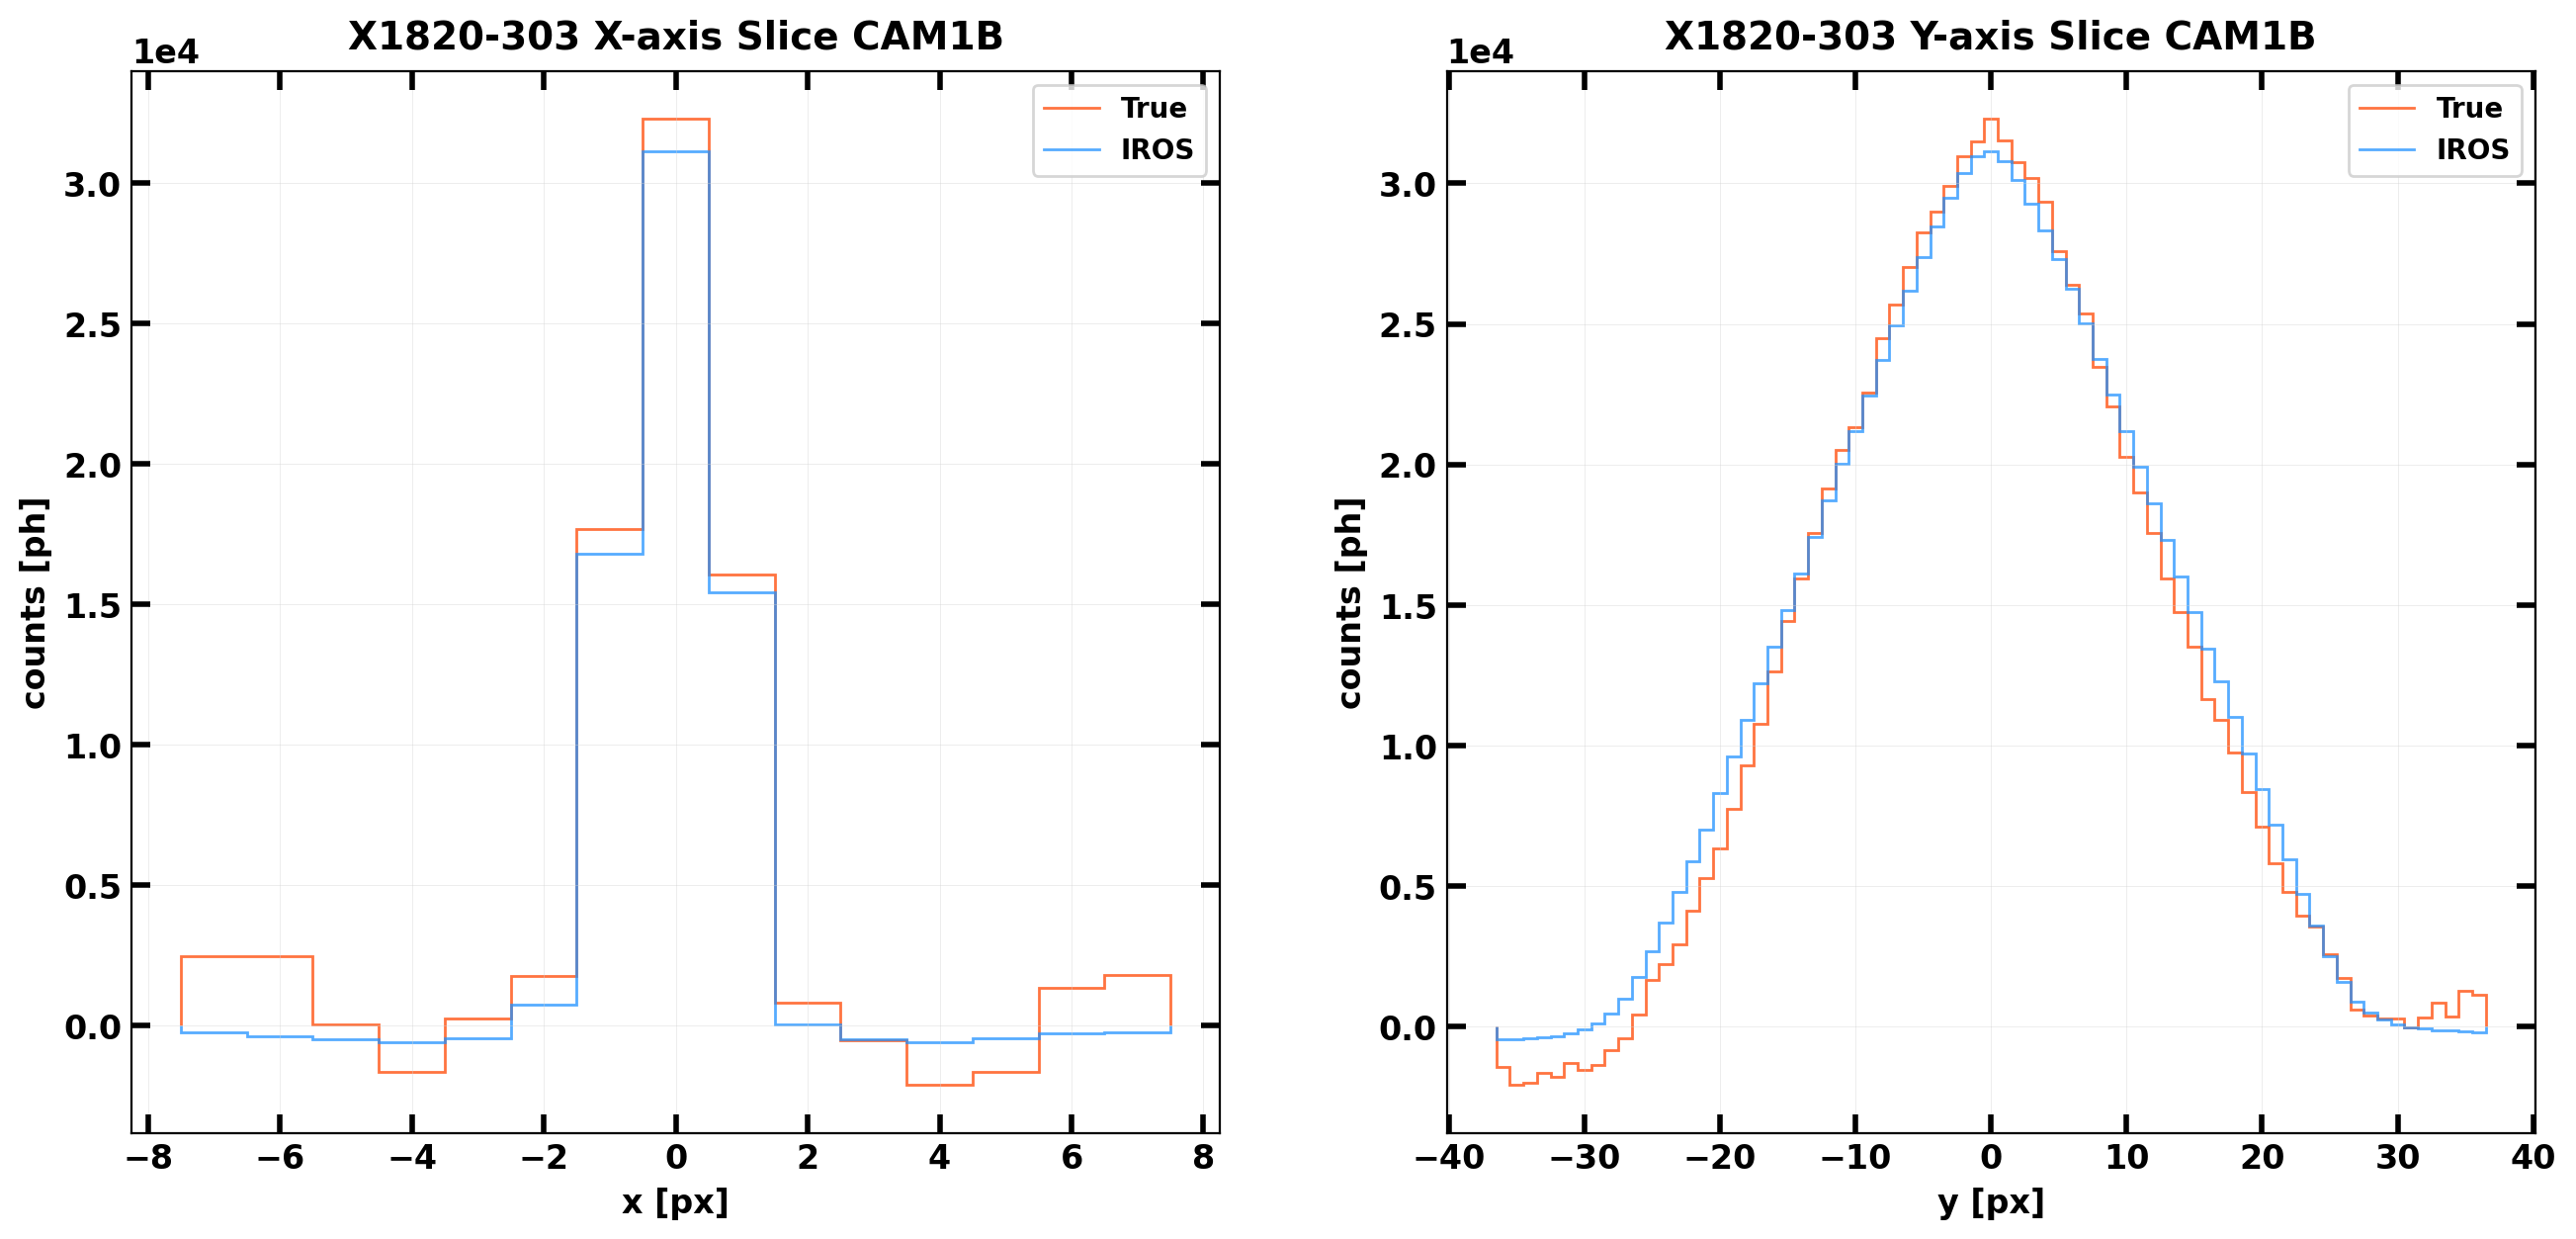

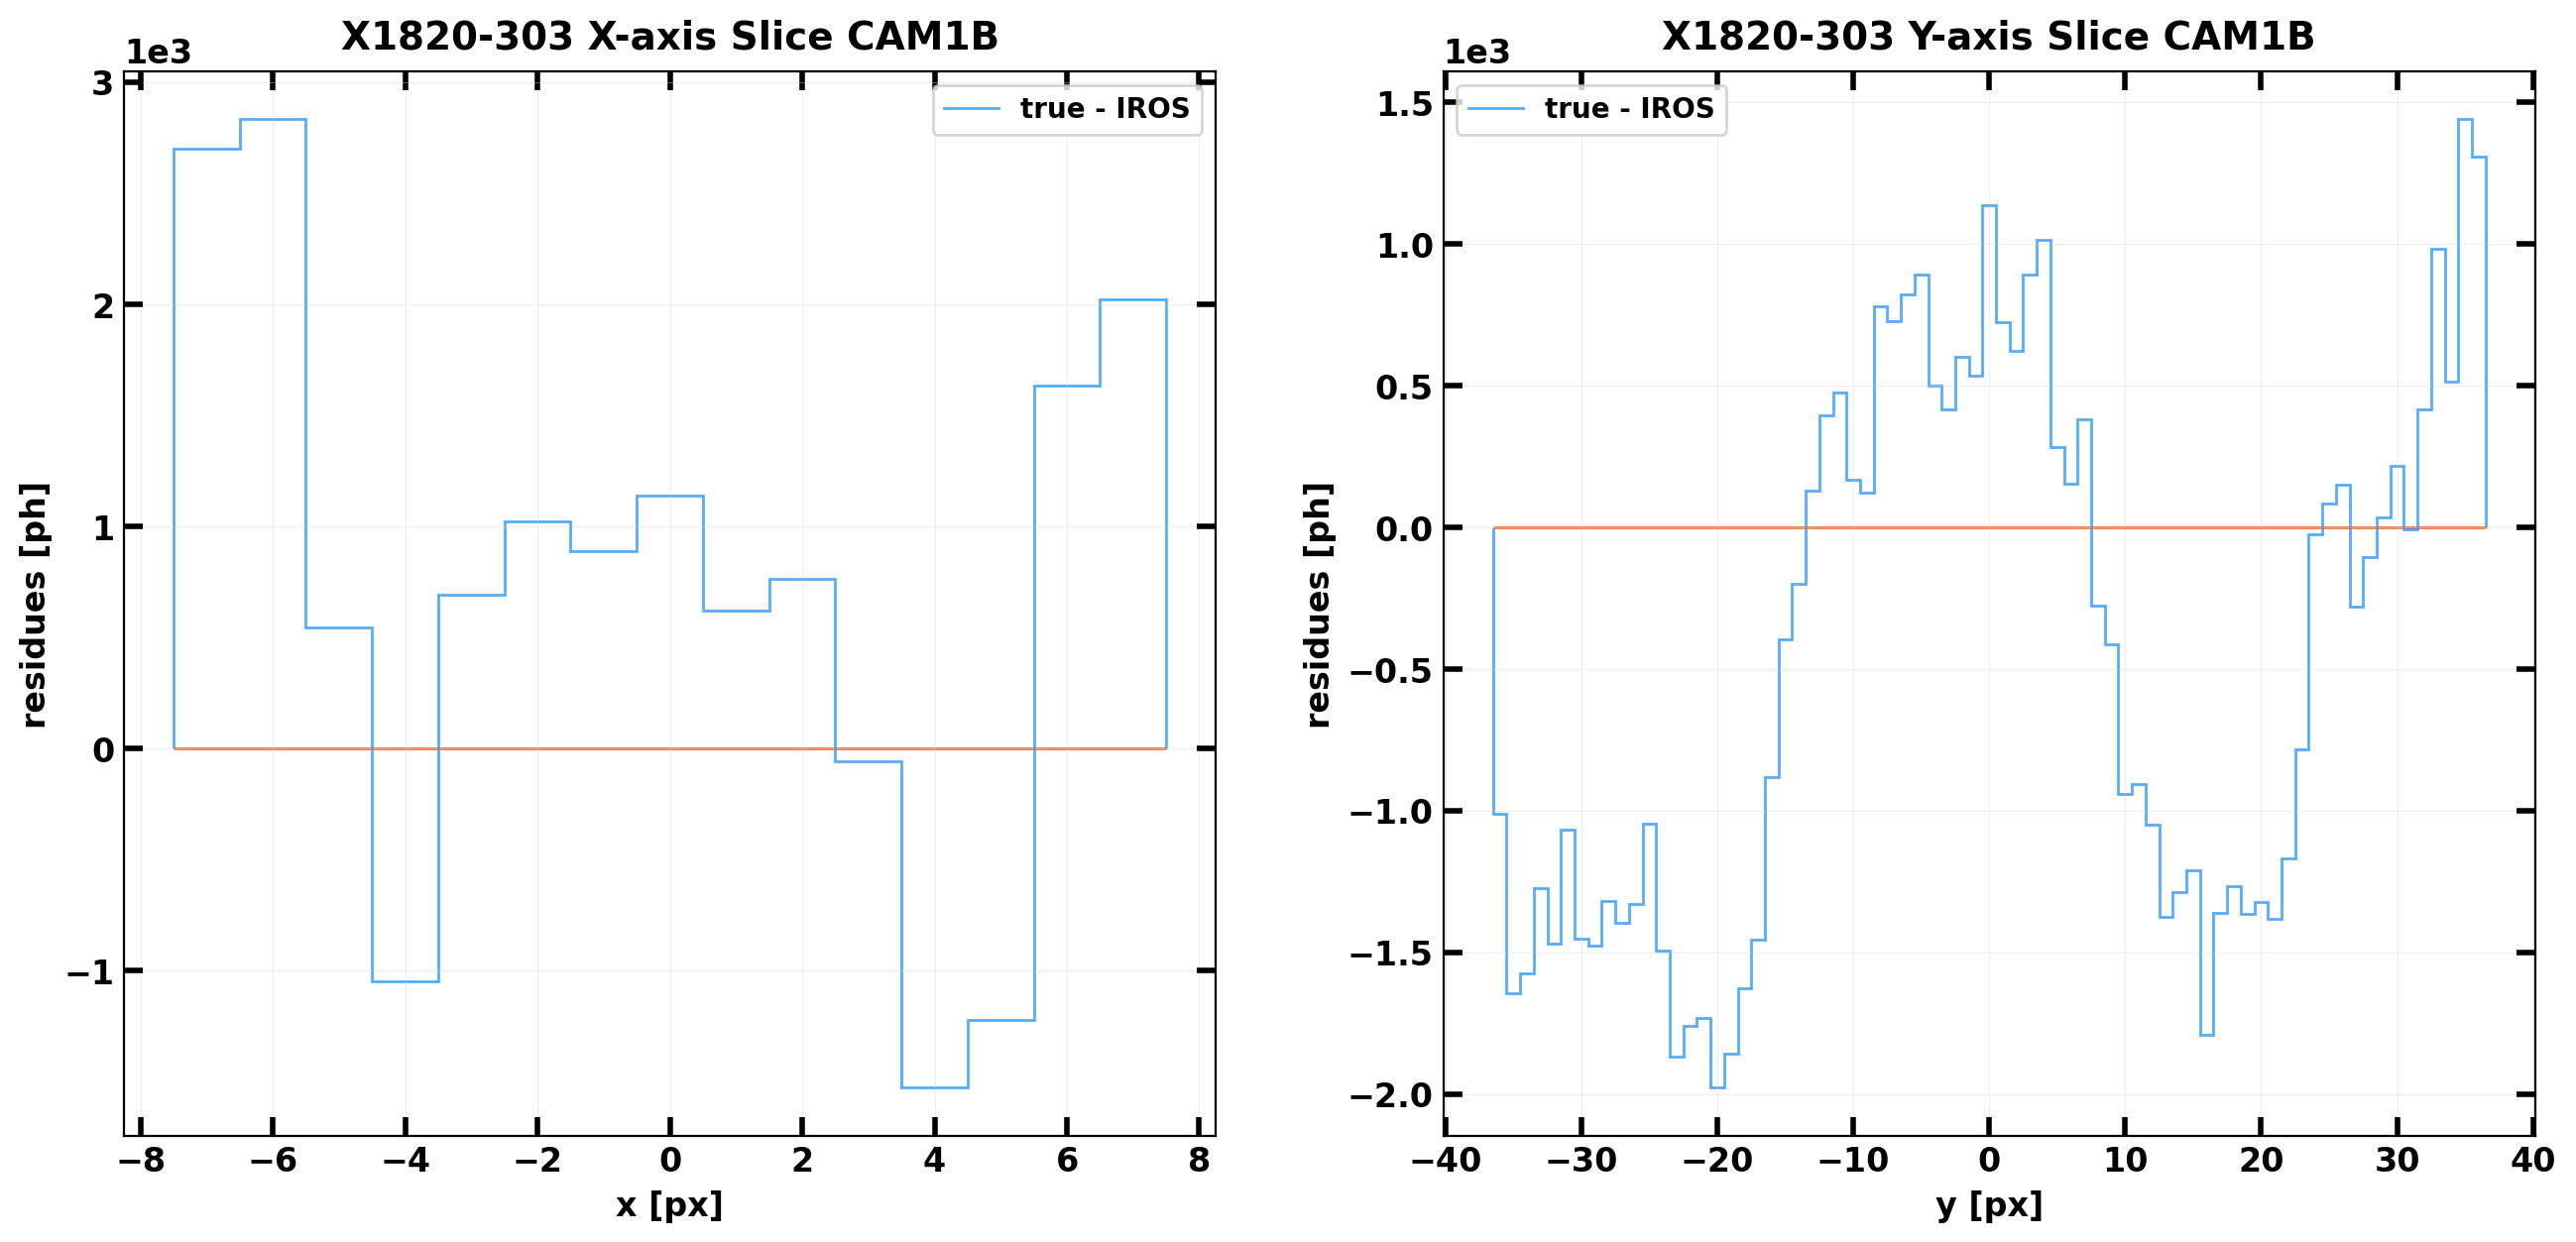

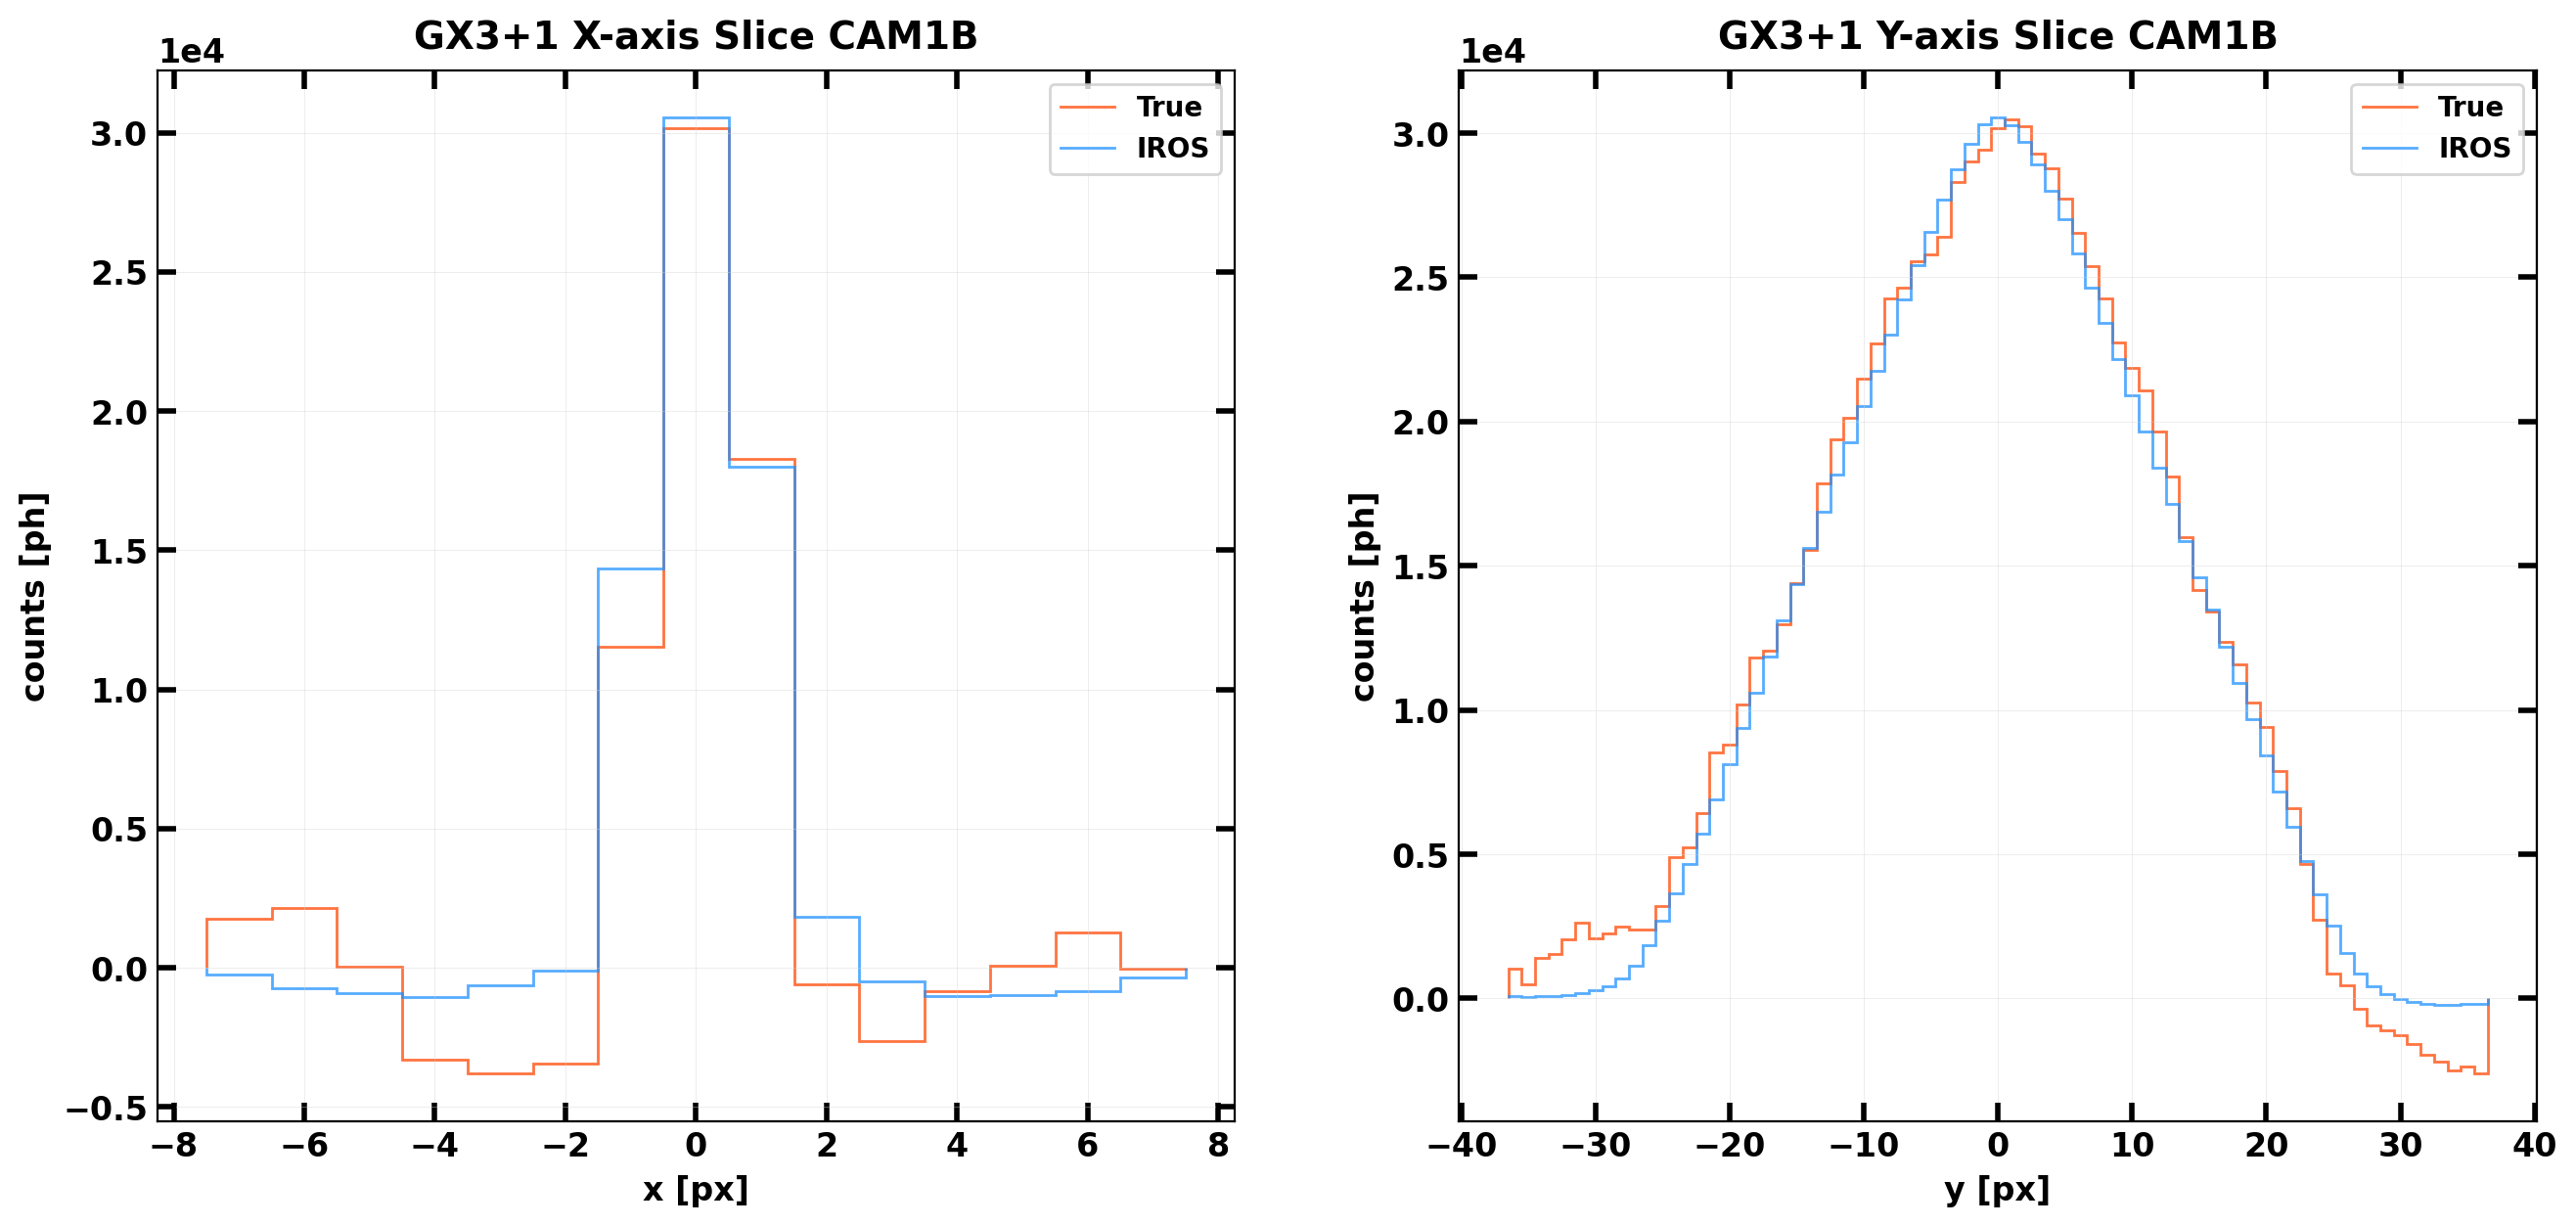

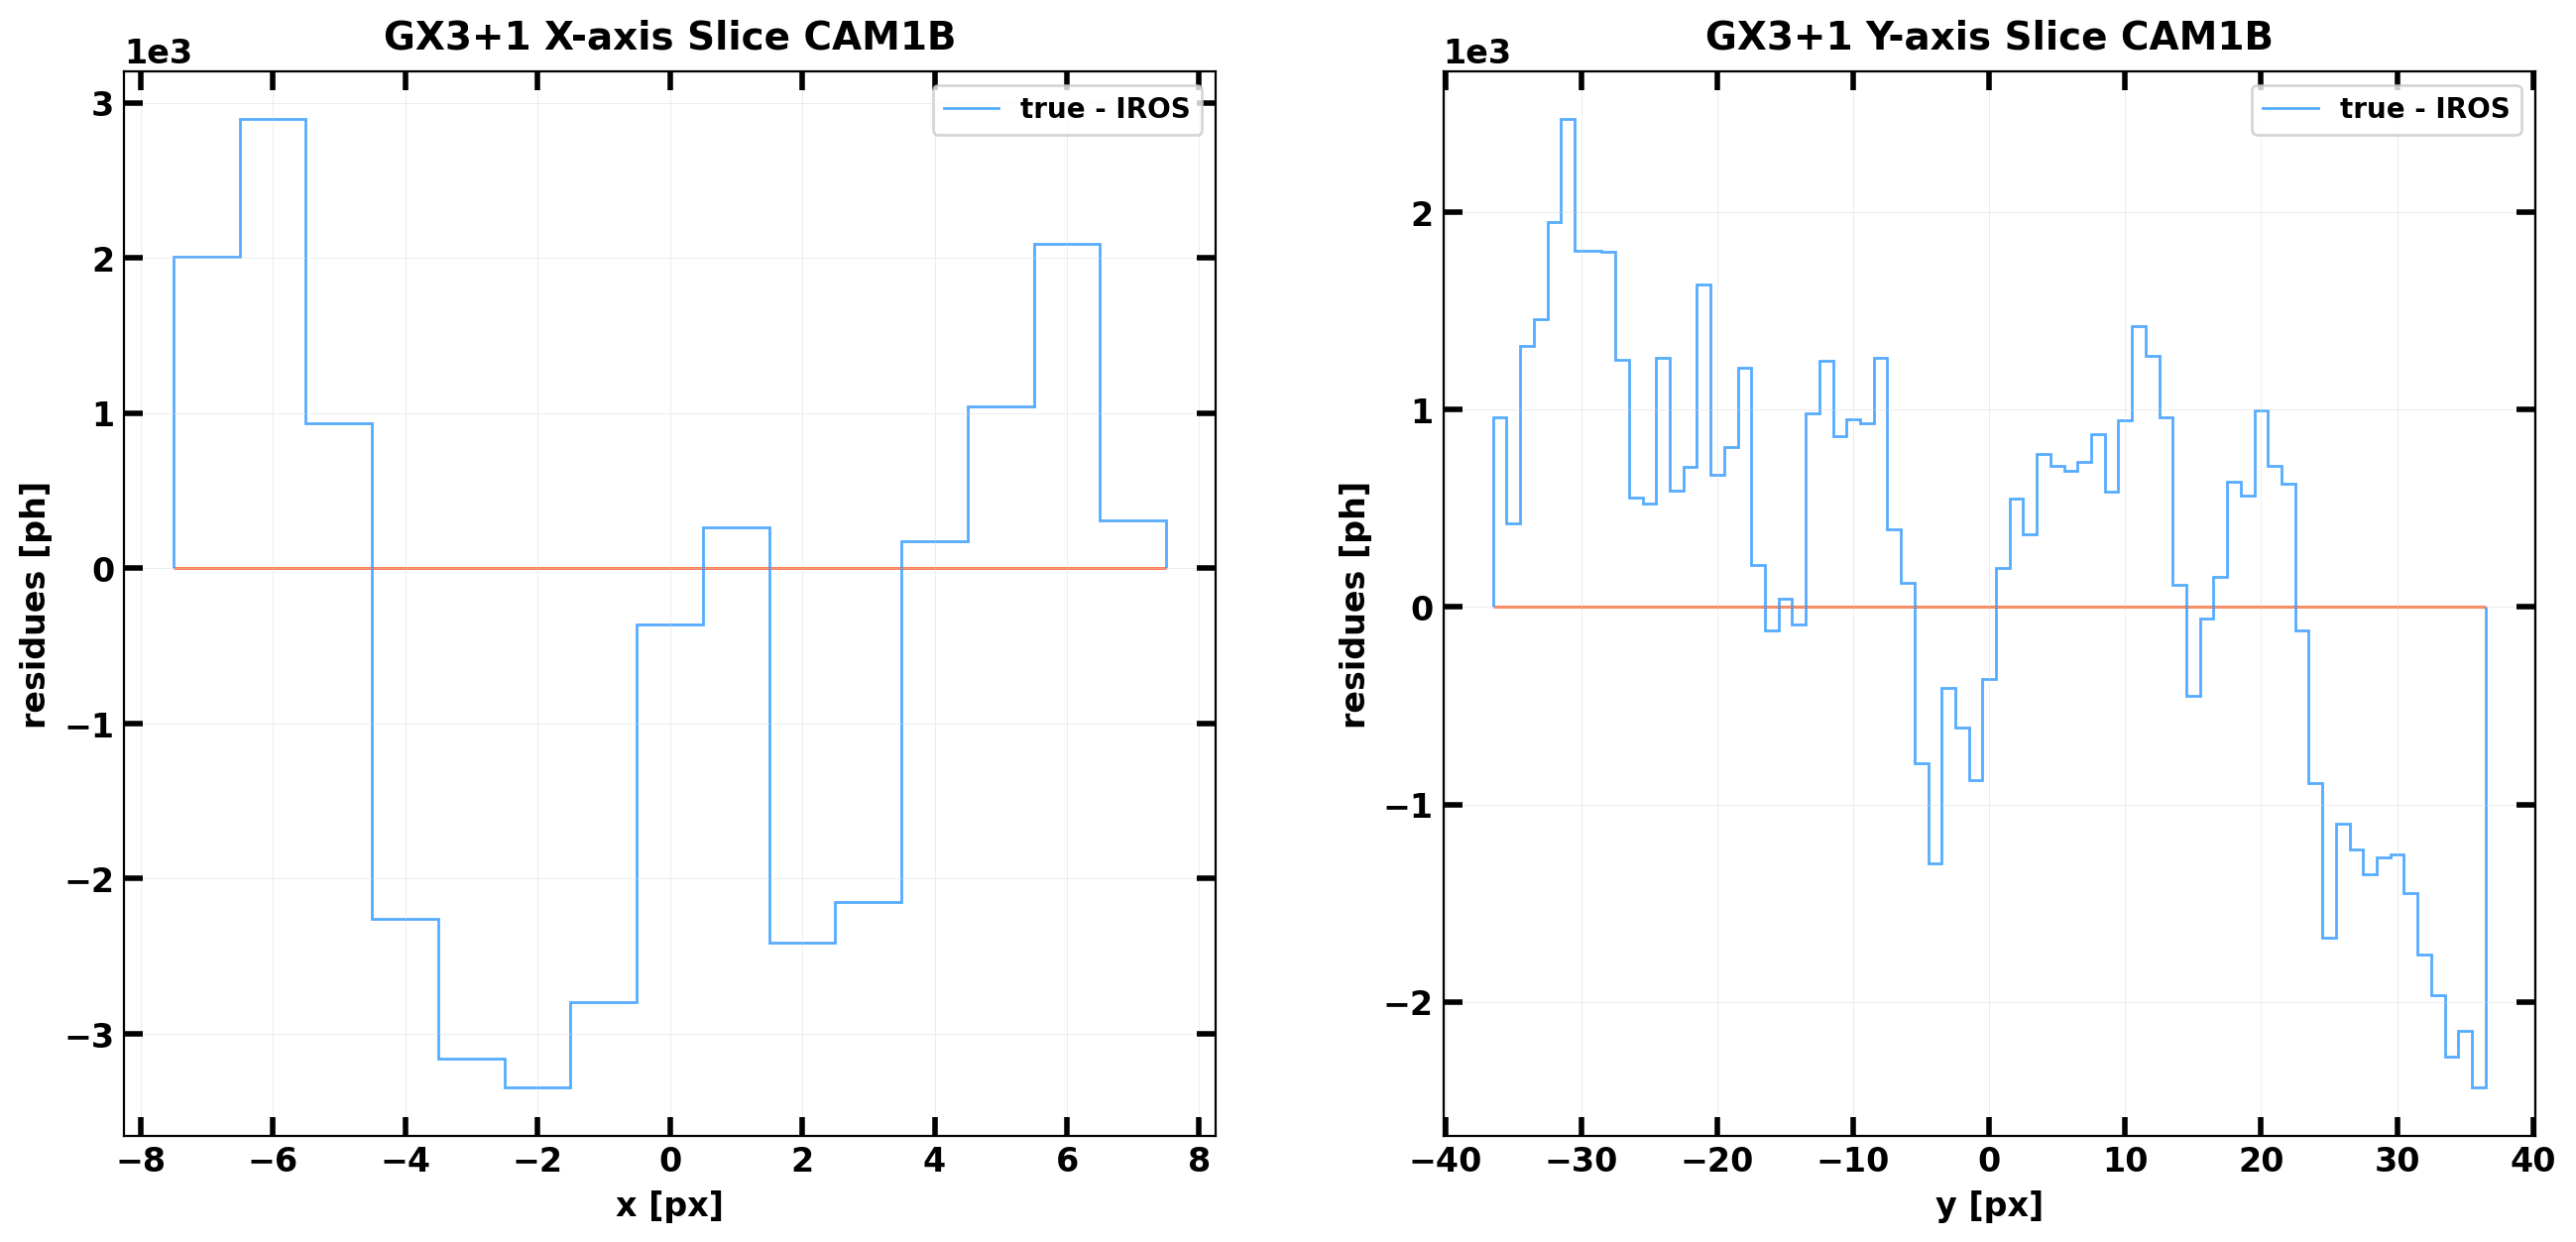

In [ ]:
# sources profiles during IROS + residues heatmaps
cropy, cropx = (
    int(wfm.specs["slit_deltay"] * UPS_Y / wfm.specs["mask_deltay"] + 5),
    int(wfm.specs["slit_deltax"] * UPS_X / wfm.specs["mask_deltax"] + 5),
)
reconstruction_plot(
    true_sky=true_sky_camB,
    log=log_camB,
    crp=(cropy, cropx),
    camera=wfm,
    vignetting=VIGNETTING,
    psfy=PSFY,
    save_to=SAVE_TO if SAVE_THINGS else None,
)

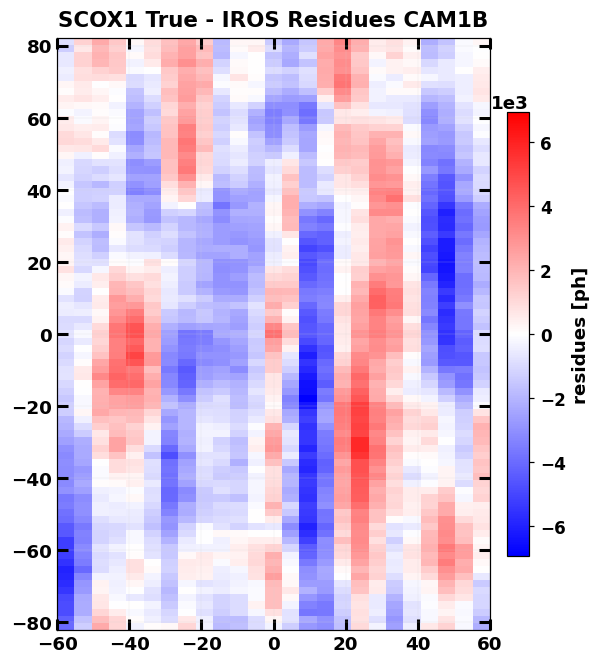

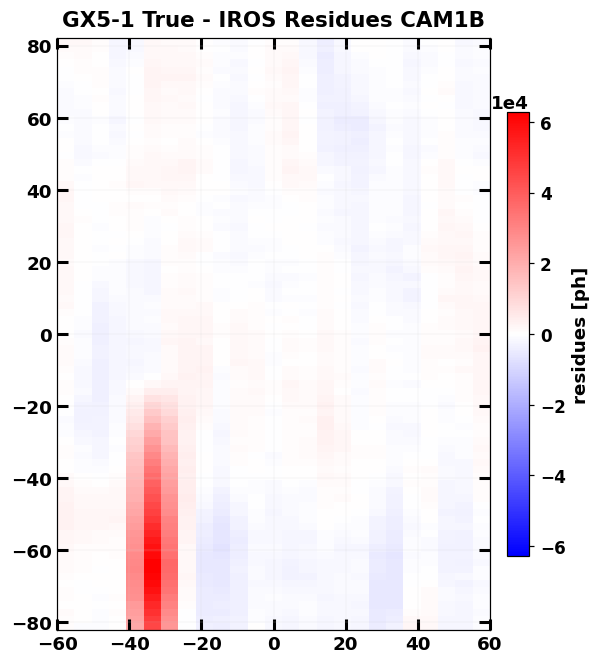

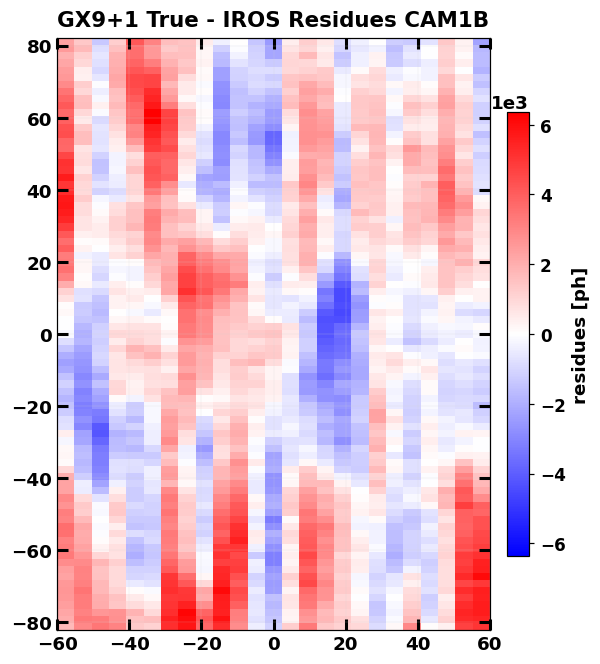

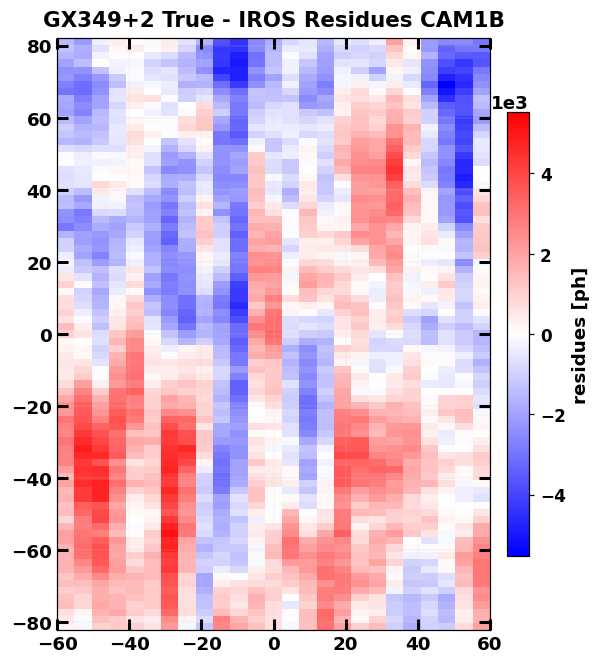

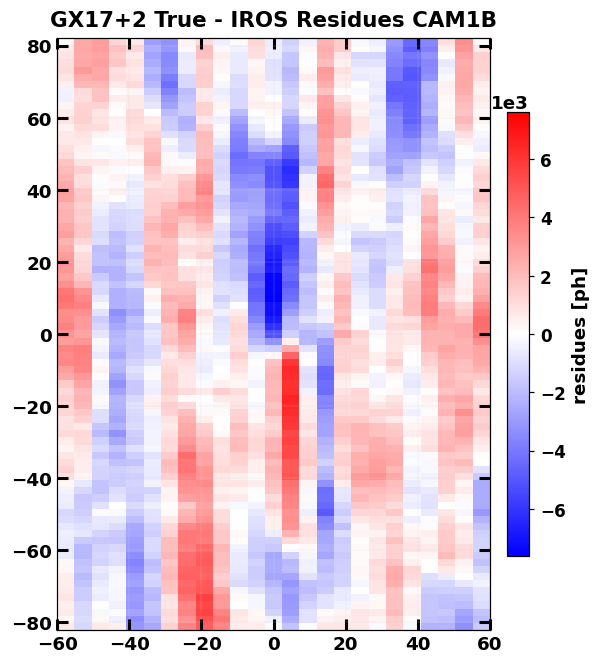

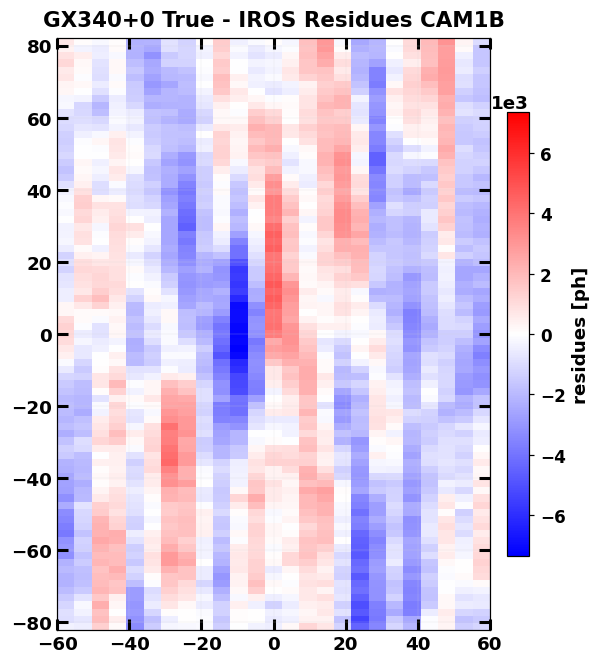

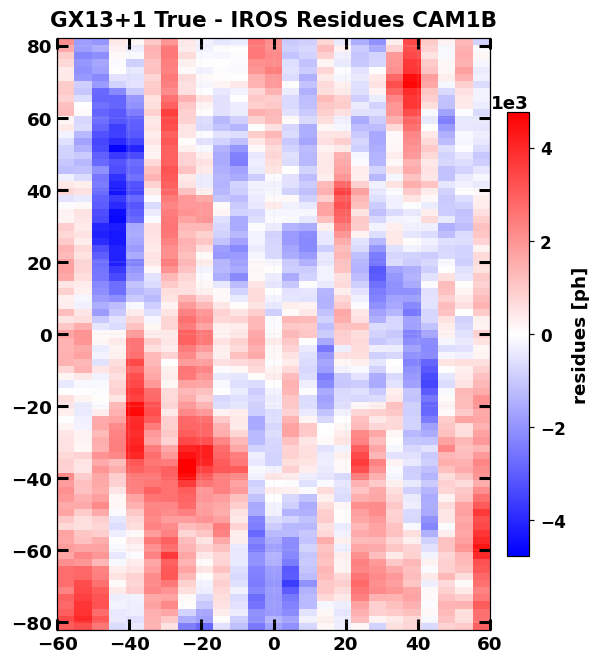

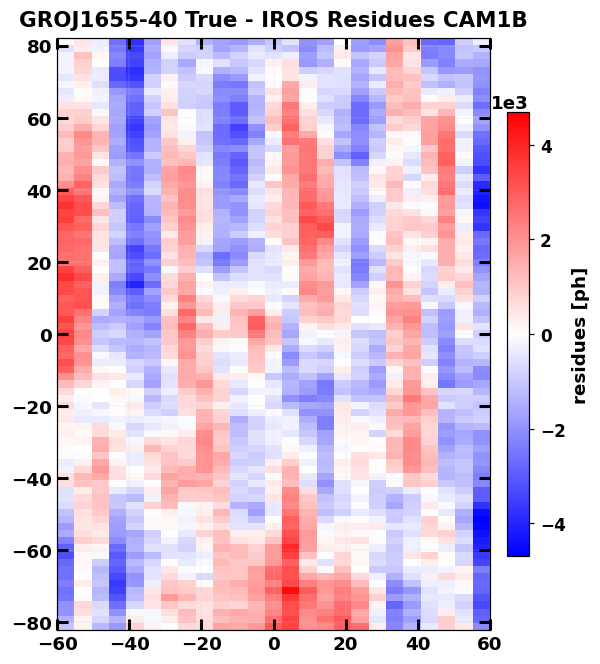

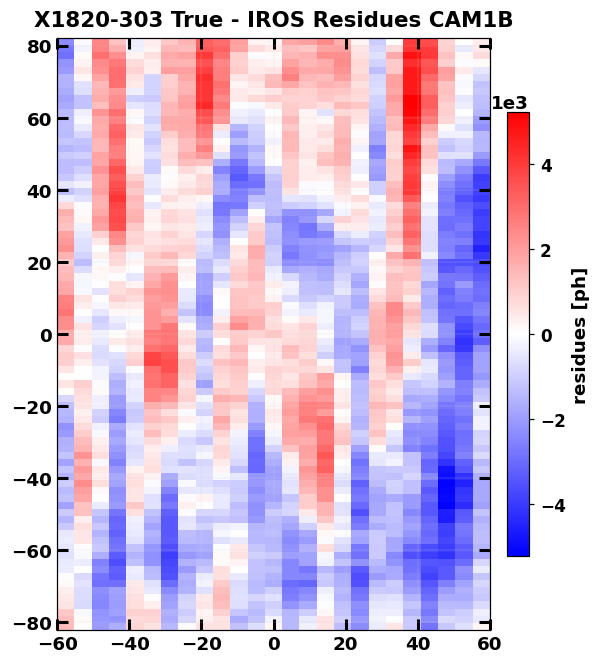

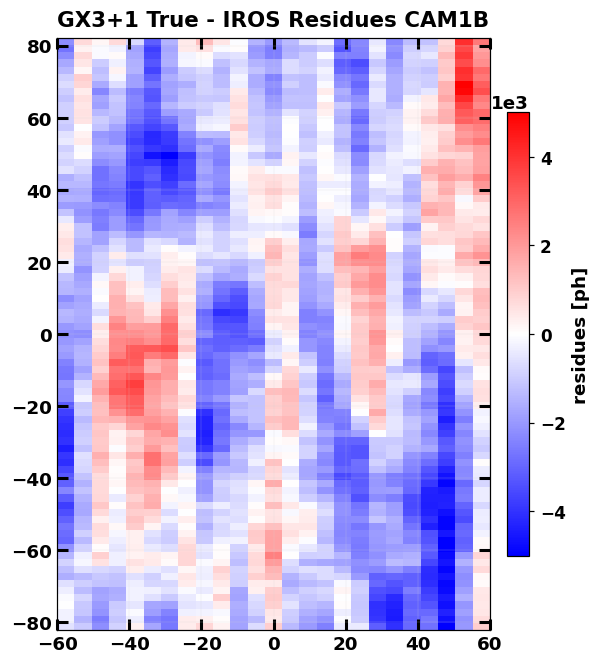

In [ ]:
reconstruction_heatmaps(
    true_sky=true_sky_camB,
    log=log_camB,
    camera=wfm,
    vignetting=VIGNETTING,
    psfy=PSFY,
    save_to=SAVE_TO if SAVE_THINGS else None,
)

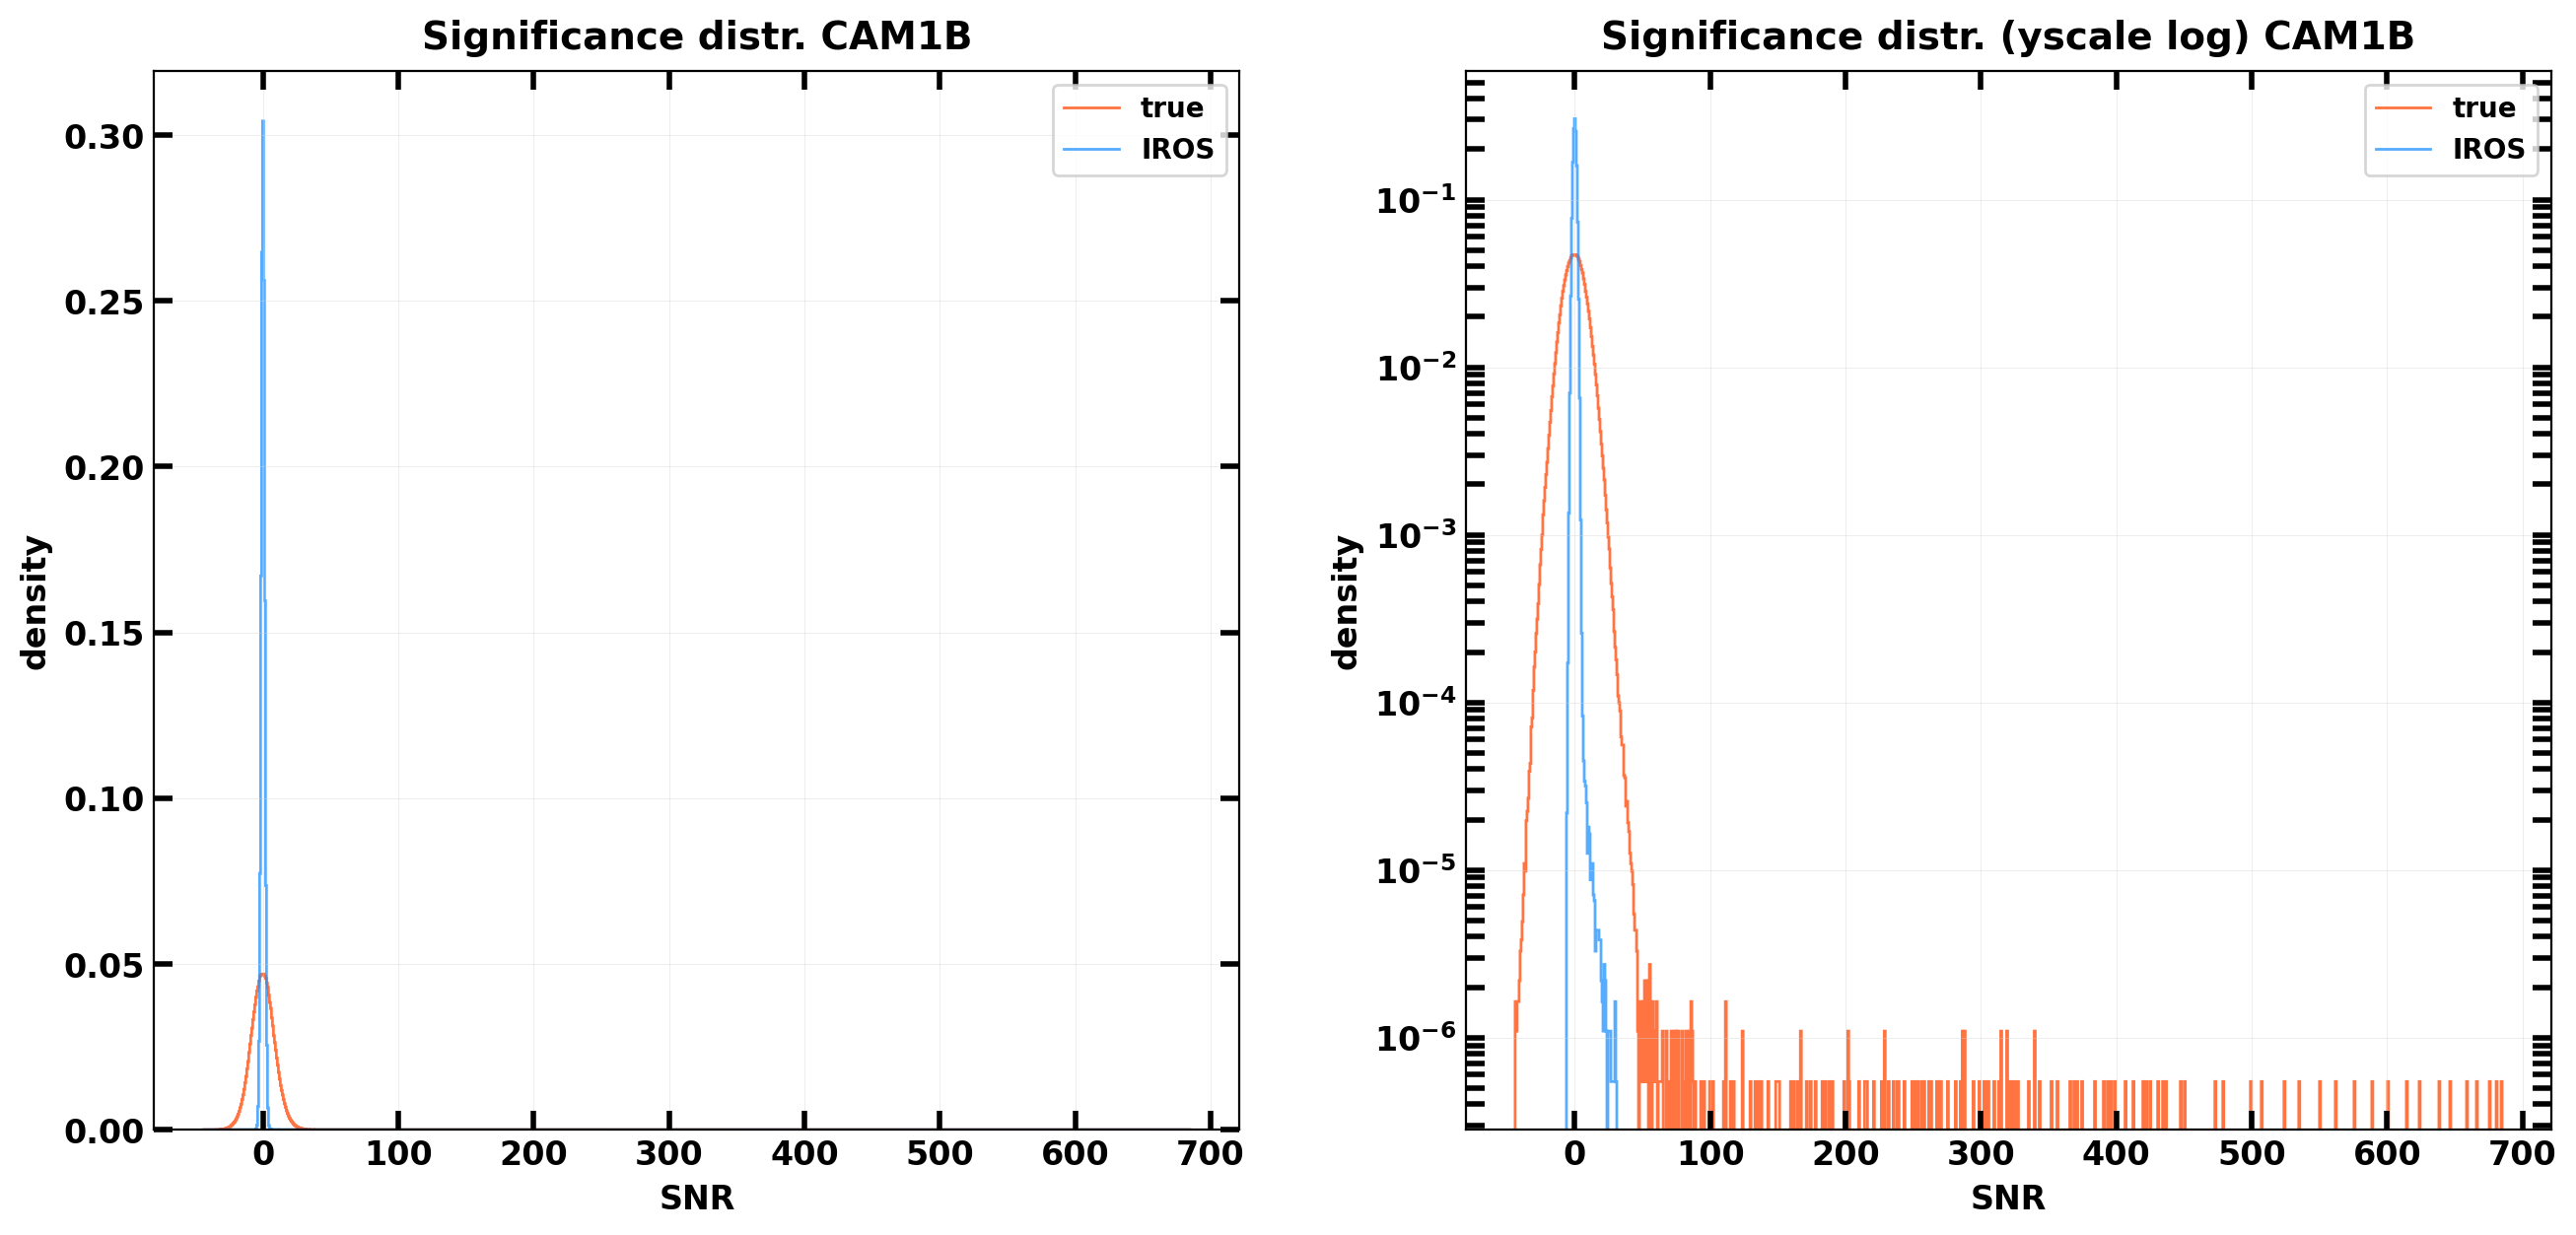

In [ ]:
# sky significance distr. for true sky and at the last IROS iteration
detector_camB = count(wfm, sdlB.DLdata)[0]
varmap = variance(wfm, detector_camB)

ycut, xcut = UPS_Y * 30, UPS_X * 20
true_skysnr_camB = ds.unframe(snratio(true_sky_camA, varmap), ycut, xcut)
res_skysnr_camB = ds.unframe(snratio(res_sky_camA, varmap), ycut, xcut)

num_bins = 1000
density = True
hist_true_skysnr, bins = np.histogram(true_skysnr_camB, bins=num_bins, density=density)
hist_res_skysnr, _ = np.histogram(res_skysnr_camB, bins=bins, density=density)


x0, xN = None, None
bins_slice, hist_slice = config_snrlim(bins, x0, xN)

dmap1_snr = ds.map4plot(
    arrs=(hist_true_skysnr[hist_slice], hist_res_skysnr[hist_slice]),
    title=f'Significance distr. {ID_CAMERA_B.upper()}',
    xlabel='SNR',
    ylabel='density',
    labels=('true', 'IROS'),
    x=bins[bins_slice],
    style='stairs',
    color=('OrangeRed', 'Dodgerblue'),
)
dmap2_snr = ds.map4plot(
    arrs=(hist_true_skysnr[hist_slice], hist_res_skysnr[hist_slice]),
    title=f'Significance distr. (yscale log) {ID_CAMERA_B.upper()}',
    xlabel='SNR',
    ylabel='density',
    labels=('true', 'IROS'),
    x=bins[bins_slice],
    style='stairs',
    color=('OrangeRed', 'Dodgerblue'),
    yscale='log',
)
ds.plot(
    dmaps=(dmap1_snr, dmap2_snr),
    ncols=2,
    save_to=(
        savefig_to(SAVE_TO, f'snr_distr_{ID_CAMERA_B.upper()}')
        if SAVE_THINGS else None
    ),
)